In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mohaliy2016/papsinglecell")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/mohaliy2016/papsinglecell


Classes found:
im_Dyskeratotic
im_Koilocytotic
im_Metaplastic
im_Parabasal
im_Superficial-Intermediate

IMAGE COUNT PER CLASS
im_Dyskeratotic: Training=713, Test=100, Total=813
im_Koilocytotic: Training=725, Test=100, Total=825
im_Metaplastic: Training=693, Test=100, Total=793
im_Parabasal: Training=687, Test=100, Total=787
im_Superficial-Intermediate: Training=731, Test=100, Total=831

Total Training Images : 3549
Total Test Images     : 500
Total Dataset Images  : 4049


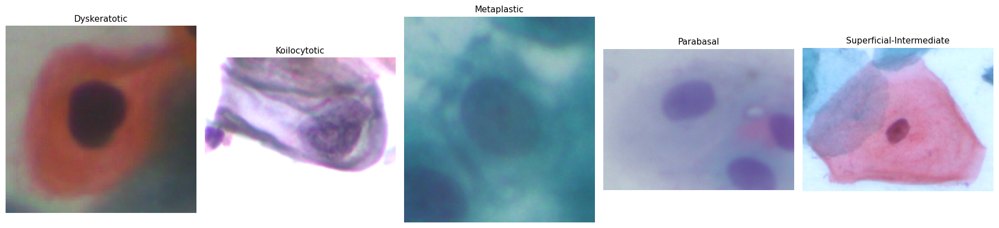

In [2]:
import os
import matplotlib.pyplot as plt
from PIL import Image

# ============================================================
# DATASET PATH
# ============================================================

DATASET_PATH = (
    "/kaggle/input/datasets/mohaliy2016/"
    "papsinglecell/SingleCellPAP"
)

TRAIN_PATH = os.path.join(DATASET_PATH, "Training")
TEST_PATH = os.path.join(DATASET_PATH, "Test")

IMAGE_EXTENSIONS = (
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff"
)


# ============================================================
# FIND CLASSES
# ============================================================

classes = sorted([
    d
    for d in os.listdir(TRAIN_PATH)
    if os.path.isdir(
        os.path.join(TRAIN_PATH, d)
    )
])

print("Classes found:")
for cls in classes:
    print(cls)


# ============================================================
# COUNT IMAGES
# ============================================================

train_counts = {}
test_counts = {}
total_counts = {}

sample_images = {}

print("\n" + "=" * 70)
print("IMAGE COUNT PER CLASS")
print("=" * 70)

for cls in classes:

    train_class_path = os.path.join(
        TRAIN_PATH,
        cls
    )

    test_class_path = os.path.join(
        TEST_PATH,
        cls
    )

    train_images = [
        f
        for f in os.listdir(train_class_path)
        if f.lower().endswith(
            IMAGE_EXTENSIONS
        )
    ]

    test_images = [
        f
        for f in os.listdir(test_class_path)
        if f.lower().endswith(
            IMAGE_EXTENSIONS
        )
    ]

    train_counts[cls] = len(train_images)
    test_counts[cls] = len(test_images)

    total_counts[cls] = (
        len(train_images)
        +
        len(test_images)
    )

    # Save one sample image
    if len(train_images) > 0:

        sample_images[cls] = os.path.join(
            train_class_path,
            train_images[0]
        )

    elif len(test_images) > 0:

        sample_images[cls] = os.path.join(
            test_class_path,
            test_images[0]
        )

    print(
        f"{cls}: "
        f"Training={train_counts[cls]}, "
        f"Test={test_counts[cls]}, "
        f"Total={total_counts[cls]}"
    )


# ============================================================
# TOTAL DATASET COUNTS
# ============================================================

total_train = sum(
    train_counts.values()
)

total_test = sum(
    test_counts.values()
)

total_dataset = sum(
    total_counts.values()
)

print("\n" + "=" * 70)

print(
    f"Total Training Images : {total_train}"
)

print(
    f"Total Test Images     : {total_test}"
)

print(
    f"Total Dataset Images  : {total_dataset}"
)


# ============================================================
# SHOW ONE IMAGE PER CLASS
# ============================================================

plt.figure(
    figsize=(18, 4)
)

for i, cls in enumerate(classes):

    image_path = sample_images[
        cls
    ]

    image = Image.open(
        image_path
    ).convert(
        "RGB"
    )

    plt.subplot(
        1,
        len(classes),
        i + 1
    )

    plt.imshow(
        image
    )

    # Remove "im_" from title
    clean_name = cls.replace(
        "im_",
        ""
    )

    plt.title(
        clean_name,
        fontsize=11
    )

    plt.axis(
        "off"
    )

plt.tight_layout()
plt.show()

# **duplicate**

In [ ]:
import os
import shutil
import hashlib
import pandas as pd
from PIL import Image


# ============================================================
# PATHS
# ============================================================

DATASET_PATH = (
    "/kaggle/input/datasets/mohaliy2016/"
    "papsinglecell/SingleCellPAP"
)

TRAIN_PATH = os.path.join(
    DATASET_PATH,
    "Training"
)

TEST_PATH = os.path.join(
    DATASET_PATH,
    "Test"
)

OUTPUT_PATH = (
    "/kaggle/working/"
    "SIPaKMeD_Deduplicated"
)

REPORT_PATH = (
    "/kaggle/working/"
    "SIPaKMeD_Duplicate_Report.csv"
)

CONFLICT_REPORT_PATH = (
    "/kaggle/working/"
    "SIPaKMeD_CrossClass_Conflict_Report.csv"
)

UNREADABLE_REPORT_PATH = (
    "/kaggle/working/"
    "SIPaKMeD_Unreadable_Report.csv"
)

IMAGE_EXTENSIONS = (
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff"
)


# ============================================================
# CLASS NAMES
# ============================================================

classes = sorted([
    d
    for d in os.listdir(TRAIN_PATH)
    if os.path.isdir(
        os.path.join(
            TRAIN_PATH,
            d
        )
    )
])

print("Classes found:")

for cls in classes:
    print(cls)


# ============================================================
# REMOVE OLD OUTPUT
# ============================================================

if os.path.exists(OUTPUT_PATH):
    shutil.rmtree(OUTPUT_PATH)

for split_name in [
    "Training",
    "Test"
]:

    for cls in classes:

        os.makedirs(
            os.path.join(
                OUTPUT_PATH,
                split_name,
                cls
            ),
            exist_ok=True
        )


# ============================================================
# HASH FUNCTIONS
# ============================================================

def calculate_file_hash(path):

    sha = hashlib.sha256()

    with open(path, "rb") as f:

        while True:

            chunk = f.read(
                1024 * 1024
            )

            if not chunk:
                break

            sha.update(chunk)

    return sha.hexdigest()


def calculate_pixel_hash(path):

    with Image.open(path) as img:

        img = img.convert("RGB")

        width, height = img.size

        sha = hashlib.sha256()

        # Include dimensions
        sha.update(
            f"{width}x{height}".encode()
        )

        # Include decoded RGB pixels
        sha.update(
            img.tobytes()
        )

        return sha.hexdigest()


# ============================================================
# SCAN TRAINING + TEST
# ============================================================

records = []

unreadable_records = []


for split_name, split_path in [
    ("Training", TRAIN_PATH),
    ("Test", TEST_PATH)
]:

    for cls in classes:

        class_path = os.path.join(
            split_path,
            cls
        )

        images = sorted([
            filename
            for filename in os.listdir(
                class_path
            )
            if filename.lower().endswith(
                IMAGE_EXTENSIONS
            )
        ])

        for filename in images:

            full_path = os.path.join(
                class_path,
                filename
            )

            try:

                file_hash = calculate_file_hash(
                    full_path
                )

                pixel_hash = calculate_pixel_hash(
                    full_path
                )

                records.append({
                    "split": split_name,
                    "class": cls,
                    "filename": filename,
                    "path": full_path,
                    "file_hash": file_hash,
                    "pixel_hash": pixel_hash
                })

            except Exception as error:

                unreadable_records.append({
                    "split": split_name,
                    "class": cls,
                    "filename": filename,
                    "path": full_path,
                    "error": str(error)
                })


df = pd.DataFrame(
    records
)


# ============================================================
# ORIGINAL COUNTS
# ============================================================

print(
    "\n"
    +
    "=" * 75
)

print(
    "ORIGINAL DATASET"
)

print(
    "=" * 75
)


for split_name in [
    "Training",
    "Test"
]:

    print(
        f"\n{split_name}:"
    )

    subset = df[
        df["split"] == split_name
    ]

    for cls in classes:

        count = len(
            subset[
                subset["class"] == cls
            ]
        )

        print(
            f"{cls}: {count}"
        )

    print(
        "Total:",
        len(subset)
    )


print(
    "\nTotal images:",
    len(df)
)


# ============================================================
# FIND CROSS-CLASS CONFLICTS
#
# Same decoded image but assigned to >1 class.
# Remove all such copies.
# ============================================================

class_count_per_hash = (
    df.groupby(
        "pixel_hash"
    )["class"]
    .nunique()
)

conflict_hashes = set(
    class_count_per_hash[
        class_count_per_hash > 1
    ].index
)


conflict_df = df[
    df["pixel_hash"].isin(
        conflict_hashes
    )
].copy()


safe_df = df[
    ~df["pixel_hash"].isin(
        conflict_hashes
    )
].copy()


# ============================================================
# FIND DUPLICATES
#
# Pixel hash is the final criterion.
#
# If duplicate occurs in both Train and Test:
#   KEEP TEST COPY
#   REMOVE TRAIN COPY
#
# This avoids training on an image that is present in test.
# ============================================================

kept_records = []

removed_records = []


for pixel_hash, group in safe_df.groupby(
    "pixel_hash"
):

    group = group.copy()

  

    group["priority"] = group[
        "split"
    ].map({
        "Test": 0,
        "Training": 1
    })

    group = group.sort_values(
        by=[
            "priority",
            "filename"
        ]
    )

    keep_row = group.iloc[0]

    kept_records.append(
        keep_row.to_dict()
    )


    if len(group) > 1:

        for i in range(
            1,
            len(group)
        ):

            duplicate_row = group.iloc[i]

            if (
                keep_row["split"]
                !=
                duplicate_row["split"]
            ):

                duplicate_type = (
                    "Cross-split duplicate"
                )

            else:

                duplicate_type = (
                    "Within-split duplicate"
                )


            removed_records.append({

                "duplicate_type":
                    duplicate_type,

                "removed_split":
                    duplicate_row[
                        "split"
                    ],

                "removed_class":
                    duplicate_row[
                        "class"
                    ],

                "removed_filename":
                    duplicate_row[
                        "filename"
                    ],

                "kept_split":
                    keep_row[
                        "split"
                    ],

                "kept_class":
                    keep_row[
                        "class"
                    ],

                "kept_filename":
                    keep_row[
                        "filename"
                    ],

                "file_hash":
                    duplicate_row[
                        "file_hash"
                    ],

                "pixel_hash":
                    pixel_hash
            })


kept_df = pd.DataFrame(
    kept_records
)

duplicate_df = pd.DataFrame(
    removed_records
)



for _, row in kept_df.iterrows():

    source = row[
        "path"
    ]

    destination = os.path.join(
        OUTPUT_PATH,
        row["split"],
        row["class"],
        row["filename"]
    )

    shutil.copy2(
        source,
        destination
    )


# ============================================================
# SAVE REPORTS
# ============================================================

duplicate_df.to_csv(
    REPORT_PATH,
    index=False
)

conflict_df.to_csv(
    CONFLICT_REPORT_PATH,
    index=False
)


if len(unreadable_records) > 0:

    unreadable_df = pd.DataFrame(
        unreadable_records
    )

    unreadable_df.to_csv(
        UNREADABLE_REPORT_PATH,
        index=False
    )


# ============================================================
# DUPLICATE STATISTICS
# ============================================================

if len(duplicate_df) > 0:

    within_split_duplicates = len(
        duplicate_df[
            duplicate_df[
                "duplicate_type"
            ]
            ==
            "Within-split duplicate"
        ]
    )

    cross_split_duplicates = len(
        duplicate_df[
            duplicate_df[
                "duplicate_type"
            ]
            ==
            "Cross-split duplicate"
        ]
    )

else:

    within_split_duplicates = 0
    cross_split_duplicates = 0


# ============================================================
# FINAL RESULTS
# ============================================================

print(
    "\n"
    +
    "=" * 75
)

print(
    "DUPLICATE CHECK RESULTS"
)

print(
    "=" * 75
)


print(
    "\nWithin-split duplicates removed:",
    within_split_duplicates
)

print(
    "Train/Test cross-split duplicates removed:",
    cross_split_duplicates
)

print(
    "Unique cross-class conflict groups:",
    len(conflict_hashes)
)

print(
    "Images removed because of class conflicts:",
    len(conflict_df)
)

print(
    "Unreadable images:",
    len(unreadable_records)
)


# ============================================================
# FINAL COUNTS
# ============================================================

print(
    "\n"
    +
    "=" * 75
)

print(
    "FINAL DEDUPLICATED DATASET"
)

print(
    "=" * 75
)


final_total = 0


for split_name in [
    "Training",
    "Test"
]:

    print(
        f"\n{split_name}:"
    )

    split_total = 0

    for cls in classes:

        class_path = os.path.join(
            OUTPUT_PATH,
            split_name,
            cls
        )

        count = len([
            f
            for f in os.listdir(
                class_path
            )
            if f.lower().endswith(
                IMAGE_EXTENSIONS
            )
        ])

        split_total += count
        final_total += count

        print(
            f"{cls}: {count}"
        )

    print(
        f"Total {split_name}: "
        f"{split_total}"
    )


print(
    "\nFinal total images:",
    final_total
)

print(
    "Total removed:",
    len(df)
    -
    final_total
)


# ============================================================
# OUTPUT PATHS
# ============================================================

print(
    "\nDeduplicated dataset:"
)

print(
    OUTPUT_PATH
)

print(
    "\nDuplicate report:"
)

print(
    REPORT_PATH
)

print(
    "\nCross-class conflict report:"
)

print(
    CONFLICT_REPORT_PATH
)

Classes found:
im_Dyskeratotic
im_Koilocytotic
im_Metaplastic
im_Parabasal
im_Superficial-Intermediate

ORIGINAL DATASET

Training:
im_Dyskeratotic: 713
im_Koilocytotic: 725
im_Metaplastic: 693
im_Parabasal: 687
im_Superficial-Intermediate: 731
Total: 3549

Test:
im_Dyskeratotic: 100
im_Koilocytotic: 100
im_Metaplastic: 100
im_Parabasal: 100
im_Superficial-Intermediate: 100
Total: 500

Total images: 4049

DUPLICATE CHECK RESULTS

Within-split duplicates removed: 0
Train/Test cross-split duplicates removed: 0
Unique cross-class conflict groups: 0
Images removed because of class conflicts: 0
Unreadable images: 0

FINAL DEDUPLICATED DATASET

Training:
im_Dyskeratotic: 713
im_Koilocytotic: 725
im_Metaplastic: 693
im_Parabasal: 687
im_Superficial-Intermediate: 731
Total Training: 3549

Test:
im_Dyskeratotic: 100
im_Koilocytotic: 100
im_Metaplastic: 100
im_Parabasal: 100
im_Superficial-Intermediate: 100
Total Test: 500

Final total images: 4049
Total removed: 0

Deduplicated dataset:
/kaggle

In [4]:
import os
import cv2
import shutil
import numpy as np


# ============================================================
# PATHS
# ============================================================

INPUT_PATH = "/kaggle/working/SIPaKMeD_Deduplicated"

OUTPUT_PATH = "/kaggle/working/SIPaKMeD_Preprocessed"

IMAGE_EXTENSIONS = (
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff"
)


# ============================================================
# PREPROCESSING SETTINGS
# ============================================================

IMAGE_SIZE = 224

# Median filtering
MEDIAN_KERNEL = 3

# CLAHE
CLAHE_CLIP_LIMIT = 2.0
CLAHE_GRID_SIZE = (8, 8)

# Mild sharpening
UNSHARP_SIGMA = 1.0
ORIGINAL_WEIGHT = 1.15
BLUR_WEIGHT = -0.15


# ============================================================
# REMOVE OLD OUTPUT
# ============================================================

if os.path.exists(OUTPUT_PATH):
    shutil.rmtree(OUTPUT_PATH)

os.makedirs(
    OUTPUT_PATH,
    exist_ok=True
)


# ============================================================
# PREPROCESSING FUNCTION
# ============================================================

def preprocess_image(image_path):

    # --------------------------------------------------------
    # Read RGB/color image
    # --------------------------------------------------------

    image = cv2.imread(
        image_path,
        cv2.IMREAD_COLOR
    )

    if image is None:
        return None


    # ========================================================
    # 1. RESIZE
    # ========================================================

    image = cv2.resize(
        image,
        (IMAGE_SIZE, IMAGE_SIZE),
        interpolation=cv2.INTER_AREA
    )


    # ========================================================
    # 2. MEDIAN FILTER
    # Mild noise reduction
    # ========================================================

    image = cv2.medianBlur(
        image,
        MEDIAN_KERNEL
    )


    # ========================================================
    # 3. CLAHE
    #
    # Convert BGR -> LAB
    # Apply CLAHE only to luminance channel.
    # This preserves cervical-cell stain colors.
    # ========================================================

    lab = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2LAB
    )

    l_channel, a_channel, b_channel = cv2.split(
        lab
    )

    clahe = cv2.createCLAHE(
        clipLimit=CLAHE_CLIP_LIMIT,
        tileGridSize=CLAHE_GRID_SIZE
    )

    l_channel = clahe.apply(
        l_channel
    )

    lab = cv2.merge(
        (
            l_channel,
            a_channel,
            b_channel
        )
    )

    image = cv2.cvtColor(
        lab,
        cv2.COLOR_LAB2BGR
    )


    # ========================================================
    # 4. MILD UNSHARP SHARPENING
    # ========================================================

    blurred = cv2.GaussianBlur(
        image,
        (0, 0),
        sigmaX=UNSHARP_SIGMA
    )

    image = cv2.addWeighted(
        image,
        ORIGINAL_WEIGHT,
        blurred,
        BLUR_WEIGHT,
        0
    )


    # ========================================================
    # 5. MIN-MAX NORMALIZATION
    #
    # Save image in normal uint8 0-255 format.
    # ========================================================

    image = cv2.normalize(
        image,
        None,
        alpha=0,
        beta=255,
        norm_type=cv2.NORM_MINMAX
    )

    image = np.clip(
        image,
        0,
        255
    ).astype(
        np.uint8
    )

    return image


# ============================================================
# PROCESS TRAINING AND TEST
# ============================================================

splits = [
    "Training",
    "Test"
]

total_original = 0
total_processed = 0
failed_images = []


for split_name in splits:

    input_split_path = os.path.join(
        INPUT_PATH,
        split_name
    )

    output_split_path = os.path.join(
        OUTPUT_PATH,
        split_name
    )

    os.makedirs(
        output_split_path,
        exist_ok=True
    )


    # --------------------------------------------------------
    # Find classes
    # --------------------------------------------------------

    classes = sorted([
        folder

        for folder in os.listdir(
            input_split_path
        )

        if os.path.isdir(
            os.path.join(
                input_split_path,
                folder
            )
        )
    ])


    print(
        "\n",
        "=" * 70
    )

    print(
        split_name.upper()
    )

    print(
        "=" * 70
    )


    for class_name in classes:

        input_class_path = os.path.join(
            input_split_path,
            class_name
        )

        output_class_path = os.path.join(
            output_split_path,
            class_name
        )

        os.makedirs(
            output_class_path,
            exist_ok=True
        )


        images = sorted([
            filename

            for filename in os.listdir(
                input_class_path
            )

            if filename.lower().endswith(
                IMAGE_EXTENSIONS
            )
        ])


        original_count = len(
            images
        )

        processed_count = 0


        for filename in images:

            source_path = os.path.join(
                input_class_path,
                filename
            )

            processed_image = preprocess_image(
                source_path
            )

            if processed_image is None:

                failed_images.append(
                    source_path
                )

                continue


            # Save everything as PNG
            output_filename = (
                os.path.splitext(
                    filename
                )[0]
                +
                ".png"
            )

            destination_path = os.path.join(
                output_class_path,
                output_filename
            )

            cv2.imwrite(
                destination_path,
                processed_image
            )

            processed_count += 1


        total_original += (
            original_count
        )

        total_processed += (
            processed_count
        )


        print(
            f"{class_name}: "
            f"{original_count} -> "
            f"{processed_count}"
        )


# ============================================================
# FINAL SUMMARY
# ============================================================

print(
    "\n"
    +
    "=" * 70
)

print(
    "SIPaKMeD PREPROCESSING COMPLETE"
)

print(
    "=" * 70
)


print(
    "\nPreprocessing settings:"
)

print(
    "1. Resize             : 224 x 224"
)

print(
    "2. Median Filter      : 3 x 3"
)

print(
    "3. CLAHE              : clipLimit=2.0, grid=8x8"
)

print(
    "4. Mild Sharpening    : Unsharp Mask"
)

print(
    "5. Normalization      : Min-Max 0-255"
)


print(
    "\nOriginal images:",
    total_original
)

print(
    "Preprocessed images:",
    total_processed
)

print(
    "Failed images:",
    len(
        failed_images
    )
)


print(
    "\nPreprocessed dataset saved at:"
)

print(
    OUTPUT_PATH
)


TRAINING
im_Dyskeratotic: 713 -> 713
im_Koilocytotic: 725 -> 725
im_Metaplastic: 693 -> 693
im_Parabasal: 687 -> 687
im_Superficial-Intermediate: 731 -> 731

TEST
im_Dyskeratotic: 100 -> 100
im_Koilocytotic: 100 -> 100
im_Metaplastic: 100 -> 100
im_Parabasal: 100 -> 100
im_Superficial-Intermediate: 100 -> 100

SIPaKMeD PREPROCESSING COMPLETE

Preprocessing settings:
1. Resize             : 224 x 224
2. Median Filter      : 3 x 3
3. CLAHE              : clipLimit=2.0, grid=8x8
4. Mild Sharpening    : Unsharp Mask
5. Normalization      : Min-Max 0-255

Original images: 4049
Preprocessed images: 4049
Failed images: 0

Preprocessed dataset saved at:
/kaggle/working/SIPaKMeD_Preprocessed


Classes found:
im_Dyskeratotic
im_Koilocytotic
im_Metaplastic
im_Parabasal
im_Superficial-Intermediate


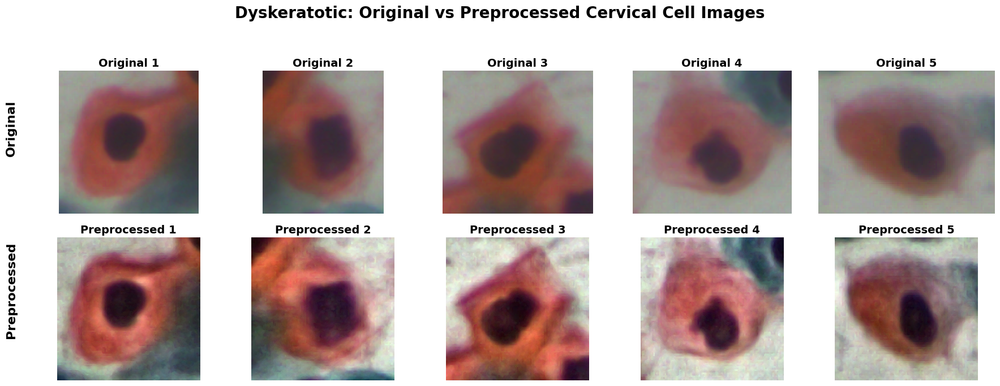

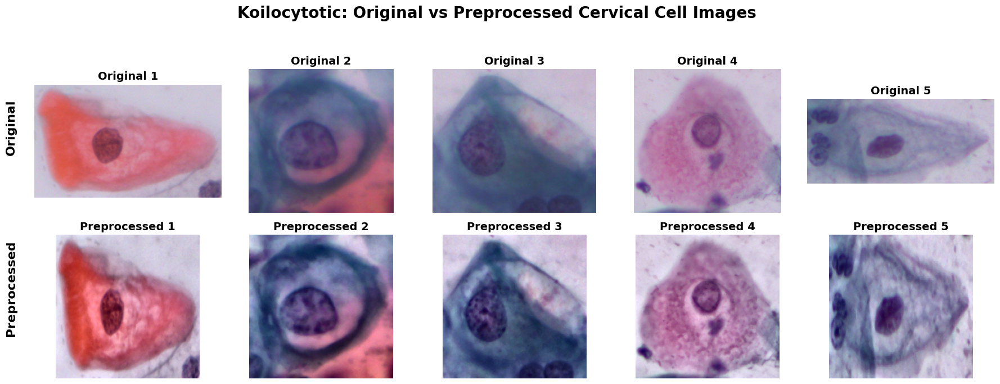

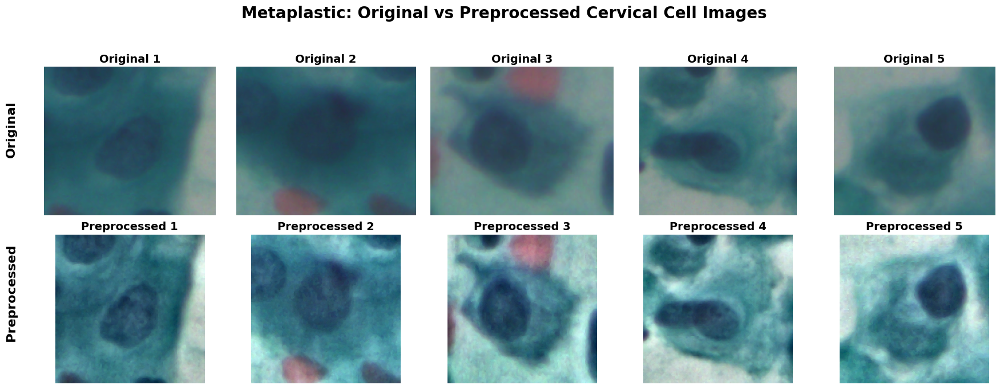

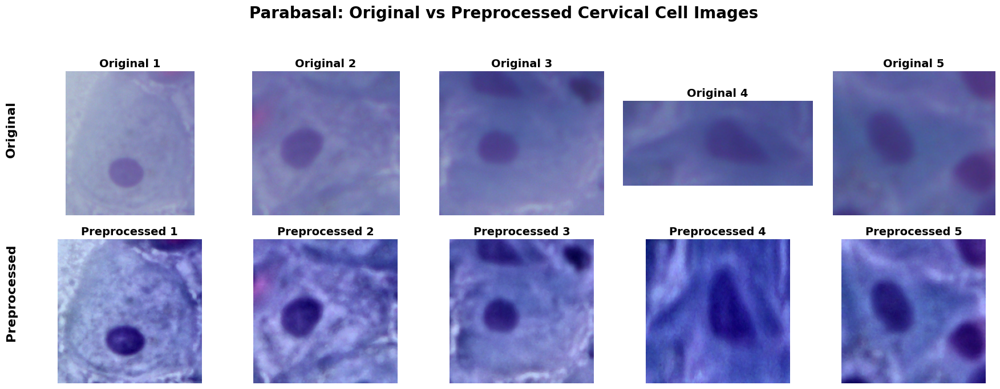

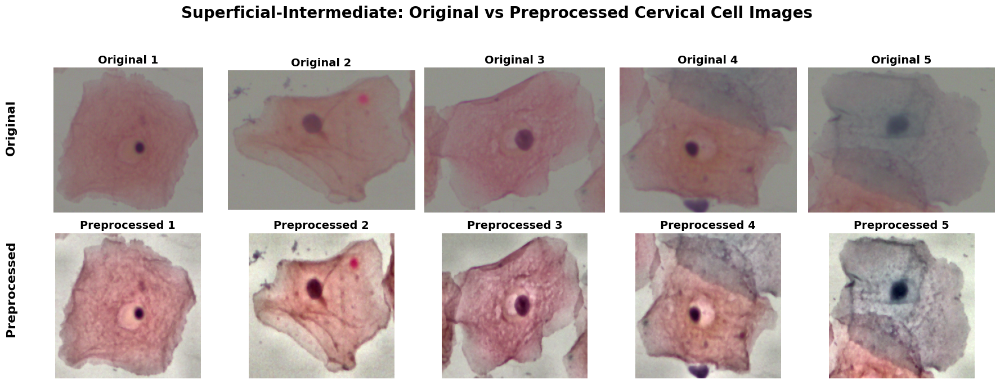

In [ ]:


import os
import cv2
import matplotlib.pyplot as plt



ORIGINAL_PATH = (
    "/kaggle/working/"
    "SIPaKMeD_Deduplicated"
)

PREPROCESSED_PATH = (
    "/kaggle/working/"
    "SIPaKMeD_Preprocessed"
)

# Use Training split for visualization
SPLIT_NAME = "Training"


IMAGE_EXTENSIONS = (
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff"
)



NUM_IMAGES_PER_CLASS = 5


def read_rgb(
    image_path
):

    image = cv2.imread(
        image_path,
        cv2.IMREAD_COLOR
    )

    if image is None:

        raise ValueError(
            f"Could not read image: {image_path}"
        )

    image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    return image



def find_matched_pairs(
    class_name,
    num_pairs=5
):

    original_class_path = os.path.join(
        ORIGINAL_PATH,
        SPLIT_NAME,
        class_name
    )

    preprocessed_class_path = os.path.join(
        PREPROCESSED_PATH,
        SPLIT_NAME,
        class_name
    )


    if not os.path.isdir(
        original_class_path
    ):

        raise FileNotFoundError(
            f"Original class folder not found: "
            f"{original_class_path}"
        )


    if not os.path.isdir(
        preprocessed_class_path
    ):

        raise FileNotFoundError(
            f"Preprocessed class folder not found: "
            f"{preprocessed_class_path}"
        )


    # --------------------------------------------------------
    # GET ORIGINAL IMAGES
    # --------------------------------------------------------

    original_images = sorted([
        filename

        for filename in os.listdir(
            original_class_path
        )

        if filename.lower().endswith(
            IMAGE_EXTENSIONS
        )
    ])


    if len(
        original_images
    ) == 0:

        raise ValueError(
            f"No original images found for {class_name}"
        )


    # --------------------------------------------------------
    # FIND MATCHED PAIRS
    # --------------------------------------------------------

    matched_pairs = []


    for original_filename in original_images:

        base_name = os.path.splitext(
            original_filename
        )[0]


        # Preprocessed images were saved as PNG
        preprocessed_filename = (
            base_name
            +
            ".png"
        )


        original_image_path = os.path.join(
            original_class_path,
            original_filename
        )


        preprocessed_image_path = os.path.join(
            preprocessed_class_path,
            preprocessed_filename
        )


        # ----------------------------------------------------
        # KEEP ONLY MATCHED ORIGINAL/PREPROCESSED PAIRS
        # ----------------------------------------------------

        if os.path.isfile(
            preprocessed_image_path
        ):

            matched_pairs.append(
                (
                    original_image_path,
                    preprocessed_image_path
                )
            )


        # ----------------------------------------------------
        # STOP AFTER REQUIRED NUMBER OF PAIRS
        # ----------------------------------------------------

        if len(
            matched_pairs
        ) >= num_pairs:

            break


    # --------------------------------------------------------
    # CHECK NUMBER OF MATCHED PAIRS
    # --------------------------------------------------------

    if len(
        matched_pairs
    ) < num_pairs:

        raise ValueError(
            f"Only {len(matched_pairs)} matched pairs found "
            f"for {class_name}. "
            f"Required: {num_pairs}"
        )


    return matched_pairs


# ============================================================
# FIND CLASSES
# ============================================================

original_split_path = os.path.join(
    ORIGINAL_PATH,
    SPLIT_NAME
)


if not os.path.isdir(
    original_split_path
):

    raise FileNotFoundError(
        f"Training split not found: "
        f"{original_split_path}"
    )


classes = sorted([
    folder

    for folder in os.listdir(
        original_split_path
    )

    if os.path.isdir(
        os.path.join(
            original_split_path,
            folder
        )
    )
])


# ============================================================
# PRINT CLASSES
# ============================================================

print(
    "Classes found:"
)


for class_name in classes:

    print(
        class_name
    )


# ============================================================
# EXPECT 5 SIPaKMeD CLASSES
# ============================================================

if len(
    classes
) != 5:

    print(
        f"\nWarning: Expected 5 classes, "
        f"but found {len(classes)}."
    )


# ============================================================
# CLEAN DISPLAY NAMES
# ============================================================

def clean_class_name(
    class_name
):

    return (
        class_name
        .replace(
            "im_",
            ""
        )
        .replace(
            "_",
            " "
        )
    )


# ============================================================
# LOAD FIVE MATCHED PAIRS FOR EACH CLASS
# ============================================================

image_pairs = {}


for class_name in classes:

    matched_paths = find_matched_pairs(
        class_name,
        num_pairs=NUM_IMAGES_PER_CLASS
    )


    image_pairs[
        class_name
    ] = []


    for (
        original_image_path,
        preprocessed_image_path
    ) in matched_paths:


        image_pairs[
            class_name
        ].append({

            "original":
                read_rgb(
                    original_image_path
                ),

            "preprocessed":
                read_rgb(
                    preprocessed_image_path
                ),

            "original_path":
                original_image_path,

            "preprocessed_path":
                preprocessed_image_path,
        })


# ============================================================
# DISPLAY FIVE MATCHED PAIRS FOR EACH CLASS
# ============================================================

for class_name in classes:

    clean_name = clean_class_name(
        class_name
    )


    # ========================================================
    # CREATE FIGURE
    # 2 ROWS × 5 COLUMNS
    #
    # Row 1 = Original
    # Row 2 = Preprocessed
    # ========================================================

    fig, axes = plt.subplots(
        2,
        NUM_IMAGES_PER_CLASS,

        figsize=(
            18,
            7
        )
    )


    # ========================================================
    # DISPLAY FIVE MATCHED PAIRS
    # ========================================================

    for col in range(
        NUM_IMAGES_PER_CLASS
    ):

        pair = image_pairs[
            class_name
        ][
            col
        ]


        # ----------------------------------------------------
        # ROW 1: ORIGINAL IMAGE
        # ----------------------------------------------------

        axes[
            0,
            col
        ].imshow(
            pair[
                "original"
            ]
        )


        axes[
            0,
            col
        ].set_title(
            f"Original {col + 1}",
            fontsize=14,
            fontweight="bold"
        )


        axes[
            0,
            col
        ].axis(
            "off"
        )


        # ----------------------------------------------------
        # ROW 2: PREPROCESSED IMAGE
        # ----------------------------------------------------

        axes[
            1,
            col
        ].imshow(
            pair[
                "preprocessed"
            ]
        )


        axes[
            1,
            col
        ].set_title(
            f"Preprocessed {col + 1}",
            fontsize=14,
            fontweight="bold"
        )


        axes[
            1,
            col
        ].axis(
            "off"
        )


    # ========================================================
    # MAIN CLASS TITLE
    # ========================================================

    plt.suptitle(
        f"{clean_name}: Original vs Preprocessed Cervical Cell Images",

        fontsize=20,

        fontweight="bold",

        y=0.99
    )


    # ========================================================
    # ADD ROW LABELS
    # ========================================================

    fig.text(
        0.015,
        0.68,
        "Original",

        fontsize=16,

        fontweight="bold",

        rotation=90,

        va="center"
    )


    fig.text(
        0.015,
        0.27,
        "Preprocessed",

        fontsize=16,

        fontweight="bold",

        rotation=90,

        va="center"
    )


    # ========================================================
    # ADJUST SPACING
    # ========================================================

    plt.tight_layout(
        rect=[
            0.035,
            0.02,
            1,
            0.94
        ],

        h_pad=1.5,

        w_pad=0.8
    )


    # ========================================================
    # DISPLAY
    # ========================================================

    plt.show()

main split

In [ ]:
import os
import shutil
import pandas as pd

from sklearn.model_selection import train_test_split


# ============================================================
# SETTINGS
# ============================================================

SEED = 42

TRAIN_RATIO = 0.80
VAL_RATIO = 0.10
TEST_RATIO = 0.10

IMAGE_EXTENSIONS = (
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff"
)


# ============================================================
# PATHS
# ============================================================

INPUT_PATH = "/kaggle/working/SIPaKMeD_Preprocessed"

MERGED_PATH = "/kaggle/working/SIPaKMeD_Merged"

SPLIT_PATH = "/kaggle/working/SIPaKMeD_Split_80_10_10"

TRAIN_OUTPUT = os.path.join(
    SPLIT_PATH,
    "train"
)

VAL_OUTPUT = os.path.join(
    SPLIT_PATH,
    "val"
)

TEST_OUTPUT = os.path.join(
    SPLIT_PATH,
    "test"
)

MANIFEST_PATH = os.path.join(
    SPLIT_PATH,
    "split_manifest.csv"
)


# ============================================================
# FIND CLASSES
# ============================================================

original_train_path = os.path.join(
    INPUT_PATH,
    "Training"
)

classes = sorted([
    folder
    for folder in os.listdir(original_train_path)
    if os.path.isdir(
        os.path.join(
            original_train_path,
            folder
        )
    )
])

print("Classes found:")

for cls in classes:
    print(cls)


# ============================================================
# REMOVE OLD OUTPUTS
# ============================================================

if os.path.exists(MERGED_PATH):
    shutil.rmtree(MERGED_PATH)

if os.path.exists(SPLIT_PATH):
    shutil.rmtree(SPLIT_PATH)


# ============================================================
# CREATE MERGED CLASS FOLDERS
# ============================================================

for cls in classes:

    os.makedirs(
        os.path.join(
            MERGED_PATH,
            cls
        ),
        exist_ok=True
    )


# ============================================================
# MERGE ORIGINAL TRAINING + TEST
# ============================================================

merge_records = []


for source_split in [
    "Training",
    "Test"
]:

    source_split_path = os.path.join(
        INPUT_PATH,
        source_split
    )

    for cls in classes:

        source_class_path = os.path.join(
            source_split_path,
            cls
        )

        images = sorted([
            filename
            for filename in os.listdir(
                source_class_path
            )
            if filename.lower().endswith(
                IMAGE_EXTENSIONS
            )
        ])

        for filename in images:

            source_path = os.path.join(
                source_class_path,
                filename
            )

            extension = os.path.splitext(
                filename
            )[1]

            stem = os.path.splitext(
                filename
            )[0]

            # Prevent filename collision
            merged_filename = (
                f"{source_split}__"
                f"{stem}"
                f"{extension.lower()}"
            )

            destination_path = os.path.join(
                MERGED_PATH,
                cls,
                merged_filename
            )

            shutil.copy2(
                source_path,
                destination_path
            )

            merge_records.append({
                "class": cls,
                "original_source": source_split,
                "original_filename": filename,
                "merged_filename": merged_filename,
                "merged_path": destination_path
            })


merged_df = pd.DataFrame(
    merge_records
)


# ============================================================
# PRINT MERGED COUNTS
# ============================================================

print(
    "\n"
    + "=" * 70
)

print(
    "MERGED DATASET"
)

print(
    "=" * 70
)

merged_total = 0

for cls in classes:

    count = len(
        merged_df[
            merged_df["class"] == cls
        ]
    )

    merged_total += count

    print(
        f"{cls}: {count}"
    )

print(
    f"\nTotal merged images: {merged_total}"
)



train_df, temp_df = train_test_split(
    merged_df,
    test_size=0.20,
    random_state=SEED,
    stratify=merged_df["class"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_df["class"]
)



train_df = train_df.copy()
val_df = val_df.copy()
test_df = test_df.copy()

train_df["new_split"] = "train"
val_df["new_split"] = "val"
test_df["new_split"] = "test"


for output_root in [
    TRAIN_OUTPUT,
    VAL_OUTPUT,
    TEST_OUTPUT
]:

    for cls in classes:

        os.makedirs(
            os.path.join(
                output_root,
                cls
            ),
            exist_ok=True
        )



def copy_split(split_df, output_root):

    for _, row in split_df.iterrows():

        source = row[
            "merged_path"
        ]

        destination = os.path.join(
            output_root,
            row["class"],
            row["merged_filename"]
        )

        shutil.copy2(
            source,
            destination
        )


copy_split(
    train_df,
    TRAIN_OUTPUT
)

copy_split(
    val_df,
    VAL_OUTPUT
)

copy_split(
    test_df,
    TEST_OUTPUT
)



manifest_df = pd.concat(
    [
        train_df,
        val_df,
        test_df
    ],
    ignore_index=True
)

manifest_df.to_csv(
    MANIFEST_PATH,
    index=False
)


def print_split_counts(
    name,
    dataframe
):

    print(
        "\n" + name
    )

    print(
        "-" * 55
    )

    for cls in classes:

        count = len(
            dataframe[
                dataframe["class"] == cls
            ]
        )

        print(
            f"{cls}: {count}"
        )

    print(
        f"Total: {len(dataframe)}"
    )


print(
    "\n"
    + "=" * 70
)

print(
    "NEW STRATIFIED 80/10/10 SPLIT"
)

print(
    "=" * 70
)

print(
    f"\nSeed: {SEED}"
)

print_split_counts(
    "TRAIN (80%)",
    train_df
)

print_split_counts(
    "VALIDATION (10%)",
    val_df
)

print_split_counts(
    "TEST (10%)",
    test_df
)




print(
    "\nTotal after split:",
    len(train_df)
    +
    len(val_df)
    +
    len(test_df)
)

print(
    "Expected total:",
    len(merged_df)
)


# ============================================================
# FINAL PATHS
# ============================================================

print(
    "\n"
    + "=" * 70
)

print(
    "OUTPUT PATHS"
)

print(
    "=" * 70
)

print(
    "\nMerged dataset:"
)

print(
    MERGED_PATH
)

print(
    "\nTraining:"
)

print(
    TRAIN_OUTPUT
)

print(
    "\nValidation:"
)

print(
    VAL_OUTPUT
)

print(
    "\nTest:"
)

print(
    TEST_OUTPUT
)

print(
    "\nManifest:"
)

print(
    MANIFEST_PATH
)

Classes found:
im_Dyskeratotic
im_Koilocytotic
im_Metaplastic
im_Parabasal
im_Superficial-Intermediate

MERGED DATASET
im_Dyskeratotic: 813
im_Koilocytotic: 825
im_Metaplastic: 793
im_Parabasal: 787
im_Superficial-Intermediate: 831

Total merged images: 4049

NEW STRATIFIED 80/10/10 SPLIT

Seed: 42

TRAIN (80%)
-------------------------------------------------------
im_Dyskeratotic: 650
im_Koilocytotic: 660
im_Metaplastic: 634
im_Parabasal: 630
im_Superficial-Intermediate: 665
Total: 3239

VALIDATION (10%)
-------------------------------------------------------
im_Dyskeratotic: 81
im_Koilocytotic: 83
im_Metaplastic: 79
im_Parabasal: 79
im_Superficial-Intermediate: 83
Total: 405

TEST (10%)
-------------------------------------------------------
im_Dyskeratotic: 82
im_Koilocytotic: 82
im_Metaplastic: 80
im_Parabasal: 78
im_Superficial-Intermediate: 83
Total: 405

Total after split: 4049
Expected total: 4049

OUTPUT PATHS

Merged dataset:
/kaggle/working/SIPaKMeD_Merged

Training:
/kaggl

Augmentation

In [ ]:
import os
import shutil
import random
import numpy as np

from PIL import Image, ImageEnhance
from torchvision.transforms import functional as TF
from torchvision.transforms import InterpolationMode



SEED = 42

random.seed(SEED)
np.random.seed(SEED)


INPUT_TRAIN_PATH = (
    "/kaggle/working/SIPaKMeD_Split_80_10_10/train"
)

OUTPUT_TRAIN_PATH = (
    "/kaggle/working/"
    "SIPaKMeD_Train_Double_Augmented"
)

IMAGE_EXTENSIONS = (
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff"
)


# 1. Rotation
ROTATION_RANGE = 15

# 2. Zoom
ZOOM_MIN = 0.90
ZOOM_MAX = 1.10

# 3. Horizontal flip
HORIZONTAL_FLIP_PROB = 0.50

# 4. Vertical flip
VERTICAL_FLIP_PROB = 0.50

# 5. Brightness + contrast
BRIGHTNESS_MIN = 0.90
BRIGHTNESS_MAX = 1.10

CONTRAST_MIN = 0.90
CONTRAST_MAX = 1.10


if os.path.exists(
    OUTPUT_TRAIN_PATH
):
    shutil.rmtree(
        OUTPUT_TRAIN_PATH
    )

os.makedirs(
    OUTPUT_TRAIN_PATH,
    exist_ok=True
)


# ============================================================
# FIND CLASSES
# ============================================================

classes = sorted([
    folder

    for folder in os.listdir(
        INPUT_TRAIN_PATH
    )

    if os.path.isdir(
        os.path.join(
            INPUT_TRAIN_PATH,
            folder
        )
    )
])

print(
    "Classes:",
    classes
)


# ============================================================
# AUGMENTATION FUNCTION
# ============================================================

def augment_image(
    image
):

    image = image.convert(
        "RGB"
    )

    image_array = np.asarray(
        image
    )

    # Use median image color as fill.
    # This avoids unnatural black corners after rotation/zoom.
    median_color = tuple(
        np.median(
            image_array.reshape(
                -1,
                3
            ),
            axis=0
        ).astype(
            np.uint8
        )
    )


    # --------------------------------------------------------
    # 1. RANDOM ROTATION
    # --------------------------------------------------------

    rotation_angle = random.uniform(
        -ROTATION_RANGE,
        ROTATION_RANGE
    )


    # --------------------------------------------------------
    # 2. RANDOM ZOOM
    # --------------------------------------------------------

    zoom_scale = random.uniform(
        ZOOM_MIN,
        ZOOM_MAX
    )


    # Rotation + zoom
    image = TF.affine(
        image,

        angle=
            rotation_angle,

        translate=
            [0, 0],

        scale=
            zoom_scale,

        shear=
            [0.0, 0.0],

        interpolation=
            InterpolationMode.BILINEAR,

        fill=
            median_color
    )


    # --------------------------------------------------------
    # 3. HORIZONTAL FLIP
    # --------------------------------------------------------

    if random.random() < HORIZONTAL_FLIP_PROB:

        image = TF.hflip(
            image
        )


    # --------------------------------------------------------
    # 4. VERTICAL FLIP
    # --------------------------------------------------------

    if random.random() < VERTICAL_FLIP_PROB:

        image = TF.vflip(
            image
        )


    # --------------------------------------------------------
    # 5. BRIGHTNESS + CONTRAST
    # --------------------------------------------------------

    brightness_factor = random.uniform(
        BRIGHTNESS_MIN,
        BRIGHTNESS_MAX
    )

    contrast_factor = random.uniform(
        CONTRAST_MIN,
        CONTRAST_MAX
    )

    image = ImageEnhance.Brightness(
        image
    ).enhance(
        brightness_factor
    )

    image = ImageEnhance.Contrast(
        image
    ).enhance(
        contrast_factor
    )

    return image


# ============================================================
# COUNTERS
# ============================================================

original_counts = {}

augmented_counts = {}

final_counts = {}


# ============================================================
# CREATE ORIGINAL + AUGMENTED DATASET
# ============================================================

for class_name in classes:

    input_class_path = os.path.join(
        INPUT_TRAIN_PATH,
        class_name
    )

    output_class_path = os.path.join(
        OUTPUT_TRAIN_PATH,
        class_name
    )

    os.makedirs(
        output_class_path,
        exist_ok=True
    )


    image_files = sorted([
        filename

        for filename in os.listdir(
            input_class_path
        )

        if filename.lower().endswith(
            IMAGE_EXTENSIONS
        )
    ])


    original_count = 0
    augmented_count = 0


    for filename in image_files:

        image_path = os.path.join(
            input_class_path,
            filename
        )

        try:

            image = Image.open(
                image_path
            ).convert(
                "RGB"
            )

        except Exception as error:

            print(
                "Failed:",
                image_path,
                error
            )

            continue


        original_stem = os.path.splitext(
            filename
        )[0]


        # ====================================================
        # SAVE ORIGINAL COPY
        # ====================================================

        original_output_path = os.path.join(
            output_class_path,
            original_stem
            +
            "_original.png"
        )

        image.save(
            original_output_path,
            format="PNG"
        )

        original_count += 1


        # ====================================================
        # CREATE ONE AUGMENTED COPY
        # ====================================================

        augmented_image = augment_image(
            image
        )

        augmented_output_path = os.path.join(
            output_class_path,
            original_stem
            +
            "_aug1.png"
        )

        augmented_image.save(
            augmented_output_path,
            format="PNG"
        )

        augmented_count += 1


    original_counts[
        class_name
    ] = original_count

    augmented_counts[
        class_name
    ] = augmented_count

    final_counts[
        class_name
    ] = (
        original_count
        +
        augmented_count
    )


# ============================================================
# PRINT RESULTS
# ============================================================

print(
    "\n"
    +
    "=" * 70
)

print(
    "SIPaKMeD TRAINING AUGMENTATION COMPLETE"
)

print(
    "=" * 70
)


print(
    "\nAugmentation settings:"
)

print(
    f"1. Rotation          : "
    f"±{ROTATION_RANGE} degrees"
)

print(
    f"2. Zoom              : "
    f"{ZOOM_MIN} - {ZOOM_MAX}"
)

print(
    f"3. Horizontal Flip   : "
    f"p={HORIZONTAL_FLIP_PROB}"
)

print(
    f"4. Vertical Flip     : "
    f"p={VERTICAL_FLIP_PROB}"
)

print(
    f"5. Brightness        : "
    f"{BRIGHTNESS_MIN} - {BRIGHTNESS_MAX}"
)

print(
    f"   Contrast          : "
    f"{CONTRAST_MIN} - {CONTRAST_MAX}"
)


# ============================================================
# ORIGINAL COUNTS
# ============================================================

print(
    "\nOriginal training images:"
)

original_total = 0

for class_name in classes:

    count = original_counts[
        class_name
    ]

    original_total += count

    print(
        f"{class_name}: "
        f"{count}"
    )

print(
    f"Total original: "
    f"{original_total}"
)


# ============================================================
# AUGMENTED COUNTS
# ============================================================

print(
    "\nNew augmented images:"
)

augmented_total = 0

for class_name in classes:

    count = augmented_counts[
        class_name
    ]

    augmented_total += count

    print(
        f"{class_name}: "
        f"{count}"
    )

print(
    f"Total augmented: "
    f"{augmented_total}"
)


# ============================================================
# FINAL COUNTS
# ============================================================

print(
    "\nFinal training dataset "
    "(Original + Augmented):"
)

final_total = 0

for class_name in classes:

    count = final_counts[
        class_name
    ]

    final_total += count

    print(
        f"{class_name}: "
        f"{count}"
    )

print(
    f"Total final training images: "
    f"{final_total}"
)


print(
    "\nIncrease:"
)

print(
    f"{original_total} "
    f"-> "
    f"{final_total}"
)

print(
    f"Dataset multiplication: "
    f"{final_total/original_total:.1f}x"
)


print(
    "\nAugmented training dataset saved at:"
)

print(
    OUTPUT_TRAIN_PATH
)

Classes: ['im_Dyskeratotic', 'im_Koilocytotic', 'im_Metaplastic', 'im_Parabasal', 'im_Superficial-Intermediate']

SIPaKMeD TRAINING AUGMENTATION COMPLETE

Augmentation settings:
1. Rotation          : ±15 degrees
2. Zoom              : 0.9 - 1.1
3. Horizontal Flip   : p=0.5
4. Vertical Flip     : p=0.5
5. Brightness        : 0.9 - 1.1
   Contrast          : 0.9 - 1.1

Original training images:
im_Dyskeratotic: 650
im_Koilocytotic: 660
im_Metaplastic: 634
im_Parabasal: 630
im_Superficial-Intermediate: 665
Total original: 3239

New augmented images:
im_Dyskeratotic: 650
im_Koilocytotic: 660
im_Metaplastic: 634
im_Parabasal: 630
im_Superficial-Intermediate: 665
Total augmented: 3239

Final training dataset (Original + Augmented):
im_Dyskeratotic: 1300
im_Koilocytotic: 1320
im_Metaplastic: 1268
im_Parabasal: 1260
im_Superficial-Intermediate: 1330
Total final training images: 6478

Increase:
3239 -> 6478
Dataset multiplication: 2.0x

Augmented training dataset saved at:
/kaggle/working/SIPa

# **baseline**

In [43]:
# %% BLOCK 1

# ============================================================
# BLOCK 1 - IMPORTS, DATA, SHARED FUNCTIONS
# Six SIPaKMeD baselines: 3 CNN + 3 Transformer
# ============================================================
import os, sys, gc, time, random, warnings, subprocess
from copy import deepcopy
import numpy as np
import pandas as pd
import psutil
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix, cohen_kappa_score,
    matthews_corrcoef, roc_auc_score, roc_curve, average_precision_score,
    log_loss, top_k_accuracy_score,
)
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder
warnings.filterwarnings('ignore')

try:
    import timm
except ImportError:
    subprocess.check_call([sys.executable,'-m','pip','install','-q','timm'])
    import timm

BASE_TRAIN_PATH='/kaggle/working/SIPaKMeD_Split_80_10_10/train'
AUG_TRAIN_PATH='/kaggle/working/SIPaKMeD_Train_Double_Augmented'
VAL_PATH='/kaggle/working/SIPaKMeD_Split_80_10_10/val'
TEST_PATH='/kaggle/working/SIPaKMeD_Split_80_10_10/test'
BASELINE_ROOT='/kaggle/working/SIPaKMeD_6_Baselines'
os.makedirs(BASELINE_ROOT,exist_ok=True)
RESULTS={}
MEAN=[0.485,0.456,0.406]; STD=[0.229,0.224,0.225]
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
AMP_ENABLED=device.type=='cuda'
print('Device:',device)

def seed_everything(seed=42):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    os.environ['PYTHONHASHSEED']=str(seed)
    torch.backends.cudnn.deterministic=True; torch.backends.cudnn.benchmark=False

class ImageFolderWithPath(ImageFolder):
    def __getitem__(self,index):
        image,target=super().__getitem__(index)
        return image,target,self.samples[index][0]

def build_data(hp):
    train_path=AUG_TRAIN_PATH if os.path.isdir(AUG_TRAIN_PATH) else BASE_TRAIN_PATH
    for p in [train_path,VAL_PATH,TEST_PATH]:
        if not os.path.isdir(p): raise FileNotFoundError(p)
    if train_path==AUG_TRAIN_PATH:
        train_tf=transforms.Compose([
            transforms.Resize((hp['IMAGE_SIZE'],hp['IMAGE_SIZE'])),
            transforms.ToTensor(),transforms.Normalize(MEAN,STD)])
    else:
        train_tf=transforms.Compose([
            transforms.Resize((hp['IMAGE_SIZE'],hp['IMAGE_SIZE'])),
            transforms.RandomHorizontalFlip(.5),transforms.RandomVerticalFlip(.5),
            transforms.RandomRotation(7,fill=255),
            transforms.RandomAffine(0,translate=(.03,.03),scale=(.97,1.03),fill=255),
            transforms.ColorJitter(.05,.05,.03,.01),
            transforms.ToTensor(),transforms.Normalize(MEAN,STD)])
    eval_tf=transforms.Compose([
        transforms.Resize((hp['IMAGE_SIZE'],hp['IMAGE_SIZE'])),
        transforms.ToTensor(),transforms.Normalize(MEAN,STD)])
    tr=ImageFolderWithPath(train_path,transform=train_tf)
    tre=ImageFolderWithPath(train_path,transform=eval_tf)
    va=ImageFolderWithPath(VAL_PATH,transform=eval_tf)
    te=ImageFolderWithPath(TEST_PATH,transform=eval_tf)
    assert tr.class_to_idx==va.class_to_idx==te.class_to_idx
    print(f"Detected {len(tr.classes)} classes: {tr.classes}")
    print('Class mapping:',tr.class_to_idx)
    print(f'Train images: {len(tr)} | Val images: {len(va)} | Test images: {len(te)}')
    g=torch.Generator(); g.manual_seed(hp['SEED'])
    def seed_worker(w):
        s=hp['SEED']+w; np.random.seed(s); random.seed(s)
    kw=dict(batch_size=hp['BATCH_SIZE'],num_workers=hp['NUM_WORKERS'],pin_memory=AMP_ENABLED)
    if hp['NUM_WORKERS']>0: kw['persistent_workers']=True
    return {
        'train_ds':tr,'train_eval_ds':tre,'val_ds':va,'test_ds':te,
        'train_loader':DataLoader(tr,shuffle=True,generator=g,worker_init_fn=seed_worker,**kw),
        'train_eval_loader':DataLoader(tre,shuffle=False,**kw),
        'val_loader':DataLoader(va,shuffle=False,**kw),
        'test_loader':DataLoader(te,shuffle=False,**kw),
        'class_names':tr.classes,'class_to_idx':tr.class_to_idx,'num_classes':len(tr.classes)
    }

class TimmBaseline(nn.Module):
    def __init__(self,candidates,num_classes,dropout=.2):
        super().__init__(); self.model=None; self.selected_name=None; last=None
        for name in candidates:
            try:
                self.model=timm.create_model(name,pretrained=True,num_classes=num_classes,drop_rate=dropout)
                self.selected_name=name; print('Initialized ImageNet pretrained model:',name); break
            except Exception as e: last=e
        if self.model is None:
            print('Warning: pretrained weights unavailable; trying random initialization.')
            for name in candidates:
                try:
                    self.model=timm.create_model(name,pretrained=False,num_classes=num_classes,drop_rate=dropout)
                    self.selected_name=name; print('Random initialization:',name); break
                except Exception as e: last=e
        if self.model is None: raise RuntimeError(last)
        head=self.model.get_classifier()
        if not isinstance(head,nn.Module): raise RuntimeError('Classifier module not found')
        self.head_ids={id(p) for p in head.parameters()}
    def forward(self,x): return self.model(x)
    def backbone_parameters(self): return [p for p in self.model.parameters() if id(p) not in self.head_ids]
    def head_parameters(self): return [p for p in self.model.parameters() if id(p) in self.head_ids]
    def freeze_backbone(self):
        for p in self.backbone_parameters(): p.requires_grad=False
        for p in self.head_parameters(): p.requires_grad=True
    def unfreeze_all(self):
        for p in self.model.parameters(): p.requires_grad=True

def ac():
    try: return torch.amp.autocast(device_type=device.type,enabled=AMP_ENABLED)
    except Exception: return torch.cuda.amp.autocast(enabled=AMP_ENABLED)

@torch.no_grad()
def update_ema(dst,src,decay):
    ds=dst.state_dict(); ss=src.state_dict()
    for k in ds:
        if torch.is_floating_point(ds[k]): ds[k].mul_(decay).add_(ss[k].detach(),alpha=1-decay)
        else: ds[k].copy_(ss[k])

def build_optimizer(model,hp):
    opt=torch.optim.AdamW([
        {'params':model.backbone_parameters(),'lr':hp['BACKBONE_LR']},
        {'params':model.head_parameters(),'lr':hp['HEAD_LR']}],weight_decay=hp['WEIGHT_DECAY'])
    sch=torch.optim.lr_scheduler.CosineAnnealingLR(opt,T_max=hp['MAX_EPOCHS'],eta_min=1e-6)
    try: scaler=torch.amp.GradScaler('cuda',enabled=AMP_ENABLED)
    except TypeError: scaler=torch.cuda.amp.GradScaler(enabled=AMP_ENABLED)
    return opt,sch,scaler

def train_epoch(model,ema,loader,opt,scaler,criterion,hp):
    model.train(); ls=correct=total=0
    for x,y,_ in loader:
        x=x.to(device,non_blocking=True); y=y.to(device,non_blocking=True); opt.zero_grad(set_to_none=True)
        with ac(): z=model(x); loss=criterion(z,y)
        scaler.scale(loss).backward(); scaler.unscale_(opt); torch.nn.utils.clip_grad_norm_(model.parameters(),5.0)
        scaler.step(opt); scaler.update(); update_ema(ema,model,hp['EMA_DECAY'])
        ls+=loss.item()*x.size(0); correct+=(z.argmax(1)==y).sum().item(); total+=y.size(0)
    return ls/total,correct/total

@torch.no_grad()
def val_epoch(model,loader,criterion):
    model.eval(); ls=correct=total=0; ys=[]; ps=[]
    for x,y,_ in loader:
        x=x.to(device,non_blocking=True); y=y.to(device,non_blocking=True)
        with ac(): z=model(x); loss=criterion(z,y)
        p=z.argmax(1); ls+=loss.item()*x.size(0); correct+=(p==y).sum().item(); total+=y.size(0)
        ys.append(y.cpu().numpy()); ps.append(p.cpu().numpy())
    yy=np.concatenate(ys); pp=np.concatenate(ps)
    return ls/total,correct/total,f1_score(yy,pp,average='macro',zero_division=0)

@torch.no_grad()
def tta_logits(model,x,use_tta=False):
    xs=[x]
    if use_tta: xs += [torch.flip(x,[3]),torch.flip(x,[2]),torch.flip(x,[2,3])]
    out=[]
    for v in xs:
        with ac(): out.append(model(v).float())
    return torch.stack(out).mean(0)

@torch.no_grad()
def collect(model,loader,use_tta=False):
    model.eval(); ys=[]; zs=[]; paths=[]
    for x,y,p in loader:
        x=x.to(device,non_blocking=True); z=tta_logits(model,x,use_tta)
        ys.append(y.numpy()); zs.append(z.cpu().numpy()); paths.extend(list(p))
    return {'y':np.concatenate(ys),'logits':np.concatenate(zs),'paths':paths}

class TempScaler(nn.Module):
    def __init__(self): super().__init__(); self.log_t=nn.Parameter(torch.zeros(1))
    def forward(self,z): return z/torch.exp(self.log_t).clamp(.05,10.0)
    @property
    def temperature(self): return float(torch.exp(self.log_t).clamp(.05,10.0).detach().cpu())

def fit_temp(z,y):
    tm=TempScaler().to(device); zt=torch.tensor(z,dtype=torch.float32,device=device); yt=torch.tensor(y,dtype=torch.long,device=device)
    opt=torch.optim.LBFGS(tm.parameters(),lr=.05,max_iter=50,line_search_fn='strong_wolfe')
    def closure():
        opt.zero_grad(); loss=F.cross_entropy(tm(zt),yt); loss.backward(); return loss
    opt.step(closure); return tm.temperature

def softmax_np(z,t=1.0):
    z=z/float(t); z=z-z.max(1,keepdims=True); e=np.exp(z); return e/e.sum(1,keepdims=True)

def onehot(y,nc): return np.eye(nc,dtype=np.float64)[y]

def ece_calc(y,p,n_bins=15):
    conf=p.max(1); pred=p.argmax(1); corr=(pred==y).astype(float); edges=np.linspace(0,1,n_bins+1); ece=0; rows=[]
    for i in range(n_bins):
        lo,hi=edges[i],edges[i+1]; m=((conf>=lo)&(conf<=hi)) if i==0 else ((conf>lo)&(conf<=hi))
        if not m.any(): rows.append([lo,hi,0,np.nan,np.nan]); continue
        a=float(corr[m].mean()); c=float(conf[m].mean()); ece+=(m.sum()/len(y))*abs(a-c); rows.append([lo,hi,int(m.sum()),a,c])
    return float(ece),pd.DataFrame(rows,columns=['bin_low','bin_high','count','accuracy','confidence'])

def clinical(y,pred,nc):
    cm=confusion_matrix(y,pred,labels=np.arange(nc)); total=cm.sum(); ppv=[];npv=[];sens=[];spec=[]
    for i in range(nc):
        tp=cm[i,i]; fn=cm[i].sum()-tp; fp=cm[:,i].sum()-tp; tn=total-tp-fn-fp
        ppv.append(tp/(tp+fp) if tp+fp else 0); npv.append(tn/(tn+fn) if tn+fn else 0)
        sens.append(tp/(tp+fn) if tp+fn else 0); spec.append(tn/(tn+fp) if tn+fp else 0)
    return {'Mean PPV':np.mean(ppv),'Mean NPV':np.mean(npv),'Sensitivity':np.mean(sens),'Specificity':np.mean(spec)}

def bootstrap(y,p,nc,n=2000,seed=42):
    rng=np.random.default_rng(seed); accs=[]; f1s=[]; aucs=[]; N=len(y)
    for _ in range(n):
        idx=rng.integers(0,N,N); yy=y[idx]; pp=p[idx]
        if len(np.unique(yy))<nc: continue
        pr=pp.argmax(1); accs.append(accuracy_score(yy,pr)); f1s.append(f1_score(yy,pr,average='macro',zero_division=0))
        try: aucs.append(roc_auc_score(onehot(yy,nc),pp,multi_class='ovr',average='macro'))
        except ValueError: pass
    q=lambda a,alpha:tuple(np.quantile(np.asarray(a,float),[alpha/2,1-alpha/2]))
    return {'acc95':q(accs,.05),'acc99':q(accs,.01),'f195':q(f1s,.05),'f199':q(f1s,.01),'auc95':q(aucs,.05),'auc99':q(aucs,.01)}

def estimate_gflops(model,image_size):
    try:
        try: from fvcore.nn import FlopCountAnalysis
        except ImportError:
            subprocess.check_call([sys.executable,'-m','pip','install','-q','fvcore'])
            from fvcore.nn import FlopCountAnalysis
        dummy=torch.randn(1,3,image_size,image_size,device=device); model.eval(); fa=FlopCountAnalysis(model,dummy)
        try: fa.unsupported_ops_warnings(False); fa.uncalled_modules_warnings(False)
        except Exception: pass
        return float(fa.total())/1e9
    except Exception as e:
        print('GFLOPs calculation warning:',e); return float('nan')

@torch.no_grad()
def benchmark(model,loader,use_tta):
    first=next(iter(loader))[0].to(device,non_blocking=True)
    for _ in range(3): _=tta_logits(model,first,use_tta)
    if AMP_ENABLED: torch.cuda.synchronize(); torch.cuda.reset_peak_memory_stats()
    n=0; t=time.perf_counter()
    for x,_,_ in loader:
        x=x.to(device,non_blocking=True); _=tta_logits(model,x,use_tta); n+=x.size(0)
    if AMP_ENABLED: torch.cuda.synchronize()
    elapsed=time.perf_counter()-t; gpu=torch.cuda.max_memory_allocated()/(1024**2) if AMP_ENABLED else 0; ram=psutil.Process(os.getpid()).memory_info().rss/(1024**2)
    return elapsed,elapsed/n,n/elapsed,gpu,ram

def make_figures(model_name,outdir,history,y,pred,probs,cm,class_names,cal_df,ece):
    nc=len(class_names); yoh=onehot(y,nc); names=[c.replace('im_','') for c in class_names]; conf=probs.max(1)
    # Figure 1
    ep=np.arange(1,len(history['train_loss'])+1); fig,ax=plt.subplots(1,2,figsize=(12,4.5))
    ax[0].plot(ep,history['train_loss'],label='Train Loss'); ax[0].plot(ep,history['val_loss'],label='Validation Loss'); ax[0].set(xlabel='Epoch',ylabel='Loss',title='Training and Validation Loss'); ax[0].legend()
    ax[1].plot(ep,history['train_acc'],label='Train Accuracy'); ax[1].plot(ep,history['val_acc'],label='Validation Accuracy'); ax[1].set(xlabel='Epoch',ylabel='Accuracy',title='Training and Validation Accuracy'); ax[1].legend(); plt.tight_layout(); plt.savefig(os.path.join(outdir,'Figure1_Training_Curves.png'),dpi=300,bbox_inches='tight'); plt.show()
    # Figure 2 blue-white
    fig,ax=plt.subplots(figsize=(8,7)); im=ax.imshow(cm,cmap='Blues'); ax.set_xticks(np.arange(nc)); ax.set_yticks(np.arange(nc)); ax.set_xticklabels(names,rotation=45,ha='right'); ax.set_yticklabels(names); ax.set_xlabel('Predicted Class'); ax.set_ylabel('True Class'); ax.set_title(f'{model_name} Test Confusion Matrix'); th=cm.max()/2
    for i in range(nc):
        for j in range(nc): ax.text(j,i,int(cm[i,j]),ha='center',va='center',color='white' if cm[i,j]>th else 'black')
    fig.colorbar(im,ax=ax); plt.tight_layout(); plt.savefig(os.path.join(outdir,'Figure2_Test_Confusion_Matrix.png'),dpi=300,bbox_inches='tight'); plt.show()
    # Figure 3 ROC
    plt.figure(figsize=(8,7)); all_fpr=np.unique(np.concatenate([roc_curve(yoh[:,i],probs[:,i])[0] for i in range(nc)])); mean_tpr=np.zeros_like(all_fpr)
    for i,c in enumerate(class_names):
        fpr,tpr,_=roc_curve(yoh[:,i],probs[:,i]); ai=roc_auc_score(yoh[:,i],probs[:,i]); mean_tpr+=np.interp(all_fpr,fpr,tpr); plt.plot(fpr,tpr,label=f'{c.replace("im_","")} (AUC={ai:.4f})')
    mean_tpr/=nc
    try: ma=np.trapezoid(mean_tpr,all_fpr)
    except AttributeError: ma=np.trapz(mean_tpr,all_fpr)
    plt.plot(all_fpr,mean_tpr,linewidth=2.5,label=f'Macro-average (AUC={ma:.4f})'); plt.plot([0,1],[0,1],linestyle='--'); plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate'); plt.title(f'{model_name} Test ROC Curves'); plt.legend(fontsize=8); plt.tight_layout(); plt.savefig(os.path.join(outdir,'Figure3_Test_ROC.png'),dpi=300,bbox_inches='tight'); plt.show()
    # Figure 4 calibration
    valid=cal_df[cal_df['count']>0]; plt.figure(figsize=(7,6)); plt.plot([0,1],[0,1],linestyle='--',label='Perfect Calibration'); plt.plot(valid['confidence'],valid['accuracy'],marker='o',label=f'{model_name} (ECE={ece:.4f})'); plt.xlabel('Mean Confidence'); plt.ylabel('Empirical Accuracy'); plt.title(f'{model_name} Test Reliability Diagram'); plt.legend(); plt.tight_layout(); plt.savefig(os.path.join(outdir,'Figure4_Test_Calibration.png'),dpi=300,bbox_inches='tight'); plt.show()
    # Figure 5 confidence
    correct=pred==y; plt.figure(figsize=(8,6)); plt.hist(conf[correct],bins=20,alpha=.65,label='Correct')
    if np.any(~correct): plt.hist(conf[~correct],bins=20,alpha=.65,label='Incorrect')
    plt.xlabel('Maximum Predicted Probability'); plt.ylabel('Number of Samples'); plt.title(f'{model_name} Test Prediction Confidence'); plt.legend(); plt.tight_layout(); plt.savefig(os.path.join(outdir,'Figure5_Test_Confidence.png'),dpi=300,bbox_inches='tight'); plt.show()

def evaluate(model,cfg,hp,data,history,checkpoint_path,training_time,train_gpu_peak,best_epoch,best_f1):
    name=cfg['display_name']; outdir=os.path.dirname(checkpoint_path)
    tr=collect(model,data['train_eval_loader'],False); va=collect(model,data['val_loader'],hp['USE_TTA']); te=collect(model,data['test_loader'],hp['USE_TTA'])
    T=fit_temp(va['logits'],va['y'])
    for o in [tr,va,te]: o['probs_raw']=softmax_np(o['logits']); o['probs']=softmax_np(o['logits'],T); o['pred']=o['probs'].argmax(1)
    for split,o in [('Train',tr),('Val',va),('Test',te)]:
        print(f'\n{name} {split} Report:'); print(classification_report(o['y'],o['pred'],target_names=data['class_names'],digits=4,zero_division=0))
    y=te['y']; pred=te['pred']; probs=te['probs']; raw=te['probs_raw']; nc=data['num_classes']; yoh=onehot(y,nc); cm=confusion_matrix(y,pred,labels=np.arange(nc))
    rows=[]; total=cm.sum()
    for i,c in enumerate(data['class_names']):
        tp=cm[i,i]; fn=cm[i].sum()-tp; fp=cm[:,i].sum()-tp; tn=total-tp-fn-fp
        rows.append({'Class':c,'ROC AUC':roc_auc_score(yoh[:,i],probs[:,i]),'PR AUC':average_precision_score(yoh[:,i],probs[:,i]),'Precision':tp/(tp+fp) if tp+fp else 0,'Recall/Sensitivity':tp/(tp+fn) if tp+fn else 0,'Specificity':tn/(tn+fp) if tn+fp else 0,'NPV':tn/(tn+fn) if tn+fn else 0,'F1':f1_score((y==i).astype(int),(pred==i).astype(int),zero_division=0)})
    class_df=pd.DataFrame(rows); class_df.to_csv(os.path.join(outdir,f'{cfg["id"]}_classwise_metrics.csv'),index=False)
    print(f'\n{name} Class-wise AUC and diagnostic metrics:'); print(class_df.to_string(index=False,float_format=lambda x:f'{x:.4f}'))
    acc=accuracy_score(y,pred); bal=balanced_accuracy_score(y,pred); mp=precision_score(y,pred,average='macro',zero_division=0); mr=recall_score(y,pred,average='macro',zero_division=0); mf1=f1_score(y,pred,average='macro',zero_division=0); wf1=f1_score(y,pred,average='weighted',zero_division=0); kappa=cohen_kappa_score(y,pred); mcc=matthews_corrcoef(y,pred); top2=top_k_accuracy_score(y,probs,k=2,labels=np.arange(nc)); mauc=roc_auc_score(yoh,probs,multi_class='ovr',average='macro'); wauc=roc_auc_score(yoh,probs,multi_class='ovr',average='weighted'); mpra=average_precision_score(yoh,probs,average='macro'); wpra=average_precision_score(yoh,probs,average='weighted'); nll=log_loss(y,probs,labels=np.arange(nc)); brier=float(np.mean(np.sum((probs-yoh)**2,axis=1))); clin=clinical(y,pred,nc); ece_raw,_=ece_calc(y,raw); ece,cal_df=ece_calc(y,probs); chi2,chi_p,chi_dof,_=chi2_contingency(cm); boot=bootstrap(y,probs,nc,hp['BOOTSTRAPS'],hp['SEED'])
    infer_total,infer_per,throughput,infer_gpu,ram=benchmark(model,data['test_loader'],hp['USE_TTA']); total_params=sum(p.numel() for p in model.parameters()); trainable_params=sum(p.numel() for p in model.parameters() if p.requires_grad); checkpoint_mb=os.path.getsize(checkpoint_path)/(1024**2); gflops=estimate_gflops(model,hp['IMAGE_SIZE']); tta_gflops=gflops*(4 if hp['USE_TTA'] else 1) if np.isfinite(gflops) else float('nan')
    print(f'\nChi-squared: {chi2:.4f}, p-value={chi_p:.4e}, dof={chi_dof}')
    print(f'\nInference: {infer_total:.2f}s ({infer_per:.4f}s/sample) | Throughput: {throughput:.2f} img/s | GPU: {infer_gpu:.1f}MB | RAM: {ram:.1f}MB')
    print(f'\nTest Acc: {acc:.4f} | Balanced Acc: {bal:.4f} | Macro Precision: {mp:.4f} | Macro Recall: {mr:.4f} | Macro F1: {mf1:.4f} | Weighted F1: {wf1:.4f}')
    print(f'Kappa: {kappa:.4f} | MCC: {mcc:.4f} | Top-2 Acc: {top2:.4f} | Macro ROC AUC: {mauc:.4f} | Weighted ROC AUC: {wauc:.4f} | Macro PR AUC: {mpra:.4f} | Weighted PR AUC: {wpra:.4f}')
    print(f'NLL: {nll:.4f} | Brier: {brier:.4f} | Mean PPV: {clin["Mean PPV"]:.4f} | Mean NPV: {clin["Mean NPV"]:.4f} | Sensitivity: {clin["Sensitivity"]:.4f} | Specificity: {clin["Specificity"]:.4f}')
    print(f'Temperature: {T:.4f} | ECE Raw: {ece_raw:.4f} | ECE Calibrated: {ece:.4f}')
    print(f'Total Params: {total_params:,} | Trainable Params: {trainable_params:,} | Checkpoint: {checkpoint_mb:.2f} MB | Training GPU Peak: {train_gpu_peak:.1f} MB')
    print(f'Estimated GFLOPs (single {hp["IMAGE_SIZE"]}x{hp["IMAGE_SIZE"]} view): {gflops:.4f}')
    print(f'Estimated GFLOPs with current TTA ({4 if hp["USE_TTA"] else 1} views): {tta_gflops:.4f}')
    print(f'Total training time: {training_time:.2f}s ({training_time/60:.2f} min)')
    print(f'\nBootstrap Accuracy: {acc:.4f} | 95% CI: [{boot["acc95"][0]:.4f}, {boot["acc95"][1]:.4f}] | 99% CI: [{boot["acc99"][0]:.4f}, {boot["acc99"][1]:.4f}]')
    print(f'Bootstrap Macro F1: {mf1:.4f} | 95% CI: [{boot["f195"][0]:.4f}, {boot["f195"][1]:.4f}] | 99% CI: [{boot["f199"][0]:.4f}, {boot["f199"][1]:.4f}]')
    print(f'Bootstrap Macro AUC: {mauc:.4f} | 95% CI: [{boot["auc95"][0]:.4f}, {boot["auc95"][1]:.4f}] | 99% CI: [{boot["auc99"][0]:.4f}, {boot["auc99"][1]:.4f}]')
    print('Model saved:',checkpoint_path)
    summary={'Model':name,'Selected timm model':model.selected_name,'Accuracy':acc,'Balanced Accuracy':bal,'Macro Precision':mp,'Macro Recall':mr,'Macro F1':mf1,'Weighted F1':wf1,'Kappa':kappa,'MCC':mcc,'Top-2 Accuracy':top2,'Macro ROC AUC':mauc,'Weighted ROC AUC':wauc,'Macro PR AUC':mpra,'Weighted PR AUC':wpra,'NLL':nll,'Brier':brier,'Mean PPV':clin['Mean PPV'],'Mean NPV':clin['Mean NPV'],'Sensitivity':clin['Sensitivity'],'Specificity':clin['Specificity'],'Temperature':T,'ECE Raw':ece_raw,'ECE Calibrated':ece,'Chi-square':chi2,'Chi-square p-value':chi_p,'Total Params':total_params,'Trainable Params':trainable_params,'Checkpoint MB':checkpoint_mb,'GFLOPs single view':gflops,'GFLOPs TTA':tta_gflops,'Best Epoch':best_epoch,'Best Validation Macro F1':best_f1,'Training Time s':training_time,'Inference Time s':infer_total,'Inference s/sample':infer_per,'Throughput img/s':throughput,'Training GPU Peak MB':train_gpu_peak,'Inference GPU Peak MB':infer_gpu,'RAM MB':ram,'Bootstrap Acc 95 Low':boot['acc95'][0],'Bootstrap Acc 95 High':boot['acc95'][1],'Bootstrap Acc 99 Low':boot['acc99'][0],'Bootstrap Acc 99 High':boot['acc99'][1],'Bootstrap Macro F1 95 Low':boot['f195'][0],'Bootstrap Macro F1 95 High':boot['f195'][1],'Bootstrap Macro F1 99 Low':boot['f199'][0],'Bootstrap Macro F1 99 High':boot['f199'][1],'Bootstrap Macro AUC 95 Low':boot['auc95'][0],'Bootstrap Macro AUC 95 High':boot['auc95'][1],'Bootstrap Macro AUC 99 Low':boot['auc99'][0],'Bootstrap Macro AUC 99 High':boot['auc99'][1]}
    pd.DataFrame([summary]).to_csv(os.path.join(outdir,f'{cfg["id"]}_summary_metrics.csv'),index=False); cal_df.to_csv(os.path.join(outdir,f'{cfg["id"]}_calibration_bins.csv'),index=False)
    conf=probs.max(1); ent=-np.sum(probs*np.log(np.clip(probs,1e-12,1.0)),axis=1); pdf=pd.DataFrame({'path':te['paths'],'true_index':y,'true_class':[data['class_names'][i] for i in y],'pred_index':pred,'pred_class':[data['class_names'][i] for i in pred],'confidence':conf,'entropy':ent})
    for i,c in enumerate(data['class_names']): pdf[f'prob_{c.replace("im_","")}']=probs[:,i]
    pdf.to_csv(os.path.join(outdir,f'{cfg["id"]}_test_predictions.csv'),index=False); np.savez_compressed(os.path.join(outdir,f'{cfg["id"]}_test_outputs.npz'),y_true=y,y_pred=pred,probs=probs,probs_raw=raw,logits=te['logits'],class_names=np.asarray(data['class_names']),paths=np.asarray(te['paths']))
    make_figures(name,outdir,history,y,pred,probs,cm,data['class_names'],cal_df,ece)
    return summary

def run_baseline(cfg,hp):
    seed_everything(hp['SEED']); print('\n'+'='*82); print(f"Starting {cfg['id']} - {cfg['display_name']}"); print(f"Group: {cfg['group']} | Role: {cfg['role']}"); print('='*82)
    data=build_data(hp); outdir=os.path.join(BASELINE_ROOT,cfg['id']); os.makedirs(outdir,exist_ok=True); ckpt=os.path.join(outdir,f"{cfg['id']}_best.pth"); hist_csv=os.path.join(outdir,f"{cfg['id']}_training_history.csv")
    model=TimmBaseline(cfg['candidate_names'],data['num_classes'],hp['DROPOUT']).to(device); criterion=nn.CrossEntropyLoss(label_smoothing=hp['LABEL_SMOOTHING']); opt,sch,scaler=build_optimizer(model,hp); ema=deepcopy(model).to(device); ema.eval(); [p.requires_grad_(False) for p in ema.parameters()]; model.freeze_backbone()
    history={'train_loss':[],'train_acc':[],'val_loss':[],'val_acc':[],'val_macro_f1':[]}; best_state=None; best_f1=-np.inf; best_epoch=0; wait=0
    if AMP_ENABLED: torch.cuda.empty_cache(); torch.cuda.reset_peak_memory_stats()
    print('\nEpoch | Train Loss | Train Acc | Val Loss | Val Acc | Val Macro F1'); print('-'*72); t0=time.perf_counter()
    for epoch in range(1,hp['MAX_EPOCHS']+1):
        if epoch==3: model.unfreeze_all()
        trl,tra=train_epoch(model,ema,data['train_loader'],opt,scaler,criterion,hp); vl,va,vf=val_epoch(ema,data['val_loader'],criterion); sch.step(); history['train_loss'].append(trl); history['train_acc'].append(tra); history['val_loss'].append(vl); history['val_acc'].append(va); history['val_macro_f1'].append(vf)
        print(f'{epoch:2d} | {trl:.4f} | {tra:.4f} | {vl:.4f} | {va:.4f} | {vf:.4f}',flush=True)
        if vf>best_f1+1e-5:
            best_f1=vf; best_epoch=epoch; wait=0; best_state=deepcopy(ema.state_dict()); torch.save({'model_state_dict':best_state,'class_to_idx':data['class_to_idx'],'model_name':cfg['display_name'],'selected_timm_model':model.selected_name,'best_epoch':best_epoch,'best_val_macro_f1':best_f1,'seed':hp['SEED'],'hyperparameters':hp},ckpt)
        else:
            wait+=1
            if wait>=hp['PATIENCE']: print('Early stopping.'); break
    training_time=time.perf_counter()-t0; train_gpu_peak=torch.cuda.max_memory_allocated()/(1024**2) if AMP_ENABLED else 0.0; pd.DataFrame(history).to_csv(hist_csv,index=False)
    if best_state is None: raise RuntimeError('No checkpoint saved')
    model.load_state_dict(best_state,strict=True); model.eval(); del ema; gc.collect();
    if AMP_ENABLED: torch.cuda.empty_cache()
    print(f'\nBest epoch: {best_epoch}'); print(f'Best validation Macro F1: {best_f1:.4f}'); print(f'Total training time: {training_time:.2f}s ({training_time/60:.2f} min)')
    result=evaluate(model,cfg,hp,data,history,ckpt,training_time,train_gpu_peak,best_epoch,best_f1)
    del model,opt,sch,scaler; gc.collect();
    if AMP_ENABLED: torch.cuda.empty_cache()
    return result

def show_baseline_table(results):
    order=['MobileNetV3Small','EfficientNetB0','ConvNeXtAtto','ViTTiny16','DeiTTiny16','SwinTiny']; group={'MobileNetV3Small':'CNN','EfficientNetB0':'CNN','ConvNeXtAtto':'CNN','ViTTiny16':'Transformer','DeiTTiny16':'Transformer','SwinTiny':'Transformer'}; rows=[]
    for k in order:
        if k not in results: continue
        r=results[k]; rows.append({'Group':group[k],'Model':r['Model'],'Accuracy':r['Accuracy'],'Balanced Accuracy':r['Balanced Accuracy'],'Macro F1':r['Macro F1'],'MCC':r['MCC'],'Macro ROC AUC':r['Macro ROC AUC'],'Params (M)':r['Total Params']/1e6,'GFLOPs':r['GFLOPs single view'],'Inference ms/image':r['Inference s/sample']*1000})
    table=pd.DataFrame(rows); path=os.path.join(BASELINE_ROOT,'Six_Baselines_Comparison.csv'); table.to_csv(path,index=False); print('\nFINAL SIX-BASELINE COMPARISON'); print(table.to_string(index=False,float_format=lambda x:f'{x:.4f}')); print('\nSaved:',path); return table

print('\nBLOCK 1 loaded successfully.')

Device: cuda

BLOCK 1 loaded successfully.



Starting MobileNetV3Small - MobileNetV3-Small
Group: CNN | Role: lightweight CNN
Detected 5 classes: ['im_Dyskeratotic', 'im_Koilocytotic', 'im_Metaplastic', 'im_Parabasal', 'im_Superficial-Intermediate']
Class mapping: {'im_Dyskeratotic': 0, 'im_Koilocytotic': 1, 'im_Metaplastic': 2, 'im_Parabasal': 3, 'im_Superficial-Intermediate': 4}
Train images: 6478 | Val images: 405 | Test images: 405
Initialized ImageNet pretrained model: mobilenetv3_small_100.lamb_in1k

Epoch | Train Loss | Train Acc | Val Loss | Val Acc | Val Macro F1
------------------------------------------------------------------------
 1 | 13.5034 | 0.1820 | 4.6793 | 0.1580 | 0.1565
 2 | 13.7434 | 0.1817 | 4.4934 | 0.1753 | 0.1564
 3 | 12.7681 | 0.1998 | 3.7912 | 0.2395 | 0.2018
 4 | 11.6699 | 0.2150 | 2.9991 | 0.3481 | 0.2955
 5 | 10.6631 | 0.2448 | 2.3915 | 0.4222 | 0.3657
 6 | 9.7813 | 0.2746 | 1.9538 | 0.5284 | 0.4992
 7 | 8.6917 | 0.3128 | 1.6430 | 0.5728 | 0.5464
 8 | 8.3601 | 0.3294 | 1.3736 | 0.6395 | 0.6213
 9 

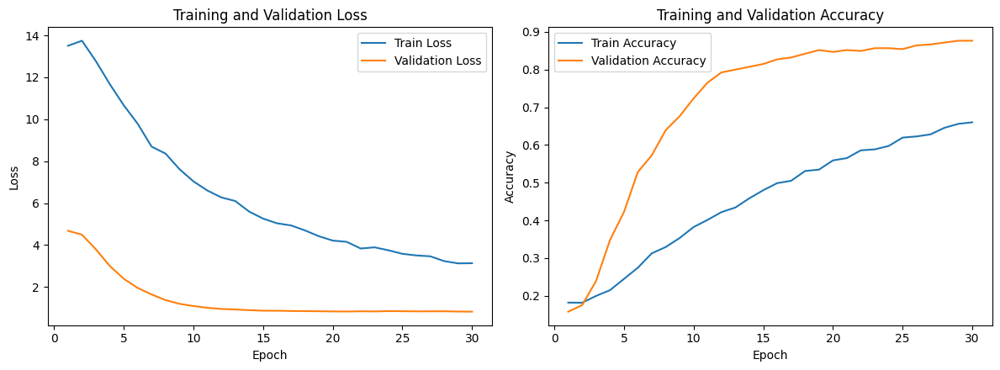

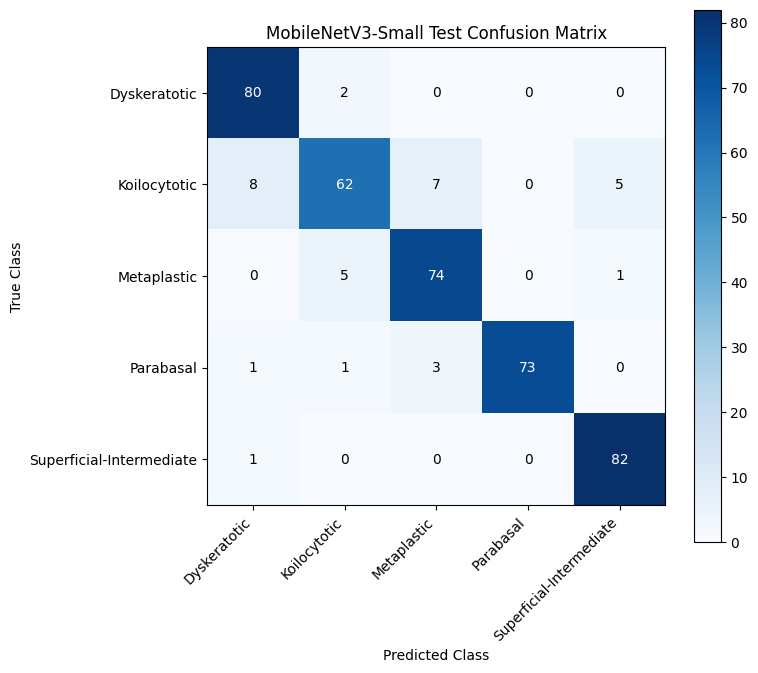

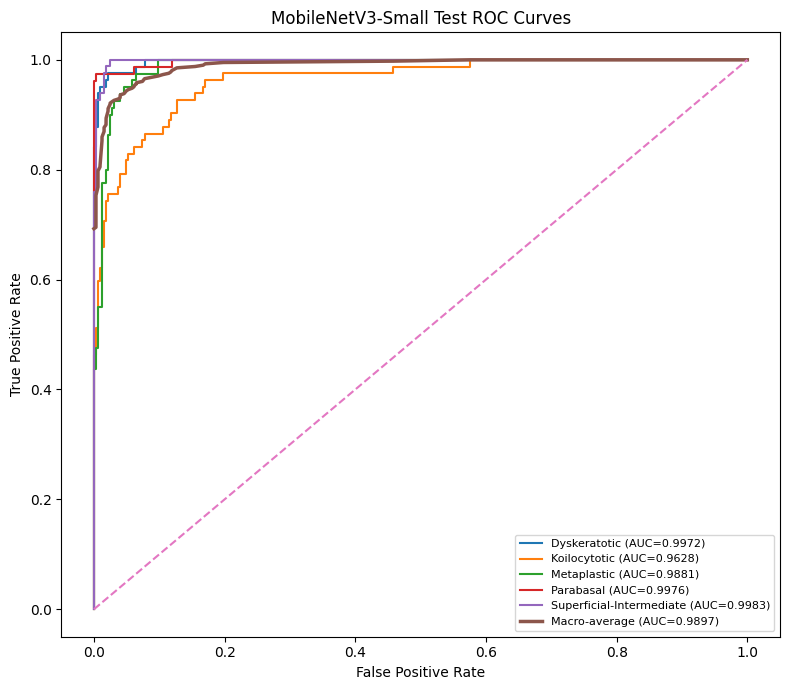

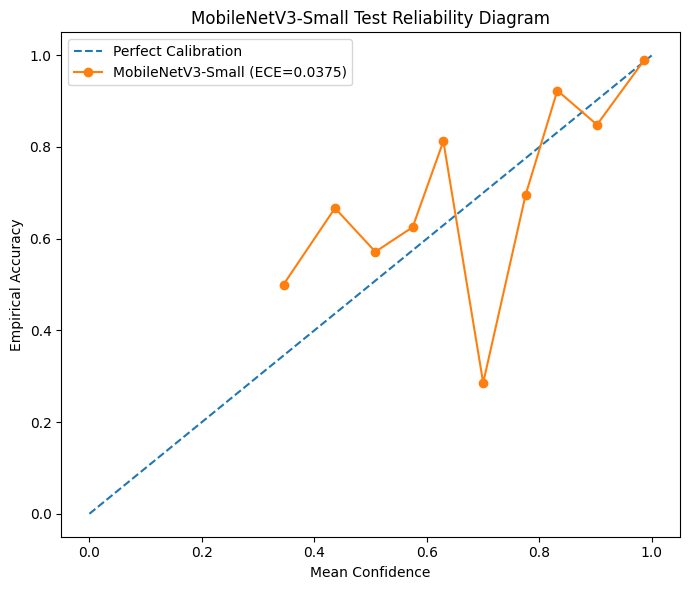

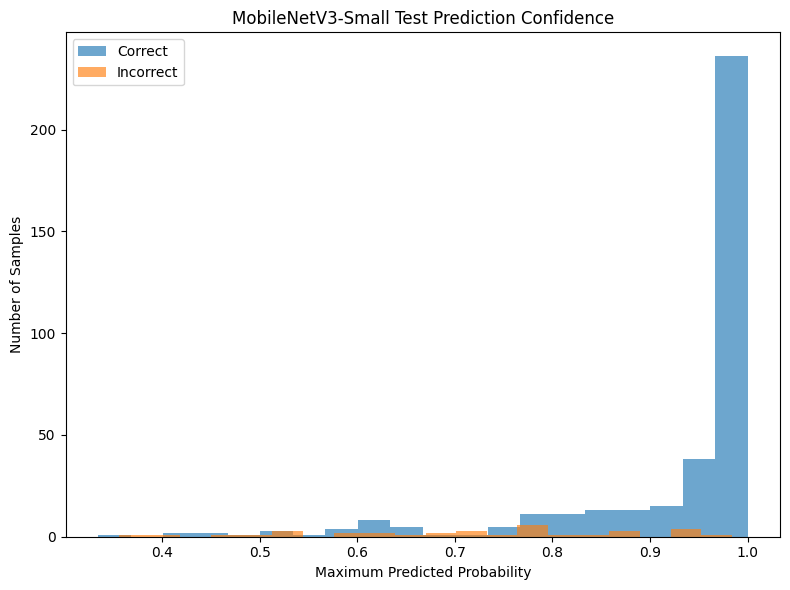

In [ ]:
# BLOCK 2 - MobileNetV3-Small | lightweight CNN
HP_MOBILENET={
    "SEED":42,"IMAGE_SIZE":224,"BATCH_SIZE":16,"MAX_EPOCHS":30,"PATIENCE":5,
    "BACKBONE_LR":2e-4,"HEAD_LR":2e-3,"WEIGHT_DECAY":1e-3,
    "LABEL_SMOOTHING":0.02,"DROPOUT":0.30,"EMA_DECAY":0.995,
    "BOOTSTRAPS":2000,"NUM_WORKERS":2,"USE_TTA":True
}
CFG_MOBILENET={"id":"MobileNetV3Small","display_name":"MobileNetV3-Small","group":"CNN","role":"lightweight CNN","candidate_names":["mobilenetv3_small_100.lamb_in1k","mobilenetv3_small_100"]}
RESULTS["MobileNetV3Small"]=run_baseline(CFG_MOBILENET,HP_MOBILENET)



Starting EfficientNetB0 - EfficientNet-B0
Group: CNN | Role: efficient CNN
Detected 5 classes: ['im_Dyskeratotic', 'im_Koilocytotic', 'im_Metaplastic', 'im_Parabasal', 'im_Superficial-Intermediate']
Class mapping: {'im_Dyskeratotic': 0, 'im_Koilocytotic': 1, 'im_Metaplastic': 2, 'im_Parabasal': 3, 'im_Superficial-Intermediate': 4}
Train images: 6478 | Val images: 405 | Test images: 405
Initialized ImageNet pretrained model: efficientnet_b0.ra_in1k

Epoch | Train Loss | Train Acc | Val Loss | Val Acc | Val Macro F1
------------------------------------------------------------------------
 1 | 4.3918 | 0.1840 | 3.9737 | 0.1580 | 0.1494
 2 | 4.3944 | 0.1839 | 3.7180 | 0.1852 | 0.1888
 3 | 3.2889 | 0.3010 | 2.3519 | 0.3556 | 0.3550
 4 | 2.1722 | 0.4849 | 1.3937 | 0.6025 | 0.5950
 5 | 1.6512 | 0.6011 | 1.0208 | 0.7160 | 0.7070
 6 | 1.3454 | 0.6707 | 0.8523 | 0.7728 | 0.7675
 7 | 1.1712 | 0.7104 | 0.7562 | 0.8198 | 0.8166
 8 | 1.0509 | 0.7422 | 0.6862 | 0.8370 | 0.8349
 9 | 0.9367 | 0.7738 |

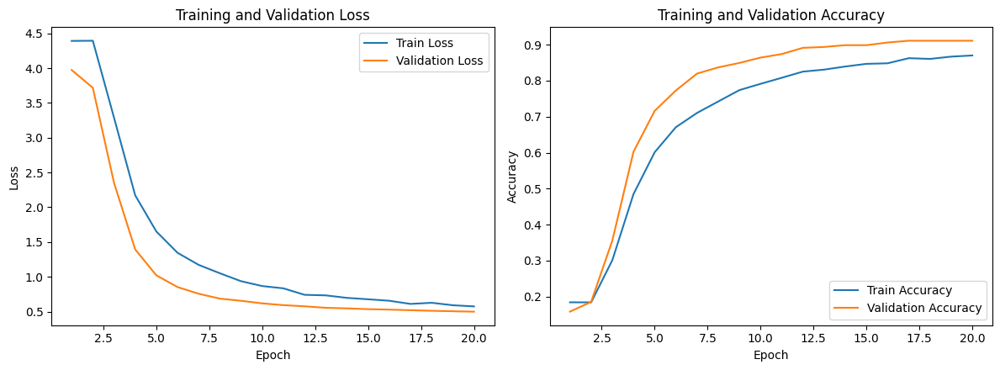

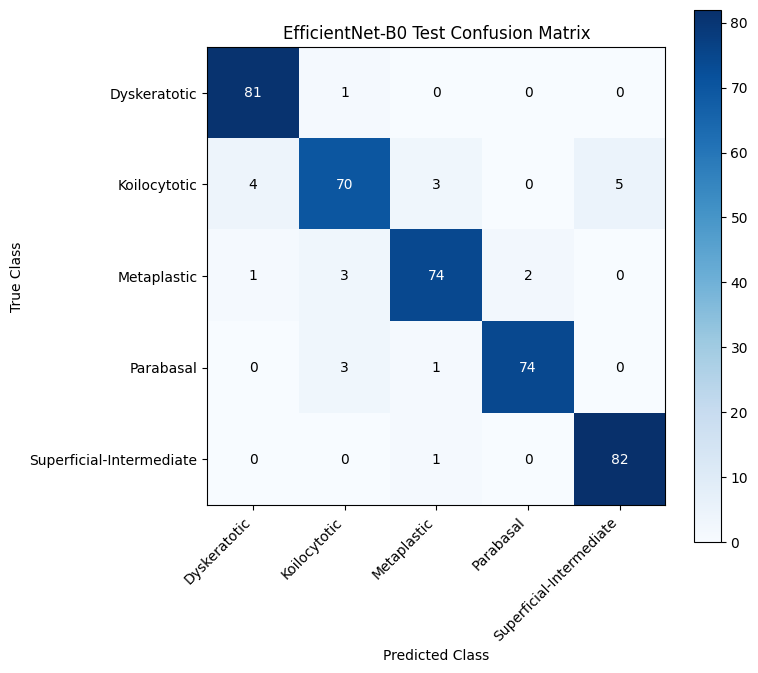

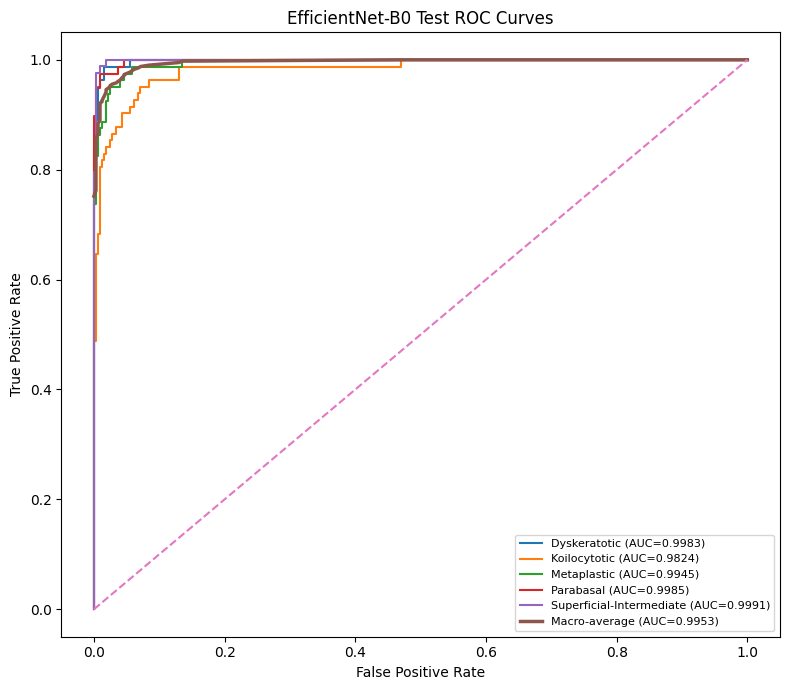

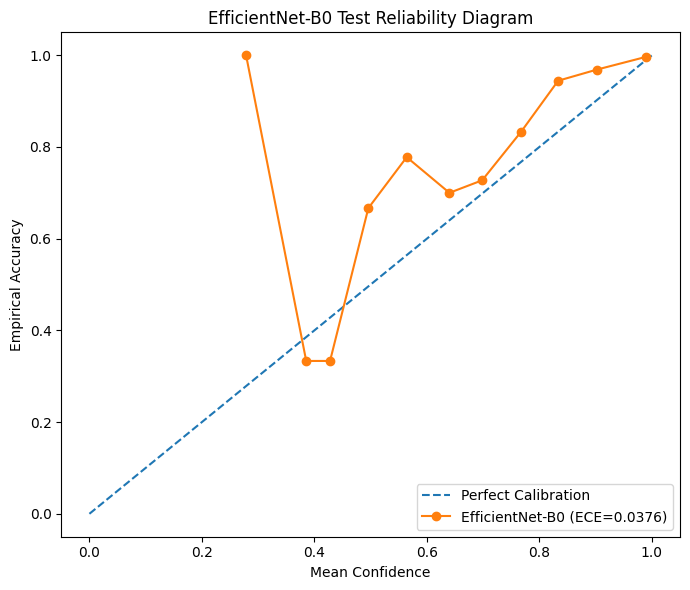

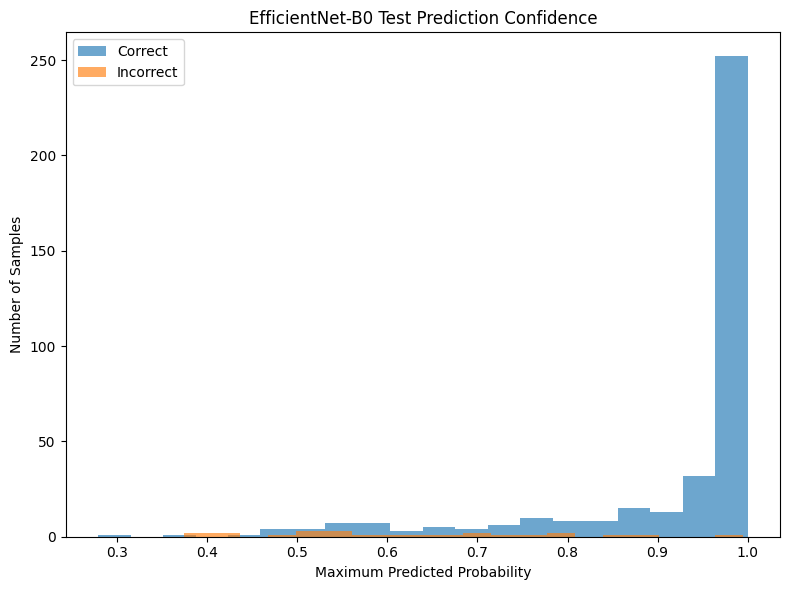

In [ ]:
# %% BLOCK 3

# BLOCK 3 - EfficientNet-B0 | efficient CNN
HP_EFFICIENTNET={
    "SEED":42,"IMAGE_SIZE":224,"BATCH_SIZE":16,"MAX_EPOCHS":30,"PATIENCE":5,
    "BACKBONE_LR":2e-4,"HEAD_LR":2e-3,"WEIGHT_DECAY":1e-3,
    "LABEL_SMOOTHING":0.02,"DROPOUT":0.30,"EMA_DECAY":0.995,
    "BOOTSTRAPS":2000,"NUM_WORKERS":2,"USE_TTA":True
}
CFG_EFFICIENTNET={"id":"EfficientNetB0","display_name":"EfficientNet-B0","group":"CNN","role":"efficient CNN","candidate_names":["efficientnet_b0.ra_in1k","efficientnet_b0"]}
RESULTS["EfficientNetB0"]=run_baseline(CFG_EFFICIENTNET,HP_EFFICIENTNET)


Starting ConvNeXtAtto - ConvNeXt-Atto
Group: CNN | Role: modern local morphology CNN
Detected 5 classes: ['im_Dyskeratotic', 'im_Koilocytotic', 'im_Metaplastic', 'im_Parabasal', 'im_Superficial-Intermediate']
Class mapping: {'im_Dyskeratotic': 0, 'im_Koilocytotic': 1, 'im_Metaplastic': 2, 'im_Parabasal': 3, 'im_Superficial-Intermediate': 4}
Train images: 6478 | Val images: 405 | Test images: 405
Initialized ImageNet pretrained model: convnext_atto.d2_in1k

Epoch | Train Loss | Train Acc | Val Loss | Val Acc | Val Macro F1
------------------------------------------------------------------------
 1 | 0.9034 | 0.7254 | 0.7647 | 0.8099 | 0.8084
 2 | 0.5673 | 0.8424 | 0.5440 | 0.8667 | 0.8669
 3 | 0.3287 | 0.9173 | 0.2812 | 0.9309 | 0.9304
 4 | 0.1987 | 0.9650 | 0.2337 | 0.9481 | 0.9477
 5 | 0.1480 | 0.9847 | 0.2131 | 0.9605 | 0.9602
 6 | 0.1214 | 0.9948 | 0.2108 | 0.9605 | 0.9602
 7 | 0.1102 | 0.9991 | 0.2123 | 0.9630 | 0.9628
 8 | 0.1078 | 0.9994 | 0.1954 | 0.9704 | 0.9702
 9 | 0.1061 | 

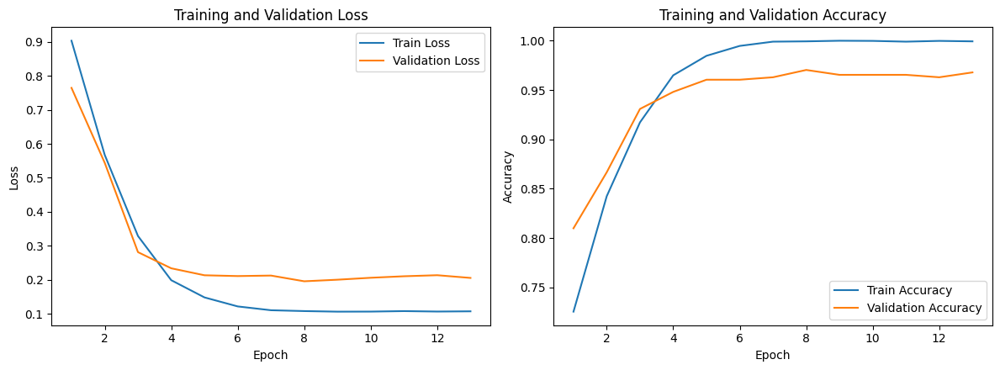

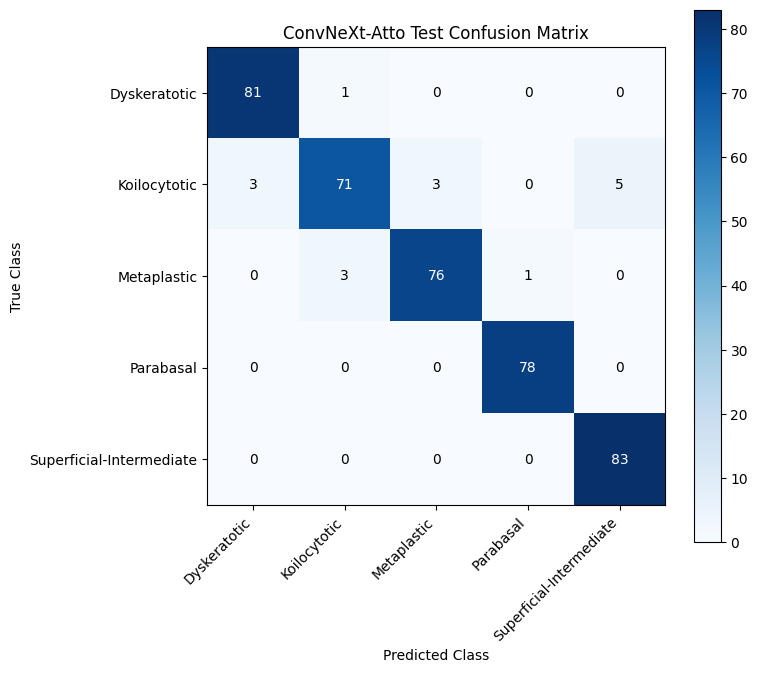

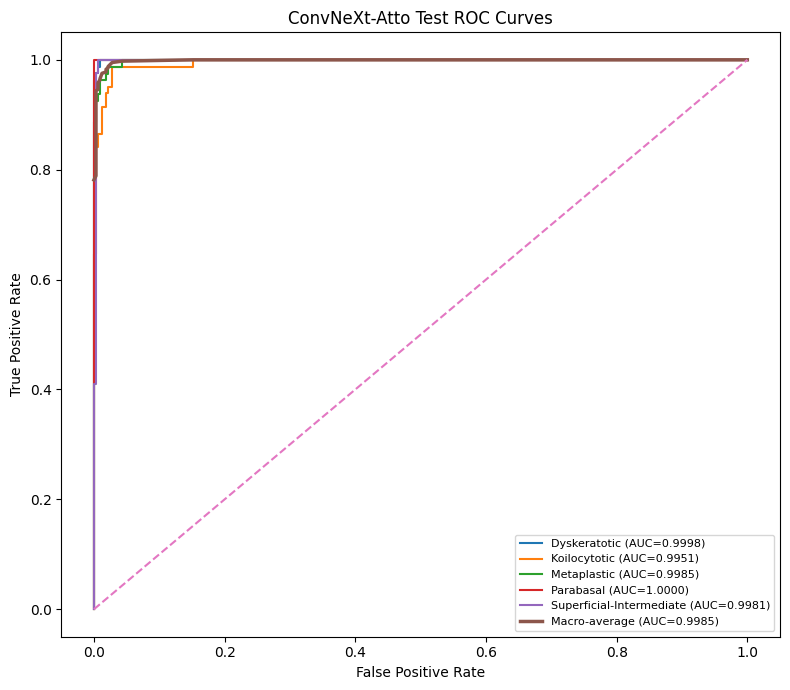

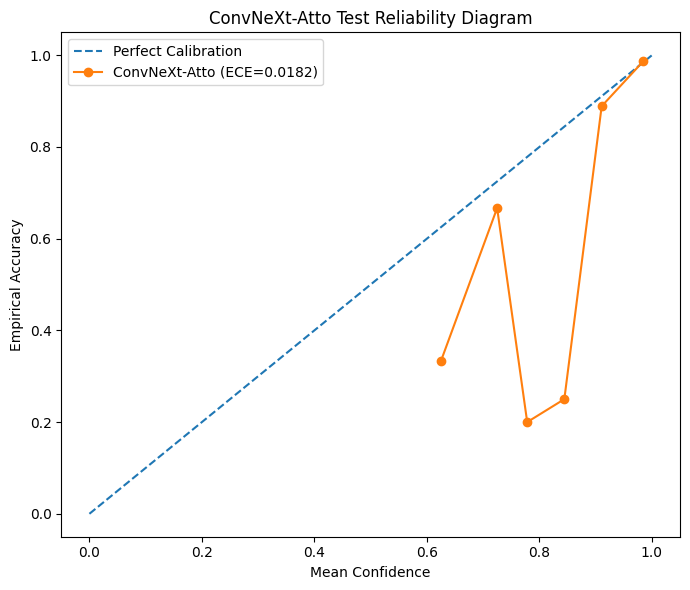

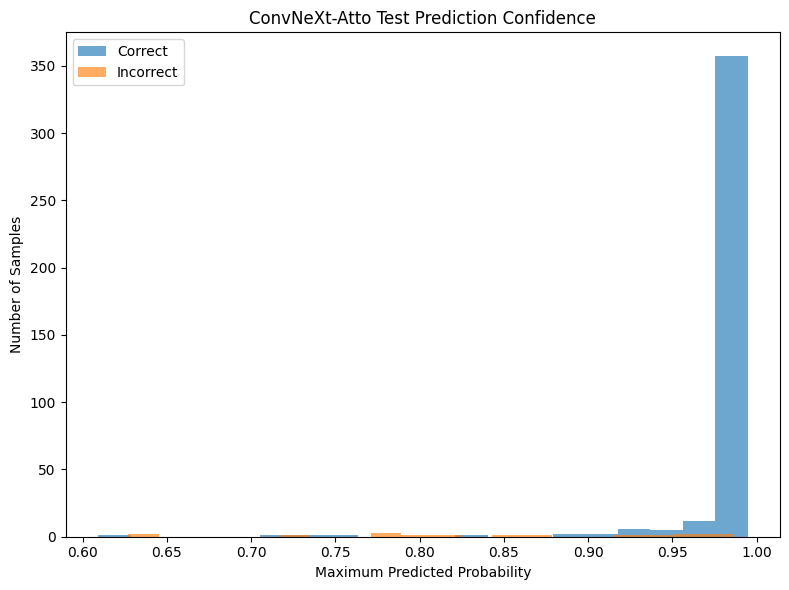

In [ ]:
# %% BLOCK 4

# BLOCK 4 - ConvNeXt-Atto | modern local morphology CNN
HP_CONVNEXT={
    "SEED":42,"IMAGE_SIZE":224,"BATCH_SIZE":16,"MAX_EPOCHS":30,"PATIENCE":5,
    "BACKBONE_LR":2e-4,"HEAD_LR":2e-3,"WEIGHT_DECAY":1e-3,
    "LABEL_SMOOTHING":0.02,"DROPOUT":0.30,"EMA_DECAY":0.995,
    "BOOTSTRAPS":2000,"NUM_WORKERS":2,"USE_TTA":True
}
HP_CONVNEXT["DROPOUT"]=0.20
CFG_CONVNEXT={"id":"ConvNeXtAtto","display_name":"ConvNeXt-Atto","group":"CNN","role":"modern local morphology CNN","candidate_names":["convnext_atto.d2_in1k","convnext_atto"]}
RESULTS["ConvNeXtAtto"]=run_baseline(CFG_CONVNEXT,HP_CONVNEXT)




Starting ViTTiny16 - ViT-Tiny/16
Group: Transformer | Role: standard global transformer
Detected 5 classes: ['im_Dyskeratotic', 'im_Koilocytotic', 'im_Metaplastic', 'im_Parabasal', 'im_Superficial-Intermediate']
Class mapping: {'im_Dyskeratotic': 0, 'im_Koilocytotic': 1, 'im_Metaplastic': 2, 'im_Parabasal': 3, 'im_Superficial-Intermediate': 4}
Train images: 6478 | Val images: 405 | Test images: 405
Initialized ImageNet pretrained model: vit_tiny_patch16_224.augreg_in21k_ft_in1k

Epoch | Train Loss | Train Acc | Val Loss | Val Acc | Val Macro F1
------------------------------------------------------------------------
 1 | 4.1927 | 0.1897 | 1.8732 | 0.1432 | 0.1349
 2 | 4.1942 | 0.1951 | 1.8629 | 0.1481 | 0.1422
 3 | 3.7334 | 0.2052 | 1.6560 | 0.2148 | 0.2169
 4 | 2.5693 | 0.2454 | 1.4474 | 0.3901 | 0.3908
 5 | 1.9175 | 0.2674 | 1.3652 | 0.5605 | 0.5631
 6 | 1.6821 | 0.3165 | 1.2855 | 0.6741 | 0.6729
 7 | 1.5751 | 0.3569 | 1.1879 | 0.7358 | 0.7335
 8 | 1.4315 | 0.4231 | 1.0746 | 0.7704 

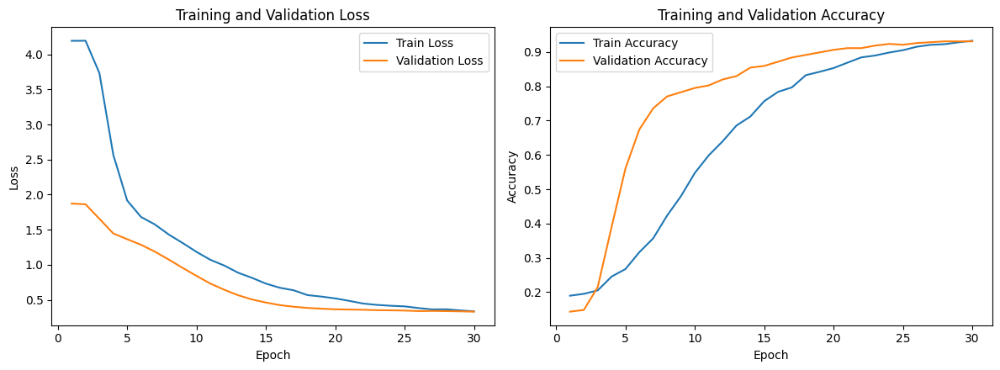

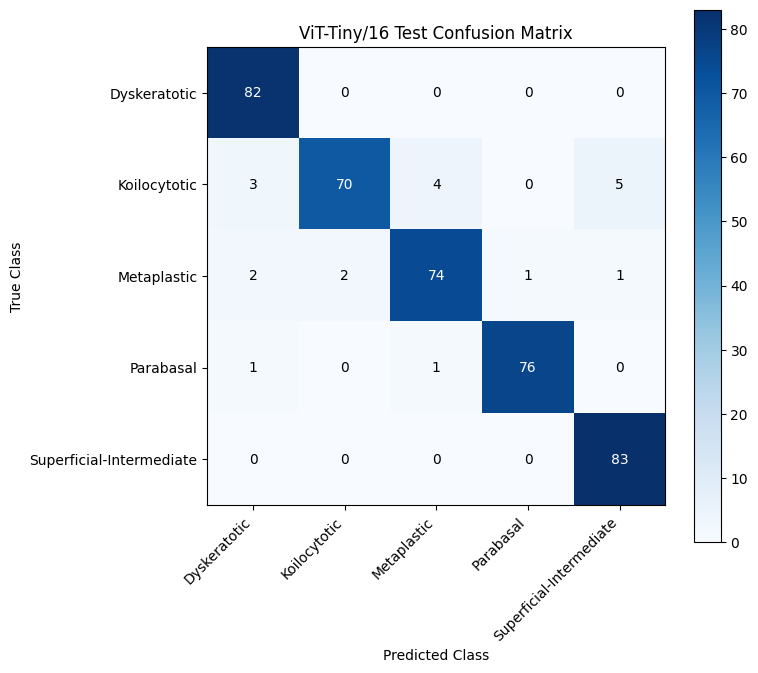

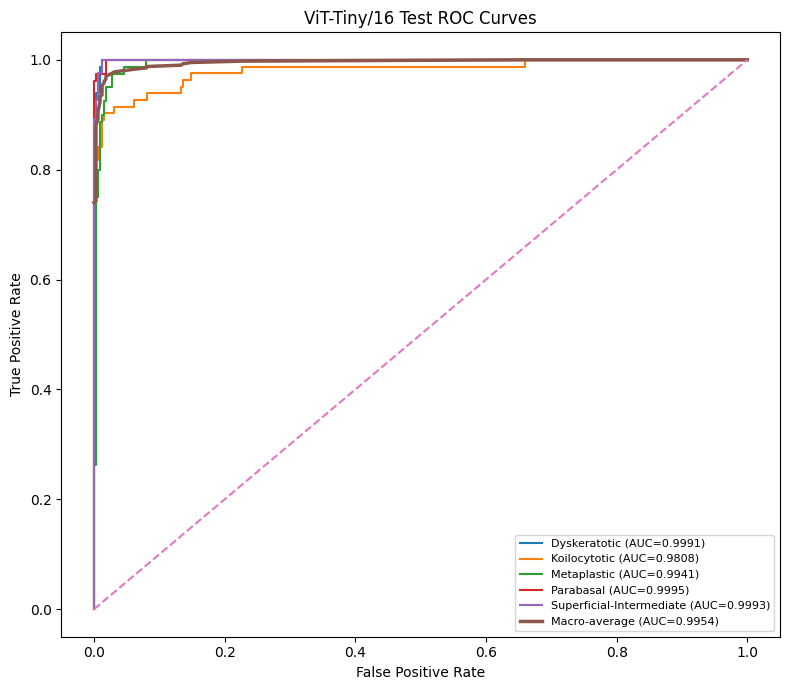

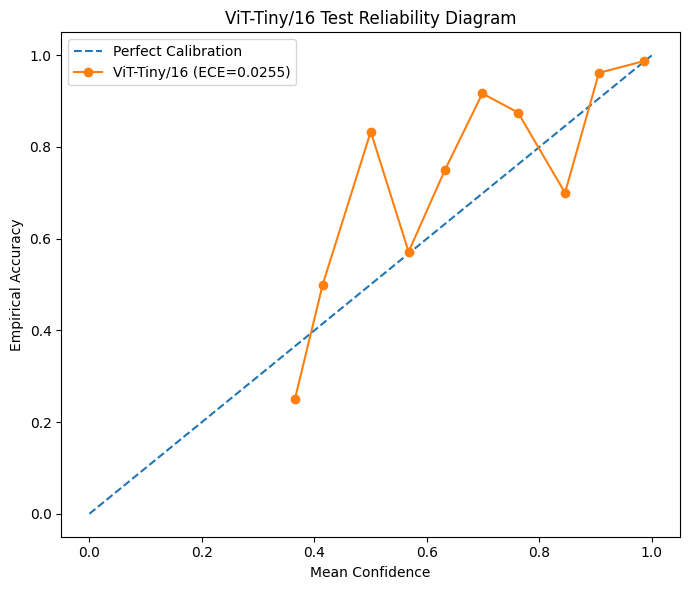

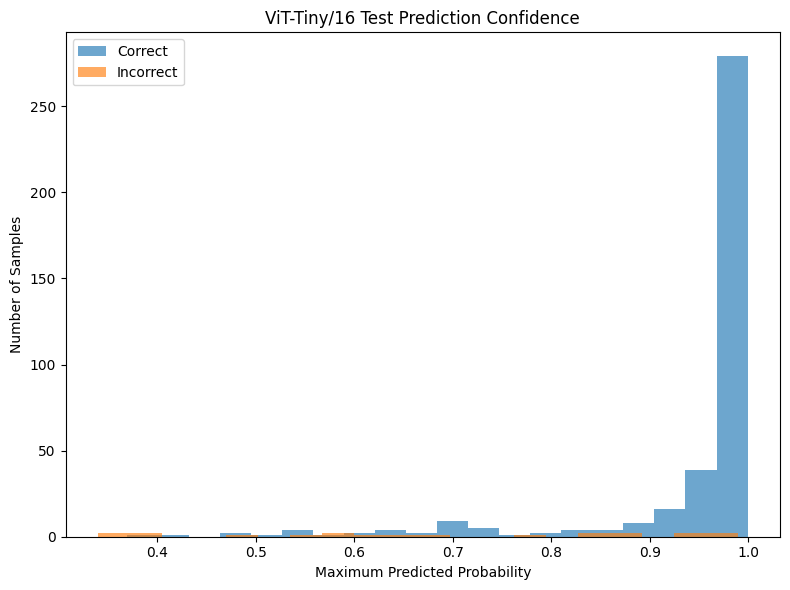

In [ ]:
# %% BLOCK 5

# BLOCK 5 - ViT-Tiny/16 | standard global transformer
HP_VIT={
    "SEED":42,"IMAGE_SIZE":224,"BATCH_SIZE":16,"MAX_EPOCHS":30,"PATIENCE":5,
    "BACKBONE_LR":2e-4,"HEAD_LR":2e-3,"WEIGHT_DECAY":1e-3,
    "LABEL_SMOOTHING":0.02,"DROPOUT":0.30,"EMA_DECAY":0.995,
    "BOOTSTRAPS":2000,"NUM_WORKERS":2,"USE_TTA":True
}
CFG_VIT={"id":"ViTTiny16","display_name":"ViT-Tiny/16","group":"Transformer","role":"standard global transformer","candidate_names":["vit_tiny_patch16_224.augreg_in21k_ft_in1k","vit_tiny_patch16_224"]}
RESULTS["ViTTiny16"]=run_baseline(CFG_VIT,HP_VIT)


Starting DeiTTiny16 - DeiT-Tiny/16
Group: Transformer | Role: data-efficient transformer
Detected 5 classes: ['im_Dyskeratotic', 'im_Koilocytotic', 'im_Metaplastic', 'im_Parabasal', 'im_Superficial-Intermediate']
Class mapping: {'im_Dyskeratotic': 0, 'im_Koilocytotic': 1, 'im_Metaplastic': 2, 'im_Parabasal': 3, 'im_Superficial-Intermediate': 4}
Train images: 6478 | Val images: 405 | Test images: 405
Initialized ImageNet pretrained model: deit_tiny_patch16_224.fb_in1k

Epoch | Train Loss | Train Acc | Val Loss | Val Acc | Val Macro F1
------------------------------------------------------------------------
 1 | 2.2300 | 0.2033 | 1.6810 | 0.2198 | 0.1765
 2 | 2.2354 | 0.2007 | 1.6765 | 0.2198 | 0.1765
 3 | 2.0279 | 0.2186 | 1.5632 | 0.3333 | 0.2984
 4 | 1.7596 | 0.2576 | 1.4574 | 0.4914 | 0.4619
 5 | 1.6141 | 0.2953 | 1.3885 | 0.6173 | 0.5815
 6 | 1.5214 | 0.3371 | 1.3148 | 0.6741 | 0.6408
 7 | 1.4345 | 0.3927 | 1.2246 | 0.7136 | 0.6881
 8 | 1.3304 | 0.4559 | 1.1226 | 0.7580 | 0.7399
 9

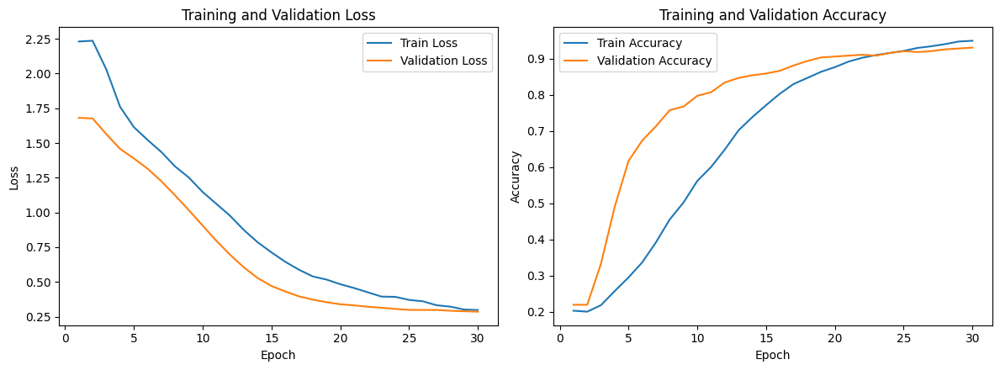

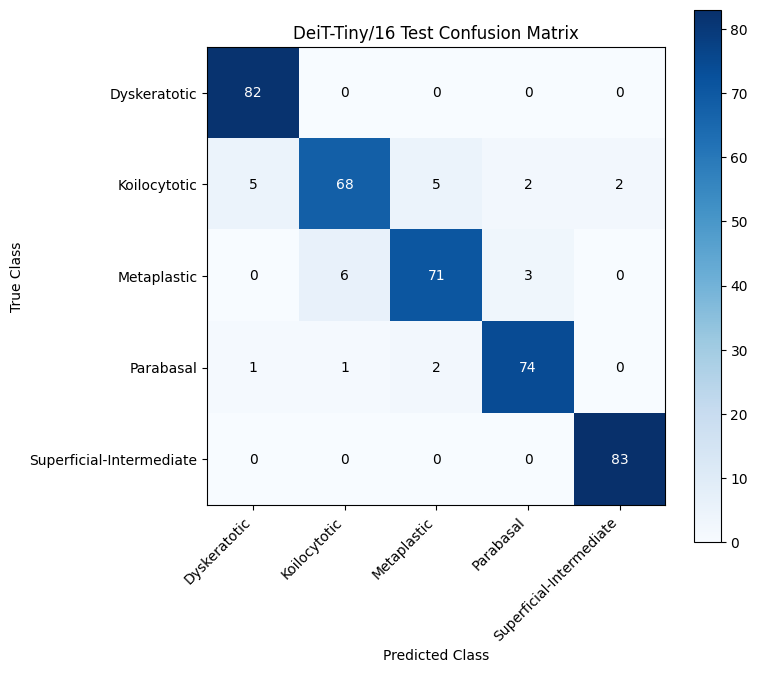

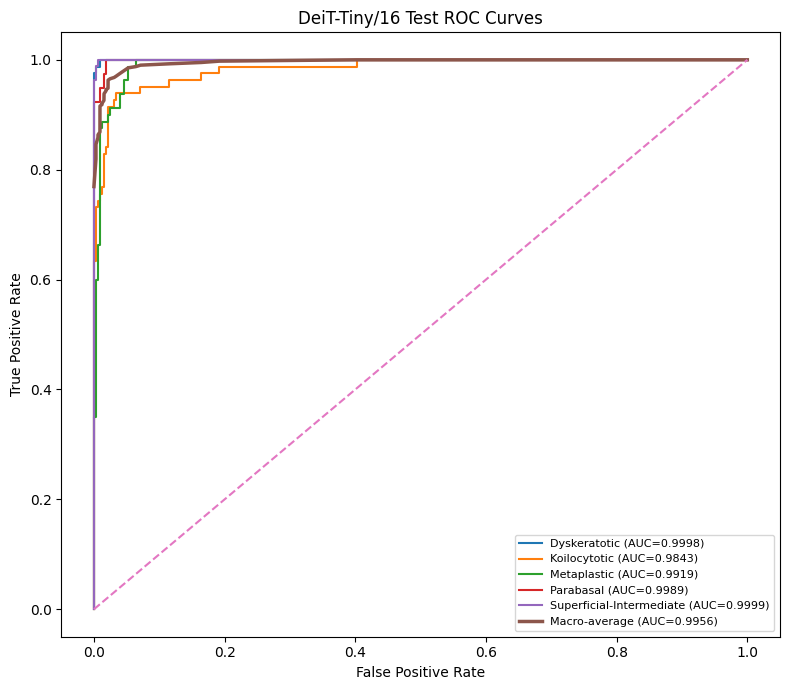

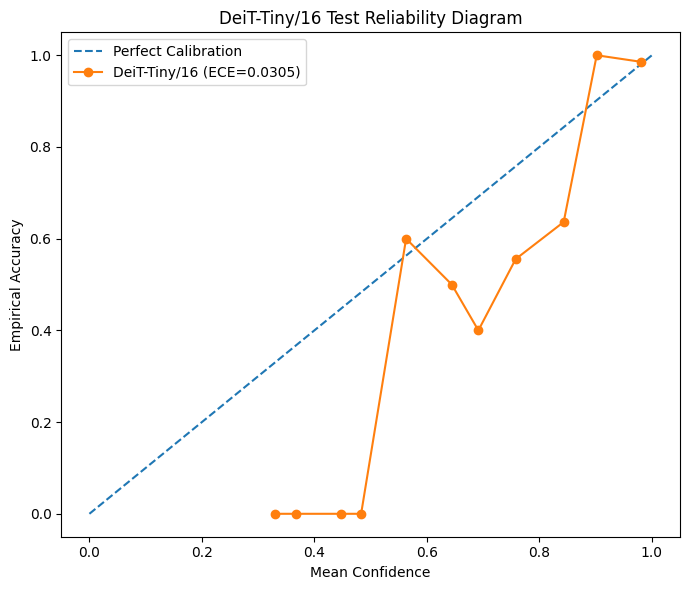

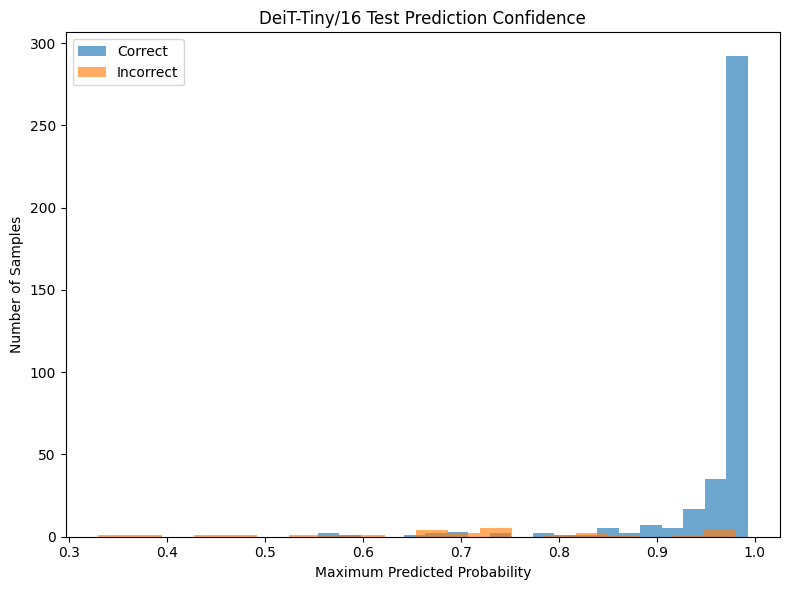

In [ ]:
# %% BLOCK 6

# BLOCK 6 - DeiT-Tiny/16 | data-efficient transformer
HP_DEIT={
     "SEED":42,"IMAGE_SIZE":224,"BATCH_SIZE":16,"MAX_EPOCHS":30,"PATIENCE":5,
    "BACKBONE_LR":2e-4,"HEAD_LR":2e-3,"WEIGHT_DECAY":1e-3,
    "LABEL_SMOOTHING":0.02,"DROPOUT":0.30,"EMA_DECAY":0.995,
    "BOOTSTRAPS":2000,"NUM_WORKERS":2,"USE_TTA":True
}
CFG_DEIT={"id":"DeiTTiny16","display_name":"DeiT-Tiny/16","group":"Transformer","role":"data-efficient transformer","candidate_names":["deit_tiny_patch16_224.fb_in1k","deit_tiny_patch16_224"]}
RESULTS["DeiTTiny16"]=run_baseline(CFG_DEIT,HP_DEIT)



Starting SwinTiny - Swin-Tiny
Group: Transformer | Role: hierarchical/window transformer
Detected 5 classes: ['im_Dyskeratotic', 'im_Koilocytotic', 'im_Metaplastic', 'im_Parabasal', 'im_Superficial-Intermediate']
Class mapping: {'im_Dyskeratotic': 0, 'im_Koilocytotic': 1, 'im_Metaplastic': 2, 'im_Parabasal': 3, 'im_Superficial-Intermediate': 4}
Train images: 6478 | Val images: 405 | Test images: 405
Initialized ImageNet pretrained model: swin_tiny_patch4_window7_224.ms_in1k

Epoch | Train Loss | Train Acc | Val Loss | Val Acc | Val Macro F1
------------------------------------------------------------------------
 1 | 2.0628 | 0.1916 | 1.7019 | 0.1580 | 0.1236
 2 | 2.0237 | 0.2042 | 1.6938 | 0.1630 | 0.1288
 3 | 1.3239 | 0.4589 | 0.9166 | 0.8049 | 0.7994
 4 | 0.5776 | 0.8259 | 0.3368 | 0.9160 | 0.9153
 5 | 0.3811 | 0.9037 | 0.3031 | 0.9358 | 0.9348
 6 | 0.3104 | 0.9302 | 0.2986 | 0.9358 | 0.9348
 7 | 0.2635 | 0.9498 | 0.2801 | 0.9432 | 0.9427
 8 | 0.2394 | 0.9606 | 0.2745 | 0.9481 | 0.

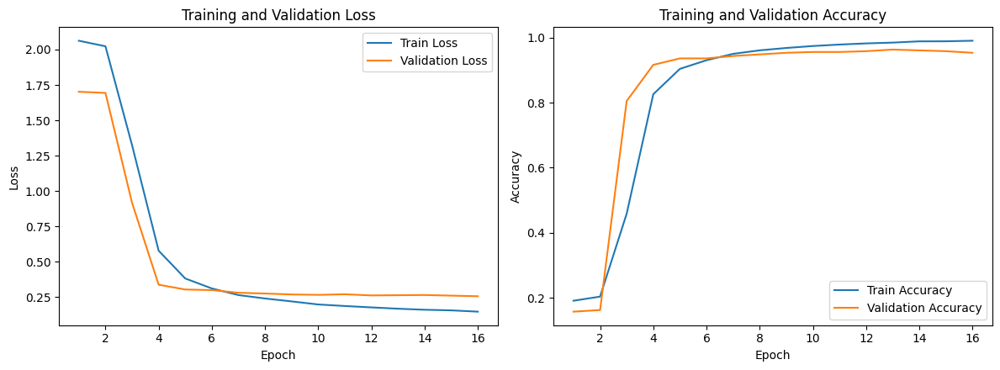

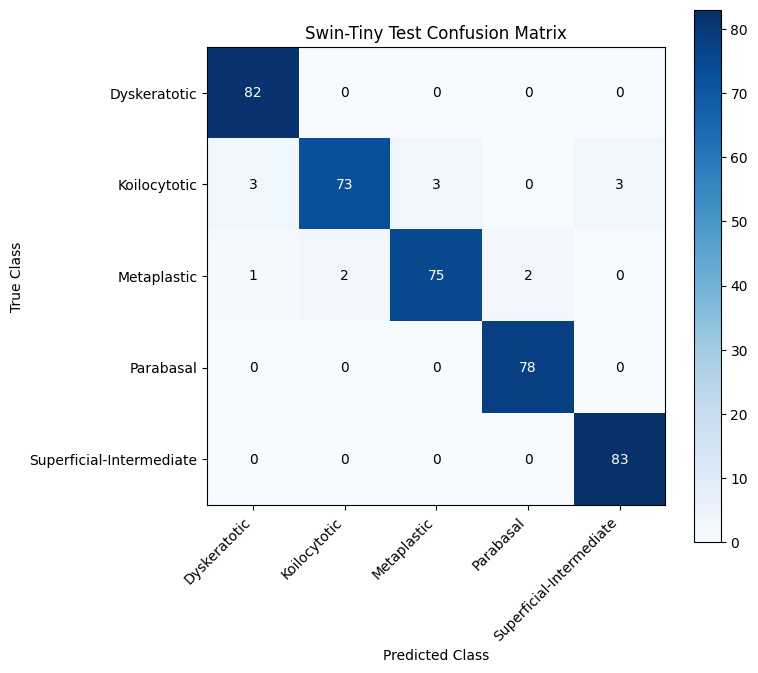

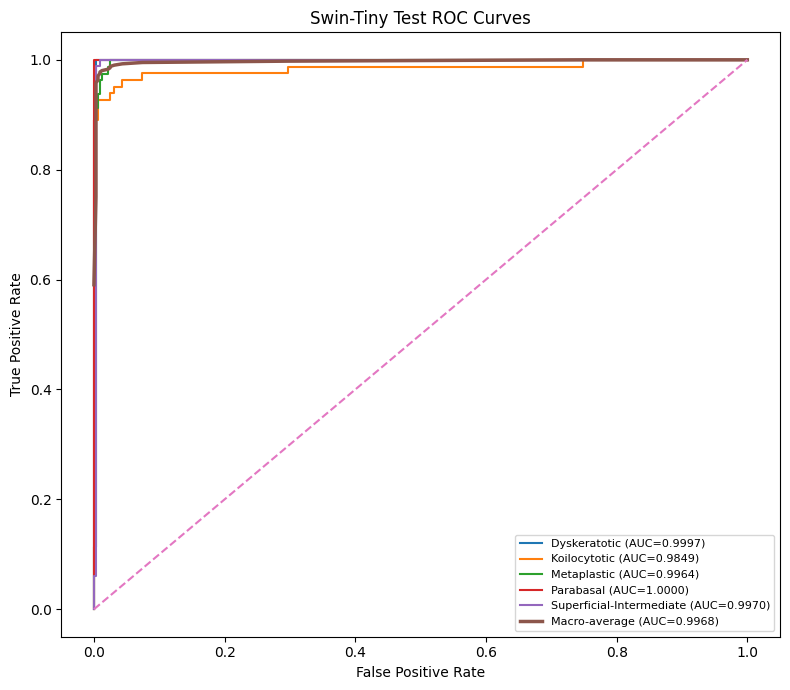

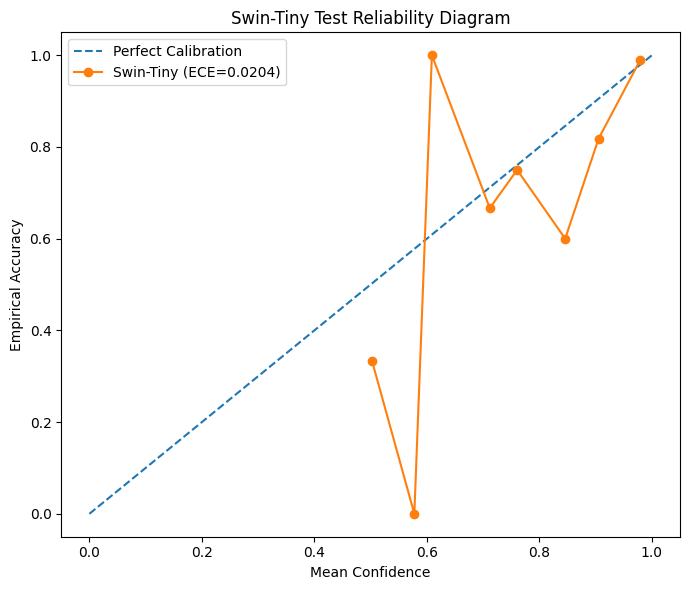

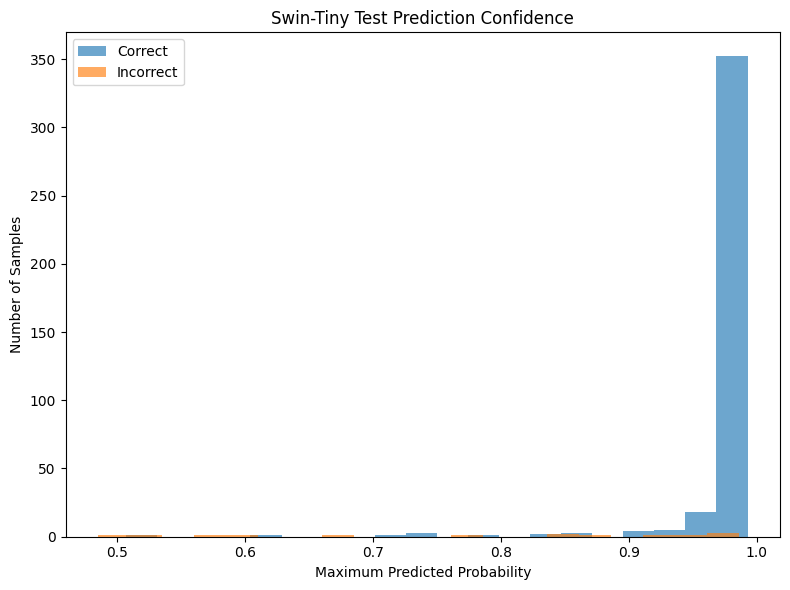

In [ ]:
# %% BLOCK 7

# BLOCK 7 - Swin-Tiny | hierarchical/window transformer
HP_SWIN={
    "SEED":42,"IMAGE_SIZE":224,"BATCH_SIZE":16,"MAX_EPOCHS":30,"PATIENCE":5,
    "BACKBONE_LR":2e-4,"HEAD_LR":2e-3,"WEIGHT_DECAY":1e-3,
    "LABEL_SMOOTHING":0.02,"DROPOUT":0.30,"EMA_DECAY":0.995,
    "BOOTSTRAPS":2000,"NUM_WORKERS":2,"USE_TTA":True
}
CFG_SWIN={"id":"SwinTiny","display_name":"Swin-Tiny","group":"Transformer","role":"hierarchical/window transformer","candidate_names":["swin_tiny_patch4_window7_224.ms_in1k","swin_tiny_patch4_window7_224"]}
RESULTS["SwinTiny"]=run_baseline(CFG_SWIN,HP_SWIN)

In [59]:
BASELINE_TABLE=show_baseline_table(RESULTS)


FINAL SIX-BASELINE COMPARISON
      Group             Model  Accuracy  Balanced Accuracy  Macro F1    MCC  Macro ROC AUC  Params (M)  GFLOPs  Inference ms/image
        CNN MobileNetV3-Small    0.9160             0.9161    0.9149 0.8960         0.9888      1.5230  0.0583              2.9669
        CNN   EfficientNet-B0    0.9407             0.9406    0.9403 0.9261         0.9946      4.0140  0.3981              3.6286
        CNN     ConvNeXt-Atto    0.9605             0.9607    0.9601 0.9509         0.9983      3.3761  0.5517              2.7256
Transformer       ViT-Tiny/16    0.9506             0.9506    0.9501 0.9389         0.9946      5.5254  1.0794              2.6966
Transformer      DeiT-Tiny/16    0.9333             0.9331    0.9321 0.9170         0.9950      5.5254  1.0794              2.8974
Transformer         Swin-Tiny    0.9654             0.9655    0.9650 0.9571         0.9956     27.5232  4.5084              9.0865

Saved: /kaggle/working/SIPaKMeD_6_Baselines/Six_Bas

# **Proposed Model**

Device: cuda
Detected 5 classes: ['im_Dyskeratotic', 'im_Koilocytotic', 'im_Metaplastic', 'im_Parabasal', 'im_Superficial-Intermediate']
Class mapping: {'im_Dyskeratotic': 0, 'im_Koilocytotic': 1, 'im_Metaplastic': 2, 'im_Parabasal': 3, 'im_Superficial-Intermediate': 4}
Train images: 6478 | Val images: 405 | Test images: 405
Local branch initialized from: convnext_atto.d2_in1k
Global branch initialized from ImageNet Swin-Tiny.

No previously trained SIPaKMeD .pth files are loaded.
ConvNeXt-Atto and compact Swin branches are jointly trained/fine-tuned inside the proposed model.

Epoch | Train Loss | Train Acc | Val Loss | Val Acc | Val Macro F1
------------------------------------------------------------------------
 1 | 0.3692 | 0.9111 | 0.2739 | 0.9457 | 0.9454
 2 | 0.2299 | 0.9656 | 0.2549 | 0.9531 | 0.9527
 3 | 0.2955 | 0.9376 | 0.2396 | 0.9457 | 0.9449
 4 | 0.1997 | 0.9724 | 0.2225 | 0.9556 | 0.9552
 5 | 0.1684 | 0.9836 | 0.2151 | 0.9605 | 0.9601
 6 | 0.1534 | 0.9886 | 0.2113 | 0.9

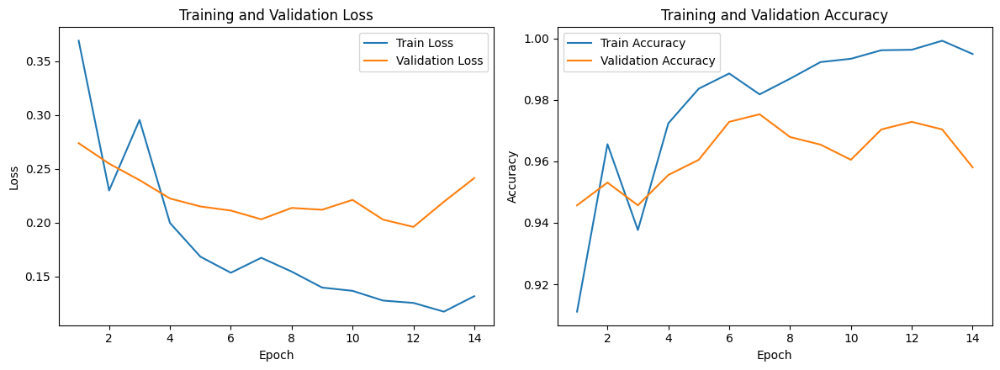

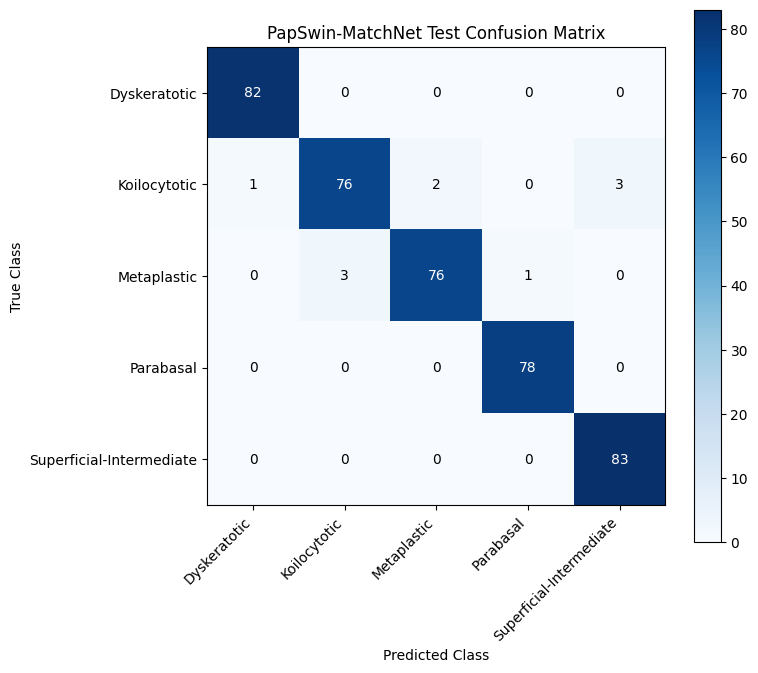

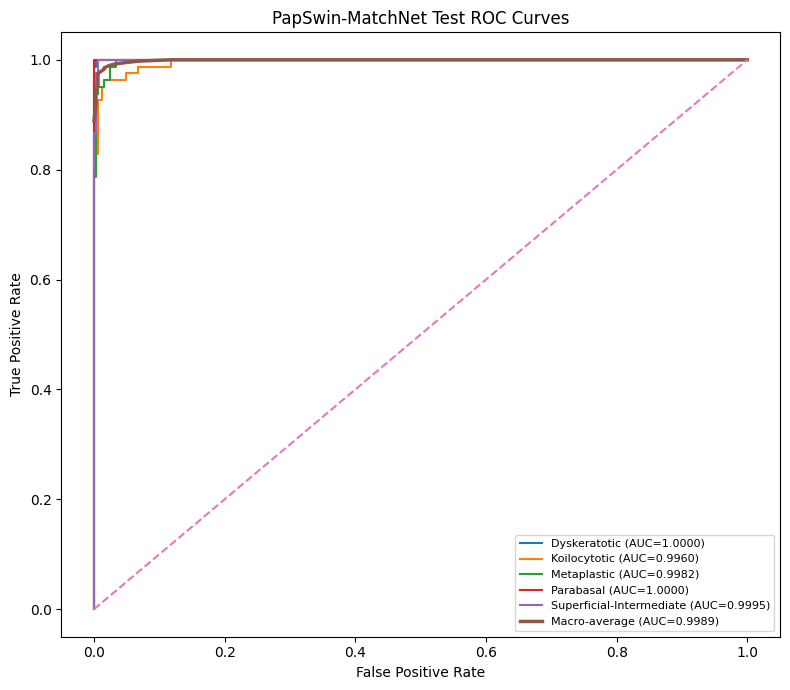

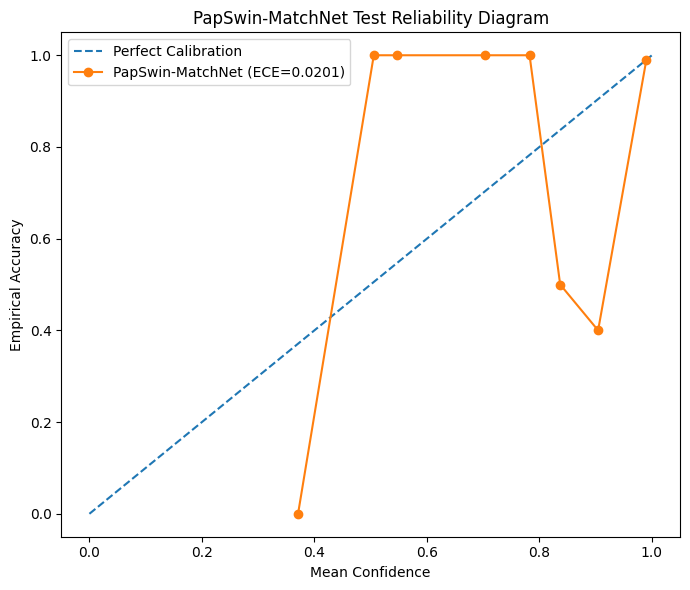

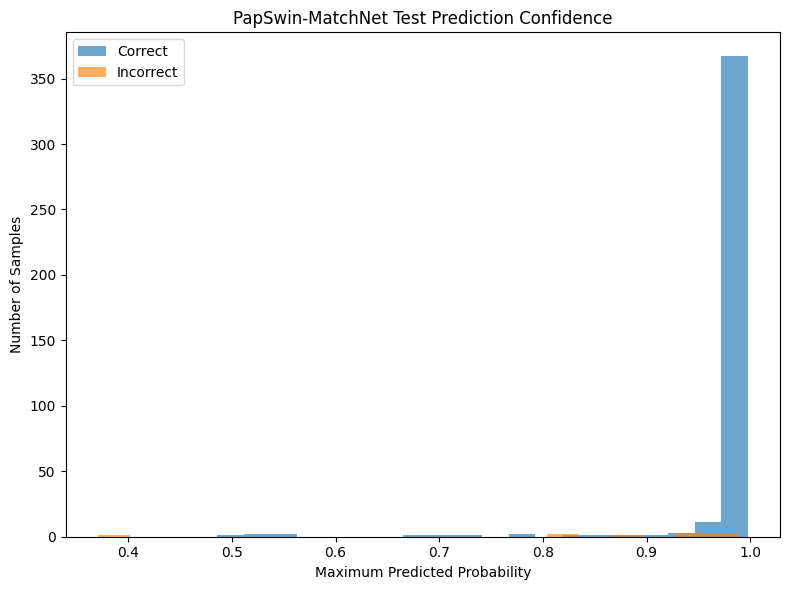


All outputs saved in: /kaggle/working/PapSwin_MatchNet_Results


In [ ]:
# PapSwin-MatchNet

import os
import sys
import gc
import time
import math
import random
import warnings
import subprocess
from copy import deepcopy

import numpy as np
import pandas as pd
import psutil
import matplotlib.pyplot as plt

from scipy.stats import chi2_contingency

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    cohen_kappa_score,
    matthews_corrcoef,
    roc_auc_score,
    roc_curve,
    average_precision_score,
    log_loss,
    top_k_accuracy_score,
)

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import DataLoader

from torchvision import transforms

from torchvision.datasets import ImageFolder

from torchvision.models import (
    swin_t,
    Swin_T_Weights,
)

warnings.filterwarnings("ignore")


try:
    import timm
except ImportError:
    print("timm not found. Installing timm...")
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "timm",
        ]
    )
    import timm


MODEL_NAME = "PapSwin-MatchNet"

SEED = 42

IMAGE_SIZE = 224

BATCH_SIZE = 16

MAX_EPOCHS = 30

PATIENCE = 5

# Low backbone LR protects useful ImageNet features.
BACKBONE_LR = 2e-4

HEAD_LR = 2e-3

WEIGHT_DECAY = 1e-3

LABEL_SMOOTHING = 0.02

DROPOUT = 0.30

MATCH_DIM = 96

MATCH_HEADS = 4

ROUTER_HIDDEN = 96

CROSS_RANK = 64

LAMBDA_AUX = 0.08

EMA_DECAY = 0.995

BOOTSTRAPS = 2000

NUM_WORKERS = 2

USE_TTA = True


TRAIN_PATH = (
    "/kaggle/working/"
    "SIPaKMeD_Train_Double_Augmented"
)

VAL_PATH = (
    "/kaggle/working/"
    "SIPaKMeD_Split_80_10_10/val"
)

TEST_PATH = (
    "/kaggle/working/"
    "SIPaKMeD_Split_80_10_10/test"
)

OUTPUT_DIR = (
    "/kaggle/working/"
    "PapSwin_MatchNet_Results"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True,
)

CHECKPOINT_PATH = os.path.join(
    OUTPUT_DIR,
    "PapSwin_MatchNet_best.pth",
)

SUMMARY_CSV = os.path.join(
    OUTPUT_DIR,
    "PapSwin_MatchNet_summary_metrics.csv",
)

CLASSWISE_CSV = os.path.join(
    OUTPUT_DIR,
    "PapSwin_MatchNet_classwise_metrics.csv",
)

HISTORY_CSV = os.path.join(
    OUTPUT_DIR,
    "PapSwin_MatchNet_training_history.csv",
)

PREDICTIONS_CSV = os.path.join(
    OUTPUT_DIR,
    "PapSwin_MatchNet_test_predictions.csv",
)

PREDICTIONS_NPZ = os.path.join(
    OUTPUT_DIR,
    "PapSwin_MatchNet_test_outputs.npz",
)

CALIBRATION_CSV = os.path.join(
    OUTPUT_DIR,
    "PapSwin_MatchNet_calibration_bins.csv",
)



for folder in [
    TRAIN_PATH,
    VAL_PATH,
    TEST_PATH,
]:
    if not os.path.isdir(
        folder
    ):
        raise FileNotFoundError(
            f"Required dataset folder not found: {folder}"
        )



def seed_everything(
    seed=42,
):
    random.seed(
        seed
    )

    np.random.seed(
        seed
    )

    torch.manual_seed(
        seed
    )

    torch.cuda.manual_seed_all(
        seed
    )

    os.environ[
        "PYTHONHASHSEED"
    ] = str(
        seed
    )

    torch.backends.cudnn.deterministic = True

    torch.backends.cudnn.benchmark = False


seed_everything(
    SEED
)

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

AMP_ENABLED = (
    device.type == "cuda"
)

print(
    "Device:",
    device,
)



IMAGENET_MEAN = [
    0.485,
    0.456,
    0.406,
]

IMAGENET_STD = [
    0.229,
    0.224,
    0.225,
]


train_transform = transforms.Compose([
    transforms.Resize(
        (
            IMAGE_SIZE,
            IMAGE_SIZE,
        )
    ),

    

    transforms.ToTensor(),

    transforms.Normalize(
        IMAGENET_MEAN,
        IMAGENET_STD,
    ),
])

eval_transform = transforms.Compose([
    transforms.Resize(
        (
            IMAGE_SIZE,
            IMAGE_SIZE,
        )
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        IMAGENET_MEAN,
        IMAGENET_STD,
    ),
])



class ImageFolderWithPath(
    ImageFolder
):
    def __getitem__(
        self,
        index,
    ):
        image, target = super().__getitem__(
            index
        )

        path = self.samples[
            index
        ][0]

        return (
            image,
            target,
            path,
        )


train_ds = ImageFolderWithPath(
    TRAIN_PATH,
    transform=train_transform,
)

train_eval_ds = ImageFolderWithPath(
    TRAIN_PATH,
    transform=eval_transform,
)

val_ds = ImageFolderWithPath(
    VAL_PATH,
    transform=eval_transform,
)

test_ds = ImageFolderWithPath(
    TEST_PATH,
    transform=eval_transform,
)

if not (
    train_ds.class_to_idx
    ==
    val_ds.class_to_idx
    ==
    test_ds.class_to_idx
):
    raise ValueError(
        "Class mapping differs between train/val/test."
    )

class_names = (
    train_ds.classes
)

class_to_idx = (
    train_ds.class_to_idx
)

num_classes = len(
    class_names
)

print(
    f"Detected {num_classes} classes: "
    f"{class_names}"
)

print(
    "Class mapping:",
    class_to_idx,
)

print(
    f"Train images: {len(train_ds)} | "
    f"Val images: {len(val_ds)} | "
    f"Test images: {len(test_ds)}"
)

if len(
    train_ds
) != 6478:
    print(
        f"Warning: expected 6478 images in the doubled "
        f"training directory, found {len(train_ds)}."
    )



loader_kwargs = dict(
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    pin_memory=AMP_ENABLED,
)

if NUM_WORKERS > 0:
    loader_kwargs[
        "persistent_workers"
    ] = True


generator = torch.Generator()

generator.manual_seed(
    SEED
)


def seed_worker(
    worker_id,
):
    worker_seed = (
        SEED
        +
        worker_id
    )

    np.random.seed(
        worker_seed
    )

    random.seed(
        worker_seed
    )


train_loader = DataLoader(
    train_ds,
    shuffle=True,
    generator=generator,
    worker_init_fn=seed_worker,
    **loader_kwargs,
)

train_eval_loader = DataLoader(
    train_eval_ds,
    shuffle=False,
    **loader_kwargs,
)

val_loader = DataLoader(
    val_ds,
    shuffle=False,
    **loader_kwargs,
)

test_loader = DataLoader(
    test_ds,
    shuffle=False,
    **loader_kwargs,
)



class ConvProject(
    nn.Module
):
    def __init__(
        self,
        in_channels,
        out_channels,
    ):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=1,
                bias=False,
            ),

            nn.BatchNorm2d(
                out_channels
            ),

            nn.GELU(),
        )


    def forward(
        self,
        x,
    ):
        return self.net(
            x
        )


class VectorProject(
    nn.Module
):
    def __init__(
        self,
        in_dim,
        out_dim,
        dropout=0.10,
    ):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(
                in_dim,
                out_dim,
            ),

            nn.LayerNorm(
                out_dim
            ),

            nn.GELU(),

            nn.Dropout(
                dropout
            ),
        )


    def forward(
        self,
        x,
    ):
        return self.net(
            x
        )

# ============================================================
# MODULE 1:
# BSCM - BIDIRECTIONAL SPATIAL CORRESPONDENCE MATCHING
# ============================================================

class BidirectionalSpatialCorrespondenceMatching(
    nn.Module
):
    def __init__(
        self,
        dim=96,
        num_heads=4,
    ):
        super().__init__()

        self.dim = dim

        self.local_from_global = nn.MultiheadAttention(
            embed_dim=dim,
            num_heads=num_heads,
            dropout=0.08,
            batch_first=True,
        )

        self.global_from_local = nn.MultiheadAttention(
            embed_dim=dim,
            num_heads=num_heads,
            dropout=0.08,
            batch_first=True,
        )

        self.local_norm = nn.LayerNorm(
            dim
        )

        self.global_norm = nn.LayerNorm(
            dim
        )

        
        self.log_temperature = nn.Parameter(
            torch.tensor(
                math.log(
                    6.0
                )
            )
        )

        self.match_bias = nn.Parameter(
            torch.tensor(
                0.0
            )
        )


    def forward(
        self,
        local_map,
        global_map,
    ):
        

        local_tokens = local_map.flatten(
            2
        ).transpose(
            1,
            2,
        )

        global_tokens = global_map.flatten(
            2
        ).transpose(
            1,
            2,
        )

        
        cosine = F.cosine_similarity(
            local_tokens,
            global_tokens,
            dim=-1,
        ).unsqueeze(
            -1
        )

        temperature = torch.exp(
            self.log_temperature
        ).clamp(
            1.0,
            20.0,
        )

        match_confidence = torch.sigmoid(
            temperature
            *
            (
                cosine
                -
                self.match_bias
            )
        )

        
        local_context, _ = self.local_from_global(
            query=local_tokens,
            key=global_tokens,
            value=global_tokens,
            need_weights=False,
        )

        global_context, _ = self.global_from_local(
            query=global_tokens,
            key=local_tokens,
            value=local_tokens,
            need_weights=False,
        )

        
        # information is accepted at each spatial position.
        matched_local = self.local_norm(
            local_tokens
            +
            match_confidence
            *
            local_context
        )

        matched_global = self.global_norm(
            global_tokens
            +
            match_confidence
            *
            global_context
        )

        return {
            "local_tokens":
                matched_local,

            "global_tokens":
                matched_global,

            "match_confidence":
                match_confidence.squeeze(
                    -1
                ),

            "raw_cosine":
                cosine.squeeze(
                    -1
                ),
        }

# ============================================================
# MODULE 2:
# MCCR - MATCH-CONDITIONED CLASS ROUTER
# ============================================================

class MatchConditionedClassRouter(
    nn.Module
):
    def __init__(
        self,
        dim,
        num_classes,
        hidden=96,
        cross_rank=64,
    ):
        super().__init__()

        self.dim = dim

        self.num_classes = (
            num_classes
        )

        
        statistic_dim = (
            dim * 4
            +
            4
        )

        self.context = nn.Sequential(
            nn.Linear(
                statistic_dim,
                hidden,
            ),

            nn.GELU(),

            nn.Dropout(
                0.10
            ),
        )

        self.feature_gate = nn.Sequential(
            nn.Linear(
                hidden,
                dim,
            ),

            nn.Sigmoid(),
        )

        self.class_gate = nn.Sequential(
            nn.Linear(
                hidden,
                num_classes,
            ),

            nn.Sigmoid(),
        )

        self.relational_correction = nn.Sequential(
            nn.Linear(
                dim * 2,
                cross_rank,
            ),

            nn.GELU(),

            nn.Dropout(
                0.10
            ),

            nn.Linear(
                cross_rank,
                dim,
            ),
        )

        self.norm = nn.LayerNorm(
            dim
        )

        self.fused_classifier = nn.Linear(
            dim,
            num_classes,
        )

        self.routed_scale = nn.Parameter(
            torch.tensor(
                -0.40
            )
        )


    @staticmethod
    def branch_reliability(
        logits,
    ):
        probs = torch.softmax(
            logits,
            dim=1,
        )

        entropy = -torch.sum(
            probs
            *
            torch.log(
                probs.clamp_min(
                    1e-8
                )
            ),
            dim=1,
            keepdim=True,
        )

        reliability = (
            1.0
            -
            entropy
            /
            math.log(
                probs.size(
                    1
                )
            )
        ).clamp(
            0.0,
            1.0,
        )

        return (
            probs,
            reliability,
        )


    @staticmethod
    def js_divergence(
        p,
        q,
    ):
        mixture = (
            0.5
            *
            (
                p
                +
                q
            )
        ).clamp_min(
            1e-8
        )

        kl_p = torch.sum(
            p
            *
            (
                torch.log(
                    p.clamp_min(
                        1e-8
                    )
                )
                -
                torch.log(
                    mixture
                )
            ),
            dim=1,
            keepdim=True,
        )

        kl_q = torch.sum(
            q
            *
            (
                torch.log(
                    q.clamp_min(
                        1e-8
                    )
                )
                -
                torch.log(
                    mixture
                )
            ),
            dim=1,
            keepdim=True,
        )

        js = (
            0.5
            *
            (
                kl_p
                +
                kl_q
            )
        )

        return (
            js
            /
            math.log(
                2.0
            )
        ).clamp(
            0.0,
            1.0,
        )


    def forward(
        self,
        local_feature,
        global_feature,
        local_logits,
        global_logits,
        matching_confidence,
    ):
        (
            local_probs,
            local_rel,
        ) = self.branch_reliability(
            local_logits
        )

        (
            global_probs,
            global_rel,
        ) = self.branch_reliability(
            global_logits
        )

        js = self.js_divergence(
            local_probs,
            global_probs,
        )

        difference = torch.abs(
            local_feature
            -
            global_feature
        )

        agreement = (
            local_feature
            *
            global_feature
        )

        match_scalar = matching_confidence.unsqueeze(
            1
        )

        stats = torch.cat(
            [
                local_feature,
                global_feature,
                difference,
                agreement,
                local_rel,
                global_rel,
                js,
                match_scalar,
            ],
            dim=1,
        )

        context = self.context(
            stats
        )

        learned_feature_gate = self.feature_gate(
            context
        )

        class_gate = self.class_gate(
            context
        )

        
        local_prior = (
            local_rel
            /
            (
                local_rel
                +
                global_rel
                +
                1e-6
            )
        )

        
        learned_strength = (
            0.65
            +
            0.25
            *
            match_scalar
        )

        feature_gate = (
            learned_strength
            *
            learned_feature_gate
            +
            (
                1.0
                -
                learned_strength
            )
            *
            local_prior
        )

        base_feature = (
            feature_gate
            *
            local_feature
            +
            (
                1.0
                -
                feature_gate
            )
            *
            global_feature
        )

        relation = self.relational_correction(
            torch.cat(
                [
                    difference,
                    agreement,
                ],
                dim=1,
            )
        )

        mean_reliability = (
            0.5
            *
            (
                local_rel
                +
                global_rel
            )
        )

        
        correction_strength = (
            0.50
            *
            js
            +
            0.30
            *
            (
                1.0
                -
                mean_reliability
            )
            +
            0.20
            *
            (
                1.0
                -
                match_scalar
            )
        ).clamp(
            0.0,
            1.0,
        )

        fused_feature = self.norm(
            base_feature
            +
            correction_strength
            *
            relation
        )

        fused_logits = self.fused_classifier(
            fused_feature
        )

        routed_logits = (
            class_gate
            *
            local_logits
            +
            (
                1.0
                -
                class_gate
            )
            *
            global_logits
        )

        routed_strength = (
            0.40
            *
            torch.sigmoid(
                self.routed_scale
            )
        )

        final_logits = (
            fused_logits
            +
            routed_strength
            *
            routed_logits
        )

        return {
            "logits":
                final_logits,

            "fused_feature":
                fused_feature,

            "feature_gate":
                feature_gate,

            "class_gate":
                class_gate,

            "local_reliability":
                local_rel.squeeze(
                    1
                ),

            "global_reliability":
                global_rel.squeeze(
                    1
                ),

            "js_disagreement":
                js.squeeze(
                    1
                ),

            "correction_strength":
                correction_strength.squeeze(
                    1
                ),
        }

# ============================================================
# PapSwin-MatchNet
# ============================================================

class PapSwinMatchNet(
    nn.Module
):
    def __init__(
        self,
        num_classes,
    ):
        super().__init__()

        self.num_classes = (
            num_classes
        )

        # ----------------------------------------------------
        # LOCAL BRANCH:
        # ConvNeXt-Atto
        # ----------------------------------------------------

        local_model = None

        local_candidates = [
            "convnext_atto.d2_in1k",
            "convnext_atto",
        ]

        local_error = None

        for local_name in local_candidates:
            try:
                local_model = timm.create_model(
                    local_name,
                    pretrained=True,
                    num_classes=0,
                )

                print(
                    f"Local branch initialized from: "
                    f"{local_name}"
                )

                break

            except Exception as error:
                local_error = error

        if local_model is None:
            print(
                "Warning: pretrained ConvNeXt-Atto "
                "could not be loaded."
            )

            for local_name in local_candidates:
                try:
                    local_model = timm.create_model(
                        local_name,
                        pretrained=False,
                        num_classes=0,
                    )

                    print(
                        f"Local branch random initialization: "
                        f"{local_name}"
                    )

                    break

                except Exception as error:
                    local_error = error

        if local_model is None:
            raise RuntimeError(
                "Could not create ConvNeXt-Atto. "
                f"Last error: {local_error}"
            )

        self.local_stem = (
            local_model.stem
        )

        self.local_stages = (
            local_model.stages
        )

        
        self.local_match_channels = 160

        self.local_deep_channels = 320

        
        del local_model

        # ----------------------------------------------------
        # GLOBAL BRANCH:
        # Compact partial Swin-Tiny.
        # ----------------------------------------------------

        try:
            swin_model = swin_t(
                weights=Swin_T_Weights.IMAGENET1K_V1
            )

            print(
                "Global branch initialized from "
                "ImageNet Swin-Tiny."
            )

        except Exception as error:
            print(
                "Warning: pretrained Swin-Tiny weights "
                "could not be loaded. "
                "Using random initialization."
            )

            print(
                "Reason:",
                error,
            )

            swin_model = swin_t(
                weights=None
            )

        swin_features = list(
            swin_model.features.children()
        )

        

        self.swin_prefix = nn.Sequential(
            *swin_features[
                :5
            ]
        )

        stage3_blocks = list(
            swin_features[
                5
            ].children()
        )

        if len(
            stage3_blocks
        ) < 2:
            raise RuntimeError(
                "Unexpected torchvision Swin-T structure."
            )

        self.swin_stage3_pair = nn.Sequential(
            *stage3_blocks[
                :2
            ]
        )

        self.global_channels = 384

        self.swin_norm = nn.LayerNorm(
            self.global_channels
        )

        del swin_model

        gc.collect()

        

        self.local_match_project = ConvProject(
            self.local_match_channels,
            MATCH_DIM,
        )

        self.global_match_project = ConvProject(
            self.global_channels,
            MATCH_DIM,
        )

        self.spatial_match = (
            BidirectionalSpatialCorrespondenceMatching(
                dim=MATCH_DIM,
                num_heads=MATCH_HEADS,
            )
        )

        
        self.local_deep_project = VectorProject(
            self.local_deep_channels,
            MATCH_DIM,
            dropout=0.08,
        )

        self.local_vector_norm = nn.LayerNorm(
            MATCH_DIM
        )

        self.global_vector_norm = nn.LayerNorm(
            MATCH_DIM
        )

        

        self.local_classifier = nn.Linear(
            MATCH_DIM,
            num_classes,
        )

        self.global_classifier = nn.Linear(
            MATCH_DIM,
            num_classes,
        )

        

        self.router = MatchConditionedClassRouter(
            dim=MATCH_DIM,
            num_classes=num_classes,
            hidden=ROUTER_HIDDEN,
            cross_rank=CROSS_RANK,
        )


    def local_backbone_parameters(
        self,
    ):
        return list(
            self.local_stem.parameters()
        ) + list(
            self.local_stages.parameters()
        )


    def global_backbone_parameters(
        self,
    ):
        return list(
            self.swin_prefix.parameters()
        ) + list(
            self.swin_stage3_pair.parameters()
        )


    def set_finetune_stage(
        self,
        stage,
    ):
        # Freeze both pretrained backbones first.
        for p in self.local_stem.parameters():
            p.requires_grad = False

        for p in self.local_stages.parameters():
            p.requires_grad = False

        for p in self.swin_prefix.parameters():
            p.requires_grad = False

        for p in self.swin_stage3_pair.parameters():
            p.requires_grad = False

        if stage == 0:
            return

        if stage >= 1:
            # Fine-tune the last two ConvNeXt stages.
            local_stages_list = list(
                self.local_stages.children()
            )

            for stage_module in local_stages_list[
                -2:
            ]:
                for p in stage_module.parameters():
                    p.requires_grad = True

            # Fine-tune compact Swin stage3 W-MSA/SW-MSA pair.
            for p in self.swin_stage3_pair.parameters():
                p.requires_grad = True

        if stage >= 2:
            # Add one earlier local stage.
            local_stages_list = list(
                self.local_stages.children()
            )

            if len(
                local_stages_list
            ) >= 3:
                for p in local_stages_list[
                    -3
                ].parameters():
                    p.requires_grad = True

            
            prefix_children = list(
                self.swin_prefix.children()
            )

            if len(
                prefix_children
            ) >= 5:
                for p in prefix_children[
                    3
                ].parameters():
                    p.requires_grad = True

                for p in prefix_children[
                    4
                ].parameters():
                    p.requires_grad = True


    def forward_local(
        self,
        x,
    ):
        x = self.local_stem(
            x
        )

        stages = list(
            self.local_stages.children()
        )

        if len(
            stages
        ) != 4:
            raise RuntimeError(
                "Unexpected ConvNeXt-Atto stage structure."
            )

        x = stages[
            0
        ](
            x
        )

        x = stages[
            1
        ](
            x
        )

        local_match_map = stages[
            2
        ](
            x
        )

        local_deep_map = stages[
            3
        ](
            local_match_map
        )

        return (
            local_match_map,
            local_deep_map,
        )


    def forward_global(
        self,
        x,
    ):
        
        x = self.swin_prefix(
            x
        )

        x = self.swin_stage3_pair(
            x
        )

        x = self.swin_norm(
            x
        )

        
        global_map = x.permute(
            0,
            3,
            1,
            2,
        ).contiguous()

        return global_map


    @staticmethod
    def token_pool(
        tokens,
    ):
        
        mean_pool = tokens.mean(
            dim=1
        )

        max_pool = tokens.max(
            dim=1
        ).values

        return (
            0.65
            *
            mean_pool
            +
            0.35
            *
            max_pool
        )


    def forward(
        self,
        x,
    ):
        (
            local_match_map,
            local_deep_map,
        ) = self.forward_local(
            x
        )

        global_map = self.forward_global(
            x
        )

       
        if local_match_map.shape[
            -2:
        ] != global_map.shape[
            -2:
        ]:
            local_match_map = F.interpolate(
                local_match_map,
                size=global_map.shape[
                    -2:
                ],
                mode="bilinear",
                align_corners=False,
            )

        local_projected = self.local_match_project(
            local_match_map
        )

        global_projected = self.global_match_project(
            global_map
        )

        matched = self.spatial_match(
            local_projected,
            global_projected,
        )

        local_matched_vector = self.token_pool(
            matched[
                "local_tokens"
            ]
        )

        global_matched_vector = self.token_pool(
            matched[
                "global_tokens"
            ]
        )

        
        local_deep_vector = F.adaptive_avg_pool2d(
            local_deep_map,
            1,
        ).flatten(
            1
        )

        local_deep_vector = self.local_deep_project(
            local_deep_vector
        )

        local_feature = self.local_vector_norm(
            local_matched_vector
            +
            0.50
            *
            local_deep_vector
        )

        global_feature = self.global_vector_norm(
            global_matched_vector
        )

        local_logits = self.local_classifier(
            local_feature
        )

        global_logits = self.global_classifier(
            global_feature
        )

        mean_match_confidence = matched[
            "match_confidence"
        ].mean(
            dim=1
        )

        routed = self.router(
            local_feature,
            global_feature,
            local_logits,
            global_logits,
            mean_match_confidence,
        )

        return {
            "logits":
                routed[
                    "logits"
                ],

            "local_logits":
                local_logits,

            "global_logits":
                global_logits,

            "embedding":
                routed[
                    "fused_feature"
                ],

            "feature_gate":
                routed[
                    "feature_gate"
                ],

            "class_gate":
                routed[
                    "class_gate"
                ],

            "local_reliability":
                routed[
                    "local_reliability"
                ],

            "global_reliability":
                routed[
                    "global_reliability"
                ],

            "js_disagreement":
                routed[
                    "js_disagreement"
                ],

            "correction_strength":
                routed[
                    "correction_strength"
                ],

            "match_confidence":
                mean_match_confidence,

            "match_cosine":
                matched[
                    "raw_cosine"
                ].mean(
                    dim=1
                ),
        }



model = PapSwinMatchNet(
    num_classes=num_classes
).to(
    device
)

print(
    "\nNo previously trained SIPaKMeD .pth files are loaded."
)

print(
    "ConvNeXt-Atto and compact Swin branches are "
    "jointly trained/fine-tuned inside the proposed model."
)



criterion_main = nn.CrossEntropyLoss(
    label_smoothing=LABEL_SMOOTHING
)

criterion_aux = nn.CrossEntropyLoss(
    label_smoothing=LABEL_SMOOTHING
)


def compute_loss(
    output,
    targets,
):
    main_loss = criterion_main(
        output[
            "logits"
        ],
        targets,
    )

    local_loss = criterion_aux(
        output[
            "local_logits"
        ],
        targets,
    )

    global_loss = criterion_aux(
        output[
            "global_logits"
        ],
        targets,
    )

    aux_loss = (
        0.5
        *
        (
            local_loss
            +
            global_loss
        )
    )

    total_loss = (
        main_loss
        +
        LAMBDA_AUX
        *
        aux_loss
    )

    return (
        total_loss,
        main_loss.detach(),
        aux_loss.detach(),
    )



local_backbone_params = (
    model.local_backbone_parameters()
)

global_backbone_params = (
    model.global_backbone_parameters()
)

backbone_ids = {
    id(
        p
    )
    for p in (
        local_backbone_params
        +
        global_backbone_params
    )
}

head_params = [
    p
    for p in model.parameters()
    if id(
        p
    )
    not in backbone_ids
]

optimizer = torch.optim.AdamW(
    [
        {
            "params":
                local_backbone_params,

            "lr":
                BACKBONE_LR,
        },

        {
            "params":
                global_backbone_params,

            "lr":
                BACKBONE_LR,
        },

        {
            "params":
                head_params,

            "lr":
                HEAD_LR,
        },
    ],
    weight_decay=WEIGHT_DECAY,
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=MAX_EPOCHS,
    eta_min=1e-6,
)

try:
    scaler = torch.amp.GradScaler(
        "cuda",
        enabled=AMP_ENABLED,
    )
except TypeError:
    scaler = torch.cuda.amp.GradScaler(
        enabled=AMP_ENABLED
    )


def autocast_context():
    try:
        return torch.amp.autocast(
            device_type=device.type,
            enabled=AMP_ENABLED,
        )

    except Exception:
        return torch.cuda.amp.autocast(
            enabled=AMP_ENABLED
        )



ema_model = deepcopy(
    model
).to(
    device
)

ema_model.eval()

for p in ema_model.parameters():
    p.requires_grad = False


@torch.no_grad()
def update_ema(
    ema_model,
    source_model,
    decay,
):
    ema_state = ema_model.state_dict()

    source_state = source_model.state_dict()

    for key in ema_state.keys():

        if torch.is_floating_point(
            ema_state[
                key
            ]
        ):
            ema_state[
                key
            ].mul_(
                decay
            ).add_(
                source_state[
                    key
                ].detach(),
                alpha=(
                    1.0
                    -
                    decay
                ),
            )

        else:
            ema_state[
                key
            ].copy_(
                source_state[
                    key
                ]
            )



def run_train_epoch(
    current_model,
    loader,
):
    current_model.train()

    running_loss = 0.0

    correct = 0

    total = 0

    for images, targets, _ in loader:

        images = images.to(
            device,
            non_blocking=True,
        )

        targets = targets.to(
            device,
            non_blocking=True,
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        with autocast_context():

            output = current_model(
                images
            )

            loss, _, _ = compute_loss(
                output,
                targets,
            )

        scaler.scale(
            loss
        ).backward()

        scaler.unscale_(
            optimizer
        )

        torch.nn.utils.clip_grad_norm_(
            current_model.parameters(),
            max_norm=5.0,
        )

        scaler.step(
            optimizer
        )

        scaler.update()

        update_ema(
            ema_model,
            current_model,
            EMA_DECAY,
        )

        pred = output[
            "logits"
        ].argmax(
            dim=1
        )

        running_loss += (
            loss.item()
            *
            images.size(
                0
            )
        )

        correct += (
            pred
            ==
            targets
        ).sum().item()

        total += targets.size(
            0
        )

    return (
        running_loss
        /
        total,

        correct
        /
        total,
    )


@torch.no_grad()
def run_validation(
    current_model,
    loader,
):
    current_model.eval()

    running_loss = 0.0

    correct = 0

    total = 0

    labels_all = []

    preds_all = []

    for images, targets, _ in loader:

        images = images.to(
            device,
            non_blocking=True,
        )

        targets = targets.to(
            device,
            non_blocking=True,
        )

        with autocast_context():

            output = current_model(
                images
            )

            loss, _, _ = compute_loss(
                output,
                targets,
            )

        pred = output[
            "logits"
        ].argmax(
            dim=1
        )

        running_loss += (
            loss.item()
            *
            images.size(
                0
            )
        )

        correct += (
            pred
            ==
            targets
        ).sum().item()

        total += targets.size(
            0
        )

        labels_all.append(
            targets.cpu().numpy()
        )

        preds_all.append(
            pred.cpu().numpy()
        )

    labels = np.concatenate(
        labels_all
    )

    preds = np.concatenate(
        preds_all
    )

    macro_f1 = f1_score(
        labels,
        preds,
        average="macro",
        zero_division=0,
    )

    return (
        running_loss
        /
        total,

        correct
        /
        total,

        macro_f1,
    )



history = {
    "epoch": [],
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "val_macro_f1": [],
}

best_state = None

best_val_macro_f1 = -np.inf

best_epoch = 0

wait = 0


model.set_finetune_stage(
    0
)

if AMP_ENABLED:
    torch.cuda.empty_cache()

    torch.cuda.reset_peak_memory_stats()

print(
    "\nEpoch | Train Loss | Train Acc | "
    "Val Loss | Val Acc | Val Macro F1"
)

print(
    "-" * 72
)

training_start = time.perf_counter()

for epoch in range(
    1,
    MAX_EPOCHS + 1,
):

    
    if epoch == 3:
        model.set_finetune_stage(
            1
        )

    
    if epoch == 7:
        model.set_finetune_stage(
            2
        )

    train_loss, train_acc = run_train_epoch(
        model,
        train_loader,
    )

    val_loss, val_acc, val_macro_f1 = run_validation(
        ema_model,
        val_loader,
    )

    scheduler.step()

    history[
        "epoch"
    ].append(
        epoch
    )

    history[
        "train_loss"
    ].append(
        train_loss
    )

    history[
        "train_acc"
    ].append(
        train_acc
    )

    history[
        "val_loss"
    ].append(
        val_loss
    )

    history[
        "val_acc"
    ].append(
        val_acc
    )

    history[
        "val_macro_f1"
    ].append(
        val_macro_f1
    )

    print(
        f"{epoch:2d} | "
        f"{train_loss:.4f} | "
        f"{train_acc:.4f} | "
        f"{val_loss:.4f} | "
        f"{val_acc:.4f} | "
        f"{val_macro_f1:.4f}"
    )

    if (
        val_macro_f1
        >
        best_val_macro_f1
        +
        1e-5
    ):
        best_val_macro_f1 = (
            val_macro_f1
        )

        best_epoch = epoch

        wait = 0

        best_state = deepcopy(
            ema_model.state_dict()
        )

        torch.save(
            {
                "model_state_dict":
                    best_state,

                "class_to_idx":
                    class_to_idx,

                "model_name":
                    MODEL_NAME,

                "best_epoch":
                    best_epoch,

                "best_val_macro_f1":
                    best_val_macro_f1,

                "seed":
                    SEED,

                "image_size":
                    IMAGE_SIZE,

                "match_dim":
                    MATCH_DIM,
            },
            CHECKPOINT_PATH,
        )

    else:
        wait += 1

        if wait >= PATIENCE:
            print(
                "Early stopping."
            )

            break


training_time = (
    time.perf_counter()
    -
    training_start
)

training_gpu_peak_mb = (
    torch.cuda.max_memory_allocated()
    /
    (
        1024 ** 2
    )
    if AMP_ENABLED
    else 0.0
)

pd.DataFrame(
    history
).to_csv(
    HISTORY_CSV,
    index=False,
)

if best_state is None:
    raise RuntimeError(
        "No best validation checkpoint was saved."
    )

model.load_state_dict(
    best_state
)

model.eval()

del ema_model

gc.collect()

if AMP_ENABLED:
    torch.cuda.empty_cache()

print(
    f"\nBest epoch: "
    f"{best_epoch}"
)

print(
    f"Best validation Macro F1: "
    f"{best_val_macro_f1:.4f}"
)

print(
    f"Total training time: "
    f"{training_time:.2f}s "
    f"({training_time / 60:.2f} min)"
)

# ============================================================
# TTA + OUTPUT COLLECTION
# ============================================================

@torch.no_grad()
def forward_with_tta(
    current_model,
    images,
    use_tta=False,
):
    views = [
        images
    ]

    if use_tta:

        views.extend([
            torch.flip(
                images,
                dims=[
                    3
                ],
            ),

            torch.flip(
                images,
                dims=[
                    2
                ],
            ),

            torch.flip(
                images,
                dims=[
                    2,
                    3,
                ],
            ),
        ])

    store = {
        "logits": [],
        "embedding": [],
        "feature_gate": [],
        "class_gate": [],
        "local_reliability": [],
        "global_reliability": [],
        "js_disagreement": [],
        "correction_strength": [],
        "match_confidence": [],
        "match_cosine": [],
    }

    for view in views:

        with autocast_context():

            output = current_model(
                view
            )

        store[
            "logits"
        ].append(
            output[
                "logits"
            ].float()
        )

        store[
            "embedding"
        ].append(
            output[
                "embedding"
            ].float()
        )

        store[
            "feature_gate"
        ].append(
            output[
                "feature_gate"
            ].mean(
                dim=1
            ).float()
        )

        store[
            "class_gate"
        ].append(
            output[
                "class_gate"
            ].mean(
                dim=1
            ).float()
        )

        for key in [
            "local_reliability",
            "global_reliability",
            "js_disagreement",
            "correction_strength",
            "match_confidence",
            "match_cosine",
        ]:
            store[
                key
            ].append(
                output[
                    key
                ].float()
            )

    result = {}

    for key, values in store.items():

        result[
            key
        ] = torch.stack(
            values,
            dim=0,
        ).mean(
            dim=0
        )

    return result


@torch.no_grad()
def collect_outputs(
    current_model,
    loader,
    use_tta=False,
):
    current_model.eval()

    labels_all = []

    logits_all = []

    embedding_all = []

    paths_all = []

    diagnostics = {
        "feature_gate": [],
        "class_gate": [],
        "local_reliability": [],
        "global_reliability": [],
        "js_disagreement": [],
        "correction_strength": [],
        "match_confidence": [],
        "match_cosine": [],
    }

    for images, targets, paths in loader:

        images = images.to(
            device,
            non_blocking=True,
        )

        output = forward_with_tta(
            current_model,
            images,
            use_tta=use_tta,
        )

        labels_all.append(
            targets.numpy()
        )

        logits_all.append(
            output[
                "logits"
            ].cpu().numpy()
        )

        embedding_all.append(
            output[
                "embedding"
            ].cpu().numpy()
        )

        paths_all.extend(
            list(
                paths
            )
        )

        for key in diagnostics.keys():

            diagnostics[
                key
            ].append(
                output[
                    key
                ].cpu().numpy()
            )

    result = {
        "y":
            np.concatenate(
                labels_all
            ),

        "logits":
            np.concatenate(
                logits_all
            ),

        "embedding":
            np.concatenate(
                embedding_all
            ),

        "paths":
            paths_all,
    }

    for key in diagnostics.keys():

        result[
            key
        ] = np.concatenate(
            diagnostics[
                key
            ]
        )

    return result


train_out = collect_outputs(
    model,
    train_eval_loader,
    use_tta=False,
)

val_out = collect_outputs(
    model,
    val_loader,
    use_tta=USE_TTA,
)

test_out = collect_outputs(
    model,
    test_loader,
    use_tta=USE_TTA,
)

# ============================================================
# TEMPERATURE SCALING - VALIDATION ONLY
# ============================================================

class TemperatureScaler(
    nn.Module
):
    def __init__(
        self,
    ):
        super().__init__()

        self.log_temperature = nn.Parameter(
            torch.zeros(
                1
            )
        )


    def forward(
        self,
        logits,
    ):
        temperature = torch.exp(
            self.log_temperature
        ).clamp(
            0.05,
            10.0,
        )

        return (
            logits
            /
            temperature
        )


    @property
    def temperature(
        self,
    ):
        return float(
            torch.exp(
                self.log_temperature
            )
            .clamp(
                0.05,
                10.0,
            )
            .detach()
            .cpu()
        )


def fit_temperature(
    logits,
    labels,
):
    temp_model = TemperatureScaler().to(
        device
    )

    logits_t = torch.tensor(
        logits,
        dtype=torch.float32,
        device=device,
    )

    labels_t = torch.tensor(
        labels,
        dtype=torch.long,
        device=device,
    )

    optimizer_t = torch.optim.LBFGS(
        temp_model.parameters(),
        lr=0.05,
        max_iter=50,
        line_search_fn="strong_wolfe",
    )


    def closure():
        optimizer_t.zero_grad()

        loss = F.cross_entropy(
            temp_model(
                logits_t
            ),
            labels_t,
        )

        loss.backward()

        return loss


    optimizer_t.step(
        closure
    )

    return temp_model.temperature


def softmax_np(
    logits,
    temperature=1.0,
):
    z = (
        logits
        /
        float(
            temperature
        )
    )

    z = (
        z
        -
        np.max(
            z,
            axis=1,
            keepdims=True,
        )
    )

    exp_z = np.exp(
        z
    )

    return (
        exp_z
        /
        np.sum(
            exp_z,
            axis=1,
            keepdims=True,
        )
    )


temperature = fit_temperature(
    val_out[
        "logits"
    ],
    val_out[
        "y"
    ],
)

for output in [
    train_out,
    val_out,
    test_out,
]:

    output[
        "probs_raw"
    ] = softmax_np(
        output[
            "logits"
        ],
        1.0,
    )

    output[
        "probs"
    ] = softmax_np(
        output[
            "logits"
        ],
        temperature,
    )

    output[
        "pred"
    ] = output[
        "probs"
    ].argmax(
        axis=1
    )

# ============================================================
# REPORTS
# ============================================================

def print_report(
    name,
    output,
):
    print(
        f"\n{name} Report:"
    )

    print(
        classification_report(
            output[
                "y"
            ],
            output[
                "pred"
            ],
            target_names=class_names,
            digits=4,
            zero_division=0,
        )
    )


print_report(
    f"{MODEL_NAME} Train",
    train_out,
)

print_report(
    f"{MODEL_NAME} Val",
    val_out,
)

print_report(
    f"{MODEL_NAME} Test",
    test_out,
)

# ============================================================
# METRIC HELPERS
# ============================================================

def one_hot(
    y,
):
    return np.eye(
        num_classes,
        dtype=np.float64,
    )[
        y
    ]


def expected_calibration_error(
    y,
    probs,
    n_bins=15,
):
    confidence = probs.max(
        axis=1
    )

    pred = probs.argmax(
        axis=1
    )

    correct = (
        pred
        ==
        y
    ).astype(
        np.float64
    )

    edges = np.linspace(
        0.0,
        1.0,
        n_bins + 1,
    )

    ece = 0.0

    rows = []

    for i in range(
        n_bins
    ):
        low = edges[
            i
        ]

        high = edges[
            i + 1
        ]

        if i == 0:
            mask = (
                (
                    confidence
                    >=
                    low
                )
                &
                (
                    confidence
                    <=
                    high
                )
            )

        else:
            mask = (
                (
                    confidence
                    >
                    low
                )
                &
                (
                    confidence
                    <=
                    high
                )
            )

        count = int(
            mask.sum()
        )

        if count == 0:

            rows.append([
                low,
                high,
                0,
                np.nan,
                np.nan,
            ])

            continue

        bin_acc = float(
            correct[
                mask
            ].mean()
        )

        bin_conf = float(
            confidence[
                mask
            ].mean()
        )

        ece += (
            count
            /
            len(
                y
            )
        ) * abs(
            bin_acc
            -
            bin_conf
        )

        rows.append([
            low,
            high,
            count,
            bin_acc,
            bin_conf,
        ])

    return (
        float(
            ece
        ),

        pd.DataFrame(
            rows,
            columns=[
                "bin_low",
                "bin_high",
                "count",
                "accuracy",
                "confidence",
            ],
        ),
    )


def clinical_metrics(
    y,
    pred,
):
    cm_local = confusion_matrix(
        y,
        pred,
        labels=np.arange(
            num_classes
        ),
    )

    ppv = []

    npv = []

    sensitivity = []

    specificity = []

    total = cm_local.sum()

    for i in range(
        num_classes
    ):
        tp = cm_local[
            i,
            i
        ]

        fn = (
            cm_local[
                i,
                :
            ].sum()
            -
            tp
        )

        fp = (
            cm_local[
                :,
                i
            ].sum()
            -
            tp
        )

        tn = (
            total
            -
            tp
            -
            fn
            -
            fp
        )

        ppv.append(
            tp
            /
            (
                tp
                +
                fp
            )
            if (
                tp
                +
                fp
            )
            else 0.0
        )

        npv.append(
            tn
            /
            (
                tn
                +
                fn
            )
            if (
                tn
                +
                fn
            )
            else 0.0
        )

        sensitivity.append(
            tp
            /
            (
                tp
                +
                fn
            )
            if (
                tp
                +
                fn
            )
            else 0.0
        )

        specificity.append(
            tn
            /
            (
                tn
                +
                fp
            )
            if (
                tn
                +
                fp
            )
            else 0.0
        )

    return {
        "Mean PPV":
            float(
                np.mean(
                    ppv
                )
            ),

        "Mean NPV":
            float(
                np.mean(
                    npv
                )
            ),

        "Sensitivity":
            float(
                np.mean(
                    sensitivity
                )
            ),

        "Specificity":
            float(
                np.mean(
                    specificity
                )
            ),
    }


def bootstrap_metrics(
    y,
    probs,
    n_boot=2000,
    seed=42,
):
    rng = np.random.default_rng(
        seed
    )

    n = len(
        y
    )

    acc_values = []

    f1_values = []

    auc_values = []

    for _ in range(
        n_boot
    ):
        idx = rng.integers(
            0,
            n,
            n,
        )

        yb = y[
            idx
        ]

        pb = probs[
            idx
        ]

        if len(
            np.unique(
                yb
            )
        ) < num_classes:
            continue

        pred_b = pb.argmax(
            axis=1
        )

        acc_values.append(
            accuracy_score(
                yb,
                pred_b,
            )
        )

        f1_values.append(
            f1_score(
                yb,
                pred_b,
                average="macro",
                zero_division=0,
            )
        )

        try:
            auc_values.append(
                roc_auc_score(
                    one_hot(
                        yb
                    ),
                    pb,
                    multi_class="ovr",
                    average="macro",
                )
            )

        except ValueError:
            pass


    def interval(
        values,
        alpha,
    ):
        values = np.asarray(
            values,
            dtype=float,
        )

        return tuple(
            np.quantile(
                values,
                [
                    alpha
                    /
                    2,

                    1
                    -
                    alpha
                    /
                    2,
                ],
            )
        )


    return {
        "acc95":
            interval(
                acc_values,
                0.05,
            ),

        "acc99":
            interval(
                acc_values,
                0.01,
            ),

        "f195":
            interval(
                f1_values,
                0.05,
            ),

        "f199":
            interval(
                f1_values,
                0.01,
            ),

        "auc95":
            interval(
                auc_values,
                0.05,
            ),

        "auc99":
            interval(
                auc_values,
                0.01,
            ),
    }

# ============================================================
# TEST METRICS
# ============================================================

y_test = test_out[
    "y"
]

pred_test = test_out[
    "pred"
]

probs_test = test_out[
    "probs"
]

probs_test_raw = test_out[
    "probs_raw"
]

y_test_oh = one_hot(
    y_test
)

acc = accuracy_score(
    y_test,
    pred_test,
)

balanced_acc = balanced_accuracy_score(
    y_test,
    pred_test,
)

macro_precision = precision_score(
    y_test,
    pred_test,
    average="macro",
    zero_division=0,
)

macro_recall = recall_score(
    y_test,
    pred_test,
    average="macro",
    zero_division=0,
)

macro_f1 = f1_score(
    y_test,
    pred_test,
    average="macro",
    zero_division=0,
)

weighted_f1 = f1_score(
    y_test,
    pred_test,
    average="weighted",
    zero_division=0,
)

kappa = cohen_kappa_score(
    y_test,
    pred_test,
)

mcc = matthews_corrcoef(
    y_test,
    pred_test,
)

top2 = top_k_accuracy_score(
    y_test,
    probs_test,
    k=2,
    labels=np.arange(
        num_classes
    ),
)

macro_roc_auc = roc_auc_score(
    y_test_oh,
    probs_test,
    multi_class="ovr",
    average="macro",
)

weighted_roc_auc = roc_auc_score(
    y_test_oh,
    probs_test,
    multi_class="ovr",
    average="weighted",
)

macro_pr_auc = average_precision_score(
    y_test_oh,
    probs_test,
    average="macro",
)

weighted_pr_auc = average_precision_score(
    y_test_oh,
    probs_test,
    average="weighted",
)

nll = log_loss(
    y_test,
    probs_test,
    labels=np.arange(
        num_classes
    ),
)

brier = float(
    np.mean(
        np.sum(
            (
                probs_test
                -
                y_test_oh
            ) ** 2,
            axis=1,
        )
    )
)

clinical = clinical_metrics(
    y_test,
    pred_test,
)

ece_raw, _ = expected_calibration_error(
    y_test,
    probs_test_raw,
    n_bins=15,
)

ece, calibration_df = expected_calibration_error(
    y_test,
    probs_test,
    n_bins=15,
)

cm = confusion_matrix(
    y_test,
    pred_test,
    labels=np.arange(
        num_classes
    ),
)

chi2, chi_p, chi_dof, _ = chi2_contingency(
    cm
)

# ============================================================
# CLASS-WISE METRICS
# ============================================================

class_rows = []

for i, cls in enumerate(
    class_names
):
    tp = cm[
        i,
        i
    ]

    fn = (
        cm[
            i,
            :
        ].sum()
        -
        tp
    )

    fp = (
        cm[
            :,
            i
        ].sum()
        -
        tp
    )

    tn = (
        cm.sum()
        -
        tp
        -
        fn
        -
        fp
    )

    precision_i = (
        tp
        /
        (
            tp
            +
            fp
        )
        if (
            tp
            +
            fp
        )
        else 0.0
    )

    recall_i = (
        tp
        /
        (
            tp
            +
            fn
        )
        if (
            tp
            +
            fn
        )
        else 0.0
    )

    specificity_i = (
        tn
        /
        (
            tn
            +
            fp
        )
        if (
            tn
            +
            fp
        )
        else 0.0
    )

    npv_i = (
        tn
        /
        (
            tn
            +
            fn
        )
        if (
            tn
            +
            fn
        )
        else 0.0
    )

    f1_i = f1_score(
        (
            y_test
            ==
            i
        ).astype(
            int
        ),
        (
            pred_test
            ==
            i
        ).astype(
            int
        ),
        zero_division=0,
    )

    class_rows.append({
        "Class":
            cls,

        "ROC AUC":
            roc_auc_score(
                y_test_oh[
                    :,
                    i
                ],
                probs_test[
                    :,
                    i
                ],
            ),

        "PR AUC":
            average_precision_score(
                y_test_oh[
                    :,
                    i
                ],
                probs_test[
                    :,
                    i
                ],
            ),

        "Precision":
            precision_i,

        "Recall/Sensitivity":
            recall_i,

        "Specificity":
            specificity_i,

        "NPV":
            npv_i,

        "F1":
            f1_i,
    })


class_df = pd.DataFrame(
    class_rows
)

class_df.to_csv(
    CLASSWISE_CSV,
    index=False,
)

print(
    f"\n{MODEL_NAME} Class-wise AUC "
    f"and diagnostic metrics:"
)

print(
    class_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}",
    )
)

print(
    f"\nChi-squared: "
    f"{chi2:.4f}, "
    f"p-value={chi_p:.4e}, "
    f"dof={chi_dof}"
)

# ============================================================
# MATCHING / ROUTING DIAGNOSTICS
# ============================================================

print(
    "\nPapSwin-MatchNet diagnostics:"
)

print(
    f"Mean spatial correspondence confidence: "
    f"{test_out['match_confidence'].mean():.4f}"
)

print(
    f"Mean aligned local-global cosine: "
    f"{test_out['match_cosine'].mean():.4f}"
)

print(
    f"Mean feature gate toward local ConvNeXt: "
    f"{test_out['feature_gate'].mean():.4f}"
)

print(
    f"Mean class-wise gate toward local ConvNeXt: "
    f"{test_out['class_gate'].mean():.4f}"
)

print(
    f"Mean local reliability: "
    f"{test_out['local_reliability'].mean():.4f}"
)

print(
    f"Mean global Swin reliability: "
    f"{test_out['global_reliability'].mean():.4f}"
)

print(
    f"Mean local-global JS disagreement: "
    f"{test_out['js_disagreement'].mean():.4f}"
)

print(
    f"Mean relational correction strength: "
    f"{test_out['correction_strength'].mean():.4f}"
)

# ============================================================
# INFERENCE BENCHMARK
# ============================================================

@torch.no_grad()
def benchmark_inference(
    current_model,
    loader,
):
    current_model.eval()

    first_images = next(
        iter(
            loader
        )
    )[0].to(
        device,
        non_blocking=True,
    )

    for _ in range(
        3
    ):
        _ = forward_with_tta(
            current_model,
            first_images,
            use_tta=USE_TTA,
        )

    if AMP_ENABLED:
        torch.cuda.synchronize()

        torch.cuda.reset_peak_memory_stats()

    total_samples = 0

    start = time.perf_counter()

    for images, _, _ in loader:

        images = images.to(
            device,
            non_blocking=True,
        )

        _ = forward_with_tta(
            current_model,
            images,
            use_tta=USE_TTA,
        )

        total_samples += images.size(
            0
        )

    if AMP_ENABLED:
        torch.cuda.synchronize()

    elapsed = (
        time.perf_counter()
        -
        start
    )

    gpu_mb = (
        torch.cuda.max_memory_allocated()
        /
        (
            1024 ** 2
        )
        if AMP_ENABLED
        else 0.0
    )

    ram_mb = (
        psutil.Process(
            os.getpid()
        )
        .memory_info()
        .rss
        /
        (
            1024 ** 2
        )
    )

    return (
        elapsed,
        elapsed
        /
        total_samples,
        total_samples
        /
        elapsed,
        gpu_mb,
        ram_mb,
    )


(
    inference_total,
    inference_per_sample,
    throughput,
    inference_gpu_mb,
    ram_mb,
) = benchmark_inference(
    model,
    test_loader,
)

# ============================================================
# PARAMETER COUNT
# ============================================================

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

checkpoint_mb = (
    os.path.getsize(
        CHECKPOINT_PATH
    )
    /
    (
        1024 ** 2
    )
)

# ============================================================
# GFLOPs
# Single-view forward pass at 224x224.
# TTA GFLOPs are also reported as approximate 4x single-view.
# ============================================================

class LogitsOnlyWrapper(
    nn.Module
):
    def __init__(
        self,
        base_model,
    ):
        super().__init__()

        self.base_model = base_model


    def forward(
        self,
        x,
    ):
        return self.base_model(
            x
        )[
            "logits"
        ]


def estimate_gflops(
    current_model,
):
    try:
        try:
            from fvcore.nn import FlopCountAnalysis
        except ImportError:
            print(
                "fvcore not found. Installing fvcore for GFLOPs..."
            )

            subprocess.check_call(
                [
                    sys.executable,
                    "-m",
                    "pip",
                    "install",
                    "-q",
                    "fvcore",
                ]
            )

            from fvcore.nn import FlopCountAnalysis

        wrapper = LogitsOnlyWrapper(
            current_model
        ).to(
            device
        )

        wrapper.eval()

        dummy = torch.randn(
            1,
            3,
            IMAGE_SIZE,
            IMAGE_SIZE,
            device=device,
        )

        flop_analyzer = FlopCountAnalysis(
            wrapper,
            dummy,
        )

        try:
            flop_analyzer.unsupported_ops_warnings(
                False
            )

            flop_analyzer.uncalled_modules_warnings(
                False
            )

        except Exception:
            pass

        total_flops = float(
            flop_analyzer.total()
        )

        return (
            total_flops
            /
            1e9
        )

    except Exception as error:
        print(
            "GFLOPs calculation warning:",
            error,
        )

        return float(
            "nan"
        )


single_view_gflops = estimate_gflops(
    model
)

tta_views = (
    4
    if USE_TTA
    else 1
)

tta_gflops = (
    single_view_gflops
    *
    tta_views
    if np.isfinite(
        single_view_gflops
    )
    else float(
        "nan"
    )
)

# ============================================================
# BOOTSTRAP
# ============================================================

boot = bootstrap_metrics(
    y_test,
    probs_test,
    n_boot=BOOTSTRAPS,
    seed=SEED,
)

# ============================================================
# PRINT SUMMARY
# ============================================================

print(
    f"\nInference: "
    f"{inference_total:.2f}s "
    f"({inference_per_sample:.4f}s/sample) | "
    f"Throughput: {throughput:.2f} img/s | "
    f"GPU: {inference_gpu_mb:.1f}MB | "
    f"RAM: {ram_mb:.1f}MB"
)

print(
    f"\nTest Acc: {acc:.4f} | "
    f"Balanced Acc: {balanced_acc:.4f} | "
    f"Macro Precision: {macro_precision:.4f} | "
    f"Macro Recall: {macro_recall:.4f} | "
    f"Macro F1: {macro_f1:.4f} | "
    f"Weighted F1: {weighted_f1:.4f}"
)

print(
    f"Kappa: {kappa:.4f} | "
    f"MCC: {mcc:.4f} | "
    f"Top-2 Acc: {top2:.4f} | "
    f"Macro ROC AUC: {macro_roc_auc:.4f} | "
    f"Weighted ROC AUC: {weighted_roc_auc:.4f} | "
    f"Macro PR AUC: {macro_pr_auc:.4f} | "
    f"Weighted PR AUC: {weighted_pr_auc:.4f}"
)

print(
    f"NLL: {nll:.4f} | "
    f"Brier: {brier:.4f} | "
    f"Mean PPV: {clinical['Mean PPV']:.4f} | "
    f"Mean NPV: {clinical['Mean NPV']:.4f} | "
    f"Sensitivity: {clinical['Sensitivity']:.4f} | "
    f"Specificity: {clinical['Specificity']:.4f}"
)

print(
    f"Temperature: {temperature:.4f} | "
    f"ECE Raw: {ece_raw:.4f} | "
    f"ECE Calibrated: {ece:.4f}"
)

print(
    f"Total Params: {total_params:,} | "
    f"Trainable Params: {trainable_params:,} | "
    f"Checkpoint: {checkpoint_mb:.2f} MB | "
    f"Training GPU Peak: {training_gpu_peak_mb:.1f} MB"
)

print(
    f"Estimated GFLOPs (single 224x224 view): "
    f"{single_view_gflops:.4f}"
)

print(
    f"Estimated GFLOPs with current TTA "
    f"({tta_views} view(s)): "
    f"{tta_gflops:.4f}"
)

print(
    f"Total training time: "
    f"{training_time:.2f}s "
    f"({training_time / 60:.2f} min)"
)

print(
    f"\nBootstrap Accuracy: "
    f"{acc:.4f} | "
    f"95% CI: "
    f"[{boot['acc95'][0]:.4f}, "
    f"{boot['acc95'][1]:.4f}] | "
    f"99% CI: "
    f"[{boot['acc99'][0]:.4f}, "
    f"{boot['acc99'][1]:.4f}]"
)

print(
    f"Bootstrap Macro F1: "
    f"{macro_f1:.4f} | "
    f"95% CI: "
    f"[{boot['f195'][0]:.4f}, "
    f"{boot['f195'][1]:.4f}] | "
    f"99% CI: "
    f"[{boot['f199'][0]:.4f}, "
    f"{boot['f199'][1]:.4f}]"
)

print(
    f"Bootstrap Macro AUC: "
    f"{macro_roc_auc:.4f} | "
    f"95% CI: "
    f"[{boot['auc95'][0]:.4f}, "
    f"{boot['auc95'][1]:.4f}] | "
    f"99% CI: "
    f"[{boot['auc99'][0]:.4f}, "
    f"{boot['auc99'][1]:.4f}]"
)

print(
    f"Model saved: "
    f"{CHECKPOINT_PATH}"
)

# ============================================================
# SAVE SUMMARY
# ============================================================

summary = {
    "Model":
        MODEL_NAME,

    "Accuracy":
        acc,

    "Balanced Accuracy":
        balanced_acc,

    "Macro Precision":
        macro_precision,

    "Macro Recall":
        macro_recall,

    "Macro F1":
        macro_f1,

    "Weighted F1":
        weighted_f1,

    "Kappa":
        kappa,

    "MCC":
        mcc,

    "Top-2 Accuracy":
        top2,

    "Macro ROC AUC":
        macro_roc_auc,

    "Weighted ROC AUC":
        weighted_roc_auc,

    "Macro PR AUC":
        macro_pr_auc,

    "Weighted PR AUC":
        weighted_pr_auc,

    "NLL":
        nll,

    "Brier":
        brier,

    "Mean PPV":
        clinical[
            "Mean PPV"
        ],

    "Mean NPV":
        clinical[
            "Mean NPV"
        ],

    "Sensitivity":
        clinical[
            "Sensitivity"
        ],

    "Specificity":
        clinical[
            "Specificity"
        ],

    "Temperature":
        temperature,

    "ECE Raw":
        ece_raw,

    "ECE Calibrated":
        ece,

    "Chi-square":
        chi2,

    "Chi-square p-value":
        chi_p,

    "Total Params":
        total_params,

    "Trainable Params":
        trainable_params,

    "Checkpoint MB":
        checkpoint_mb,

    "GFLOPs single view":
        single_view_gflops,

    "GFLOPs current TTA":
        tta_gflops,

    "Best Epoch":
        best_epoch,

    "Best Validation Macro F1":
        best_val_macro_f1,

    "Training Time s":
        training_time,

    "Inference Time s":
        inference_total,

    "Inference s/sample":
        inference_per_sample,

    "Throughput img/s":
        throughput,

    "Training GPU Peak MB":
        training_gpu_peak_mb,

    "Inference GPU Peak MB":
        inference_gpu_mb,

    "RAM MB":
        ram_mb,

    "Mean Match Confidence":
        float(
            test_out[
                "match_confidence"
            ].mean()
        ),

    "Mean Match Cosine":
        float(
            test_out[
                "match_cosine"
            ].mean()
        ),

    "Mean Feature Gate Local":
        float(
            test_out[
                "feature_gate"
            ].mean()
        ),

    "Mean Class Gate Local":
        float(
            test_out[
                "class_gate"
            ].mean()
        ),

    "Mean Local Reliability":
        float(
            test_out[
                "local_reliability"
            ].mean()
        ),

    "Mean Global Reliability":
        float(
            test_out[
                "global_reliability"
            ].mean()
        ),

    "Mean JS Disagreement":
        float(
            test_out[
                "js_disagreement"
            ].mean()
        ),

    "Mean Correction Strength":
        float(
            test_out[
                "correction_strength"
            ].mean()
        ),

    "Bootstrap Acc 95 Low":
        boot[
            "acc95"
        ][0],

    "Bootstrap Acc 95 High":
        boot[
            "acc95"
        ][1],

    "Bootstrap Acc 99 Low":
        boot[
            "acc99"
        ][0],

    "Bootstrap Acc 99 High":
        boot[
            "acc99"
        ][1],

    "Bootstrap Macro F1 95 Low":
        boot[
            "f195"
        ][0],

    "Bootstrap Macro F1 95 High":
        boot[
            "f195"
        ][1],

    "Bootstrap Macro F1 99 Low":
        boot[
            "f199"
        ][0],

    "Bootstrap Macro F1 99 High":
        boot[
            "f199"
        ][1],

    "Bootstrap Macro AUC 95 Low":
        boot[
            "auc95"
        ][0],

    "Bootstrap Macro AUC 95 High":
        boot[
            "auc95"
        ][1],

    "Bootstrap Macro AUC 99 Low":
        boot[
            "auc99"
        ][0],

    "Bootstrap Macro AUC 99 High":
        boot[
            "auc99"
        ][1],
}

pd.DataFrame([
    summary
]).to_csv(
    SUMMARY_CSV,
    index=False,
)

calibration_df.to_csv(
    CALIBRATION_CSV,
    index=False,
)



confidence = probs_test.max(
    axis=1
)

entropy = -np.sum(
    probs_test
    *
    np.log(
        np.clip(
            probs_test,
            1e-12,
            1.0,
        )
    ),
    axis=1,
)

pred_df = pd.DataFrame({
    "path":
        test_out[
            "paths"
        ],

    "true_index":
        y_test,

    "true_class":
        [
            class_names[
                i
            ]
            for i in y_test
        ],

    "pred_index":
        pred_test,

    "pred_class":
        [
            class_names[
                i
            ]
            for i in pred_test
        ],

    "confidence":
        confidence,

    "entropy":
        entropy,

    "match_confidence":
        test_out[
            "match_confidence"
        ],

    "match_cosine":
        test_out[
            "match_cosine"
        ],

    "feature_gate_local":
        test_out[
            "feature_gate"
        ],

    "class_gate_local":
        test_out[
            "class_gate"
        ],

    "local_reliability":
        test_out[
            "local_reliability"
        ],

    "global_reliability":
        test_out[
            "global_reliability"
        ],

    "js_disagreement":
        test_out[
            "js_disagreement"
        ],

    "correction_strength":
        test_out[
            "correction_strength"
        ],
})

for i, cls in enumerate(
    class_names
):

    pred_df[
        f"prob_{cls.replace('im_', '')}"
    ] = probs_test[
        :,
        i
    ]


pred_df.to_csv(
    PREDICTIONS_CSV,
    index=False,
)

np.savez_compressed(
    PREDICTIONS_NPZ,

    y_true=y_test,

    y_pred=pred_test,

    probs=probs_test,

    probs_raw=probs_test_raw,

    logits=test_out[
        "logits"
    ],

    embedding=test_out[
        "embedding"
    ],

    class_names=np.asarray(
        class_names
    ),

    paths=np.asarray(
        test_out[
            "paths"
        ]
    ),

    match_confidence=test_out[
        "match_confidence"
    ],

    match_cosine=test_out[
        "match_cosine"
    ],

    feature_gate=test_out[
        "feature_gate"
    ],

    class_gate=test_out[
        "class_gate"
    ],

    local_reliability=test_out[
        "local_reliability"
    ],

    global_reliability=test_out[
        "global_reliability"
    ],

    js_disagreement=test_out[
        "js_disagreement"
    ],

    correction_strength=test_out[
        "correction_strength"
    ],
)



fig, axes = plt.subplots(
    1,
    2,
    figsize=(
        12,
        4.5,
    ),
)

epochs_ran = history[
    "epoch"
]

axes[
    0
].plot(
    epochs_ran,
    history[
        "train_loss"
    ],
    label="Train Loss",
)

axes[
    0
].plot(
    epochs_ran,
    history[
        "val_loss"
    ],
    label="Validation Loss",
)

axes[
    0
].set_xlabel(
    "Epoch"
)

axes[
    0
].set_ylabel(
    "Loss"
)

axes[
    0
].set_title(
    "Training and Validation Loss"
)

axes[
    0
].legend()

axes[
    1
].plot(
    epochs_ran,
    history[
        "train_acc"
    ],
    label="Train Accuracy",
)

axes[
    1
].plot(
    epochs_ran,
    history[
        "val_acc"
    ],
    label="Validation Accuracy",
)

axes[
    1
].set_xlabel(
    "Epoch"
)

axes[
    1
].set_ylabel(
    "Accuracy"
)

axes[
    1
].set_title(
    "Training and Validation Accuracy"
)

axes[
    1
].legend()

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "Figure1_Training_Curves.png",
    ),
    dpi=300,
    bbox_inches="tight",
)

plt.show()



fig, ax = plt.subplots(
    figsize=(
        8,
        7,
    )
)

im = ax.imshow(
    cm,
    cmap="Blues",
)

display_names = [
    cls.replace(
        "im_",
        "",
    )
    for cls in class_names
]

ax.set_xticks(
    np.arange(
        num_classes
    )
)

ax.set_yticks(
    np.arange(
        num_classes
    )
)

ax.set_xticklabels(
    display_names,
    rotation=45,
    ha="right",
)

ax.set_yticklabels(
    display_names
)

ax.set_xlabel(
    "Predicted Class"
)

ax.set_ylabel(
    "True Class"
)

ax.set_title(
    "PapSwin-MatchNet Test Confusion Matrix"
)

threshold = (
    cm.max()
    /
    2.0
)

for i in range(
    num_classes
):

    for j in range(
        num_classes
    ):
        value = cm[
            i,
            j
        ]

        text_color = (
            "white"
            if value > threshold
            else "black"
        )

        ax.text(
            j,
            i,
            int(
                value
            ),
            ha="center",
            va="center",
            color=text_color,
        )

fig.colorbar(
    im,
    ax=ax,
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "Figure2_Test_Confusion_Matrix.png",
    ),
    dpi=300,
    bbox_inches="tight",
)

plt.show()



plt.figure(
    figsize=(
        8,
        7,
    )
)

all_fpr = np.unique(
    np.concatenate([
        roc_curve(
            y_test_oh[
                :,
                i
            ],
            probs_test[
                :,
                i
            ],
        )[0]
        for i in range(
            num_classes
        )
    ])
)

mean_tpr = np.zeros_like(
    all_fpr
)

for i, cls in enumerate(
    class_names
):

    fpr_i, tpr_i, _ = roc_curve(
        y_test_oh[
            :,
            i
        ],
        probs_test[
            :,
            i
        ],
    )

    auc_i = roc_auc_score(
        y_test_oh[
            :,
            i
        ],
        probs_test[
            :,
            i
        ],
    )

    mean_tpr += np.interp(
        all_fpr,
        fpr_i,
        tpr_i,
    )

    plt.plot(
        fpr_i,
        tpr_i,
        label=(
            f"{cls.replace('im_', '')} "
            f"(AUC={auc_i:.4f})"
        ),
    )

mean_tpr /= num_classes

try:
    macro_curve_auc = np.trapezoid(
        mean_tpr,
        all_fpr,
    )

except AttributeError:
    macro_curve_auc = np.trapz(
        mean_tpr,
        all_fpr,
    )

plt.plot(
    all_fpr,
    mean_tpr,
    linewidth=2.5,
    label=(
        f"Macro-average "
        f"(AUC={macro_curve_auc:.4f})"
    ),
)

plt.plot(
    [
        0,
        1,
    ],
    [
        0,
        1,
    ],
    linestyle="--",
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "PapSwin-MatchNet Test ROC Curves"
)

plt.legend(
    fontsize=8
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "Figure3_Test_ROC.png",
    ),
    dpi=300,
    bbox_inches="tight",
)

plt.show()



valid_bins = calibration_df[
    calibration_df[
        "count"
    ] > 0
]

plt.figure(
    figsize=(
        7,
        6,
    )
)

plt.plot(
    [
        0,
        1,
    ],
    [
        0,
        1,
    ],
    linestyle="--",
    label="Perfect Calibration",
)

plt.plot(
    valid_bins[
        "confidence"
    ],
    valid_bins[
        "accuracy"
    ],
    marker="o",
    label=(
        f"{MODEL_NAME} "
        f"(ECE={ece:.4f})"
    ),
)

plt.xlabel(
    "Mean Confidence"
)

plt.ylabel(
    "Empirical Accuracy"
)

plt.title(
    "PapSwin-MatchNet Test Reliability Diagram"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "Figure4_Test_Calibration.png",
    ),
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# ------------------------------------------------------------
# FIGURE 5: CONFIDENCE DISTRIBUTION
# ------------------------------------------------------------

correct_mask = (
    pred_test
    ==
    y_test
)

plt.figure(
    figsize=(
        8,
        6,
    )
)

plt.hist(
    confidence[
        correct_mask
    ],
    bins=20,
    alpha=0.65,
    label="Correct",
)

if np.any(
    ~correct_mask
):
    plt.hist(
        confidence[
            ~correct_mask
        ],
        bins=20,
        alpha=0.65,
        label="Incorrect",
    )

plt.xlabel(
    "Maximum Predicted Probability"
)

plt.ylabel(
    "Number of Samples"
)

plt.title(
    "PapSwin-MatchNet Test Prediction Confidence"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "Figure5_Test_Confidence.png",
    ),
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    f"\nAll outputs saved in: "
    f"{OUTPUT_DIR}"
)


# **Ablation**

In [ ]:

import os, sys, gc, time, math, random, warnings, subprocess
from copy import deepcopy
import numpy as np, pandas as pd, psutil
from scipy.stats import chi2_contingency
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, precision_score,
    recall_score, f1_score, classification_report, confusion_matrix,
    cohen_kappa_score, matthews_corrcoef, roc_auc_score,
    average_precision_score, log_loss, top_k_accuracy_score)
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torchvision.models import swin_t, Swin_T_Weights
warnings.filterwarnings('ignore')
try:
    import timm
except ImportError:
    subprocess.check_call([sys.executable,'-m','pip','install','-q','timm']); import timm

TRAIN_PATH='/kaggle/working/SIPaKMeD_Train_Double_Augmented'
VAL_PATH='/kaggle/working/SIPaKMeD_Split_80_10_10/val'
TEST_PATH='/kaggle/working/SIPaKMeD_Split_80_10_10/test'
ABLATION_ROOT='/kaggle/working/PapSwin_MatchNet_Ablation'
FULL_CHECKPOINT='/kaggle/working/PapSwin_MatchNet_Results/PapSwin_MatchNet_best.pth'
os.makedirs(ABLATION_ROOT,exist_ok=True)
RESULTS={}
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
AMP_ENABLED=device.type=='cuda'
print('Device:',device)

IMAGENET_MEAN=[0.485,0.456,0.406]
IMAGENET_STD=[0.229,0.224,0.225]

def seed_everything(seed=42):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    os.environ['PYTHONHASHSEED']=str(seed); torch.backends.cudnn.deterministic=True; torch.backends.cudnn.benchmark=False

class ImageFolderWithPath(ImageFolder):
    def __getitem__(self,index):
        image,target=super().__getitem__(index); return image,target,self.samples[index][0]

def build_data(hp):
    for p in [TRAIN_PATH,VAL_PATH,TEST_PATH]:
        if not os.path.isdir(p): raise FileNotFoundError(p)
    tr=transforms.Compose([transforms.Resize((hp['IMAGE_SIZE'],hp['IMAGE_SIZE'])),
        transforms.ToTensor(),transforms.Normalize(IMAGENET_MEAN,IMAGENET_STD)])
    ev=transforms.Compose([transforms.Resize((hp['IMAGE_SIZE'],hp['IMAGE_SIZE'])),transforms.ToTensor(),transforms.Normalize(IMAGENET_MEAN,IMAGENET_STD)])
    trds=ImageFolderWithPath(TRAIN_PATH,transform=tr); treds=ImageFolderWithPath(TRAIN_PATH,transform=ev)
    vds=ImageFolderWithPath(VAL_PATH,transform=ev); tds=ImageFolderWithPath(TEST_PATH,transform=ev)
    if not (trds.class_to_idx==vds.class_to_idx==tds.class_to_idx): raise ValueError('Class mapping mismatch')
    print(f"Detected {len(trds.classes)} classes: {trds.classes}"); print('Class mapping:',trds.class_to_idx)
    print(f'Train images: {len(trds)} | Val images: {len(vds)} | Test images: {len(tds)}')
    g=torch.Generator().manual_seed(hp['SEED'])
    def sw(i): np.random.seed(hp['SEED']+i); random.seed(hp['SEED']+i)
    kw=dict(batch_size=hp['BATCH_SIZE'],num_workers=hp['NUM_WORKERS'],pin_memory=AMP_ENABLED)
    if hp['NUM_WORKERS']>0: kw['persistent_workers']=True
    return dict(train_ds=trds,train_eval_ds=treds,val_ds=vds,test_ds=tds,
        train_loader=DataLoader(trds,shuffle=True,generator=g,worker_init_fn=sw,**kw),
        train_eval_loader=DataLoader(treds,shuffle=False,**kw),val_loader=DataLoader(vds,shuffle=False,**kw),
        test_loader=DataLoader(tds,shuffle=False,**kw),class_names=trds.classes,class_to_idx=trds.class_to_idx,num_classes=len(trds.classes))

class ConvProject(nn.Module):
    def __init__(self,i,o): super().__init__(); self.net=nn.Sequential(nn.Conv2d(i,o,1,bias=False),nn.BatchNorm2d(o),nn.GELU())
    def forward(self,x): return self.net(x)
class VectorProject(nn.Module):
    def __init__(self,i,o,dropout=.10): super().__init__(); self.net=nn.Sequential(nn.Linear(i,o),nn.LayerNorm(o),nn.GELU(),nn.Dropout(dropout))
    def forward(self,x): return self.net(x)

class BidirectionalCrossAttention(nn.Module):
    def __init__(self,dim=96,num_heads=4):
        super().__init__(); self.lg=nn.MultiheadAttention(dim,num_heads,dropout=.08,batch_first=True); self.gl=nn.MultiheadAttention(dim,num_heads,dropout=.08,batch_first=True); self.ln=nn.LayerNorm(dim); self.gn=nn.LayerNorm(dim)
    def forward(self,lm,gm):
        l=lm.flatten(2).transpose(1,2); g=gm.flatten(2).transpose(1,2)
        lc,_=self.lg(l,g,g,need_weights=False); gc,_=self.gl(g,l,l,need_weights=False)
        return {'local_tokens':self.ln(l+lc),'global_tokens':self.gn(g+gc)}

class BidirectionalSpatialCorrespondenceMatching(nn.Module):
    def __init__(self,dim=96,num_heads=4):
        super().__init__(); self.dim=dim
        self.local_from_global=nn.MultiheadAttention(dim,num_heads,dropout=.08,batch_first=True)
        self.global_from_local=nn.MultiheadAttention(dim,num_heads,dropout=.08,batch_first=True)
        self.local_norm=nn.LayerNorm(dim); self.global_norm=nn.LayerNorm(dim)
        self.log_temperature=nn.Parameter(torch.tensor(math.log(6.0))); self.match_bias=nn.Parameter(torch.tensor(0.0))
    def forward(self,local_map,global_map):
        l=local_map.flatten(2).transpose(1,2); g=global_map.flatten(2).transpose(1,2)
        cosine=F.cosine_similarity(l,g,dim=-1).unsqueeze(-1); temp=torch.exp(self.log_temperature).clamp(1.,20.)
        conf=torch.sigmoid(temp*(cosine-self.match_bias))
        lc,_=self.local_from_global(l,g,g,need_weights=False); gc,_=self.global_from_local(g,l,l,need_weights=False)
        return {'local_tokens':self.local_norm(l+conf*lc),'global_tokens':self.global_norm(g+conf*gc),
                'match_confidence':conf.squeeze(-1),'raw_cosine':cosine.squeeze(-1)}

class MatchConditionedClassRouter(nn.Module):
    def __init__(self,dim,num_classes,hidden=96,cross_rank=64):
        super().__init__(); self.dim=dim; self.num_classes=num_classes
        self.context=nn.Sequential(nn.Linear(dim*4+4,hidden),nn.GELU(),nn.Dropout(.10))
        self.feature_gate=nn.Sequential(nn.Linear(hidden,dim),nn.Sigmoid())
        self.class_gate=nn.Sequential(nn.Linear(hidden,num_classes),nn.Sigmoid())
        self.relational_correction=nn.Sequential(nn.Linear(dim*2,cross_rank),nn.GELU(),nn.Dropout(.10),nn.Linear(cross_rank,dim))
        self.norm=nn.LayerNorm(dim); self.fused_classifier=nn.Linear(dim,num_classes); self.routed_scale=nn.Parameter(torch.tensor(-.40))
    @staticmethod
    def branch_reliability(logits):
        p=torch.softmax(logits,1); e=-(p*torch.log(p.clamp_min(1e-8))).sum(1,keepdim=True); r=(1-e/math.log(p.size(1))).clamp(0,1); return p,r
    @staticmethod
    def js_divergence(p,q):
        m=(.5*(p+q)).clamp_min(1e-8); kp=(p*(torch.log(p.clamp_min(1e-8))-torch.log(m))).sum(1,keepdim=True); kq=(q*(torch.log(q.clamp_min(1e-8))-torch.log(m))).sum(1,keepdim=True); return (.5*(kp+kq)/math.log(2.)).clamp(0,1)
    def forward(self,lf,gf,ll,gl,mc):
        lp,lr=self.branch_reliability(ll); gp,gr=self.branch_reliability(gl); js=self.js_divergence(lp,gp)
        d=(lf-gf).abs(); a=lf*gf; ms=mc.unsqueeze(1); ctx=self.context(torch.cat([lf,gf,d,a,lr,gr,js,ms],1))
        fg0=self.feature_gate(ctx); cg=self.class_gate(ctx); prior=lr/(lr+gr+1e-6); strength=.65+.25*ms
        fg=strength*fg0+(1-strength)*prior; base=fg*lf+(1-fg)*gf; rel=self.relational_correction(torch.cat([d,a],1))
        meanr=.5*(lr+gr); corr=(.50*js+.30*(1-meanr)+.20*(1-ms)).clamp(0,1); ff=self.norm(base+corr*rel)
        fl=self.fused_classifier(ff); routed=cg*ll+(1-cg)*gl; final=fl+(.40*torch.sigmoid(self.routed_scale))*routed
        return {'logits':final,'fused_feature':ff,'feature_gate':fg,'class_gate':cg,'local_reliability':lr.squeeze(1),
                'global_reliability':gr.squeeze(1),'js_disagreement':js.squeeze(1),'correction_strength':corr.squeeze(1)}

class MatchAwareFeatureRouter(nn.Module):
    def __init__(self,dim,num_classes,hidden=96):
        super().__init__(); self.context=nn.Sequential(nn.Linear(dim*4+4,hidden),nn.GELU(),nn.Dropout(.10)); self.feature_gate=nn.Sequential(nn.Linear(hidden,dim),nn.Sigmoid()); self.norm=nn.LayerNorm(dim); self.fused_classifier=nn.Linear(dim,num_classes)
    def forward(self,lf,gf,ll,gl,mc):
        lp,lr=MatchConditionedClassRouter.branch_reliability(ll); gp,gr=MatchConditionedClassRouter.branch_reliability(gl); js=MatchConditionedClassRouter.js_divergence(lp,gp)
        d=(lf-gf).abs(); a=lf*gf; ms=mc.unsqueeze(1); ctx=self.context(torch.cat([lf,gf,d,a,lr,gr,js,ms],1))
        fg0=self.feature_gate(ctx); prior=lr/(lr+gr+1e-6); strength=.65+.25*ms; fg=strength*fg0+(1-strength)*prior
        ff=self.norm(fg*lf+(1-fg)*gf); final=self.fused_classifier(ff)
        return {'logits':final,'fused_feature':ff,'feature_gate':fg,'class_gate':None,'local_reliability':lr.squeeze(1),
                'global_reliability':gr.squeeze(1),'js_disagreement':js.squeeze(1),'correction_strength':torch.zeros_like(js.squeeze(1))}

class PapSwinAblationNet(nn.Module):
    def __init__(self,num_classes,hp,variant='A0',pretrained=True):
        super().__init__(); self.num_classes=num_classes; self.hp=hp; self.variant=variant
        local=None; err=None
        for name in ['convnext_atto.d2_in1k','convnext_atto']:
            try: local=timm.create_model(name,pretrained=pretrained,num_classes=0); print(f'Local branch initialized from: {name} (pretrained={pretrained})'); break
            except Exception as e: err=e
        if local is None and pretrained:
            for name in ['convnext_atto.d2_in1k','convnext_atto']:
                try: local=timm.create_model(name,pretrained=False,num_classes=0); break
                except Exception as e: err=e
        if local is None: raise RuntimeError(f'Could not create ConvNeXt-Atto: {err}')
        self.local_stem=local.stem; self.local_stages=local.stages; del local
        self.local_match_channels=160; self.local_deep_channels=320
        if pretrained:
            try: sw=swin_t(weights=Swin_T_Weights.IMAGENET1K_V1); print('Global branch initialized from ImageNet Swin-Tiny.')
            except Exception: sw=swin_t(weights=None)
        else: sw=swin_t(weights=None)
        sf=list(sw.features.children()); self.swin_prefix=nn.Sequential(*sf[:5]); blocks=list(sf[5].children()); self.swin_stage3_pair=nn.Sequential(*blocks[:2]); self.global_channels=384; self.swin_norm=nn.LayerNorm(384); del sw; gc.collect()
        d=hp['MATCH_DIM']; self.local_match_project=ConvProject(160,d); self.global_match_project=ConvProject(384,d); self.local_deep_project=VectorProject(320,d,.08); self.local_vector_norm=nn.LayerNorm(d); self.global_vector_norm=nn.LayerNorm(d); self.local_classifier=nn.Linear(d,num_classes); self.global_classifier=nn.Linear(d,num_classes)
        if variant=='A0': self.simple_fusion_norm=nn.LayerNorm(d); self.simple_classifier=nn.Linear(d,num_classes)
        elif variant=='A1': self.bi_attention=BidirectionalCrossAttention(d,hp['MATCH_HEADS']); self.simple_fusion_norm=nn.LayerNorm(d); self.simple_classifier=nn.Linear(d,num_classes)
        elif variant=='A2': self.spatial_match=BidirectionalSpatialCorrespondenceMatching(d,hp['MATCH_HEADS']); self.simple_fusion_norm=nn.LayerNorm(d); self.simple_classifier=nn.Linear(d,num_classes)
        elif variant=='A3': self.spatial_match=BidirectionalSpatialCorrespondenceMatching(d,hp['MATCH_HEADS']); self.feature_router=MatchAwareFeatureRouter(d,num_classes,hp['ROUTER_HIDDEN'])
        elif variant=='FULL': self.spatial_match=BidirectionalSpatialCorrespondenceMatching(d,hp['MATCH_HEADS']); self.router=MatchConditionedClassRouter(d,num_classes,hp['ROUTER_HIDDEN'],hp['CROSS_RANK'])
        else: raise ValueError(variant)
    def local_backbone_parameters(self): return list(self.local_stem.parameters())+list(self.local_stages.parameters())
    def global_backbone_parameters(self): return list(self.swin_prefix.parameters())+list(self.swin_stage3_pair.parameters())
    def set_finetune_stage(self,stage):
        for m in [self.local_stem,self.local_stages,self.swin_prefix,self.swin_stage3_pair]:
            for p in m.parameters(): p.requires_grad=False
        if stage>=1:
            for m in list(self.local_stages.children())[-2:]:
                for p in m.parameters(): p.requires_grad=True
            for p in self.swin_stage3_pair.parameters(): p.requires_grad=True
        if stage>=2:
            ls=list(self.local_stages.children()); pref=list(self.swin_prefix.children())
            if len(ls)>=3:
                for p in ls[-3].parameters(): p.requires_grad=True
            if len(pref)>=5:
                for p in pref[3].parameters(): p.requires_grad=True
                for p in pref[4].parameters(): p.requires_grad=True
    def forward_local(self,x):
        x=self.local_stem(x); st=list(self.local_stages.children()); x=st[0](x); x=st[1](x); lm=st[2](x); ld=st[3](lm); return lm,ld
    def forward_global(self,x): x=self.swin_prefix(x); x=self.swin_stage3_pair(x); x=self.swin_norm(x); return x.permute(0,3,1,2).contiguous()
    @staticmethod
    def token_pool(t): return .65*t.mean(1)+.35*t.max(1).values
    @staticmethod
    def map_pool(m): return PapSwinAblationNet.token_pool(m.flatten(2).transpose(1,2))
    def forward(self,x):
        lm,ld=self.forward_local(x); gm=self.forward_global(x)
        if lm.shape[-2:]!=gm.shape[-2:]: lm=F.interpolate(lm,size=gm.shape[-2:],mode='bilinear',align_corners=False)
        lp=self.local_match_project(lm); gp=self.global_match_project(gm); mc=torch.ones(x.size(0),device=x.device); mcos=torch.zeros(x.size(0),device=x.device)
        if self.variant=='A0': lv=self.map_pool(lp); gv=self.map_pool(gp)
        elif self.variant=='A1': mt=self.bi_attention(lp,gp); lv=self.token_pool(mt['local_tokens']); gv=self.token_pool(mt['global_tokens'])
        else:
            mt=self.spatial_match(lp,gp); lv=self.token_pool(mt['local_tokens']); gv=self.token_pool(mt['global_tokens']); mc=mt['match_confidence'].mean(1); mcos=mt['raw_cosine'].mean(1)
        ldv=self.local_deep_project(F.adaptive_avg_pool2d(ld,1).flatten(1)); lf=self.local_vector_norm(lv+.50*ldv); gf=self.global_vector_norm(gv); ll=self.local_classifier(lf); gl=self.global_classifier(gf)
        if self.variant in ['A0','A1','A2']:
            ff=self.simple_fusion_norm(.5*lf+.5*gf); final=self.simple_classifier(ff); fg=torch.full((x.size(0),self.hp['MATCH_DIM']),.5,device=x.device); cg=None
            lpr,lr=MatchConditionedClassRouter.branch_reliability(ll); gpr,gr=MatchConditionedClassRouter.branch_reliability(gl); js=MatchConditionedClassRouter.js_divergence(lpr,gpr).squeeze(1); corr=torch.zeros_like(js); lr=lr.squeeze(1); gr=gr.squeeze(1)
        elif self.variant=='A3':
            r=self.feature_router(lf,gf,ll,gl,mc); final=r['logits']; ff=r['fused_feature']; fg=r['feature_gate']; cg=None; lr=r['local_reliability']; gr=r['global_reliability']; js=r['js_disagreement']; corr=r['correction_strength']
        else:
            r=self.router(lf,gf,ll,gl,mc); final=r['logits']; ff=r['fused_feature']; fg=r['feature_gate']; cg=r['class_gate']; lr=r['local_reliability']; gr=r['global_reliability']; js=r['js_disagreement']; corr=r['correction_strength']
        return {'logits':final,'local_logits':ll,'global_logits':gl,'embedding':ff,'feature_gate':fg,'class_gate':cg,'local_reliability':lr,'global_reliability':gr,'js_disagreement':js,'correction_strength':corr,'match_confidence':mc,'match_cosine':mcos}

def autocast_context():
    try: return torch.amp.autocast(device_type=device.type,enabled=AMP_ENABLED)
    except Exception: return torch.cuda.amp.autocast(enabled=AMP_ENABLED)
@torch.no_grad()
def update_ema(ema,src,decay):
    es=ema.state_dict(); ss=src.state_dict()
    for k in es:
        if torch.is_floating_point(es[k]): es[k].mul_(decay).add_(ss[k].detach(),alpha=1-decay)
        else: es[k].copy_(ss[k])
def compute_loss(out,y,hp):
    main=F.cross_entropy(out['logits'],y,label_smoothing=hp['LABEL_SMOOTHING']); aux=.5*(F.cross_entropy(out['local_logits'],y,label_smoothing=hp['LABEL_SMOOTHING'])+F.cross_entropy(out['global_logits'],y,label_smoothing=hp['LABEL_SMOOTHING'])); return main+hp['LAMBDA_AUX']*aux

def build_optimizer(model,hp):
    lp=model.local_backbone_parameters(); gp=model.global_backbone_parameters(); ids={id(p) for p in lp+gp}; hpms=[p for p in model.parameters() if id(p) not in ids]
    opt=torch.optim.AdamW([{'params':lp,'lr':hp['BACKBONE_LR']},{'params':gp,'lr':hp['BACKBONE_LR']},{'params':hpms,'lr':hp['HEAD_LR']}],weight_decay=hp['WEIGHT_DECAY'])
    sch=torch.optim.lr_scheduler.CosineAnnealingLR(opt,T_max=hp['MAX_EPOCHS'],eta_min=1e-6)
    try: sc=torch.amp.GradScaler('cuda',enabled=AMP_ENABLED)
    except TypeError: sc=torch.cuda.amp.GradScaler(enabled=AMP_ENABLED)
    return opt,sch,sc

def train_one_epoch(model,ema,loader,opt,sc,hp):
    model.train(); loss_sum=correct=total=0
    for x,y,_ in loader:
        x=x.to(device,non_blocking=True); y=y.to(device,non_blocking=True); opt.zero_grad(set_to_none=True)
        with autocast_context(): out=model(x); loss=compute_loss(out,y,hp)
        sc.scale(loss).backward(); sc.unscale_(opt); torch.nn.utils.clip_grad_norm_(model.parameters(),5.0); sc.step(opt); sc.update(); update_ema(ema,model,hp['EMA_DECAY'])
        p=out['logits'].argmax(1); loss_sum+=loss.item()*x.size(0); correct+=(p==y).sum().item(); total+=y.size(0)
    return loss_sum/total,correct/total
@torch.no_grad()
def validate(model,loader,hp):
    model.eval(); loss_sum=correct=total=0; ys=[]; ps=[]
    for x,y,_ in loader:
        x=x.to(device,non_blocking=True); y=y.to(device,non_blocking=True)
        with autocast_context(): out=model(x); loss=compute_loss(out,y,hp)
        p=out['logits'].argmax(1); loss_sum+=loss.item()*x.size(0); correct+=(p==y).sum().item(); total+=y.size(0); ys.append(y.cpu().numpy()); ps.append(p.cpu().numpy())
    y=np.concatenate(ys); p=np.concatenate(ps); return loss_sum/total,correct/total,f1_score(y,p,average='macro',zero_division=0)

@torch.no_grad()
def forward_with_tta(model,x,use_tta):
    views=[x]+([torch.flip(x,[3]),torch.flip(x,[2]),torch.flip(x,[2,3])] if use_tta else []); vals=[]
    for v in views:
        with autocast_context(): vals.append(model(v)['logits'].float())
    return torch.stack(vals).mean(0)
@torch.no_grad()
def collect_outputs(model,loader,use_tta):
    ys=[]; ls=[]; paths=[]
    for x,y,p in loader:
        x=x.to(device,non_blocking=True); ls.append(forward_with_tta(model,x,use_tta).cpu().numpy()); ys.append(y.numpy()); paths+=list(p)
    return {'y':np.concatenate(ys),'logits':np.concatenate(ls),'paths':paths}

class TemperatureScaler(nn.Module):
    def __init__(self): super().__init__(); self.log_temperature=nn.Parameter(torch.zeros(1))
    def forward(self,x): return x/torch.exp(self.log_temperature).clamp(.05,10.)
    @property
    def temperature(self): return float(torch.exp(self.log_temperature).clamp(.05,10.).detach().cpu())
def fit_temperature(logits,labels):
    m=TemperatureScaler().to(device); x=torch.tensor(logits,dtype=torch.float32,device=device); y=torch.tensor(labels,dtype=torch.long,device=device); o=torch.optim.LBFGS(m.parameters(),lr=.05,max_iter=50,line_search_fn='strong_wolfe')
    def closure(): o.zero_grad(); loss=F.cross_entropy(m(x),y); loss.backward(); return loss
    o.step(closure); return m.temperature
def softmax_np(z,t=1.): z=z/float(t); z=z-z.max(1,keepdims=True); e=np.exp(z); return e/e.sum(1,keepdims=True)
def ece(y,p,n_bins=15):
    c=p.max(1); pr=p.argmax(1); cor=(pr==y).astype(float); edges=np.linspace(0,1,n_bins+1); out=0.
    for i in range(n_bins):
        m=((c>=edges[i])&(c<=edges[i+1])) if i==0 else ((c>edges[i])&(c<=edges[i+1])); n=m.sum()
        if n: out+=(n/len(y))*abs(cor[m].mean()-c[m].mean())
    return float(out)
def one_hot(y,c): return np.eye(c)[y]
def bootstrap_metrics(y,p,c,n_boot,seed):
    rng=np.random.default_rng(seed); av=[]; fv=[]; uv=[]
    for _ in range(n_boot):
        idx=rng.integers(0,len(y),len(y)); yb=y[idx]; pb=p[idx]
        if len(np.unique(yb))<c: continue
        pr=pb.argmax(1); av.append(accuracy_score(yb,pr)); fv.append(f1_score(yb,pr,average='macro',zero_division=0))
        try: uv.append(roc_auc_score(one_hot(yb,c),pb,multi_class='ovr',average='macro'))
        except: pass
    q=lambda v,a: tuple(np.quantile(v,[a/2,1-a/2])); return {'acc95':q(av,.05),'acc99':q(av,.01),'f195':q(fv,.05),'f199':q(fv,.01),'auc95':q(uv,.05),'auc99':q(uv,.01)}

class LogitsOnlyWrapper(nn.Module):
    def __init__(self,m): super().__init__(); self.m=m
    def forward(self,x): return self.m(x)['logits']
def estimate_gflops(model,size):
    try:
        try: from fvcore.nn import FlopCountAnalysis
        except ImportError: subprocess.check_call([sys.executable,'-m','pip','install','-q','fvcore']); from fvcore.nn import FlopCountAnalysis
        a=FlopCountAnalysis(LogitsOnlyWrapper(model).to(device),torch.randn(1,3,size,size,device=device));
        try: a.unsupported_ops_warnings(False); a.uncalled_modules_warnings(False)
        except: pass
        return float(a.total())/1e9
    except Exception as e: print('GFLOPs warning:',e); return float('nan')

def evaluate_model(model,data,hp,name,ckpt_path,training_time=0.,gpu_peak=0.,best_epoch=None,best_val=None):
    train=collect_outputs(model,data['train_eval_loader'],False); val=collect_outputs(model,data['val_loader'],hp['USE_TTA']); test=collect_outputs(model,data['test_loader'],hp['USE_TTA']); temp=fit_temperature(val['logits'],val['y'])
    for split,out in [('Train',train),('Val',val),('Test',test)]:
        out['probs_raw']=softmax_np(out['logits']); out['probs']=softmax_np(out['logits'],temp); out['pred']=out['probs'].argmax(1); print(f'\n{name} {split} Report:'); print(classification_report(out['y'],out['pred'],target_names=data['class_names'],digits=4,zero_division=0))
    y=test['y']; p=test['pred']; pr=test['probs']; raw=test['probs_raw']; c=data['num_classes']; oh=one_hot(y,c); cm=confusion_matrix(y,p,labels=np.arange(c)); total=cm.sum(); rows=[]
    for i,cl in enumerate(data['class_names']):
        tp=cm[i,i]; fn=cm[i].sum()-tp; fp=cm[:,i].sum()-tp; tn=total-tp-fn-fp
        rows.append({'Class':cl,'ROC AUC':roc_auc_score(oh[:,i],pr[:,i]),'PR AUC':average_precision_score(oh[:,i],pr[:,i]),'Precision':tp/(tp+fp) if tp+fp else 0,'Recall/Sensitivity':tp/(tp+fn) if tp+fn else 0,'Specificity':tn/(tn+fp) if tn+fp else 0,'NPV':tn/(tn+fn) if tn+fn else 0,'F1':f1_score((y==i).astype(int),(p==i).astype(int),zero_division=0)})
    cdf=pd.DataFrame(rows); print(f'\n{name} Class-wise metrics:'); print(cdf.to_string(index=False,float_format=lambda x:f'{x:.4f}'))
    acc=accuracy_score(y,p); bal=balanced_accuracy_score(y,p); mp=precision_score(y,p,average='macro',zero_division=0); mr=recall_score(y,p,average='macro',zero_division=0); mf=f1_score(y,p,average='macro',zero_division=0); wf=f1_score(y,p,average='weighted',zero_division=0); kap=cohen_kappa_score(y,p); mcc=matthews_corrcoef(y,p); top2=top_k_accuracy_score(y,pr,k=2,labels=np.arange(c)); auc=roc_auc_score(oh,pr,multi_class='ovr',average='macro'); wauc=roc_auc_score(oh,pr,multi_class='ovr',average='weighted'); mapr=average_precision_score(oh,pr,average='macro'); wapr=average_precision_score(oh,pr,average='weighted'); nll=log_loss(y,pr,labels=np.arange(c)); brier=float(np.mean(np.sum((pr-oh)**2,1)))
    ppv=[]; npv=[]; sens=[]; spec=[]
    for i in range(c):
        tp=cm[i,i]; fn=cm[i].sum()-tp; fp=cm[:,i].sum()-tp; tn=total-tp-fn-fp; ppv.append(tp/(tp+fp) if tp+fp else 0); npv.append(tn/(tn+fn) if tn+fn else 0); sens.append(tp/(tp+fn) if tp+fn else 0); spec.append(tn/(tn+fp) if tn+fp else 0)
    chi2,chip,dof,_=chi2_contingency(cm); params=sum(q.numel() for q in model.parameters()); trainable=sum(q.numel() for q in model.parameters() if q.requires_grad); gflops=estimate_gflops(model,hp['IMAGE_SIZE']); ckmb=os.path.getsize(ckpt_path)/(1024**2); boot=bootstrap_metrics(y,pr,c,hp['BOOTSTRAPS'],hp['SEED'])
    print(f'\nChi-squared: {chi2:.4f}, p-value={chip:.4e}, dof={dof}')
    print(f'\nTest Acc: {acc:.4f} | Balanced Acc: {bal:.4f} | Macro Precision: {mp:.4f} | Macro Recall: {mr:.4f} | Macro F1: {mf:.4f} | Weighted F1: {wf:.4f}')
    print(f'Kappa: {kap:.4f} | MCC: {mcc:.4f} | Top-2 Acc: {top2:.4f} | Macro ROC AUC: {auc:.4f} | Weighted ROC AUC: {wauc:.4f} | Macro PR AUC: {mapr:.4f} | Weighted PR AUC: {wapr:.4f}')
    print(f'NLL: {nll:.4f} | Brier: {brier:.4f} | Mean PPV: {np.mean(ppv):.4f} | Mean NPV: {np.mean(npv):.4f} | Sensitivity: {np.mean(sens):.4f} | Specificity: {np.mean(spec):.4f}')
    print(f'Temperature: {temp:.4f} | ECE Raw: {ece(y,raw):.4f} | ECE Calibrated: {ece(y,pr):.4f}')
    print(f'Total Params: {params:,} | Trainable Params: {trainable:,} | Checkpoint: {ckmb:.2f} MB | Training GPU Peak: {gpu_peak:.1f} MB | GFLOPs: {gflops:.4f}')
    print(f'Bootstrap Accuracy: {acc:.4f} | 95% CI: [{boot["acc95"][0]:.4f}, {boot["acc95"][1]:.4f}] | 99% CI: [{boot["acc99"][0]:.4f}, {boot["acc99"][1]:.4f}]')
    return {'Variant':name,'Accuracy':acc,'Balanced Accuracy':bal,'Macro F1':mf,'MCC':mcc,'Macro ROC AUC':auc,'Total Params':params,'GFLOPs single view':gflops,'Best Epoch':best_epoch,'Best Val Macro F1':best_val,'Training Time s':training_time}

def run_experiment(cfg,hp):
    seed_everything(hp['SEED']); print(f"\nStarting {cfg['id']} - {cfg['name']}..."); data=build_data(hp)
    model=PapSwinAblationNet(data['num_classes'],hp,cfg['variant'],pretrained=True).to(device); model.set_finetune_stage(0); opt,sch,sc=build_optimizer(model,hp); ema=deepcopy(model).to(device).eval(); [setattr(p,'requires_grad',False) for p in ema.parameters()]
    outdir=os.path.join(ABLATION_ROOT,cfg['id']); os.makedirs(outdir,exist_ok=True); ck=os.path.join(outdir,f"{cfg['id']}_best.pth"); hist=[]; best=None; bestf=-1; beste=0; wait=0
    if AMP_ENABLED: torch.cuda.empty_cache(); torch.cuda.reset_peak_memory_stats()
    print('\nEpoch | Train Loss | Train Acc | Val Loss | Val Acc | Val Macro F1'); print('-'*72); start=time.perf_counter()
    for e in range(1,hp['MAX_EPOCHS']+1):
        if e==3: model.set_finetune_stage(1)
        if e==7: model.set_finetune_stage(2)
        tl,ta=train_one_epoch(model,ema,data['train_loader'],opt,sc,hp); vl,va,vf=validate(ema,data['val_loader'],hp); sch.step(); hist.append([e,tl,ta,vl,va,vf]); print(f'{e:2d} | {tl:.4f} | {ta:.4f} | {vl:.4f} | {va:.4f} | {vf:.4f}')
        if vf>bestf+1e-5: bestf=vf; beste=e; wait=0; best=deepcopy(ema.state_dict()); torch.save({'model_state_dict':best,'class_to_idx':data['class_to_idx'],'variant':cfg['id'],'best_epoch':beste,'best_val_macro_f1':bestf,'hyperparameters':hp},ck)
        else:
            wait+=1
            if wait>=hp['PATIENCE']: print('Early stopping.'); break
    training_time=time.perf_counter()-start; peak=torch.cuda.max_memory_allocated()/(1024**2) if AMP_ENABLED else 0.; pd.DataFrame(hist,columns=['epoch','train_loss','train_acc','val_loss','val_acc','val_macro_f1']).to_csv(os.path.join(outdir,f"{cfg['id']}_history.csv"),index=False); model.load_state_dict(best); model.eval(); print(f'Best epoch: {beste} | Best Val Macro F1: {bestf:.4f}')
    r=evaluate_model(model,data,hp,cfg['id'],ck,training_time,peak,beste,bestf); pd.DataFrame([r]).to_csv(os.path.join(outdir,f"{cfg['id']}_summary.csv"),index=False); del model,ema,opt,sch,sc; gc.collect(); torch.cuda.empty_cache() if AMP_ENABLED else None; return r

def load_saved_full_model(hp):
    if not os.path.isfile(FULL_CHECKPOINT): raise FileNotFoundError(FULL_CHECKPOINT)
    seed_everything(hp['SEED']); data=build_data(hp); model=PapSwinAblationNet(data['num_classes'],hp,'FULL',pretrained=False).to(device); ck=torch.load(FULL_CHECKPOINT,map_location='cpu'); state=ck['model_state_dict'] if isinstance(ck,dict) and 'model_state_dict' in ck else ck; model.load_state_dict(state,strict=True); model.set_finetune_stage(2); model.eval(); print('\nFULL checkpoint loaded. NO retraining.'); print('Checkpoint:',FULL_CHECKPOINT)
    return evaluate_model(model,data,hp,'FULL',FULL_CHECKPOINT,0.,0.,ck.get('best_epoch') if isinstance(ck,dict) else None,ck.get('best_val_macro_f1') if isinstance(ck,dict) else None)

def show_ablation_table(results):
    comp={'A0':['No','No','No','No'],'A1':['Yes','No','No','No'],'A2':['Yes','Yes','No','No'],'A3':['Yes','Yes','Yes','No'],'FULL':['Yes','Yes','Yes','Yes']}; rows=[]
    for k in ['A0','A1','A2','A3','FULL']:
        if k not in results: continue
        r=results[k]; rows.append({'Variant':k,'BCA':comp[k][0],'SCM':comp[k][1],'Feature Router':comp[k][2],'Class Router + Relational':comp[k][3],'Accuracy':r['Accuracy'],'Balanced Accuracy':r['Balanced Accuracy'],'Macro F1':r['Macro F1'],'MCC':r['MCC'],'Macro ROC AUC':r['Macro ROC AUC'],'Params (M)':r['Total Params']/1e6,'GFLOPs':r['GFLOPs single view']})
    df=pd.DataFrame(rows); path=os.path.join(ABLATION_ROOT,'PapSwin_MatchNet_Ablation_Table.csv'); df.to_csv(path,index=False); print('\nFINAL ABLATION TABLE'); print(df.to_string(index=False,float_format=lambda x:f'{x:.4f}')); print('\nSaved:',path); return df

print('BLOCK 1 loaded successfully.')

Device: cuda
BLOCK 1 loaded successfully.


In [ ]:
# %%
# ============================================================
# BLOCK 2 - A0: BASIC LOCAL-GLOBAL FUSION
# ============================================================
HP_A0={
    'SEED':42,'IMAGE_SIZE':224,'BATCH_SIZE':16,'MAX_EPOCHS':30,'PATIENCE':5,
    'BACKBONE_LR':2e-4,'HEAD_LR':2e-3,'WEIGHT_DECAY':1e-3,
    'LABEL_SMOOTHING':0.02,'DROPOUT':0.30,'MATCH_DIM':96,'MATCH_HEADS':4,
    'ROUTER_HIDDEN':96,'CROSS_RANK':64,'LAMBDA_AUX':0.08,'EMA_DECAY':0.995,
    'BOOTSTRAPS':2000,'NUM_WORKERS':2,'USE_TTA':True,
}
CFG_A0={'id':'A0','name':'Basic Local-Global Fusion','variant':'A0'}
RESULTS['A0']=run_experiment(CFG_A0,HP_A0)


Starting A0 - Basic Local-Global Fusion...
Detected 5 classes: ['im_Dyskeratotic', 'im_Koilocytotic', 'im_Metaplastic', 'im_Parabasal', 'im_Superficial-Intermediate']
Class mapping: {'im_Dyskeratotic': 0, 'im_Koilocytotic': 1, 'im_Metaplastic': 2, 'im_Parabasal': 3, 'im_Superficial-Intermediate': 4}
Train images: 6478 | Val images: 405 | Test images: 405
Local branch initialized from: convnext_atto.d2_in1k (pretrained=True)
Global branch initialized from ImageNet Swin-Tiny.

Epoch | Train Loss | Train Acc | Val Loss | Val Acc | Val Macro F1
------------------------------------------------------------------------
 1 | 1.3494 | 0.5425 | 1.2202 | 0.6691 | 0.6650
 2 | 0.8267 | 0.8330 | 0.7498 | 0.8469 | 0.8457
 3 | 0.4382 | 0.9242 | 0.3854 | 0.9358 | 0.9356
 4 | 0.2661 | 0.9679 | 0.3032 | 0.9457 | 0.9454
 5 | 0.2040 | 0.9855 | 0.2686 | 0.9457 | 0.9452
 6 | 0.1720 | 0.9926 | 0.2544 | 0.9531 | 0.9526
 7 | 0.1512 | 0.9963 | 0.2489 | 0.9605 | 0.9601
 8 | 0.1402 | 0.9969 | 0.2503 | 0.9531 | 0.

In [ ]:
# %%
# ============================================================
# BLOCK 3 - A1: + BIDIRECTIONAL CROSS-ATTENTION
# ============================================================
HP_A1={
    'SEED':42,'IMAGE_SIZE':224,'BATCH_SIZE':16,'MAX_EPOCHS':30,'PATIENCE':5,
    'BACKBONE_LR':2e-4,'HEAD_LR':2e-3,'WEIGHT_DECAY':1e-3,
    'LABEL_SMOOTHING':0.02,'DROPOUT':0.30,'MATCH_DIM':96,'MATCH_HEADS':4,
    'ROUTER_HIDDEN':96,'CROSS_RANK':64,'LAMBDA_AUX':0.08,'EMA_DECAY':0.995,
    'BOOTSTRAPS':2000,'NUM_WORKERS':2,'USE_TTA':True,
}
CFG_A1={'id':'A1','name':'+ Bidirectional Cross-Attention','variant':'A1'}
RESULTS['A1']=run_experiment(CFG_A1,HP_A1)


Starting A1 - + Bidirectional Cross-Attention...
Detected 5 classes: ['im_Dyskeratotic', 'im_Koilocytotic', 'im_Metaplastic', 'im_Parabasal', 'im_Superficial-Intermediate']
Class mapping: {'im_Dyskeratotic': 0, 'im_Koilocytotic': 1, 'im_Metaplastic': 2, 'im_Parabasal': 3, 'im_Superficial-Intermediate': 4}
Train images: 6478 | Val images: 405 | Test images: 405
Local branch initialized from: convnext_atto.d2_in1k (pretrained=True)
Global branch initialized from ImageNet Swin-Tiny.

Epoch | Train Loss | Train Acc | Val Loss | Val Acc | Val Macro F1
------------------------------------------------------------------------
 1 | 0.8647 | 0.7760 | 0.6766 | 0.8494 | 0.8450
 2 | 0.4546 | 0.9115 | 0.4091 | 0.9259 | 0.9256
 3 | 0.3269 | 0.9373 | 0.3062 | 0.9358 | 0.9353
 4 | 0.2194 | 0.9755 | 0.2678 | 0.9407 | 0.9403
 5 | 0.1720 | 0.9893 | 0.2502 | 0.9481 | 0.9477
 6 | 0.1476 | 0.9960 | 0.2467 | 0.9481 | 0.9475
 7 | 0.1353 | 0.9989 | 0.2480 | 0.9531 | 0.9525
 8 | 0.1280 | 0.9994 | 0.2429 | 0.955

In [ ]:
# %%
# ============================================================
# BLOCK 4 - A2: + FULL BSCM CORRESPONDENCE MATCHING
# ============================================================
HP_A2={
    'SEED':42,'IMAGE_SIZE':224,'BATCH_SIZE':16,'MAX_EPOCHS':30,'PATIENCE':5,
    'BACKBONE_LR':2e-4,'HEAD_LR':2e-3,'WEIGHT_DECAY':1e-3,
    'LABEL_SMOOTHING':0.02,'DROPOUT':0.30,'MATCH_DIM':96,'MATCH_HEADS':4,
    'ROUTER_HIDDEN':96,'CROSS_RANK':64,'LAMBDA_AUX':0.08,'EMA_DECAY':0.995,
    'BOOTSTRAPS':2000,'NUM_WORKERS':2,'USE_TTA':True,
}
CFG_A2={'id':'A2','name':'+ BSCM Spatial Correspondence Matching','variant':'A2'}
RESULTS['A2']=run_experiment(CFG_A2,HP_A2)


Starting A2 - + BSCM Spatial Correspondence Matching...
Detected 5 classes: ['im_Dyskeratotic', 'im_Koilocytotic', 'im_Metaplastic', 'im_Parabasal', 'im_Superficial-Intermediate']
Class mapping: {'im_Dyskeratotic': 0, 'im_Koilocytotic': 1, 'im_Metaplastic': 2, 'im_Parabasal': 3, 'im_Superficial-Intermediate': 4}
Train images: 6478 | Val images: 405 | Test images: 405
Local branch initialized from: convnext_atto.d2_in1k (pretrained=True)
Global branch initialized from ImageNet Swin-Tiny.

Epoch | Train Loss | Train Acc | Val Loss | Val Acc | Val Macro F1
------------------------------------------------------------------------
 1 | 1.1995 | 0.6467 | 1.0167 | 0.7704 | 0.7531
 2 | 0.6922 | 0.8586 | 0.6070 | 0.8889 | 0.8882
 3 | 0.4116 | 0.9234 | 0.3630 | 0.9259 | 0.9256
 4 | 0.2588 | 0.9665 | 0.2920 | 0.9358 | 0.9353
 5 | 0.1994 | 0.9850 | 0.2595 | 0.9506 | 0.9500
 6 | 0.1669 | 0.9932 | 0.2455 | 0.9580 | 0.9577
 7 | 0.1485 | 0.9966 | 0.2411 | 0.9580 | 0.9577
 8 | 0.1363 | 0.9988 | 0.2383 

In [ ]:
# %%
# ============================================================
# BLOCK 5 - A3: + MATCH-AWARE FEATURE ROUTER
# No class-wise router and no low-rank relational correction.
# ============================================================
HP_A3={
    'SEED':42,'IMAGE_SIZE':224,'BATCH_SIZE':16,'MAX_EPOCHS':30,'PATIENCE':5,
    'BACKBONE_LR':2e-4,'HEAD_LR':2e-3,'WEIGHT_DECAY':1e-3,
    'LABEL_SMOOTHING':0.02,'DROPOUT':0.30,'MATCH_DIM':96,'MATCH_HEADS':4,
    'ROUTER_HIDDEN':96,'CROSS_RANK':64,'LAMBDA_AUX':0.08,'EMA_DECAY':0.995,
    'BOOTSTRAPS':2000,'NUM_WORKERS':2,'USE_TTA':True,
}
CFG_A3={'id':'A3','name':'+ Match-Aware Feature Router','variant':'A3'}
RESULTS['A3']=run_experiment(CFG_A3,HP_A3)


Starting A3 - + Match-Aware Feature Router...
Detected 5 classes: ['im_Dyskeratotic', 'im_Koilocytotic', 'im_Metaplastic', 'im_Parabasal', 'im_Superficial-Intermediate']
Class mapping: {'im_Dyskeratotic': 0, 'im_Koilocytotic': 1, 'im_Metaplastic': 2, 'im_Parabasal': 3, 'im_Superficial-Intermediate': 4}
Train images: 6478 | Val images: 405 | Test images: 405
Local branch initialized from: convnext_atto.d2_in1k (pretrained=True)
Global branch initialized from ImageNet Swin-Tiny.

Epoch | Train Loss | Train Acc | Val Loss | Val Acc | Val Macro F1
------------------------------------------------------------------------
 1 | 0.5368 | 0.8734 | 0.4184 | 0.9160 | 0.9148
 2 | 0.2840 | 0.9491 | 0.2914 | 0.9358 | 0.9352
 3 | 0.2312 | 0.9648 | 0.2596 | 0.9457 | 0.9457
 4 | 0.1705 | 0.9869 | 0.2581 | 0.9531 | 0.9528
 5 | 0.1410 | 0.9963 | 0.2599 | 0.9556 | 0.9553
 6 | 0.1287 | 0.9989 | 0.2584 | 0.9556 | 0.9551
 7 | 0.1243 | 0.9994 | 0.2603 | 0.9556 | 0.9549
 8 | 0.1209 | 0.9997 | 0.2622 | 0.9506 |

In [77]:
ABLATION_TABLE=show_ablation_table(RESULTS)


FINAL ABLATION TABLE
Variant BCA SCM Feature Router Class Router + Relational  Accuracy  Balanced Accuracy  Macro F1    MCC  Macro ROC AUC  Params (M)  GFLOPs
     A0  No  No             No                        No    0.9630             0.9632    0.9625 0.9540         0.9980      8.5056  2.8910
     A1 Yes  No             No                        No    0.9679             0.9680    0.9676 0.9601         0.9978      8.5804  2.9056
     A2 Yes Yes             No                        No    0.9654             0.9657    0.9649 0.9572         0.9970      8.5805  2.9056
     A3 Yes Yes            Yes                        No    0.9704             0.9705    0.9701 0.9632         0.9979      8.6271  2.9057
   FULL Yes Yes            Yes                       Yes    0.9753             0.9754    0.9752 0.9692         0.9987      8.6462  2.9057

Saved: /kaggle/working/PapSwin_MatchNet_Ablation/PapSwin_MatchNet_Ablation_Table.csv


# **Hypothesis test **

In [ ]:
import os, sys, gc, time, math, random, warnings, subprocess
from pathlib import Path
import numpy as np
import pandas as pd
import psutil
from scipy.stats import ttest_rel, wilcoxon, friedmanchisquare, chi2, binomtest, rankdata
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix, cohen_kappa_score,
    matthews_corrcoef, roc_auc_score, average_precision_score, log_loss,
    top_k_accuracy_score
)
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torchvision.models import swin_t
warnings.filterwarnings('ignore')
try:
    import timm
except ImportError:
    subprocess.check_call([sys.executable,'-m','pip','install','-q','timm'])
    import timm

# -------------------- SETTINGS --------------------
SEED=42; IMAGE_SIZE=224; BATCH_SIZE=16; NUM_WORKERS=2; USE_TTA=True
BOOTSTRAPS_MODEL=2000; BOOTSTRAPS_PAIRED=2000
MATCH_DIM=96; MATCH_HEADS=4; ROUTER_HIDDEN=96; CROSS_RANK=64
MEAN=[0.485,0.456,0.406]; STD=[0.229,0.224,0.225]
VAL_PATH='/kaggle/working/SIPaKMeD_Split_80_10_10/val'
TEST_PATH='/kaggle/working/SIPaKMeD_Split_80_10_10/test'
OUT='/kaggle/working/PapSwin_MatchNet_Hypothesis_Tests'
os.makedirs(OUT,exist_ok=True)
PROPOSED='PapSwin-MatchNet'
MODEL_CONFIGS={
 'MobileNetV3-Small': {'type':'baseline','checkpoint':'/kaggle/working/SIPaKMeD_6_Baselines/MobileNetV3Small/MobileNetV3Small_best.pth','names':['mobilenetv3_small_100.lamb_in1k','mobilenetv3_small_100']},
 'EfficientNet-B0': {'type':'baseline','checkpoint':'/kaggle/working/SIPaKMeD_6_Baselines/EfficientNetB0/EfficientNetB0_best.pth','names':['efficientnet_b0.ra_in1k','efficientnet_b0']},
 'ConvNeXt-Atto': {'type':'baseline','checkpoint':'/kaggle/working/SIPaKMeD_6_Baselines/ConvNeXtAtto/ConvNeXtAtto_best.pth','names':['convnext_atto.d2_in1k','convnext_atto']},
 'ViT-Tiny/16': {'type':'baseline','checkpoint':'/kaggle/working/SIPaKMeD_6_Baselines/ViTTiny16/ViTTiny16_best.pth','names':['vit_tiny_patch16_224.augreg_in21k_ft_in1k','vit_tiny_patch16_224']},
 'DeiT-Tiny/16': {'type':'baseline','checkpoint':'/kaggle/working/SIPaKMeD_6_Baselines/DeiTTiny16/DeiTTiny16_best.pth','names':['deit_tiny_patch16_224.fb_in1k','deit_tiny_patch16_224']},
 'Swin-Tiny': {'type':'baseline','checkpoint':'/kaggle/working/SIPaKMeD_6_Baselines/SwinTiny/SwinTiny_best.pth','names':['swin_tiny_patch4_window7_224.ms_in1k','swin_tiny_patch4_window7_224']},
 'PapSwin-MatchNet': {'type':'proposed','checkpoint':'/kaggle/working/PapSwin_MatchNet_Results/PapSwin_MatchNet_best.pth'}
}

def seed_everything(seed=42):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    os.environ['PYTHONHASHSEED']=str(seed); torch.backends.cudnn.deterministic=True; torch.backends.cudnn.benchmark=False
seed_everything(SEED)
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu'); AMP_ENABLED=device.type=='cuda'
print('Device:',device)

def autocast_context():
    try: return torch.amp.autocast(device_type=device.type,enabled=AMP_ENABLED)
    except Exception: return torch.cuda.amp.autocast(enabled=AMP_ENABLED)

# -------------------- DATA --------------------
class ImageFolderWithPath(ImageFolder):
    def __getitem__(self,index):
        image,target=super().__getitem__(index); return image,target,self.samples[index][0]

def make_dataset(root):
    tf=transforms.Compose([transforms.Resize((IMAGE_SIZE,IMAGE_SIZE)),transforms.ToTensor(),transforms.Normalize(MEAN,STD)])
    return ImageFolderWithPath(root,transform=tf)

def make_loader(ds):
    kw=dict(batch_size=BATCH_SIZE,shuffle=False,num_workers=NUM_WORKERS,pin_memory=AMP_ENABLED)
    if NUM_WORKERS>0: kw['persistent_workers']=True
    return DataLoader(ds,**kw)

# -------------------- BASELINE WRAPPER --------------------
class TimmBaseline(nn.Module):
    def __init__(self,name,nc):
        super().__init__(); self.name=name
        try: self.model=timm.create_model(name,pretrained=False,num_classes=nc,drop_rate=0.0)
        except TypeError: self.model=timm.create_model(name,pretrained=False,num_classes=nc)
    def forward(self,x): return self.model(x)

# -------------------- PROPOSED ARCHITECTURE --------------------
class ConvProject(nn.Module):
    def __init__(self,cin,cout): super().__init__(); self.net=nn.Sequential(nn.Conv2d(cin,cout,1,bias=False),nn.BatchNorm2d(cout),nn.GELU())
    def forward(self,x): return self.net(x)
class VectorProject(nn.Module):
    def __init__(self,cin,cout,dropout=.1): super().__init__(); self.net=nn.Sequential(nn.Linear(cin,cout),nn.LayerNorm(cout),nn.GELU(),nn.Dropout(dropout))
    def forward(self,x): return self.net(x)
class BSCM(nn.Module):
    def __init__(self,dim=96,heads=4):
        super().__init__(); self.local_from_global=nn.MultiheadAttention(dim,heads,.08,batch_first=True); self.global_from_local=nn.MultiheadAttention(dim,heads,.08,batch_first=True)
        self.local_norm=nn.LayerNorm(dim); self.global_norm=nn.LayerNorm(dim); self.log_temperature=nn.Parameter(torch.tensor(math.log(6.0))); self.match_bias=nn.Parameter(torch.tensor(0.0))
    def forward(self,lm,gm):
        l=lm.flatten(2).transpose(1,2); g=gm.flatten(2).transpose(1,2); c=F.cosine_similarity(l,g,dim=-1).unsqueeze(-1)
        t=torch.exp(self.log_temperature).clamp(1,20); m=torch.sigmoid(t*(c-self.match_bias))
        lc,_=self.local_from_global(l,g,g,need_weights=False); gc,_=self.global_from_local(g,l,l,need_weights=False)
        return {'local_tokens':self.local_norm(l+m*lc),'global_tokens':self.global_norm(g+m*gc),'match_confidence':m.squeeze(-1),'raw_cosine':c.squeeze(-1)}
class MCCR(nn.Module):
    def __init__(self,dim,nc,hidden=96,cross_rank=64):
        super().__init__(); sdim=dim*4+4
        self.context=nn.Sequential(nn.Linear(sdim,hidden),nn.GELU(),nn.Dropout(.1)); self.feature_gate=nn.Sequential(nn.Linear(hidden,dim),nn.Sigmoid()); self.class_gate=nn.Sequential(nn.Linear(hidden,nc),nn.Sigmoid())
        self.relational_correction=nn.Sequential(nn.Linear(dim*2,cross_rank),nn.GELU(),nn.Dropout(.1),nn.Linear(cross_rank,dim)); self.norm=nn.LayerNorm(dim); self.fused_classifier=nn.Linear(dim,nc); self.routed_scale=nn.Parameter(torch.tensor(-.40))
    @staticmethod
    def reliability(z):
        p=torch.softmax(z,1); h=-(p*torch.log(p.clamp_min(1e-8))).sum(1,keepdim=True); r=(1-h/math.log(p.size(1))).clamp(0,1); return p,r
    @staticmethod
    def js(p,q):
        m=(.5*(p+q)).clamp_min(1e-8); a=(p*(torch.log(p.clamp_min(1e-8))-torch.log(m))).sum(1,keepdim=True); b=(q*(torch.log(q.clamp_min(1e-8))-torch.log(m))).sum(1,keepdim=True); return (.5*(a+b)/math.log(2)).clamp(0,1)
    def forward(self,lf,gf,ll,gl,mc):
        lp,lr=self.reliability(ll); gp,gr=self.reliability(gl); js=self.js(lp,gp); d=torch.abs(lf-gf); a=lf*gf; ms=mc.unsqueeze(1)
        ctx=self.context(torch.cat([lf,gf,d,a,lr,gr,js,ms],1)); fg0=self.feature_gate(ctx); cg=self.class_gate(ctx); prior=lr/(lr+gr+1e-6); strength=.65+.25*ms; fg=strength*fg0+(1-strength)*prior
        base=fg*lf+(1-fg)*gf; rel=self.relational_correction(torch.cat([d,a],1)); mr=.5*(lr+gr); cs=(.50*js+.30*(1-mr)+.20*(1-ms)).clamp(0,1); fused=self.norm(base+cs*rel); fl=self.fused_classifier(fused); routed=cg*ll+(1-cg)*gl; logits=fl+.40*torch.sigmoid(self.routed_scale)*routed
        return {'logits':logits,'fused_feature':fused,'feature_gate':fg,'class_gate':cg,'local_reliability':lr.squeeze(1),'global_reliability':gr.squeeze(1),'js_disagreement':js.squeeze(1),'correction_strength':cs.squeeze(1)}
class PapSwinMatchNet(nn.Module):
    def __init__(self,nc):
        super().__init__(); lm=None; err=None
        for name in ['convnext_atto.d2_in1k','convnext_atto']:
            try: lm=timm.create_model(name,pretrained=False,num_classes=0); break
            except Exception as e: err=e
        if lm is None: raise RuntimeError(err)
        self.local_stem=lm.stem; self.local_stages=lm.stages; del lm
        sm=swin_t(weights=None); feats=list(sm.features.children()); self.swin_prefix=nn.Sequential(*feats[:5]); self.swin_stage3_pair=nn.Sequential(*list(feats[5].children())[:2]); self.swin_norm=nn.LayerNorm(384); del sm
        self.local_match_project=ConvProject(160,MATCH_DIM); self.global_match_project=ConvProject(384,MATCH_DIM); self.spatial_match=BSCM(MATCH_DIM,MATCH_HEADS); self.local_deep_project=VectorProject(320,MATCH_DIM,.08); self.local_vector_norm=nn.LayerNorm(MATCH_DIM); self.global_vector_norm=nn.LayerNorm(MATCH_DIM); self.local_classifier=nn.Linear(MATCH_DIM,nc); self.global_classifier=nn.Linear(MATCH_DIM,nc); self.router=MCCR(MATCH_DIM,nc,ROUTER_HIDDEN,CROSS_RANK)
    @staticmethod
    def token_pool(t): return .65*t.mean(1)+.35*t.max(1).values
    def forward(self,x):
        z=self.local_stem(x); st=list(self.local_stages.children()); z=st[0](z); z=st[1](z); lm=st[2](z); ld=st[3](lm)
        g=self.swin_prefix(x); g=self.swin_stage3_pair(g); g=self.swin_norm(g).permute(0,3,1,2).contiguous()
        if lm.shape[-2:]!=g.shape[-2:]: lm=F.interpolate(lm,size=g.shape[-2:],mode='bilinear',align_corners=False)
        m=self.spatial_match(self.local_match_project(lm),self.global_match_project(g)); lv=self.token_pool(m['local_tokens']); gv=self.token_pool(m['global_tokens']); ldv=self.local_deep_project(F.adaptive_avg_pool2d(ld,1).flatten(1)); lf=self.local_vector_norm(lv+.5*ldv); gf=self.global_vector_norm(gv); ll=self.local_classifier(lf); gl=self.global_classifier(gf); mc=m['match_confidence'].mean(1); r=self.router(lf,gf,ll,gl,mc)
        return {'logits':r['logits'],'local_logits':ll,'global_logits':gl,'embedding':r['fused_feature']}

# -------------------- LOAD CHECKPOINTS --------------------
def state_dict_of(ck): return ck['model_state_dict'] if isinstance(ck,dict) and 'model_state_dict' in ck else ck

def load_baseline(path,names,nc):
    ck=torch.load(path,map_location='cpu'); preferred=ck.get('selected_timm_model') if isinstance(ck,dict) else None; candidates=[]
    if preferred: candidates.append(preferred)
    candidates += [x for x in names if x not in candidates]
    last=None
    for name in candidates:
        m=TimmBaseline(name,nc).to(device)
        try: m.load_state_dict(state_dict_of(ck),strict=True); m.eval(); return m,ck,name
        except Exception as e: last=e; del m; gc.collect()
    raise RuntimeError(f'Cannot load {path}: {last}')

def load_proposed(path,nc):
    ck=torch.load(path,map_location='cpu'); m=PapSwinMatchNet(nc).to(device); m.load_state_dict(state_dict_of(ck),strict=True); m.eval(); return m,ck

# -------------------- PREDICT --------------------
@torch.no_grad()
def collect_logits(model,loader,is_proposed=False):
    ys=[]; zs=[]; paths=[]; model.eval()
    for x,y,p in loader:
        x=x.to(device,non_blocking=True); views=[x]
        if USE_TTA: views += [torch.flip(x,[3]),torch.flip(x,[2]),torch.flip(x,[2,3])]
        tmp=[]
        for v in views:
            with autocast_context(): o=model(v); z=o['logits'] if is_proposed else o
            tmp.append(z.float())
        zs.append(torch.stack(tmp).mean(0).cpu().numpy()); ys.append(y.numpy()); paths.extend(list(p))
    return {'y':np.concatenate(ys),'logits':np.concatenate(zs),'paths':paths}

# -------------------- CALIBRATION --------------------
class TempScaler(nn.Module):
    def __init__(self): super().__init__(); self.log_t=nn.Parameter(torch.zeros(1))
    def forward(self,z): return z/torch.exp(self.log_t).clamp(.05,10)
    @property
    def t(self): return float(torch.exp(self.log_t).clamp(.05,10).detach().cpu())
def fit_temperature(z,y):
    s=TempScaler().to(device); zt=torch.tensor(z,dtype=torch.float32,device=device); yt=torch.tensor(y,dtype=torch.long,device=device); opt=torch.optim.LBFGS(s.parameters(),lr=.05,max_iter=50,line_search_fn='strong_wolfe')
    def closure(): opt.zero_grad(); loss=F.cross_entropy(s(zt),yt); loss.backward(); return loss
    opt.step(closure); return s.t
def softmax_np(z,t=1.0):
    a=z/float(t); a=a-a.max(1,keepdims=True); e=np.exp(a); return e/e.sum(1,keepdims=True)

# -------------------- METRICS --------------------
def one_hot(y,k): return np.eye(k,dtype=float)[y]
def ece(y,p,bins=15):
    c=p.max(1); pred=p.argmax(1); ok=(pred==y).astype(float); edges=np.linspace(0,1,bins+1); out=0.0
    for i in range(bins):
        lo,hi=edges[i],edges[i+1]; m=((c>=lo)&(c<=hi)) if i==0 else ((c>lo)&(c<=hi))
        if m.any(): out += m.mean()*abs(ok[m].mean()-c[m].mean())
    return float(out)
def clinical(y,pred,k):
    cm=confusion_matrix(y,pred,labels=np.arange(k)); total=cm.sum(); ppv=[]; npv=[]; sen=[]; spe=[]
    for i in range(k):
        tp=cm[i,i]; fn=cm[i,:].sum()-tp; fp=cm[:,i].sum()-tp; tn=total-tp-fn-fp
        ppv.append(tp/(tp+fp) if tp+fp else 0); npv.append(tn/(tn+fn) if tn+fn else 0); sen.append(tp/(tp+fn) if tp+fn else 0); spe.append(tn/(tn+fp) if tn+fp else 0)
    return {'Mean PPV':np.mean(ppv),'Mean NPV':np.mean(npv),'Sensitivity':np.mean(sen),'Specificity':np.mean(spe)}
def classwise(y,pred,p,class_names):
    k=len(class_names); cm=confusion_matrix(y,pred,labels=np.arange(k)); oh=one_hot(y,k); total=cm.sum(); rows=[]
    for i,c in enumerate(class_names):
        tp=cm[i,i]; fn=cm[i,:].sum()-tp; fp=cm[:,i].sum()-tp; tn=total-tp-fn-fp
        rows.append({'Class':c,'ROC AUC':roc_auc_score(oh[:,i],p[:,i]),'PR AUC':average_precision_score(oh[:,i],p[:,i]),'Precision':tp/(tp+fp) if tp+fp else 0,'Recall/Sensitivity':tp/(tp+fn) if tp+fn else 0,'Specificity':tn/(tn+fp) if tn+fp else 0,'NPV':tn/(tn+fn) if tn+fn else 0,'F1':f1_score((y==i).astype(int),(pred==i).astype(int),zero_division=0)})
    return pd.DataFrame(rows)
def bootstrap_model(y,p,k,n_boot=2000,seed=42):
    rng=np.random.default_rng(seed); A=[]; F=[]; U=[]; n=len(y)
    for _ in range(n_boot):
        idx=rng.integers(0,n,n); yy=y[idx]; pp=p[idx]
        if len(np.unique(yy))<k: continue
        pr=pp.argmax(1); A.append(accuracy_score(yy,pr)); F.append(f1_score(yy,pr,average='macro',zero_division=0)); U.append(roc_auc_score(one_hot(yy,k),pp,multi_class='ovr',average='macro'))
    def q(v,a): return np.quantile(v,[a/2,1-a/2])
    return {'a95':q(A,.05),'a99':q(A,.01),'f95':q(F,.05),'f99':q(F,.01),'u95':q(U,.05),'u99':q(U,.01)}
def evaluate(name,y,z,t,class_names,ckpt):
    k=len(class_names); raw=softmax_np(z,1); p=softmax_np(z,t); pred=p.argmax(1); oh=one_hot(y,k); c=clinical(y,pred,k); b=bootstrap_model(y,p,k,BOOTSTRAPS_MODEL,SEED); nll_i=-np.log(np.clip(p[np.arange(len(y)),y],1e-12,1)); corr=(pred==y).astype(int)
    s={'Model':name,'Accuracy':accuracy_score(y,pred),'Balanced Accuracy':balanced_accuracy_score(y,pred),'Macro Precision':precision_score(y,pred,average='macro',zero_division=0),'Macro Recall':recall_score(y,pred,average='macro',zero_division=0),'Macro F1':f1_score(y,pred,average='macro',zero_division=0),'Weighted Precision':precision_score(y,pred,average='weighted',zero_division=0),'Weighted Recall':recall_score(y,pred,average='weighted',zero_division=0),'Weighted F1':f1_score(y,pred,average='weighted',zero_division=0),'Kappa':cohen_kappa_score(y,pred),'MCC':matthews_corrcoef(y,pred),'Top-2 Accuracy':top_k_accuracy_score(y,p,k=2,labels=np.arange(k)),'Macro ROC AUC':roc_auc_score(oh,p,multi_class='ovr',average='macro'),'Weighted ROC AUC':roc_auc_score(oh,p,multi_class='ovr',average='weighted'),'Macro PR AUC':average_precision_score(oh,p,average='macro'),'Weighted PR AUC':average_precision_score(oh,p,average='weighted'),'NLL Raw':log_loss(y,raw,labels=np.arange(k)),'NLL Calibrated':log_loss(y,p,labels=np.arange(k)),'Brier':np.mean(np.sum((p-oh)**2,1)),'Temperature':t,'ECE Raw':ece(y,raw),'ECE Calibrated':ece(y,p),'Checkpoint MB':os.path.getsize(ckpt)/(1024**2),**c,'Accuracy 95 Low':b['a95'][0],'Accuracy 95 High':b['a95'][1],'Accuracy 99 Low':b['a99'][0],'Accuracy 99 High':b['a99'][1],'Macro F1 95 Low':b['f95'][0],'Macro F1 95 High':b['f95'][1],'Macro F1 99 Low':b['f99'][0],'Macro F1 99 High':b['f99'][1],'Macro AUC 95 Low':b['u95'][0],'Macro AUC 95 High':b['u95'][1],'Macro AUC 99 Low':b['u99'][0],'Macro AUC 99 High':b['u99'][1]}
    return {'summary':s,'probs':p,'probs_raw':raw,'pred':pred,'per_image_nll':nll_i,'correctness':corr}

# -------------------- COMPLEXITY --------------------
class PropWrap(nn.Module):
    def __init__(self,m): super().__init__(); self.m=m
    def forward(self,x): return self.m(x)['logits']
def gflops(model,is_prop=False):
    try:
        try: from fvcore.nn import FlopCountAnalysis
        except ImportError:
            subprocess.check_call([sys.executable,'-m','pip','install','-q','fvcore']); from fvcore.nn import FlopCountAnalysis
        m=PropWrap(model) if is_prop else model; m.eval(); x=torch.randn(1,3,IMAGE_SIZE,IMAGE_SIZE,device=device); a=FlopCountAnalysis(m,x)
        try: a.unsupported_ops_warnings(False); a.uncalled_modules_warnings(False)
        except Exception: pass
        return float(a.total())/1e9
    except Exception as e: print('GFLOPs warning:',e); return np.nan
@torch.no_grad()
def benchmark(model,loader,is_prop=False):
    model.eval(); first=next(iter(loader))[0].to(device); views=lambda x:[x,torch.flip(x,[3]),torch.flip(x,[2]),torch.flip(x,[2,3])] if USE_TTA else [x]
    def f(x):
        for v in views(x):
            with autocast_context(): o=model(v); _=o['logits'] if is_prop else o
    for _ in range(3): f(first)
    if AMP_ENABLED: torch.cuda.synchronize(); torch.cuda.reset_peak_memory_stats()
    t0=time.perf_counter(); n=0
    for x,_,_ in loader: x=x.to(device); f(x); n+=len(x)
    if AMP_ENABLED: torch.cuda.synchronize()
    dt=time.perf_counter()-t0; gpu=torch.cuda.max_memory_allocated()/(1024**2) if AMP_ENABLED else 0; ram=psutil.Process(os.getpid()).memory_info().rss/(1024**2)
    return {'Inference Time s':dt,'Inference s/sample':dt/n,'Throughput img/s':n/dt,'Inference GPU MB':gpu,'RAM MB':ram}

# -------------------- STAT HELPERS --------------------
def holm(p):
    p=np.asarray(p,float); m=len(p); order=np.argsort(p); vals=np.empty(m); run=0
    for r,idx in enumerate(order): run=max(run,(m-r)*p[idx]); vals[idx]=min(run,1)
    return vals
def cohens_dz(d):
    d=np.asarray(d,float); sd=d.std(ddof=1); return float(d.mean()/sd) if sd>1e-15 else 0.0
def rank_biserial(d):
    d=np.asarray(d,float); nz=d[np.abs(d)>1e-15]
    if len(nz)==0:return 0.0
    r=rankdata(np.abs(nz)); pos=r[nz>0].sum(); neg=r[nz<0].sum(); return float((pos-neg)/(pos+neg)) if pos+neg else 0.0
def mcnemar_exact(bc,pc):
    b=int(np.sum((bc==1)&(pc==0))); c=int(np.sum((bc==0)&(pc==1))); n=b+c
    if n==0: ep=1.0; xs=0.0; xp=1.0
    else: ep=float(binomtest(c,n,.5).pvalue); xs=(max(abs(b-c)-1,0)**2)/n; xp=float(chi2.sf(xs,1))
    return {'Baseline-only correct':b,'Proposed-only correct':c,'Discordant':n,'McNemar Exact p':ep,'McNemar Chi-square':xs,'McNemar Chi-square p':xp,'Discordant OR':(c+.5)/(b+.5)}
def cochran_q(X):
    X=np.asarray(X,float); n,k=X.shape; C=X.sum(0); R=X.sum(1); T=X.sum(); den=k*T-np.sum(R**2); q=((k-1)*(k*np.sum(C**2)-T**2)/den) if den>0 else 0.0; return float(q),float(chi2.sf(q,k-1)),k-1
def paired_boot(y,pp,bp,k,n_boot=5000,seed=42):
    rng=np.random.default_rng(seed); n=len(y); A=[];F=[];U=[];N=[]
    for _ in range(n_boot):
        idx=rng.integers(0,n,n); yy=y[idx]; p=pp[idx]; b=bp[idx]
        if len(np.unique(yy))<k: continue
        A.append(accuracy_score(yy,p.argmax(1))-accuracy_score(yy,b.argmax(1))); F.append(f1_score(yy,p.argmax(1),average='macro',zero_division=0)-f1_score(yy,b.argmax(1),average='macro',zero_division=0)); oh=one_hot(yy,k); U.append(roc_auc_score(oh,p,multi_class='ovr',average='macro')-roc_auc_score(oh,b,multi_class='ovr',average='macro')); N.append(log_loss(yy,p,labels=np.arange(k))-log_loss(yy,b,labels=np.arange(k)))
    def s(v):
        a=np.asarray(v); return {'Mean':a.mean(),'95 Low':np.quantile(a,.025),'95 High':np.quantile(a,.975),'99 Low':np.quantile(a,.005),'99 High':np.quantile(a,.995)}
    return {'Accuracy':s(A),'Macro F1':s(F),'Macro AUC':s(U),'NLL':s(N)}

# ============================================================
# RUN
# ============================================================
for p in [VAL_PATH,TEST_PATH]:
    if not os.path.isdir(p): raise FileNotFoundError(p)
for n,cfg in MODEL_CONFIGS.items():
    if not os.path.isfile(cfg['checkpoint']): raise FileNotFoundError(f'{n}: {cfg["checkpoint"]}')
val_ds=make_dataset(VAL_PATH); test_ds=make_dataset(TEST_PATH)
if val_ds.class_to_idx!=test_ds.class_to_idx: raise ValueError('Class mapping mismatch')
class_names=test_ds.classes; class_to_idx=test_ds.class_to_idx; k=len(class_names)
val_loader=make_loader(val_ds); test_loader=make_loader(test_ds)
print('Detected classes:',class_names); print('Class mapping:',class_to_idx); print('Val:',len(val_ds),'Test:',len(test_ds))

outputs={}; rows=[]
for i,(name,cfg) in enumerate(MODEL_CONFIGS.items(),1):
    print('\n'+'='*88); print(f'[{i}/7] {name}'); print('='*88)
    is_prop=cfg['type']=='proposed'
    if is_prop: model,ck=load_proposed(cfg['checkpoint'],k); arch='PapSwin-MatchNet'
    else: model,ck,arch=load_baseline(cfg['checkpoint'],cfg['names'],k)
    if isinstance(ck,dict) and 'class_to_idx' in ck and ck['class_to_idx']!=class_to_idx: raise ValueError(f'{name}: class mapping mismatch')
    v=collect_logits(model,val_loader,is_prop); t=collect_logits(model,test_loader,is_prop)
    if list(t['paths'])!=[x[0] for x in test_ds.samples]: raise RuntimeError(f'{name}: image order mismatch')
    temp=fit_temperature(v['logits'],v['y']); ev=evaluate(name,t['y'],t['logits'],temp,class_names,cfg['checkpoint']); ev['summary']['Loaded Architecture']=arch
    ev['summary']['Total Params']=sum(p.numel() for p in model.parameters()); ev['summary']['Trainable Params']=sum(p.numel() for p in model.parameters() if p.requires_grad); gf=gflops(model,is_prop); ev['summary']['GFLOPs single view']=gf; ev['summary']['GFLOPs 4-view TTA']=gf*4 if USE_TTA and np.isfinite(gf) else gf; ev['summary'].update(benchmark(model,test_loader,is_prop)); rows.append(ev['summary'])
    print('\nTest classification report:'); print(classification_report(t['y'],ev['pred'],target_names=class_names,digits=4,zero_division=0))
    cw=classwise(t['y'],ev['pred'],ev['probs'],class_names); print('\nClass-wise metrics:'); print(cw.to_string(index=False,float_format=lambda x:f'{x:.4f}')); cw.to_csv(os.path.join(OUT,name.replace('/','_')+'_Classwise.csv'),index=False)
    print('\nOverall metrics:')
    for key,val in ev['summary'].items(): print(f'{key}: {val:.8f}' if isinstance(val,(float,np.floating)) else f'{key}: {val}')
    outputs[name]={'y':t['y'],'paths':t['paths'],'logits':t['logits'],**ev}; del model,ck; gc.collect(); torch.cuda.empty_cache() if AMP_ENABLED else None

eval_df=pd.DataFrame(rows); eval_csv=os.path.join(OUT,'All_7_Models_Full_Evaluation.csv'); eval_df.to_csv(eval_csv,index=False)
print('\nMAIN EVALUATION TABLE'); cols=['Model','Accuracy','Balanced Accuracy','Macro F1','Weighted F1','MCC','Kappa','Macro ROC AUC','Macro PR AUC','NLL Calibrated','Brier','ECE Calibrated','Total Params','GFLOPs single view','Inference s/sample']; print(eval_df[cols].to_string(index=False,float_format=lambda x:f'{x:.6f}'))

# -------------------- OMNIBUS --------------------
model_names=list(MODEL_CONFIGS.keys()); y=outputs[PROPOSED]['y']; ref_paths=outputs[PROPOSED]['paths']
for n in model_names:
    if not np.array_equal(y,outputs[n]['y']) or ref_paths!=outputs[n]['paths']: raise RuntimeError(f'Pair alignment failed: {n}')
nlls=[outputs[n]['per_image_nll'] for n in model_names]; fstat,fp=friedmanchisquare(*nlls); kw=float(fstat/(len(y)*(len(model_names)-1))); X=np.column_stack([outputs[n]['correctness'] for n in model_names]); cq,cp,cdf=cochran_q(X)
omnibus=pd.DataFrame([
 {'Test':'Friedman on calibrated per-image NLL','Statistic':fstat,'df':len(model_names)-1,'p-value':fp,'Effect Size':kw,'Effect Name':'Kendall W','H0':'All 7 models have identical paired per-image NLL distributions.'},
 {'Test':'Cochran Q on paired correctness','Statistic':cq,'df':cdf,'p-value':cp,'Effect Size':np.nan,'Effect Name':'','H0':'All 7 models have identical probabilities of correct classification.'}
]); omnibus_csv=os.path.join(OUT,'Omnibus_Hypothesis_Tests.csv'); omnibus.to_csv(omnibus_csv,index=False); print('\nOMNIBUS TESTS'); print(omnibus.to_string(index=False,float_format=lambda x:f'{x:.10g}'))

# -------------------- PAIRWISE PROPOSED VS 6 BASELINES --------------------
prop=outputs[PROPOSED]; baselines=[n for n in model_names if n!=PROPOSED]; pair=[]; boots=[]; oh=one_hot(y,k)
for j,bname in enumerate(baselines):
    b=outputs[bname]; d=prop['per_image_nll']-b['per_image_nll']; tr=ttest_rel(prop['per_image_nll'],b['per_image_nll'],nan_policy='omit')
    try: wr=wilcoxon(prop['per_image_nll'],b['per_image_nll'],zero_method='wilcox',alternative='two-sided',correction=False,method='auto'); ws=float(wr.statistic); wp=float(wr.pvalue)
    except ValueError: ws=0.0; wp=1.0
    mc=mcnemar_exact(b['correctness'],prop['correctness']); ad=accuracy_score(y,prop['pred'])-accuracy_score(y,b['pred']); fd=f1_score(y,prop['pred'],average='macro',zero_division=0)-f1_score(y,b['pred'],average='macro',zero_division=0); ud=roc_auc_score(oh,prop['probs'],multi_class='ovr',average='macro')-roc_auc_score(oh,b['probs'],multi_class='ovr',average='macro'); nd=float(d.mean()); pb=paired_boot(y,prop['probs'],b['probs'],k,BOOTSTRAPS_PAIRED,SEED+j)
    pair.append({'Baseline':bname,'Proposed':PROPOSED,'Accuracy Difference':ad,'Macro F1 Difference':fd,'Macro AUC Difference':ud,'Mean NLL Difference':nd,'Paired t statistic':float(tr.statistic),'Paired t raw p':float(tr.pvalue),'Cohen dz':cohens_dz(d),'Wilcoxon statistic':ws,'Wilcoxon raw p':wp,'Rank-biserial':rank_biserial(d),**mc,'Direction':'Proposed better' if ad>0 and nd<0 else ('Mixed' if ad!=0 or nd!=0 else 'Tie')})
    for metric in ['Accuracy','Macro F1','Macro AUC','NLL']:
        z=pb[metric]; boots.append({'Baseline':bname,'Metric':metric,'Difference Definition':'Proposed - Baseline','Bootstrap Mean':z['Mean'],'95 CI Low':z['95 Low'],'95 CI High':z['95 High'],'99 CI Low':z['99 Low'],'99 CI High':z['99 High'],'Favors Proposed When':'Negative' if metric=='NLL' else 'Positive'})
pair_df=pd.DataFrame(pair); boot_df=pd.DataFrame(boots)
pair_df['Paired t Holm p']=holm(pair_df['Paired t raw p']); pair_df['Wilcoxon Holm p']=holm(pair_df['Wilcoxon raw p']); pair_df['McNemar Exact Holm p']=holm(pair_df['McNemar Exact p']); pair_df['McNemar Chi-square Holm p']=holm(pair_df['McNemar Chi-square p']); pair_df['t Significant after Holm']=pair_df['Paired t Holm p']<.05; pair_df['Wilcoxon Significant after Holm']=pair_df['Wilcoxon Holm p']<.05; pair_df['McNemar Significant after Holm']=pair_df['McNemar Exact Holm p']<.05
pair_csv=os.path.join(OUT,'Proposed_vs_6_Baselines_Paired_Tests.csv'); boot_csv=os.path.join(OUT,'Proposed_vs_6_Baselines_Paired_Bootstrap_CIs.csv'); pair_df.to_csv(pair_csv,index=False); boot_df.to_csv(boot_csv,index=False)
print('\nPAIRWISE TESTS'); dcols=['Baseline','Accuracy Difference','Macro F1 Difference','Macro AUC Difference','Mean NLL Difference','Paired t statistic','Paired t raw p','Paired t Holm p','Cohen dz','Wilcoxon statistic','Wilcoxon raw p','Wilcoxon Holm p','Rank-biserial','Baseline-only correct','Proposed-only correct','McNemar Exact p','McNemar Exact Holm p','Discordant OR','t Significant after Holm','Wilcoxon Significant after Holm','McNemar Significant after Holm','Direction']; print(pair_df[dcols].to_string(index=False,float_format=lambda x:f'{x:.10g}'))
print('\nPAIRED BOOTSTRAP DIFFERENCES'); print(boot_df.to_string(index=False,float_format=lambda x:f'{x:.8f}'))

# -------------------- SAVE ALIGNED PER-IMAGE OUTPUTS --------------------
payload={'y_true':y,'paths':np.asarray(ref_paths),'class_names':np.asarray(class_names)}
for n in model_names:
    safe=n.replace('-','_').replace('/','_').replace(' ','_'); payload[safe+'_pred']=outputs[n]['pred']; payload[safe+'_probs']=outputs[n]['probs']; payload[safe+'_nll']=outputs[n]['per_image_nll']; payload[safe+'_correct']=outputs[n]['correctness']
npz=os.path.join(OUT,'All_7_Models_Paired_PerImage_Outputs.npz'); np.savez_compressed(npz,**payload)

print('\nREVIEWER-DEFENSE INTERPRETATION')
print(f'Friedman: statistic={fstat:.6f}, p={fp:.6e}, Kendall W={kw:.6f}')
print(f'Cochran Q: statistic={cq:.6f}, df={cdf}, p={cp:.6e}')
print('Use Holm-adjusted p-values for the six proposed-vs-baseline comparisons.')
print('Accuracy/F1/AUC difference > 0 favors proposed; NLL difference < 0 favors proposed.')
print('Cohen dz < 0 and rank-biserial < 0 favor proposed because NLL difference is Proposed - Baseline.')
print('McNemar discordant OR > 1 favors proposed.')
print('\nSaved files:')
for p in [eval_csv,omnibus_csv,pair_csv,boot_csv,npz]: print(p)


Device: cuda
Detected classes: ['im_Dyskeratotic', 'im_Koilocytotic', 'im_Metaplastic', 'im_Parabasal', 'im_Superficial-Intermediate']
Class mapping: {'im_Dyskeratotic': 0, 'im_Koilocytotic': 1, 'im_Metaplastic': 2, 'im_Parabasal': 3, 'im_Superficial-Intermediate': 4}
Val: 405 Test: 405

[1/7] MobileNetV3-Small

Test classification report:
                             precision    recall  f1-score   support

            im_Dyskeratotic     0.8889    0.9756    0.9302        82
            im_Koilocytotic     0.8857    0.7561    0.8158        82
             im_Metaplastic     0.8810    0.9250    0.9024        80
               im_Parabasal     1.0000    0.9359    0.9669        78
im_Superficial-Intermediate     0.9318    0.9880    0.9591        83

                   accuracy                         0.9160       405
                  macro avg     0.9175    0.9161    0.9149       405
               weighted avg     0.9169    0.9160    0.9145       405


Class-wise metrics:
             

# **CV Proposed **

In [ ]:
# PapSwin-MatchNet
# Stratified 5-Fold Cross-Validation


import os
import sys
import gc
import math
import random
import warnings
import subprocess
from copy import deepcopy
from pathlib import Path

import cv2
import numpy as np
import pandas as pd

from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import swin_t, Swin_T_Weights

from sklearn.model_selection import (
    StratifiedKFold,
    StratifiedShuffleSplit,
)

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    cohen_kappa_score,
    roc_auc_score,
    average_precision_score,
)

warnings.filterwarnings("ignore")

try:
    import timm
except ImportError:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "timm",
        ]
    )
    import timm

# ============================================================
# HYPERPARAMETERS
# Kept the same as the supplied CV code.
# ============================================================

CV_SEED = 42
CV_IMAGE_SIZE = 224
CV_BATCH_SIZE = 16

CV_FOLDS = 5

CV_MAX_EPOCHS = 30
CV_PATIENCE = 5

CV_BACKBONE_LR = 2e-4
CV_HEAD_LR = 2e-3
CV_WEIGHT_DECAY = 1e-3

CV_LABEL_SMOOTHING = 0.02
CV_LAMBDA_AUX = 0.08

CV_EMA_DECAY = 0.995

CV_NUM_WORKERS = 2
CV_USE_TTA = True

CV_INNER_VAL_FRACTION = 0.10

MATCH_DIM = 96
MATCH_HEADS = 4
ROUTER_HIDDEN = 96
CROSS_RANK = 64

MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

DATASET_PATH = (
    "/kaggle/input/datasets/mohaliy2016/"
    "papsinglecell/SingleCellPAP"
)

CV_OUTPUT_DIR = (
    "/kaggle/working/"
    "PapSwin_MatchNet_5Fold_CV"
)

os.makedirs(
    CV_OUTPUT_DIR,
    exist_ok=True,
)

# ============================================================
# REPRODUCIBILITY
# ============================================================

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    os.environ[
        "PYTHONHASHSEED"
    ] = str(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


seed_everything(
    CV_SEED
)

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

AMP_ENABLED = (
    device.type == "cuda"
)


def autocast_context():
    try:
        return torch.amp.autocast(
            device_type=device.type,
            enabled=AMP_ENABLED,
        )
    except Exception:
        return torch.cuda.amp.autocast(
            enabled=AMP_ENABLED
        )


def softmax_np(
    logits,
    temperature=1.0,
):
    z = (
        logits
        /
        float(
            temperature
        )
    )

    z = (
        z
        -
        np.max(
            z,
            axis=1,
            keepdims=True,
        )
    )

    exp_z = np.exp(
        z
    )

    return (
        exp_z
        /
        np.sum(
            exp_z,
            axis=1,
            keepdims=True,
        )
    )

# ============================================================
# EXACT PapSwin-MatchNet ARCHITECTURE
# ============================================================

class ConvProject(
    nn.Module
):
    def __init__(
        self,
        in_channels,
        out_channels,
    ):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=1,
                bias=False,
            ),
            nn.BatchNorm2d(
                out_channels
            ),
            nn.GELU(),
        )

    def forward(
        self,
        x,
    ):
        return self.net(
            x
        )


class VectorProject(
    nn.Module
):
    def __init__(
        self,
        in_dim,
        out_dim,
        dropout=0.10,
    ):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(
                in_dim,
                out_dim,
            ),
            nn.LayerNorm(
                out_dim
            ),
            nn.GELU(),
            nn.Dropout(
                dropout
            ),
        )

    def forward(
        self,
        x,
    ):
        return self.net(
            x
        )


class BidirectionalSpatialCorrespondenceMatching(
    nn.Module
):
    def __init__(
        self,
        dim=96,
        num_heads=4,
    ):
        super().__init__()

        self.dim = dim

        self.local_from_global = nn.MultiheadAttention(
            embed_dim=dim,
            num_heads=num_heads,
            dropout=0.08,
            batch_first=True,
        )

        self.global_from_local = nn.MultiheadAttention(
            embed_dim=dim,
            num_heads=num_heads,
            dropout=0.08,
            batch_first=True,
        )

        self.local_norm = nn.LayerNorm(
            dim
        )

        self.global_norm = nn.LayerNorm(
            dim
        )

        self.log_temperature = nn.Parameter(
            torch.tensor(
                math.log(
                    6.0
                )
            )
        )

        self.match_bias = nn.Parameter(
            torch.tensor(
                0.0
            )
        )

    def forward(
        self,
        local_map,
        global_map,
    ):
        local_tokens = local_map.flatten(
            2
        ).transpose(
            1,
            2,
        )

        global_tokens = global_map.flatten(
            2
        ).transpose(
            1,
            2,
        )

        cosine = F.cosine_similarity(
            local_tokens,
            global_tokens,
            dim=-1,
        ).unsqueeze(
            -1
        )

        temperature = torch.exp(
            self.log_temperature
        ).clamp(
            1.0,
            20.0,
        )

        match_confidence = torch.sigmoid(
            temperature
            *
            (
                cosine
                -
                self.match_bias
            )
        )

        local_context, _ = self.local_from_global(
            query=local_tokens,
            key=global_tokens,
            value=global_tokens,
            need_weights=False,
        )

        global_context, _ = self.global_from_local(
            query=global_tokens,
            key=local_tokens,
            value=local_tokens,
            need_weights=False,
        )

        matched_local = self.local_norm(
            local_tokens
            +
            match_confidence
            *
            local_context
        )

        matched_global = self.global_norm(
            global_tokens
            +
            match_confidence
            *
            global_context
        )

        return {
            "local_tokens":
                matched_local,

            "global_tokens":
                matched_global,

            "match_confidence":
                match_confidence.squeeze(
                    -1
                ),

            "raw_cosine":
                cosine.squeeze(
                    -1
                ),
        }


class MatchConditionedClassRouter(
    nn.Module
):
    def __init__(
        self,
        dim,
        num_classes,
        hidden=96,
        cross_rank=64,
    ):
        super().__init__()

        statistic_dim = (
            dim * 4
            +
            4
        )

        self.context = nn.Sequential(
            nn.Linear(
                statistic_dim,
                hidden,
            ),
            nn.GELU(),
            nn.Dropout(
                0.10
            ),
        )

        self.feature_gate = nn.Sequential(
            nn.Linear(
                hidden,
                dim,
            ),
            nn.Sigmoid(),
        )

        self.class_gate = nn.Sequential(
            nn.Linear(
                hidden,
                num_classes,
            ),
            nn.Sigmoid(),
        )

        self.relational_correction = nn.Sequential(
            nn.Linear(
                dim * 2,
                cross_rank,
            ),
            nn.GELU(),
            nn.Dropout(
                0.10
            ),
            nn.Linear(
                cross_rank,
                dim,
            ),
        )

        self.norm = nn.LayerNorm(
            dim
        )

        self.fused_classifier = nn.Linear(
            dim,
            num_classes,
        )

        self.routed_scale = nn.Parameter(
            torch.tensor(
                -0.40
            )
        )

    @staticmethod
    def branch_reliability(
        logits,
    ):
        probs = torch.softmax(
            logits,
            dim=1,
        )

        entropy = -torch.sum(
            probs
            *
            torch.log(
                probs.clamp_min(
                    1e-8
                )
            ),
            dim=1,
            keepdim=True,
        )

        reliability = (
            1.0
            -
            entropy
            /
            math.log(
                probs.size(
                    1
                )
            )
        ).clamp(
            0.0,
            1.0,
        )

        return (
            probs,
            reliability,
        )

    @staticmethod
    def js_divergence(
        p,
        q,
    ):
        mixture = (
            0.5
            *
            (
                p
                +
                q
            )
        ).clamp_min(
            1e-8
        )

        kl_p = torch.sum(
            p
            *
            (
                torch.log(
                    p.clamp_min(
                        1e-8
                    )
                )
                -
                torch.log(
                    mixture
                )
            ),
            dim=1,
            keepdim=True,
        )

        kl_q = torch.sum(
            q
            *
            (
                torch.log(
                    q.clamp_min(
                        1e-8
                    )
                )
                -
                torch.log(
                    mixture
                )
            ),
            dim=1,
            keepdim=True,
        )

        js = (
            0.5
            *
            (
                kl_p
                +
                kl_q
            )
        )

        return (
            js
            /
            math.log(
                2.0
            )
        ).clamp(
            0.0,
            1.0,
        )

    def forward(
        self,
        local_feature,
        global_feature,
        local_logits,
        global_logits,
        matching_confidence,
    ):
        (
            local_probs,
            local_rel,
        ) = self.branch_reliability(
            local_logits
        )

        (
            global_probs,
            global_rel,
        ) = self.branch_reliability(
            global_logits
        )

        js = self.js_divergence(
            local_probs,
            global_probs,
        )

        difference = torch.abs(
            local_feature
            -
            global_feature
        )

        agreement = (
            local_feature
            *
            global_feature
        )

        match_scalar = matching_confidence.unsqueeze(
            1
        )

        stats = torch.cat(
            [
                local_feature,
                global_feature,
                difference,
                agreement,
                local_rel,
                global_rel,
                js,
                match_scalar,
            ],
            dim=1,
        )

        context = self.context(
            stats
        )

        learned_feature_gate = self.feature_gate(
            context
        )

        class_gate = self.class_gate(
            context
        )

        local_prior = (
            local_rel
            /
            (
                local_rel
                +
                global_rel
                +
                1e-6
            )
        )

        learned_strength = (
            0.65
            +
            0.25
            *
            match_scalar
        )

        feature_gate = (
            learned_strength
            *
            learned_feature_gate
            +
            (
                1.0
                -
                learned_strength
            )
            *
            local_prior
        )

        base_feature = (
            feature_gate
            *
            local_feature
            +
            (
                1.0
                -
                feature_gate
            )
            *
            global_feature
        )

        relation = self.relational_correction(
            torch.cat(
                [
                    difference,
                    agreement,
                ],
                dim=1,
            )
        )

        mean_reliability = (
            0.5
            *
            (
                local_rel
                +
                global_rel
            )
        )

        correction_strength = (
            0.50
            *
            js
            +
            0.30
            *
            (
                1.0
                -
                mean_reliability
            )
            +
            0.20
            *
            (
                1.0
                -
                match_scalar
            )
        ).clamp(
            0.0,
            1.0,
        )

        fused_feature = self.norm(
            base_feature
            +
            correction_strength
            *
            relation
        )

        fused_logits = self.fused_classifier(
            fused_feature
        )

        routed_logits = (
            class_gate
            *
            local_logits
            +
            (
                1.0
                -
                class_gate
            )
            *
            global_logits
        )

        routed_strength = (
            0.40
            *
            torch.sigmoid(
                self.routed_scale
            )
        )

        final_logits = (
            fused_logits
            +
            routed_strength
            *
            routed_logits
        )

        return {
            "logits":
                final_logits,

            "fused_feature":
                fused_feature,

            "feature_gate":
                feature_gate,

            "class_gate":
                class_gate,

            "local_reliability":
                local_rel.squeeze(
                    1
                ),

            "global_reliability":
                global_rel.squeeze(
                    1
                ),

            "js_disagreement":
                js.squeeze(
                    1
                ),

            "correction_strength":
                correction_strength.squeeze(
                    1
                ),
        }


class PapSwinMatchNet(
    nn.Module
):
    def __init__(
        self,
        num_classes,
        pretrained=True,
    ):
        super().__init__()

        local_model = None

        last_error = None

        for local_name in [
            "convnext_atto.d2_in1k",
            "convnext_atto",
        ]:
            try:
                local_model = timm.create_model(
                    local_name,
                    pretrained=pretrained,
                    num_classes=0,
                )

                break

            except Exception as error:
                last_error = error

        if local_model is None:
            raise RuntimeError(
                "Could not create ConvNeXt-Atto. "
                f"Last error: {last_error}"
            )

        self.local_stem = (
            local_model.stem
        )

        self.local_stages = (
            local_model.stages
        )

        self.local_match_channels = 160

        self.local_deep_channels = 320

        del local_model

        if pretrained:
            try:
                swin_model = swin_t(
                    weights=(
                        Swin_T_Weights
                        .IMAGENET1K_V1
                    )
                )
            except Exception:
                swin_model = swin_t(
                    weights=None
                )
        else:
            swin_model = swin_t(
                weights=None
            )

        swin_features = list(
            swin_model.features.children()
        )

        self.swin_prefix = nn.Sequential(
            *swin_features[
                :5
            ]
        )

        stage3_blocks = list(
            swin_features[
                5
            ].children()
        )

        self.swin_stage3_pair = nn.Sequential(
            *stage3_blocks[
                :2
            ]
        )

        self.global_channels = 384

        self.swin_norm = nn.LayerNorm(
            self.global_channels
        )

        del swin_model

        self.local_match_project = ConvProject(
            self.local_match_channels,
            MATCH_DIM,
        )

        self.global_match_project = ConvProject(
            self.global_channels,
            MATCH_DIM,
        )

        self.spatial_match = (
            BidirectionalSpatialCorrespondenceMatching(
                dim=MATCH_DIM,
                num_heads=MATCH_HEADS,
            )
        )

        self.local_deep_project = VectorProject(
            self.local_deep_channels,
            MATCH_DIM,
            dropout=0.08,
        )

        self.local_vector_norm = nn.LayerNorm(
            MATCH_DIM
        )

        self.global_vector_norm = nn.LayerNorm(
            MATCH_DIM
        )

        self.local_classifier = nn.Linear(
            MATCH_DIM,
            num_classes,
        )

        self.global_classifier = nn.Linear(
            MATCH_DIM,
            num_classes,
        )

        self.router = MatchConditionedClassRouter(
            dim=MATCH_DIM,
            num_classes=num_classes,
            hidden=ROUTER_HIDDEN,
            cross_rank=CROSS_RANK,
        )

    def local_backbone_parameters(
        self,
    ):
        return (
            list(
                self.local_stem.parameters()
            )
            +
            list(
                self.local_stages.parameters()
            )
        )

    def global_backbone_parameters(
        self,
    ):
        return (
            list(
                self.swin_prefix.parameters()
            )
            +
            list(
                self.swin_stage3_pair.parameters()
            )
        )

    def set_finetune_stage(
        self,
        stage,
    ):
        for p in self.local_stem.parameters():
            p.requires_grad = False

        for p in self.local_stages.parameters():
            p.requires_grad = False

        for p in self.swin_prefix.parameters():
            p.requires_grad = False

        for p in self.swin_stage3_pair.parameters():
            p.requires_grad = False

        if stage == 0:
            return

        if stage >= 1:
            local_stages_list = list(
                self.local_stages.children()
            )

            for stage_module in local_stages_list[
                -2:
            ]:
                for p in stage_module.parameters():
                    p.requires_grad = True

            for p in self.swin_stage3_pair.parameters():
                p.requires_grad = True

        if stage >= 2:
            local_stages_list = list(
                self.local_stages.children()
            )

            if len(
                local_stages_list
            ) >= 3:
                for p in local_stages_list[
                    -3
                ].parameters():
                    p.requires_grad = True

            prefix_children = list(
                self.swin_prefix.children()
            )

            if len(
                prefix_children
            ) >= 5:
                for p in prefix_children[
                    3
                ].parameters():
                    p.requires_grad = True

                for p in prefix_children[
                    4
                ].parameters():
                    p.requires_grad = True

    def forward_local(
        self,
        x,
    ):
        x = self.local_stem(
            x
        )

        stages = list(
            self.local_stages.children()
        )

        x = stages[
            0
        ](
            x
        )

        x = stages[
            1
        ](
            x
        )

        local_match_map = stages[
            2
        ](
            x
        )

        local_deep_map = stages[
            3
        ](
            local_match_map
        )

        return (
            local_match_map,
            local_deep_map,
        )

    def forward_global(
        self,
        x,
    ):
        x = self.swin_prefix(
            x
        )

        x = self.swin_stage3_pair(
            x
        )

        x = self.swin_norm(
            x
        )

        return x.permute(
            0,
            3,
            1,
            2,
        ).contiguous()

    @staticmethod
    def token_pool(
        tokens,
    ):
        mean_pool = tokens.mean(
            dim=1
        )

        max_pool = tokens.max(
            dim=1
        ).values

        return (
            0.65
            *
            mean_pool
            +
            0.35
            *
            max_pool
        )

    def forward(
        self,
        x,
    ):
        (
            local_match_map,
            local_deep_map,
        ) = self.forward_local(
            x
        )

        global_map = self.forward_global(
            x
        )

        if local_match_map.shape[
            -2:
        ] != global_map.shape[
            -2:
        ]:
            local_match_map = F.interpolate(
                local_match_map,
                size=global_map.shape[
                    -2:
                ],
                mode="bilinear",
                align_corners=False,
            )

        local_projected = self.local_match_project(
            local_match_map
        )

        global_projected = self.global_match_project(
            global_map
        )

        matched = self.spatial_match(
            local_projected,
            global_projected,
        )

        local_matched_vector = self.token_pool(
            matched[
                "local_tokens"
            ]
        )

        global_matched_vector = self.token_pool(
            matched[
                "global_tokens"
            ]
        )

        local_deep_vector = F.adaptive_avg_pool2d(
            local_deep_map,
            1,
        ).flatten(
            1
        )

        local_deep_vector = self.local_deep_project(
            local_deep_vector
        )

        local_feature = self.local_vector_norm(
            local_matched_vector
            +
            0.50
            *
            local_deep_vector
        )

        global_feature = self.global_vector_norm(
            global_matched_vector
        )

        local_logits = self.local_classifier(
            local_feature
        )

        global_logits = self.global_classifier(
            global_feature
        )

        mean_match_confidence = matched[
            "match_confidence"
        ].mean(
            dim=1
        )

        routed = self.router(
            local_feature,
            global_feature,
            local_logits,
            global_logits,
            mean_match_confidence,
        )

        return {
            "logits":
                routed[
                    "logits"
                ],

            "local_logits":
                local_logits,

            "global_logits":
                global_logits,

            "embedding":
                routed[
                    "fused_feature"
                ],

            "feature_gate":
                routed[
                    "feature_gate"
                ],

            "class_gate":
                routed[
                    "class_gate"
                ],

            "local_reliability":
                routed[
                    "local_reliability"
                ],

            "global_reliability":
                routed[
                    "global_reliability"
                ],

            "js_disagreement":
                routed[
                    "js_disagreement"
                ],

            "correction_strength":
                routed[
                    "correction_strength"
                ],

            "match_confidence":
                mean_match_confidence,

            "match_cosine":
                matched[
                    "raw_cosine"
                ].mean(
                    dim=1
                ),
        }

# ============================================================
# DISCOVER ORIGINAL SIPaKMeD IMAGES
# ============================================================

EXPECTED_CLASSES = [
    "im_Dyskeratotic",
    "im_Koilocytotic",
    "im_Metaplastic",
    "im_Parabasal",
    "im_Superficial-Intermediate",
]

ALLOWED_EXTENSIONS = {
    ".png",
    ".jpg",
    ".jpeg",
    ".bmp",
    ".tif",
    ".tiff",
}


def discover_sipakmed_images(
    root,
):
    root = Path(
        root
    )

    if not root.exists():
        raise FileNotFoundError(
            f"Dataset not found: "
            f"{root}"
        )

    records = []

    for path in root.rglob(
        "*"
    ):
        if (
            not path.is_file()
            or path.suffix.lower()
            not in ALLOWED_EXTENSIONS
        ):
            continue

        label_name = None

        for part in path.parts:
            if part in EXPECTED_CLASSES:
                label_name = part
                break

        if label_name is not None:
            records.append(
                (
                    str(
                        path
                    ),
                    label_name,
                )
            )

    if len(
        records
    ) == 0:
        raise RuntimeError(
            "No SIPaKMeD images were discovered. "
            "Check DATASET_PATH."
        )

    records = list(
        dict.fromkeys(
            records
        )
    )

    class_to_idx = {
        cls: i
        for i, cls in enumerate(
            EXPECTED_CLASSES
        )
    }

    paths = np.asarray(
        [
            item[
                0
            ]
            for item in records
        ],
        dtype=object,
    )

    labels = np.asarray(
        [
            class_to_idx[
                item[
                    1
                ]
            ]
            for item in records
        ],
        dtype=np.int64,
    )

    return (
        paths,
        labels,
        class_to_idx,
    )


(
    all_paths,
    all_labels,
    cv_class_to_idx,
) = discover_sipakmed_images(
    DATASET_PATH
)

cv_class_names = [
    cls
    for cls, _
    in sorted(
        cv_class_to_idx.items(),
        key=lambda x: x[
            1
        ],
    )
]

# ============================================================
# PREPROCESSING
# ============================================================

def preprocess_pil(
    image,
):
    rgb = np.asarray(
        image.convert(
            "RGB"
        )
    )

    rgb = cv2.resize(
        rgb,
        (
            CV_IMAGE_SIZE,
            CV_IMAGE_SIZE,
        ),
        interpolation=cv2.INTER_AREA,
    )

    rgb = cv2.medianBlur(
        rgb,
        3,
    )

    lab = cv2.cvtColor(
        rgb,
        cv2.COLOR_RGB2LAB,
    )

    (
        l_channel,
        a_channel,
        b_channel,
    ) = cv2.split(
        lab
    )

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(
            8,
            8,
        ),
    )

    l_channel = clahe.apply(
        l_channel
    )

    lab = cv2.merge(
        (
            l_channel,
            a_channel,
            b_channel,
        )
    )

    rgb = cv2.cvtColor(
        lab,
        cv2.COLOR_LAB2RGB,
    )

    blurred = cv2.GaussianBlur(
        rgb,
        (
            0,
            0,
        ),
        sigmaX=1.0,
        sigmaY=1.0,
    )

    rgb = cv2.addWeighted(
        rgb,
        1.15,
        blurred,
        -0.15,
        0,
    )

    rgb = cv2.normalize(
        rgb,
        None,
        0,
        255,
        cv2.NORM_MINMAX,
    ).astype(
        np.uint8
    )

    return Image.fromarray(
        rgb
    )


cv_base_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        MEAN,
        STD,
    ),
])

cv_aug_transform = transforms.Compose([

    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.RandomVerticalFlip(
        p=0.5
    ),

    transforms.RandomRotation(
        degrees=15,
        fill=255,
    ),

    transforms.RandomAffine(
        degrees=0,
        scale=(
            0.90,
            1.10,
        ),
        fill=255,
    ),

    transforms.ColorJitter(
        brightness=0.10,
        contrast=0.10,
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        MEAN,
        STD,
    ),
])

class CVCellDataset(
    Dataset
):
    def __init__(
        self,
        paths,
        labels,
        training=False,
        double_training=False,
    ):
        self.paths = np.asarray(
            paths,
            dtype=object,
        )

        self.labels = np.asarray(
            labels,
            dtype=np.int64,
        )

        self.training = training

        self.double_training = (
            double_training
        )

    def __len__(
        self,
    ):
        if (
            self.training
            and self.double_training
        ):
            return (
                2
                *
                len(
                    self.paths
                )
            )

        return len(
            self.paths
        )

    def __getitem__(
        self,
        index,
    ):
        n = len(
            self.paths
        )

        base_index = (
            index
            %
            n
        )

        image = Image.open(
            self.paths[
                base_index
            ]
        ).convert(
            "RGB"
        )

        image = preprocess_pil(
            image
        )

        if (
            self.training
            and self.double_training
            and index >= n
        ):
            tensor = cv_aug_transform(
                image
            )
        else:
            tensor = cv_base_transform(
                image
            )

        return (
            tensor,
            int(
                self.labels[
                    base_index
                ]
            ),
        )


def cv_seed_worker(
    worker_id,
):
    worker_seed = (
        CV_SEED
        +
        worker_id
    )

    np.random.seed(
        worker_seed
    )

    random.seed(
        worker_seed
    )


def build_cv_loaders(
    train_idx,
    inner_val_idx,
    test_idx,
):
    train_ds = CVCellDataset(
        all_paths[
            train_idx
        ],
        all_labels[
            train_idx
        ],
        training=True,
        double_training=True,
    )

    val_ds = CVCellDataset(
        all_paths[
            inner_val_idx
        ],
        all_labels[
            inner_val_idx
        ],
        training=False,
        double_training=False,
    )

    test_ds = CVCellDataset(
        all_paths[
            test_idx
        ],
        all_labels[
            test_idx
        ],
        training=False,
        double_training=False,
    )

    generator = torch.Generator()

    generator.manual_seed(
        CV_SEED
    )

    common = {
        "batch_size":
            CV_BATCH_SIZE,

        "num_workers":
            CV_NUM_WORKERS,

        "pin_memory":
            AMP_ENABLED,
    }

    if CV_NUM_WORKERS > 0:
        common[
            "persistent_workers"
        ] = True

    train_loader = DataLoader(
        train_ds,
        shuffle=True,
        generator=generator,
        worker_init_fn=cv_seed_worker,
        **common,
    )

    val_loader = DataLoader(
        val_ds,
        shuffle=False,
        **common,
    )

    test_loader = DataLoader(
        test_ds,
        shuffle=False,
        **common,
    )

    return (
        train_loader,
        val_loader,
        test_loader,
    )



def build_cv_optimizer(
    model,
):
    local_backbone = (
        model.local_backbone_parameters()
    )

    global_backbone = (
        model.global_backbone_parameters()
    )

    backbone_ids = {
        id(
            p
        )
        for p in (
            local_backbone
            +
            global_backbone
        )
    }

    head_parameters = [
        p
        for p in model.parameters()
        if id(
            p
        )
        not in backbone_ids
    ]

    optimizer = torch.optim.AdamW(
        [
            {
                "params":
                    local_backbone,

                "lr":
                    CV_BACKBONE_LR,
            },

            {
                "params":
                    global_backbone,

                "lr":
                    CV_BACKBONE_LR,
            },

            {
                "params":
                    head_parameters,

                "lr":
                    CV_HEAD_LR,
            },
        ],
        weight_decay=(
            CV_WEIGHT_DECAY
        ),
    )

    scheduler = (
        torch.optim.lr_scheduler
        .CosineAnnealingLR(
            optimizer,
            T_max=CV_MAX_EPOCHS,
            eta_min=1e-6,
        )
    )

    try:
        scaler = torch.amp.GradScaler(
            "cuda",
            enabled=AMP_ENABLED,
        )

    except TypeError:
        scaler = torch.cuda.amp.GradScaler(
            enabled=AMP_ENABLED
        )

    return (
        optimizer,
        scheduler,
        scaler,
    )


def cv_loss(
    output,
    targets,
):
    main_loss = F.cross_entropy(
        output[
            "logits"
        ],
        targets,
        label_smoothing=(
            CV_LABEL_SMOOTHING
        ),
    )

    local_loss = F.cross_entropy(
        output[
            "local_logits"
        ],
        targets,
        label_smoothing=(
            CV_LABEL_SMOOTHING
        ),
    )

    global_loss = F.cross_entropy(
        output[
            "global_logits"
        ],
        targets,
        label_smoothing=(
            CV_LABEL_SMOOTHING
        ),
    )

    aux_loss = (
        0.5
        *
        (
            local_loss
            +
            global_loss
        )
    )

    return (
        main_loss
        +
        CV_LAMBDA_AUX
        *
        aux_loss
    )


@torch.no_grad()
def update_ema(
    ema_model,
    source_model,
):
    ema_state = ema_model.state_dict()

    source_state = source_model.state_dict()

    for key in ema_state:
        if torch.is_floating_point(
            ema_state[
                key
            ]
        ):
            ema_state[
                key
            ].mul_(
                CV_EMA_DECAY
            ).add_(
                source_state[
                    key
                ].detach(),
                alpha=(
                    1.0
                    -
                    CV_EMA_DECAY
                ),
            )

        else:
            ema_state[
                key
            ].copy_(
                source_state[
                    key
                ]
            )



def train_one_epoch_silent(
    model,
    ema_model,
    loader,
    optimizer,
    scaler,
):
    model.train()

    for images, targets in loader:
        images = images.to(
            device,
            non_blocking=True,
        )

        targets = targets.to(
            device,
            non_blocking=True,
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        with autocast_context():
            output = model(
                images
            )

            loss = cv_loss(
                output,
                targets,
            )

        scaler.scale(
            loss
        ).backward()

        scaler.unscale_(
            optimizer
        )

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=5.0,
        )

        scaler.step(
            optimizer
        )

        scaler.update()

        update_ema(
            ema_model,
            model,
        )


@torch.no_grad()
def validation_macro_f1(
    model,
    loader,
):
    model.eval()

    ys = []

    preds = []

    for images, targets in loader:
        images = images.to(
            device,
            non_blocking=True,
        )

        with autocast_context():
            output = model(
                images
            )

        pred = output[
            "logits"
        ].argmax(
            dim=1
        )

        ys.append(
            targets.numpy()
        )

        preds.append(
            pred.cpu().numpy()
        )

    y = np.concatenate(
        ys
    )

    pred = np.concatenate(
        preds
    )

    return f1_score(
        y,
        pred,
        average="macro",
        zero_division=0,
    )


@torch.no_grad()
def collect_outer_fold_predictions(
    model,
    loader,
):
    model.eval()

    ys = []

    logits_all = []

    for images, targets in loader:
        images = images.to(
            device,
            non_blocking=True,
        )

        views = [
            images
        ]

        if CV_USE_TTA:
            views.extend([
                torch.flip(
                    images,
                    dims=[
                        3
                    ],
                ),

                torch.flip(
                    images,
                    dims=[
                        2
                    ],
                ),

                torch.flip(
                    images,
                    dims=[
                        2,
                        3,
                    ],
                ),
            ])

        view_logits = []

        for view in views:
            with autocast_context():
                output = model(
                    view
                )

            view_logits.append(
                output[
                    "logits"
                ].float()
            )

        logits = torch.stack(
            view_logits,
            dim=0,
        ).mean(
            dim=0
        )

        ys.append(
            targets.numpy()
        )

        logits_all.append(
            logits.cpu().numpy()
        )

    return (
        np.concatenate(
            ys
        ),
        np.concatenate(
            logits_all
        ),
    )

# ============================================================
# 5-FOLD CV
# ============================================================

outer_cv = StratifiedKFold(
    n_splits=CV_FOLDS,
    shuffle=True,
    random_state=CV_SEED,
)

fold_results = []

for fold, (
    outer_train_idx,
    outer_test_idx,
) in enumerate(
    outer_cv.split(
        all_paths,
        all_labels,
    ),
    start=1,
):
    seed_everything(
        CV_SEED
        +
        fold
    )

    inner_split = StratifiedShuffleSplit(
        n_splits=1,
        test_size=(
            CV_INNER_VAL_FRACTION
        ),
        random_state=(
            CV_SEED
            +
            fold
        ),
    )

    (
        relative_train_idx,
        relative_val_idx,
    ) = next(
        inner_split.split(
            outer_train_idx,
            all_labels[
                outer_train_idx
            ],
        )
    )

    train_idx = outer_train_idx[
        relative_train_idx
    ]

    inner_val_idx = outer_train_idx[
        relative_val_idx
    ]

    test_idx = outer_test_idx

    (
        train_loader,
        val_loader,
        test_loader,
    ) = build_cv_loaders(
        train_idx,
        inner_val_idx,
        test_idx,
    )

    # Fresh ImageNet initialization every fold.
    model = PapSwinMatchNet(
        num_classes=len(
            cv_class_names
        ),
        pretrained=True,
    ).to(
        device
    )

    model.set_finetune_stage(
        0
    )

    (
        optimizer,
        scheduler,
        scaler,
    ) = build_cv_optimizer(
        model
    )

    ema_model = deepcopy(
        model
    ).to(
        device
    )

    ema_model.eval()

    for p in ema_model.parameters():
        p.requires_grad = False

    best_state = None

    best_val_f1 = -np.inf

    best_epoch = 0

    wait = 0

   
    for epoch in range(
        1,
        CV_MAX_EPOCHS + 1,
    ):
        if epoch == 3:
            model.set_finetune_stage(
                1
            )

        if epoch == 7:
            model.set_finetune_stage(
                2
            )

        train_one_epoch_silent(
            model,
            ema_model,
            train_loader,
            optimizer,
            scaler,
        )

        val_f1 = validation_macro_f1(
            ema_model,
            val_loader,
        )

        scheduler.step()

        if (
            val_f1
            >
            best_val_f1
            +
            1e-5
        ):
            best_val_f1 = (
                val_f1
            )

            best_epoch = epoch

            wait = 0

            best_state = deepcopy(
                ema_model.state_dict()
            )

        else:
            wait += 1

            if wait >= CV_PATIENCE:
                break

    if best_state is None:
        raise RuntimeError(
            f"Fold {fold}: "
            "no checkpoint selected."
        )

    model.load_state_dict(
        best_state,
        strict=True,
    )

    model.eval()

    (
        y_fold,
        logits_fold,
    ) = collect_outer_fold_predictions(
        model,
        test_loader,
    )

    probs_fold = softmax_np(
        logits_fold,
        1.0,
    )

    pred_fold = probs_fold.argmax(
        axis=1
    )

    y_fold_oh = np.eye(
        len(
            cv_class_names
        )
    )[
        y_fold
    ]

    fold_row = {
        "Fold":
            fold,

        "Best Epoch":
            best_epoch,

        "Inner Val Macro F1":
            best_val_f1,

        "Accuracy":
            accuracy_score(
                y_fold,
                pred_fold,
            ),

        "Balanced Accuracy":
            balanced_accuracy_score(
                y_fold,
                pred_fold,
            ),

        "Macro Precision":
            precision_score(
                y_fold,
                pred_fold,
                average="macro",
                zero_division=0,
            ),

        "Macro Recall":
            recall_score(
                y_fold,
                pred_fold,
                average="macro",
                zero_division=0,
            ),

        "Macro F1":
            f1_score(
                y_fold,
                pred_fold,
                average="macro",
                zero_division=0,
            ),

        "MCC":
            matthews_corrcoef(
                y_fold,
                pred_fold,
            ),

        "Kappa":
            cohen_kappa_score(
                y_fold,
                pred_fold,
            ),

        "Macro ROC AUC":
            roc_auc_score(
                y_fold_oh,
                probs_fold,
                multi_class="ovr",
                average="macro",
            ),

        "Macro PR AUC":
            average_precision_score(
                y_fold_oh,
                probs_fold,
                average="macro",
            ),
    }

    fold_results.append(
        fold_row
    )

    fold_checkpoint = os.path.join(
        CV_OUTPUT_DIR,
        f"PapSwin_MatchNet_Fold{fold}_best.pth",
    )

    torch.save(
        {
            "model_state_dict":
                best_state,

            "fold":
                fold,

            "best_epoch":
                best_epoch,

            "best_inner_val_macro_f1":
                best_val_f1,

            "class_to_idx":
                cv_class_to_idx,
        },
        fold_checkpoint,
    )

    # --------------------------------------------------------
    # ONLY ONE RESULT LINE PER FOLD
    # --------------------------------------------------------
    print(
        f"Fold {fold}: "
        f"Accuracy={fold_row['Accuracy']:.4f} | "
        f"Balanced Acc={fold_row['Balanced Accuracy']:.4f} | "
        f"Macro F1={fold_row['Macro F1']:.4f} | "
        f"MCC={fold_row['MCC']:.4f} | "
        f"Kappa={fold_row['Kappa']:.4f} | "
        f"Macro AUC={fold_row['Macro ROC AUC']:.4f}"
    )

    del model
    del ema_model
    del optimizer
    del scheduler
    del scaler

    gc.collect()

    if AMP_ENABLED:
        torch.cuda.empty_cache()

# ============================================================
# SAVE PER-FOLD RESULTS
# ============================================================

fold_df = pd.DataFrame(
    fold_results
)

fold_csv = os.path.join(
    CV_OUTPUT_DIR,
    "PapSwin_MatchNet_5Fold_PerFold.csv",
)

fold_df.to_csv(
    fold_csv,
    index=False,
)

# ============================================================
# FINAL MEAN ± STD SUMMARY
# ============================================================

metric_columns = [
    "Accuracy",
    "Balanced Accuracy",
    "Macro Precision",
    "Macro Recall",
    "Macro F1",
    "MCC",
    "Kappa",
    "Macro ROC AUC",
    "Macro PR AUC",
]

summary_rows = []

for metric in metric_columns:
    summary_rows.append({
        "Metric":
            metric,

        "Mean":
            float(
                fold_df[
                    metric
                ].mean()
            ),

        "Std":
            float(
                fold_df[
                    metric
                ].std(
                    ddof=1
                )
            ),
    })

summary_df = pd.DataFrame(
    summary_rows
)

summary_csv = os.path.join(
    CV_OUTPUT_DIR,
    "PapSwin_MatchNet_5Fold_Summary.csv",
)

summary_df.to_csv(
    summary_csv,
    index=False,
)

# ------------------------------------------------------------
# Compact final output only.
# ------------------------------------------------------------

print(
    "\n5-Fold Cross-Validation Summary"
)

print(
    f"Mean Accuracy: "
    f"{fold_df['Accuracy'].mean():.4f} "
    f"± "
    f"{fold_df['Accuracy'].std(ddof=1):.4f}"
)

print(
    f"Mean Balanced Accuracy: "
    f"{fold_df['Balanced Accuracy'].mean():.4f} "
    f"± "
    f"{fold_df['Balanced Accuracy'].std(ddof=1):.4f}"
)

print(
    f"Mean Macro Precision: "
    f"{fold_df['Macro Precision'].mean():.4f} "
    f"± "
    f"{fold_df['Macro Precision'].std(ddof=1):.4f}"
)

print(
    f"Mean Macro Recall: "
    f"{fold_df['Macro Recall'].mean():.4f} "
    f"± "
    f"{fold_df['Macro Recall'].std(ddof=1):.4f}"
)

print(
    f"Mean Macro F1: "
    f"{fold_df['Macro F1'].mean():.4f} "
    f"± "
    f"{fold_df['Macro F1'].std(ddof=1):.4f}"
)

print(
    f"Mean MCC: "
    f"{fold_df['MCC'].mean():.4f} "
    f"± "
    f"{fold_df['MCC'].std(ddof=1):.4f}"
)

print(
    f"Mean Kappa: "
    f"{fold_df['Kappa'].mean():.4f} "
    f"± "
    f"{fold_df['Kappa'].std(ddof=1):.4f}"
)

print(
    f"Mean Macro ROC AUC: "
    f"{fold_df['Macro ROC AUC'].mean():.4f} "
    f"± "
    f"{fold_df['Macro ROC AUC'].std(ddof=1):.4f}"
)

print(
    f"Mean Macro PR AUC: "
    f"{fold_df['Macro PR AUC'].mean():.4f} "
    f"± "
    f"{fold_df['Macro PR AUC'].std(ddof=1):.4f}"
)

print(
    f"\nPer-fold results saved: "
    f"{fold_csv}"
)

print(
    f"Summary saved: "
    f"{summary_csv}"
)


Fold 1: Accuracy=0.9716 | Balanced Acc=0.9719 | Macro F1=0.9715 | MCC=0.9647 | Kappa=0.9645 | Macro AUC=0.9981
Fold 2: Accuracy=0.9704 | Balanced Acc=0.9706 | Macro F1=0.9704 | MCC=0.9630 | Kappa=0.9630 | Macro AUC=0.9987
Fold 3: Accuracy=0.9568 | Balanced Acc=0.9570 | Macro F1=0.9570 | MCC=0.9460 | Kappa=0.9460 | Macro AUC=0.9978
Fold 4: Accuracy=0.9704 | Balanced Acc=0.9704 | Macro F1=0.9704 | MCC=0.9630 | Kappa=0.9630 | Macro AUC=0.9981
Fold 5: Accuracy=0.9839 | Balanced Acc=0.9840 | Macro F1=0.9840 | MCC=0.9799 | Kappa=0.9799 | Macro AUC=0.9997

5-Fold Cross-Validation Summary
Mean Accuracy: 0.9706 ± 0.0096
Mean Balanced Accuracy: 0.9708 ± 0.0096
Mean Macro Precision: 0.9708 ± 0.0095
Mean Macro Recall: 0.9708 ± 0.0096
Mean Macro F1: 0.9707 ± 0.0096
Mean MCC: 0.9633 ± 0.0120
Mean Kappa: 0.9633 ± 0.0120
Mean Macro ROC AUC: 0.9985 ± 0.0008
Mean Macro PR AUC: 0.9946 ± 0.0027

Per-fold results saved: /kaggle/working/PapSwin_MatchNet_5Fold_CV/PapSwin_MatchNet_5Fold_PerFold.csv
Summary sa

# **XAI Gradcam++**

Device: cuda
Detected 5 classes: ['im_Dyskeratotic', 'im_Koilocytotic', 'im_Metaplastic', 'im_Parabasal', 'im_Superficial-Intermediate']
Class mapping: {'im_Dyskeratotic': 0, 'im_Koilocytotic': 1, 'im_Metaplastic': 2, 'im_Parabasal': 3, 'im_Superficial-Intermediate': 4}
Saved proposed PapSwin-MatchNet loaded successfully.
Checkpoint: /kaggle/working/PapSwin_MatchNet_Results/PapSwin_MatchNet_best.pth
No retraining is performed.


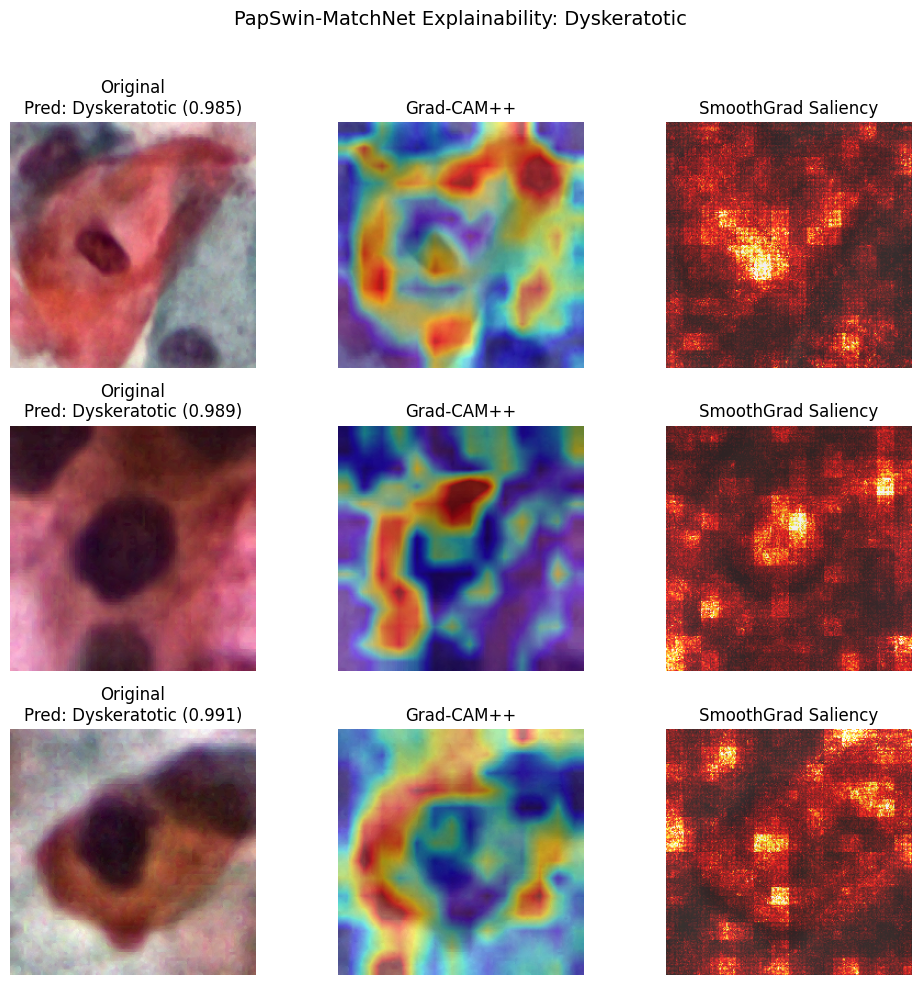

Saved: /kaggle/working/PapSwin_MatchNet_Explainability_FIXED/Dyskeratotic_3Samples_GradCAMPP_SmoothGrad.png


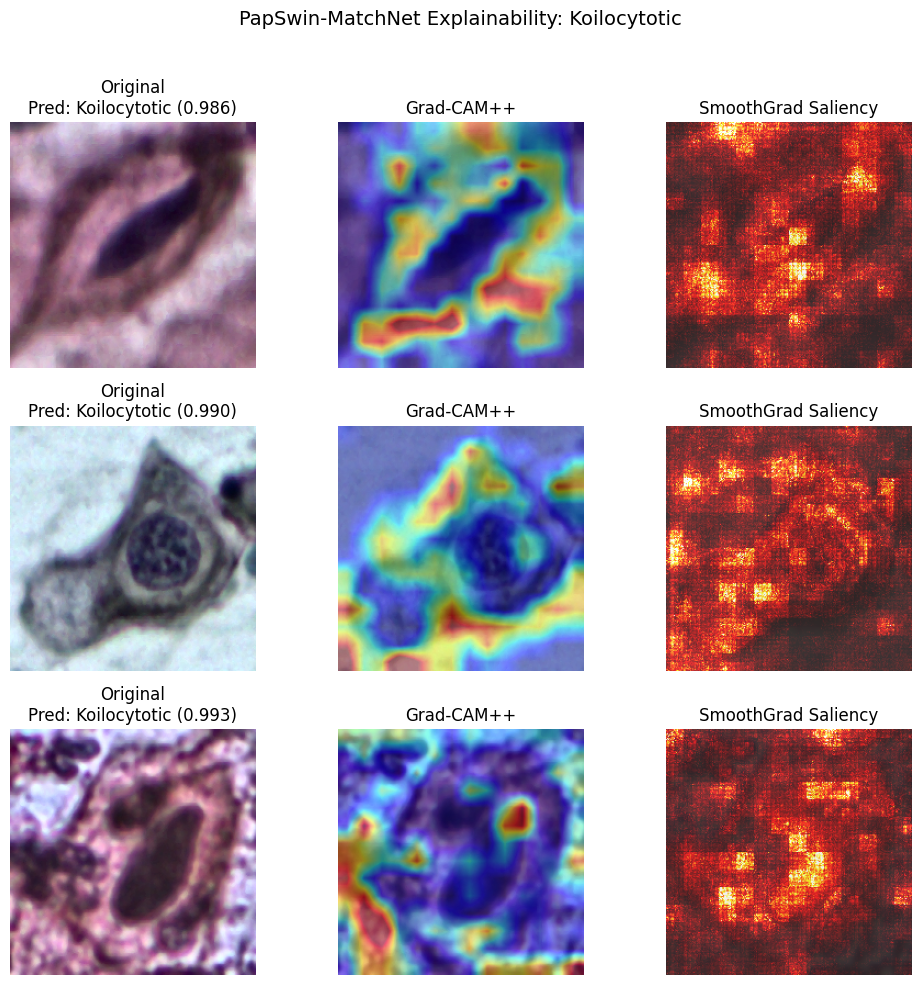

Saved: /kaggle/working/PapSwin_MatchNet_Explainability_FIXED/Koilocytotic_3Samples_GradCAMPP_SmoothGrad.png


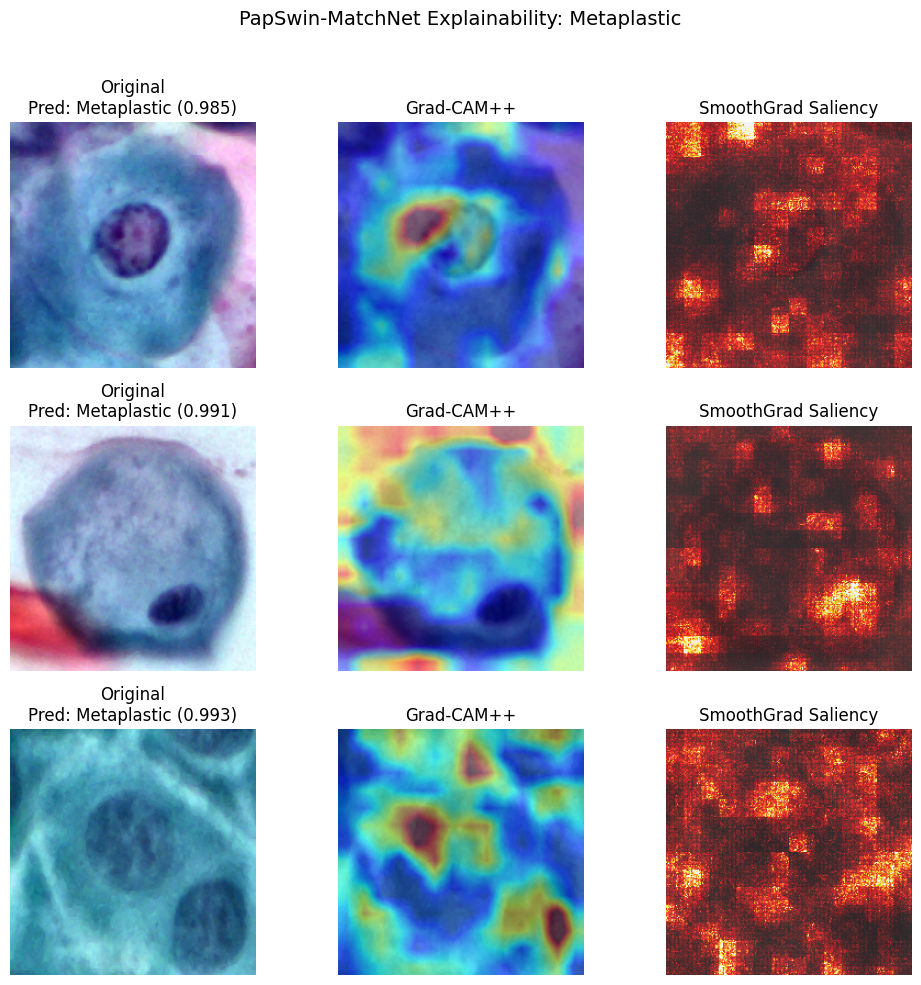

Saved: /kaggle/working/PapSwin_MatchNet_Explainability_FIXED/Metaplastic_3Samples_GradCAMPP_SmoothGrad.png


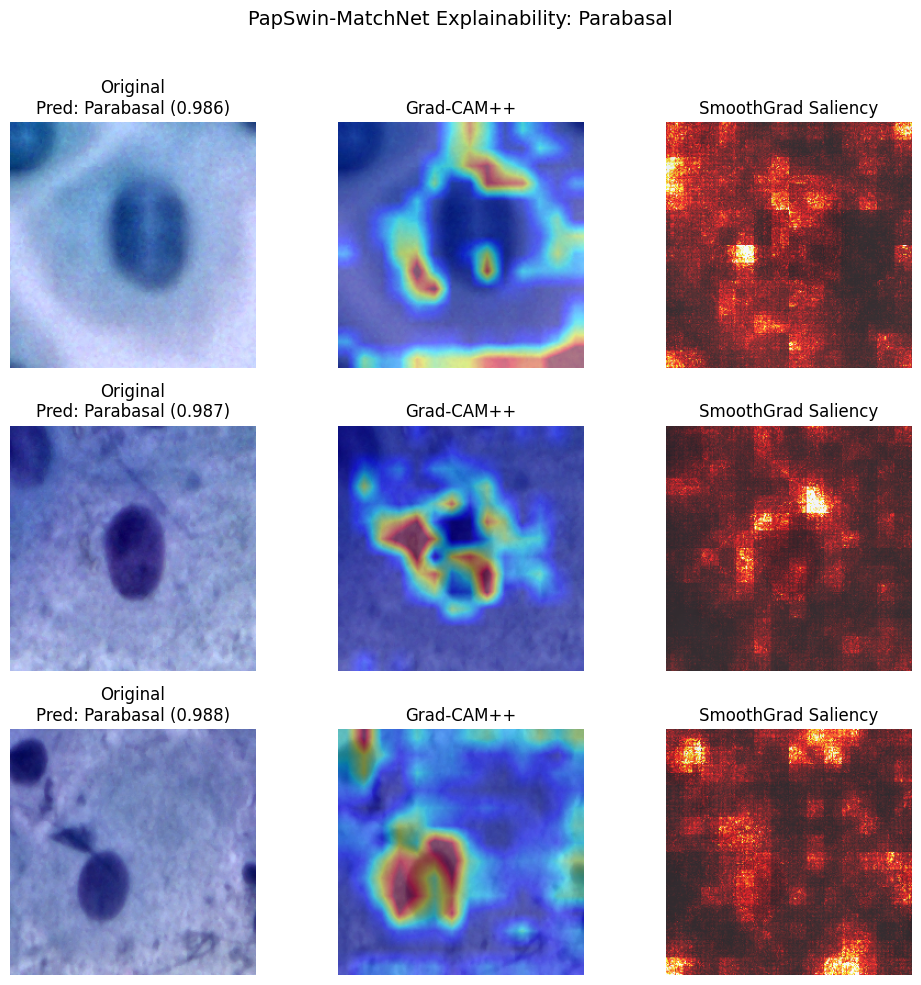

Saved: /kaggle/working/PapSwin_MatchNet_Explainability_FIXED/Parabasal_3Samples_GradCAMPP_SmoothGrad.png


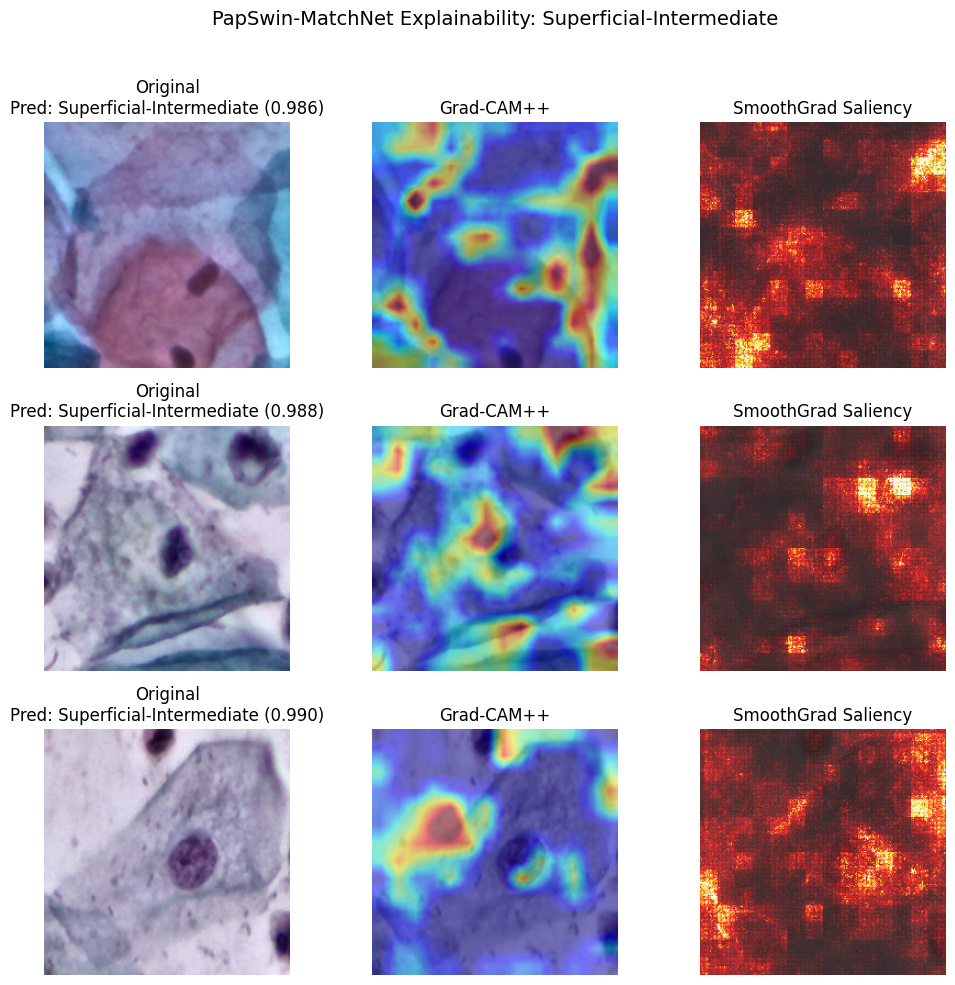

Saved: /kaggle/working/PapSwin_MatchNet_Explainability_FIXED/Superficial-Intermediate_3Samples_GradCAMPP_SmoothGrad.png

Explainability complete: 3 representative correctly classified images per class.
Grad-CAM++ target: 14x14 ConvNeXt local matching stage.
Saliency method: SmoothGrad on final fused class logit.
Saved sample/quality table: /kaggle/working/PapSwin_MatchNet_Explainability_FIXED/Explainability_Selected_Samples.csv


In [ ]:

import os
import sys
import gc
import math
import random
import warnings
import subprocess

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

from torchvision import transforms
from torchvision.datasets import ImageFolder
from torchvision.models import swin_t

warnings.filterwarnings("ignore")

try:
    import timm
except ImportError:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", "timm"]
    )
    import timm

# ============================================================
# SETTINGS
# ============================================================

SEED = 42
IMAGE_SIZE = 224
BATCH_SIZE = 16
NUM_WORKERS = 2

MATCH_DIM = 96
MATCH_HEADS = 4
ROUTER_HIDDEN = 96
CROSS_RANK = 64

MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

TEST_PATH = (
    "/kaggle/working/"
    "SIPaKMeD_Split_80_10_10/test"
)

CHECKPOINT_PATH = (
    "/kaggle/working/"
    "PapSwin_MatchNet_Results/"
    "PapSwin_MatchNet_best.pth"
)

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

AMP_ENABLED = device.type == "cuda"

print("Device:", device)

def autocast_context():
    try:
        return torch.amp.autocast(
            device_type=device.type,
            enabled=AMP_ENABLED,
        )
    except Exception:
        return torch.cuda.amp.autocast(
            enabled=AMP_ENABLED
        )

class ConvProject(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=1,
                bias=False,
            ),
            nn.BatchNorm2d(out_channels),
            nn.GELU(),
        )

    def forward(self, x):
        return self.net(x)


class VectorProject(nn.Module):
    def __init__(self, in_dim, out_dim, dropout=0.10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, out_dim),
            nn.LayerNorm(out_dim),
            nn.GELU(),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)


class BidirectionalSpatialCorrespondenceMatching(nn.Module):
    def __init__(self, dim=96, num_heads=4):
        super().__init__()

        self.dim = dim

        self.local_from_global = nn.MultiheadAttention(
            embed_dim=dim,
            num_heads=num_heads,
            dropout=0.08,
            batch_first=True,
        )

        self.global_from_local = nn.MultiheadAttention(
            embed_dim=dim,
            num_heads=num_heads,
            dropout=0.08,
            batch_first=True,
        )

        self.local_norm = nn.LayerNorm(dim)
        self.global_norm = nn.LayerNorm(dim)

        self.log_temperature = nn.Parameter(
            torch.tensor(math.log(6.0))
        )

        self.match_bias = nn.Parameter(
            torch.tensor(0.0)
        )

    def forward(self, local_map, global_map):
        local_tokens = local_map.flatten(2).transpose(1, 2)
        global_tokens = global_map.flatten(2).transpose(1, 2)

        cosine = F.cosine_similarity(
            local_tokens,
            global_tokens,
            dim=-1,
        ).unsqueeze(-1)

        temperature = torch.exp(
            self.log_temperature
        ).clamp(1.0, 20.0)

        match_confidence = torch.sigmoid(
            temperature
            * (
                cosine
                - self.match_bias
            )
        )

        local_context, _ = self.local_from_global(
            query=local_tokens,
            key=global_tokens,
            value=global_tokens,
            need_weights=False,
        )

        global_context, _ = self.global_from_local(
            query=global_tokens,
            key=local_tokens,
            value=local_tokens,
            need_weights=False,
        )

        matched_local = self.local_norm(
            local_tokens
            + match_confidence
            * local_context
        )

        matched_global = self.global_norm(
            global_tokens
            + match_confidence
            * global_context
        )

        return {
            "local_tokens": matched_local,
            "global_tokens": matched_global,
            "match_confidence": match_confidence.squeeze(-1),
            "raw_cosine": cosine.squeeze(-1),
        }


class MatchConditionedClassRouter(nn.Module):
    def __init__(
        self,
        dim,
        num_classes,
        hidden=96,
        cross_rank=64,
    ):
        super().__init__()

        statistic_dim = dim * 4 + 4

        self.context = nn.Sequential(
            nn.Linear(statistic_dim, hidden),
            nn.GELU(),
            nn.Dropout(0.10),
        )

        self.feature_gate = nn.Sequential(
            nn.Linear(hidden, dim),
            nn.Sigmoid(),
        )

        self.class_gate = nn.Sequential(
            nn.Linear(hidden, num_classes),
            nn.Sigmoid(),
        )

        self.relational_correction = nn.Sequential(
            nn.Linear(dim * 2, cross_rank),
            nn.GELU(),
            nn.Dropout(0.10),
            nn.Linear(cross_rank, dim),
        )

        self.norm = nn.LayerNorm(dim)

        self.fused_classifier = nn.Linear(
            dim,
            num_classes,
        )

        self.routed_scale = nn.Parameter(
            torch.tensor(-0.40)
        )

    @staticmethod
    def branch_reliability(logits):
        probs = torch.softmax(logits, dim=1)

        entropy = -torch.sum(
            probs
            * torch.log(
                probs.clamp_min(1e-8)
            ),
            dim=1,
            keepdim=True,
        )

        reliability = (
            1.0
            - entropy
            / math.log(probs.size(1))
        ).clamp(0.0, 1.0)

        return probs, reliability

    @staticmethod
    def js_divergence(p, q):
        mixture = (
            0.5 * (p + q)
        ).clamp_min(1e-8)

        kl_p = torch.sum(
            p
            * (
                torch.log(
                    p.clamp_min(1e-8)
                )
                - torch.log(mixture)
            ),
            dim=1,
            keepdim=True,
        )

        kl_q = torch.sum(
            q
            * (
                torch.log(
                    q.clamp_min(1e-8)
                )
                - torch.log(mixture)
            ),
            dim=1,
            keepdim=True,
        )

        js = 0.5 * (kl_p + kl_q)

        return (
            js / math.log(2.0)
        ).clamp(0.0, 1.0)

    def forward(
        self,
        local_feature,
        global_feature,
        local_logits,
        global_logits,
        matching_confidence,
    ):
        local_probs, local_rel = self.branch_reliability(
            local_logits
        )

        global_probs, global_rel = self.branch_reliability(
            global_logits
        )

        js = self.js_divergence(
            local_probs,
            global_probs,
        )

        difference = torch.abs(
            local_feature - global_feature
        )

        agreement = (
            local_feature * global_feature
        )

        match_scalar = matching_confidence.unsqueeze(1)

        stats = torch.cat(
            [
                local_feature,
                global_feature,
                difference,
                agreement,
                local_rel,
                global_rel,
                js,
                match_scalar,
            ],
            dim=1,
        )

        context = self.context(stats)

        learned_feature_gate = self.feature_gate(
            context
        )

        class_gate = self.class_gate(
            context
        )

        local_prior = (
            local_rel
            / (
                local_rel
                + global_rel
                + 1e-6
            )
        )

        learned_strength = (
            0.65
            + 0.25
            * match_scalar
        )

        feature_gate = (
            learned_strength
            * learned_feature_gate
            + (
                1.0
                - learned_strength
            )
            * local_prior
        )

        base_feature = (
            feature_gate
            * local_feature
            + (
                1.0
                - feature_gate
            )
            * global_feature
        )

        relation = self.relational_correction(
            torch.cat(
                [
                    difference,
                    agreement,
                ],
                dim=1,
            )
        )

        mean_reliability = (
            0.5
            * (
                local_rel
                + global_rel
            )
        )

        correction_strength = (
            0.50 * js
            + 0.30
            * (
                1.0
                - mean_reliability
            )
            + 0.20
            * (
                1.0
                - match_scalar
            )
        ).clamp(0.0, 1.0)

        fused_feature = self.norm(
            base_feature
            + correction_strength
            * relation
        )

        fused_logits = self.fused_classifier(
            fused_feature
        )

        routed_logits = (
            class_gate * local_logits
            + (
                1.0
                - class_gate
            )
            * global_logits
        )

        routed_strength = (
            0.40
            * torch.sigmoid(
                self.routed_scale
            )
        )

        final_logits = (
            fused_logits
            + routed_strength
            * routed_logits
        )

        return {
            "logits": final_logits,
            "fused_feature": fused_feature,
            "feature_gate": feature_gate,
            "class_gate": class_gate,
            "local_reliability": local_rel.squeeze(1),
            "global_reliability": global_rel.squeeze(1),
            "js_disagreement": js.squeeze(1),
            "correction_strength": correction_strength.squeeze(1),
        }


class PapSwinMatchNet(nn.Module):
    def __init__(
        self,
        num_classes,
        pretrained=False,
    ):
        super().__init__()

        local_model = None
        last_error = None

        for local_name in [
            "convnext_atto.d2_in1k",
            "convnext_atto",
        ]:
            try:
                local_model = timm.create_model(
                    local_name,
                    pretrained=pretrained,
                    num_classes=0,
                )
                break
            except Exception as error:
                last_error = error

        if local_model is None:
            raise RuntimeError(
                "Could not create ConvNeXt-Atto: "
                f"{last_error}"
            )

        self.local_stem = local_model.stem
        self.local_stages = local_model.stages

        self.local_match_channels = 160
        self.local_deep_channels = 320

        del local_model

        # Do not download pretrained Swin here.
        # The saved proposed checkpoint replaces all weights.
        swin_model = swin_t(
            weights=None
        )

        swin_features = list(
            swin_model.features.children()
        )

        self.swin_prefix = nn.Sequential(
            *swin_features[:5]
        )

        stage3_blocks = list(
            swin_features[5].children()
        )

        if len(stage3_blocks) < 2:
            raise RuntimeError(
                "Unexpected Swin-Tiny structure."
            )

        self.swin_stage3_pair = nn.Sequential(
            *stage3_blocks[:2]
        )

        self.global_channels = 384

        self.swin_norm = nn.LayerNorm(
            self.global_channels
        )

        del swin_model

        self.local_match_project = ConvProject(
            self.local_match_channels,
            MATCH_DIM,
        )

        self.global_match_project = ConvProject(
            self.global_channels,
            MATCH_DIM,
        )

        self.spatial_match = (
            BidirectionalSpatialCorrespondenceMatching(
                dim=MATCH_DIM,
                num_heads=MATCH_HEADS,
            )
        )

        self.local_deep_project = VectorProject(
            self.local_deep_channels,
            MATCH_DIM,
            dropout=0.08,
        )

        self.local_vector_norm = nn.LayerNorm(
            MATCH_DIM
        )

        self.global_vector_norm = nn.LayerNorm(
            MATCH_DIM
        )

        self.local_classifier = nn.Linear(
            MATCH_DIM,
            num_classes,
        )

        self.global_classifier = nn.Linear(
            MATCH_DIM,
            num_classes,
        )

        self.router = MatchConditionedClassRouter(
            dim=MATCH_DIM,
            num_classes=num_classes,
            hidden=ROUTER_HIDDEN,
            cross_rank=CROSS_RANK,
        )

    def forward_local(self, x):
        x = self.local_stem(x)

        stages = list(
            self.local_stages.children()
        )

        if len(stages) != 4:
            raise RuntimeError(
                "Unexpected ConvNeXt-Atto stage structure."
            )

        x = stages[0](x)
        x = stages[1](x)

        local_match_map = stages[2](x)

        local_deep_map = stages[3](
            local_match_map
        )

        return (
            local_match_map,
            local_deep_map,
        )

    def forward_global(self, x):
        x = self.swin_prefix(x)
        x = self.swin_stage3_pair(x)
        x = self.swin_norm(x)

        return x.permute(
            0, 3, 1, 2
        ).contiguous()

    @staticmethod
    def token_pool(tokens):
        mean_pool = tokens.mean(
            dim=1
        )

        max_pool = tokens.max(
            dim=1
        ).values

        return (
            0.65 * mean_pool
            + 0.35 * max_pool
        )

    def forward(self, x):
        (
            local_match_map,
            local_deep_map,
        ) = self.forward_local(x)

        global_map = self.forward_global(x)

        if (
            local_match_map.shape[-2:]
            != global_map.shape[-2:]
        ):
            local_match_map = F.interpolate(
                local_match_map,
                size=global_map.shape[-2:],
                mode="bilinear",
                align_corners=False,
            )

        local_projected = self.local_match_project(
            local_match_map
        )

        global_projected = self.global_match_project(
            global_map
        )

        matched = self.spatial_match(
            local_projected,
            global_projected,
        )

        local_matched_vector = self.token_pool(
            matched["local_tokens"]
        )

        global_matched_vector = self.token_pool(
            matched["global_tokens"]
        )

        local_deep_vector = F.adaptive_avg_pool2d(
            local_deep_map,
            1,
        ).flatten(1)

        local_deep_vector = self.local_deep_project(
            local_deep_vector
        )

        local_feature = self.local_vector_norm(
            local_matched_vector
            + 0.50 * local_deep_vector
        )

        global_feature = self.global_vector_norm(
            global_matched_vector
        )

        local_logits = self.local_classifier(
            local_feature
        )

        global_logits = self.global_classifier(
            global_feature
        )

        mean_match_confidence = matched[
            "match_confidence"
        ].mean(dim=1)

        routed = self.router(
            local_feature,
            global_feature,
            local_logits,
            global_logits,
            mean_match_confidence,
        )

        return {
            "logits": routed["logits"],
            "local_logits": local_logits,
            "global_logits": global_logits,
            "embedding": routed["fused_feature"],
            "feature_gate": routed["feature_gate"],
            "class_gate": routed["class_gate"],
            "local_reliability": routed["local_reliability"],
            "global_reliability": routed["global_reliability"],
            "js_disagreement": routed["js_disagreement"],
            "correction_strength": routed["correction_strength"],
            "match_confidence": mean_match_confidence,
            "match_cosine": matched["raw_cosine"].mean(dim=1),
        }



if not os.path.isdir(TEST_PATH):
    raise FileNotFoundError(
        f"Test folder not found: {TEST_PATH}"
    )

if not os.path.isfile(CHECKPOINT_PATH):
    raise FileNotFoundError(
        f"Proposed checkpoint not found: {CHECKPOINT_PATH}"
    )

# Read class mapping from the exact test dataset.
mapping_dataset = ImageFolder(
    TEST_PATH
)

class_names = mapping_dataset.classes
class_to_idx = mapping_dataset.class_to_idx
num_classes = len(class_names)

print(
    f"Detected {num_classes} classes: "
    f"{class_names}"
)

print(
    "Class mapping:",
    class_to_idx,
)

# Evaluation transform needed by the explainability dataset.
eval_to_tensor = transforms.Compose([
    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        MEAN,
        STD,
    ),
])

# Reconstruct model first.
model = PapSwinMatchNet(
    num_classes=num_classes,
    pretrained=False,
).to(device)

# Then load the already-trained proposed checkpoint.
checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location="cpu",
)

if (
    isinstance(checkpoint, dict)
    and "class_to_idx" in checkpoint
):
    if (
        checkpoint["class_to_idx"]
        != class_to_idx
    ):
        raise ValueError(
            "Checkpoint class mapping does not match "
            "the current test dataset."
        )

state_dict = (
    checkpoint["model_state_dict"]
    if (
        isinstance(checkpoint, dict)
        and "model_state_dict" in checkpoint
    )
    else checkpoint
)

model.load_state_dict(
    state_dict,
    strict=True,
)

model.eval()

print(
    "Saved proposed PapSwin-MatchNet loaded successfully."
)

print(
    "Checkpoint:",
    CHECKPOINT_PATH,
)

print(
    "No retraining is performed."
)



EXPLAIN_DIR = (
    "/kaggle/working/"
    "PapSwin_MatchNet_Explainability_FIXED"
)

os.makedirs(
    EXPLAIN_DIR,
    exist_ok=True,
)


mean_t = torch.tensor(
    MEAN,
    dtype=torch.float32,
).view(
    3, 1, 1
)

std_t = torch.tensor(
    STD,
    dtype=torch.float32,
).view(
    3, 1, 1
)


def tensor_to_rgb(
    tensor,
):
    image = (
        tensor.detach().cpu().float()
        * std_t
        + mean_t
    )

    image = image.clamp(
        0.0,
        1.0,
    )

    return image.permute(
        1, 2, 0
    ).numpy()


def robust_normalize_map(
    heatmap,
    low_percentile=1.0,
    high_percentile=99.0,
):
    """
    Robust [0,1] normalization.
    Percentile clipping avoids one extreme pixel making the
    entire saliency map look almost black.
    """
    heatmap = np.asarray(
        heatmap,
        dtype=np.float32,
    )

    if not np.isfinite(
        heatmap
    ).all():
        heatmap = np.nan_to_num(
            heatmap,
            nan=0.0,
            posinf=0.0,
            neginf=0.0,
        )

    lo = float(
        np.percentile(
            heatmap,
            low_percentile,
        )
    )

    hi = float(
        np.percentile(
            heatmap,
            high_percentile,
        )
    )

    if hi <= lo + 1e-12:
        lo = float(
            heatmap.min()
        )
        hi = float(
            heatmap.max()
        )

    heatmap = np.clip(
        heatmap,
        lo,
        hi,
    )

    heatmap = (
        heatmap - lo
    )

    denom = (
        hi - lo
    )

    if denom > 1e-12:
        heatmap = (
            heatmap / denom
        )
    else:
        heatmap = np.zeros_like(
            heatmap,
            dtype=np.float32,
        )

    return heatmap



def fused_class_score(
    current_model,
    x,
    target_class,
):
    output = current_model(
        x
    )

    score = output[
        "logits"
    ][
        0,
        int(
            target_class
        ),
    ]

    return score


def gradcam_plus_plus_fixed(
    current_model,
    input_tensor,
    target_class,
):
    current_model.eval()

    current_model.zero_grad(
        set_to_none=True
    )

    activations = {}
    gradients = {}

    local_stages = list(
        current_model.local_stages.children()
    )

    if len(
        local_stages
    ) < 3:
        raise RuntimeError(
            "Unexpected ConvNeXt stage structure."
        )

    
    target_layer = local_stages[
        -2
    ]

    def forward_hook(
        module,
        inputs,
        output,
    ):
        activations[
            "value"
        ] = output

        def save_gradient(
            grad,
        ):
            gradients[
                "value"
            ] = grad

        output.register_hook(
            save_gradient
        )

    handle = (
        target_layer
        .register_forward_hook(
            forward_hook
        )
    )

    x = (
        input_tensor
        .clone()
        .detach()
        .to(
            device,
            dtype=torch.float32,
        )
    )

    x.requires_grad_(
        True
    )

    try:
        
        with torch.enable_grad():
            score = fused_class_score(
                current_model,
                x,
                target_class,
            )

            score.backward(
                retain_graph=False
            )

        if (
            "value"
            not in activations
            or "value"
            not in gradients
        ):
            raise RuntimeError(
                "Grad-CAM++ hooks did not capture "
                "activations/gradients."
            )

        activation = activations[
            "value"
        ]

        gradient = gradients[
            "value"
        ]

        if (
            activation.ndim != 4
            or gradient.ndim != 4
        ):
            raise RuntimeError(
                "Grad-CAM++ requires a 4-D NCHW "
                "feature map."
            )

        
        grad2 = (
            gradient ** 2
        )

        grad3 = (
            gradient ** 3
        )

        # Sum over spatial dimensions for each channel.
        sum_activation_grad3 = (
            activation
            * grad3
        ).sum(
            dim=(2, 3),
            keepdim=True,
        )

        denominator = (
            2.0
            * grad2
            + sum_activation_grad3
        )

        # Stable division.
        denominator = torch.where(
            torch.abs(
                denominator
            ) > 1e-8,
            denominator,
            torch.ones_like(
                denominator
            ),
        )

        alpha = (
            grad2
            / (
                denominator
                + 1e-8
            )
        )

        positive_gradients = F.relu(
            gradient
        )

        weights = (
            alpha
            * positive_gradients
        ).sum(
            dim=(2, 3),
            keepdim=True,
        )

        cam = (
            weights
            * activation
        ).sum(
            dim=1,
            keepdim=True,
        )

        cam = F.relu(
            cam
        )

        cam = F.interpolate(
            cam,
            size=(
                IMAGE_SIZE,
                IMAGE_SIZE,
            ),
            mode="bilinear",
            align_corners=False,
        )

        cam = (
            cam[
                0,
                0
            ]
            .detach()
            .cpu()
            .numpy()
        )

        cam = robust_normalize_map(
            cam,
            low_percentile=1.0,
            high_percentile=99.0,
        )

    finally:
        handle.remove()

    return cam



def smoothgrad_saliency(
    current_model,
    input_tensor,
    target_class,
    n_samples=16,
    noise_std=0.06,
):
    current_model.eval()

    base = (
        input_tensor
        .clone()
        .detach()
        .to(
            device,
            dtype=torch.float32,
        )
    )

    grad_accumulator = torch.zeros_like(
        base
    )

    
    generator = torch.Generator(
        device=device
    )

    generator.manual_seed(
        SEED
        + int(
            target_class
        )
        * 1000
    )

    for sample_index in range(
        n_samples
    ):
        noise = torch.randn(
            base.shape,
            generator=generator,
            device=device,
            dtype=base.dtype,
        ) * noise_std

        x_noisy = (
            base
            + noise
        ).detach()

        x_noisy.requires_grad_(
            True
        )

        current_model.zero_grad(
            set_to_none=True
        )

        with torch.enable_grad():
            score = fused_class_score(
                current_model,
                x_noisy,
                target_class,
            )

            gradient = torch.autograd.grad(
                outputs=score,
                inputs=x_noisy,
                retain_graph=False,
                create_graph=False,
            )[0]

        grad_accumulator += (
            gradient.abs()
        )

    smooth_gradient = (
        grad_accumulator
        / float(
            n_samples
        )
    )

    # Maximum sensitivity over RGB channels.
    saliency = smooth_gradient.max(
        dim=1
    ).values[
        0
    ]

    saliency = (
        saliency
        .detach()
        .cpu()
        .numpy()
    )

    saliency = robust_normalize_map(
        saliency,
        low_percentile=2.0,
        high_percentile=99.5,
    )

    return saliency


def central_energy_fraction(
    heatmap,
    border_fraction=0.10,
):
    h, w = heatmap.shape

    y0 = int(
        h * border_fraction
    )
    y1 = int(
        h * (
            1.0
            - border_fraction
        )
    )

    x0 = int(
        w * border_fraction
    )
    x1 = int(
        w * (
            1.0
            - border_fraction
        )
    )

    total = float(
        heatmap.sum()
    )

    if total <= 1e-12:
        return 0.0

    center = float(
        heatmap[
            y0:y1,
            x0:x1
        ].sum()
    )

    return (
        center / total
    )


# ------------------------------------------------------------
# Dataset
# ------------------------------------------------------------
explain_dataset = ImageFolder(
    TEST_PATH,
    transform=eval_to_tensor,
)

explain_loader = DataLoader(
    explain_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=AMP_ENABLED,
)

# ------------------------------------------------------------
# Get correct predictions and confidences
# ------------------------------------------------------------
candidates = {
    i: []
    for i in range(
        num_classes
    )
}

model.eval()

global_index = 0

with torch.no_grad():
    for images, targets in explain_loader:
        images_gpu = images.to(
            device,
            non_blocking=True,
        )

        # Prediction only: AMP is okay here.
        with autocast_context():
            logits = model(
                images_gpu
            )[
                "logits"
            ].float()

        probs = torch.softmax(
            logits,
            dim=1,
        )

        pred = probs.argmax(
            dim=1
        )

        conf = probs.max(
            dim=1
        ).values

        batch_now = images.size(
            0
        )

        for j in range(
            batch_now
        ):
            true_class = int(
                targets[j]
            )

            if int(
                pred[j].cpu()
            ) == true_class:
                candidates[
                    true_class
                ].append(
                    (
                        float(
                            conf[j].cpu()
                        ),
                        global_index + j,
                    )
                )

        global_index += batch_now



selected_indices = {}

for class_idx in range(
    num_classes
):
    ranked = sorted(
        candidates[
            class_idx
        ],
        key=lambda x: x[0],
    )

    if len(
        ranked
    ) < 3:
        raise RuntimeError(
            f"Not enough correctly classified images "
            f"for class {class_names[class_idx]}."
        )

    positions = [
        int(
            round(
                0.25
                * (
                    len(ranked)
                    - 1
                )
            )
        ),
        int(
            round(
                0.50
                * (
                    len(ranked)
                    - 1
                )
            )
        ),
        int(
            round(
                0.75
                * (
                    len(ranked)
                    - 1
                )
            )
        ),
    ]

    # Ensure three unique positions.
    positions = list(
        dict.fromkeys(
            positions
        )
    )

    if len(
        positions
    ) < 3:
        positions = [
            0,
            len(ranked) // 2,
            len(ranked) - 1,
        ]

    selected_indices[
        class_idx
    ] = [
        ranked[
            pos
        ][1]
        for pos in positions[:3]
    ]


quality_rows = []

for class_idx, class_name in enumerate(
    class_names
):
    fig, axes = plt.subplots(
        3,
        3,
        figsize=(
            10,
            10,
        ),
    )

    for row, sample_idx in enumerate(
        selected_indices[
            class_idx
        ]
    ):
        (
            input_tensor,
            true_label,
        ) = explain_dataset[
            sample_idx
        ]

        x = input_tensor.unsqueeze(
            0
        ).to(
            device,
            dtype=torch.float32,
        )

        # Prediction for title.
        model.eval()

        with torch.no_grad():
            logits = model(
                x
            )[
                "logits"
            ].float()

            prob = torch.softmax(
                logits,
                dim=1,
            )

            predicted_class = int(
                prob.argmax(
                    dim=1
                )[0]
            )

            predicted_conf = float(
                prob[
                    0,
                    predicted_class
                ].cpu()
            )

        # Explain the ACTUAL predicted class.
        cam = gradcam_plus_plus_fixed(
            model,
            x,
            target_class=predicted_class,
        )

        saliency = smoothgrad_saliency(
            model,
            x,
            target_class=predicted_class,
            n_samples=16,
            noise_std=0.06,
        )

        rgb = tensor_to_rgb(
            input_tensor
        )

        cam_center_fraction = (
            central_energy_fraction(
                cam
            )
        )

        saliency_center_fraction = (
            central_energy_fraction(
                saliency
            )
        )

        quality_rows.append({
            "Class": class_name,
            "Sample Index": sample_idx,
            "Predicted Class": (
                class_names[
                    predicted_class
                ]
            ),
            "Confidence": (
                predicted_conf
            ),
            "GradCAM Central Energy": (
                cam_center_fraction
            ),
            "Saliency Central Energy": (
                saliency_center_fraction
            ),
        })

        # -------------------------
        # Original
        # -------------------------
        axes[
            row,
            0
        ].imshow(
            rgb
        )

        axes[
            row,
            0
        ].set_title(
            "Original\n"
            f"Pred: "
            f"{class_names[predicted_class].replace('im_', '')} "
            f"({predicted_conf:.3f})"
        )

        axes[
            row,
            0
        ].axis(
            "off"
        )

        # -------------------------
        # Grad-CAM++
        # -------------------------
        axes[
            row,
            1
        ].imshow(
            rgb
        )

        axes[
            row,
            1
        ].imshow(
            cam,
            cmap="jet",
            alpha=0.48,
            vmin=0.0,
            vmax=1.0,
        )

        axes[
            row,
            1
        ].set_title(
            "Grad-CAM++"
        )

        axes[
            row,
            1
        ].axis(
            "off"
        )

        # -------------------------
        # SmoothGrad saliency
        # -------------------------
        axes[
            row,
            2
        ].imshow(
            rgb,
            alpha=0.35,
        )

        axes[
            row,
            2
        ].imshow(
            saliency,
            cmap="hot",
            alpha=0.80,
            vmin=0.0,
            vmax=1.0,
        )

        axes[
            row,
            2
        ].set_title(
            "SmoothGrad Saliency"
        )

        axes[
            row,
            2
        ].axis(
            "off"
        )

    clean_name = (
        class_name
        .replace(
            "im_",
            "",
        )
        .replace(
            "/",
            "_",
        )
        .replace(
            " ",
            "_",
        )
    )

    fig.suptitle(
        "PapSwin-MatchNet Explainability: "
        f"{class_name.replace('im_', '')}",
        fontsize=14,
    )

    plt.tight_layout(
        rect=[
            0,
            0,
            1,
            0.96,
        ]
    )

    save_path = os.path.join(
        EXPLAIN_DIR,
        f"{clean_name}_"
        "3Samples_GradCAMPP_SmoothGrad.png",
    )

    plt.savefig(
        save_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    print(
        "Saved:",
        save_path,
    )


quality_df = pd.DataFrame(
    quality_rows
)

quality_csv = os.path.join(
    EXPLAIN_DIR,
    "Explainability_Selected_Samples.csv",
)

quality_df.to_csv(
    quality_csv,
    index=False,
)

print(
    "\nExplainability complete: "
    "3 representative correctly classified "
    "images per class."
)

print(
    "Grad-CAM++ target: 14x14 ConvNeXt local matching stage."
)

print(
    "Saliency method: SmoothGrad on final fused class logit."
)

print(
    "Saved sample/quality table:",
    quality_csv,
)


# **Robustness test**

Device: cuda
Detected 5 classes: ['im_Dyskeratotic', 'im_Koilocytotic', 'im_Metaplastic', 'im_Parabasal', 'im_Superficial-Intermediate']
Class mapping: {'im_Dyskeratotic': 0, 'im_Koilocytotic': 1, 'im_Metaplastic': 2, 'im_Parabasal': 3, 'im_Superficial-Intermediate': 4}
Saved validation temperature: 0.9419

Clean row loaded directly from:
/kaggle/working/PapSwin_MatchNet_Results/PapSwin_MatchNet_summary_metrics.csv
Evaluating robustness: Gaussian Noise (sigma=0.02)
Evaluating robustness: Gaussian Blur (radius=0.6)
Evaluating robustness: Brightness (+8%)
Evaluating robustness: Contrast (-8%)
Evaluating robustness: JPEG Compression (quality=85)
Evaluating robustness: Rotation (+3 degrees)
Evaluating robustness: Gamma (gamma=1.08)

ROBUSTNESS RESULTS
       Condition   Severity  Accuracy  Balanced Accuracy  Macro Precision  Macro Recall  Macro F1    MCC  Kappa  Macro ROC AUC  Macro PR AUC    NLL    ECE  Accuracy Drop (pp)
           Clean       None    0.9753             0.9754           

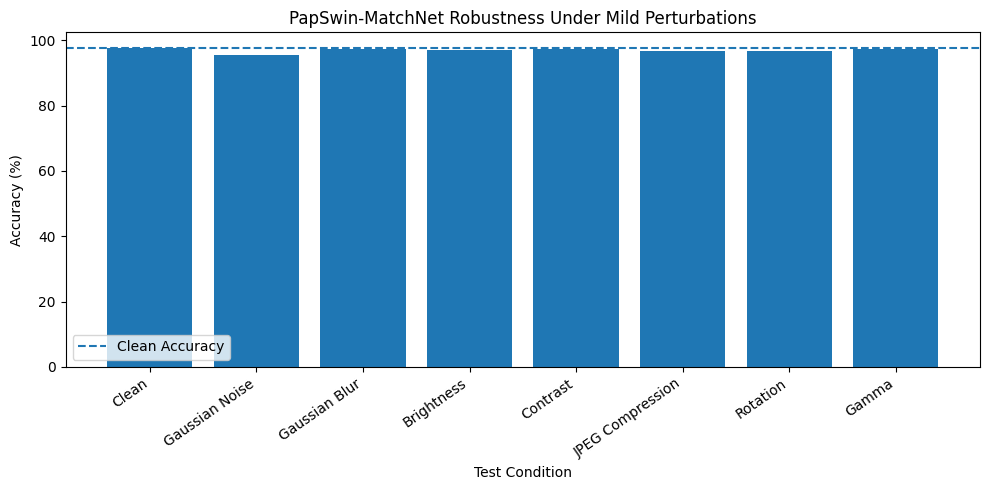

Robustness plot: /kaggle/working/PapSwin_MatchNet_Robustness/PapSwin_MatchNet_Robustness_Accuracy.png


In [ ]:
import os
import sys
import gc
import io
import time
import math
import random
import warnings
import subprocess
from pathlib import Path
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, ImageFilter, ImageEnhance

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    cohen_kappa_score,
    matthews_corrcoef,
    roc_auc_score,
    average_precision_score,
    log_loss,
)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torchvision.models import swin_t

warnings.filterwarnings("ignore")

try:
    import timm
except ImportError:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", "timm"]
    )
    import timm

# ------------------------------------------------------------
# FIXED SETTINGS / PATHS
# ------------------------------------------------------------
SEED = 42
IMAGE_SIZE = 224
BATCH_SIZE = 16
NUM_WORKERS = 2
USE_TTA = True

MATCH_DIM = 96
MATCH_HEADS = 4
ROUTER_HIDDEN = 96
CROSS_RANK = 64

TEST_PATH = (
    "/kaggle/working/"
    "SIPaKMeD_Split_80_10_10/test"
)

VAL_PATH = (
    "/kaggle/working/"
    "SIPaKMeD_Split_80_10_10/val"
)

PROPOSED_RESULT_DIR = (
    "/kaggle/working/"
    "PapSwin_MatchNet_Results"
)

CHECKPOINT_PATH = os.path.join(
    PROPOSED_RESULT_DIR,
    "PapSwin_MatchNet_best.pth",
)

SUMMARY_PATH = os.path.join(
    PROPOSED_RESULT_DIR,
    "PapSwin_MatchNet_summary_metrics.csv",
)

ROBUSTNESS_DIR = (
    "/kaggle/working/"
    "PapSwin_MatchNet_Robustness"
)

os.makedirs(
    ROBUSTNESS_DIR,
    exist_ok=True,
)

ROBUSTNESS_CSV = os.path.join(
    ROBUSTNESS_DIR,
    "PapSwin_MatchNet_Robustness.csv",
)

MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)
AMP_ENABLED = device.type == "cuda"

print("Device:", device)

# EXACT PROPOSED-MODEL ARCHITECTURE


class ConvProject(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=1,
                bias=False,
            ),
            nn.BatchNorm2d(out_channels),
            nn.GELU(),
        )

    def forward(self, x):
        return self.net(x)


class VectorProject(nn.Module):
    def __init__(self, in_dim, out_dim, dropout=0.10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, out_dim),
            nn.LayerNorm(out_dim),
            nn.GELU(),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)


class BidirectionalSpatialCorrespondenceMatching(nn.Module):
    def __init__(self, dim=96, num_heads=4):
        super().__init__()

        self.dim = dim

        self.local_from_global = nn.MultiheadAttention(
            embed_dim=dim,
            num_heads=num_heads,
            dropout=0.08,
            batch_first=True,
        )

        self.global_from_local = nn.MultiheadAttention(
            embed_dim=dim,
            num_heads=num_heads,
            dropout=0.08,
            batch_first=True,
        )

        self.local_norm = nn.LayerNorm(dim)
        self.global_norm = nn.LayerNorm(dim)

        self.log_temperature = nn.Parameter(
            torch.tensor(
                math.log(6.0)
            )
        )

        self.match_bias = nn.Parameter(
            torch.tensor(0.0)
        )

    def forward(self, local_map, global_map):
        local_tokens = local_map.flatten(
            2
        ).transpose(
            1, 2
        )

        global_tokens = global_map.flatten(
            2
        ).transpose(
            1, 2
        )

        cosine = F.cosine_similarity(
            local_tokens,
            global_tokens,
            dim=-1,
        ).unsqueeze(-1)

        temperature = torch.exp(
            self.log_temperature
        ).clamp(
            1.0,
            20.0,
        )

        match_confidence = torch.sigmoid(
            temperature
            * (
                cosine
                - self.match_bias
            )
        )

        local_context, _ = self.local_from_global(
            query=local_tokens,
            key=global_tokens,
            value=global_tokens,
            need_weights=False,
        )

        global_context, _ = self.global_from_local(
            query=global_tokens,
            key=local_tokens,
            value=local_tokens,
            need_weights=False,
        )

        matched_local = self.local_norm(
            local_tokens
            + match_confidence
            * local_context
        )

        matched_global = self.global_norm(
            global_tokens
            + match_confidence
            * global_context
        )

        return {
            "local_tokens": matched_local,
            "global_tokens": matched_global,
            "match_confidence": (
                match_confidence.squeeze(-1)
            ),
            "raw_cosine": cosine.squeeze(-1),
        }


class MatchConditionedClassRouter(nn.Module):
    def __init__(
        self,
        dim,
        num_classes,
        hidden=96,
        cross_rank=64,
    ):
        super().__init__()

        statistic_dim = dim * 4 + 4

        self.context = nn.Sequential(
            nn.Linear(
                statistic_dim,
                hidden,
            ),
            nn.GELU(),
            nn.Dropout(0.10),
        )

        self.feature_gate = nn.Sequential(
            nn.Linear(hidden, dim),
            nn.Sigmoid(),
        )

        self.class_gate = nn.Sequential(
            nn.Linear(
                hidden,
                num_classes,
            ),
            nn.Sigmoid(),
        )

        self.relational_correction = nn.Sequential(
            nn.Linear(
                dim * 2,
                cross_rank,
            ),
            nn.GELU(),
            nn.Dropout(0.10),
            nn.Linear(
                cross_rank,
                dim,
            ),
        )

        self.norm = nn.LayerNorm(dim)

        self.fused_classifier = nn.Linear(
            dim,
            num_classes,
        )

        self.routed_scale = nn.Parameter(
            torch.tensor(-0.40)
        )

    @staticmethod
    def branch_reliability(logits):
        probs = torch.softmax(
            logits,
            dim=1,
        )

        entropy = -torch.sum(
            probs
            * torch.log(
                probs.clamp_min(1e-8)
            ),
            dim=1,
            keepdim=True,
        )

        reliability = (
            1.0
            - entropy
            / math.log(
                probs.size(1)
            )
        ).clamp(
            0.0,
            1.0,
        )

        return probs, reliability

    @staticmethod
    def js_divergence(p, q):
        mixture = (
            0.5 * (p + q)
        ).clamp_min(1e-8)

        kl_p = torch.sum(
            p
            * (
                torch.log(
                    p.clamp_min(1e-8)
                )
                - torch.log(mixture)
            ),
            dim=1,
            keepdim=True,
        )

        kl_q = torch.sum(
            q
            * (
                torch.log(
                    q.clamp_min(1e-8)
                )
                - torch.log(mixture)
            ),
            dim=1,
            keepdim=True,
        )

        js = 0.5 * (kl_p + kl_q)

        return (
            js / math.log(2.0)
        ).clamp(
            0.0,
            1.0,
        )

    def forward(
        self,
        local_feature,
        global_feature,
        local_logits,
        global_logits,
        matching_confidence,
    ):
        local_probs, local_rel = (
            self.branch_reliability(
                local_logits
            )
        )

        global_probs, global_rel = (
            self.branch_reliability(
                global_logits
            )
        )

        js = self.js_divergence(
            local_probs,
            global_probs,
        )

        difference = torch.abs(
            local_feature
            - global_feature
        )

        agreement = (
            local_feature
            * global_feature
        )

        match_scalar = (
            matching_confidence.unsqueeze(1)
        )

        stats = torch.cat(
            [
                local_feature,
                global_feature,
                difference,
                agreement,
                local_rel,
                global_rel,
                js,
                match_scalar,
            ],
            dim=1,
        )

        context = self.context(stats)

        learned_feature_gate = (
            self.feature_gate(context)
        )

        class_gate = (
            self.class_gate(context)
        )

        local_prior = (
            local_rel
            / (
                local_rel
                + global_rel
                + 1e-6
            )
        )

        learned_strength = (
            0.65
            + 0.25
            * match_scalar
        )

        feature_gate = (
            learned_strength
            * learned_feature_gate
            + (
                1.0
                - learned_strength
            )
            * local_prior
        )

        base_feature = (
            feature_gate
            * local_feature
            + (
                1.0
                - feature_gate
            )
            * global_feature
        )

        relation = (
            self.relational_correction(
                torch.cat(
                    [
                        difference,
                        agreement,
                    ],
                    dim=1,
                )
            )
        )

        mean_reliability = (
            0.5
            * (
                local_rel
                + global_rel
            )
        )

        correction_strength = (
            0.50 * js
            + 0.30
            * (
                1.0
                - mean_reliability
            )
            + 0.20
            * (
                1.0
                - match_scalar
            )
        ).clamp(
            0.0,
            1.0,
        )

        fused_feature = self.norm(
            base_feature
            + correction_strength
            * relation
        )

        fused_logits = (
            self.fused_classifier(
                fused_feature
            )
        )

        routed_logits = (
            class_gate
            * local_logits
            + (
                1.0
                - class_gate
            )
            * global_logits
        )

        routed_strength = (
            0.40
            * torch.sigmoid(
                self.routed_scale
            )
        )

        final_logits = (
            fused_logits
            + routed_strength
            * routed_logits
        )

        return {
            "logits": final_logits,
            "fused_feature": fused_feature,
            "feature_gate": feature_gate,
            "class_gate": class_gate,
            "local_reliability": (
                local_rel.squeeze(1)
            ),
            "global_reliability": (
                global_rel.squeeze(1)
            ),
            "js_disagreement": js.squeeze(1),
            "correction_strength": (
                correction_strength.squeeze(1)
            ),
        }


class PapSwinMatchNet(nn.Module):
    def __init__(
        self,
        num_classes,
        pretrained=False,
    ):
        super().__init__()

        local_model = None

        candidates = [
            "convnext_atto.d2_in1k",
            "convnext_atto",
        ]

        last_error = None

        for name in candidates:
            try:
                local_model = timm.create_model(
                    name,
                    pretrained=pretrained,
                    num_classes=0,
                )
                break
            except Exception as error:
                last_error = error

        if local_model is None:
            raise RuntimeError(
                "Could not create ConvNeXt-Atto: "
                f"{last_error}"
            )

        self.local_stem = local_model.stem
        self.local_stages = (
            local_model.stages
        )

        self.local_match_channels = 160
        self.local_deep_channels = 320

        del local_model

        if pretrained:
            from torchvision.models import (
                Swin_T_Weights
            )

            try:
                swin_model = swin_t(
                    weights=(
                        Swin_T_Weights
                        .IMAGENET1K_V1
                    )
                )
            except Exception:
                swin_model = swin_t(
                    weights=None
                )
        else:
            swin_model = swin_t(
                weights=None
            )

        swin_features = list(
            swin_model.features.children()
        )

        self.swin_prefix = nn.Sequential(
            *swin_features[:5]
        )

        stage3_blocks = list(
            swin_features[5].children()
        )

        self.swin_stage3_pair = nn.Sequential(
            *stage3_blocks[:2]
        )

        self.global_channels = 384

        self.swin_norm = nn.LayerNorm(
            self.global_channels
        )

        del swin_model

        self.local_match_project = ConvProject(
            self.local_match_channels,
            MATCH_DIM,
        )

        self.global_match_project = ConvProject(
            self.global_channels,
            MATCH_DIM,
        )

        self.spatial_match = (
            BidirectionalSpatialCorrespondenceMatching(
                dim=MATCH_DIM,
                num_heads=MATCH_HEADS,
            )
        )

        self.local_deep_project = VectorProject(
            self.local_deep_channels,
            MATCH_DIM,
            dropout=0.08,
        )

        self.local_vector_norm = nn.LayerNorm(
            MATCH_DIM
        )

        self.global_vector_norm = nn.LayerNorm(
            MATCH_DIM
        )

        self.local_classifier = nn.Linear(
            MATCH_DIM,
            num_classes,
        )

        self.global_classifier = nn.Linear(
            MATCH_DIM,
            num_classes,
        )

        self.router = (
            MatchConditionedClassRouter(
                dim=MATCH_DIM,
                num_classes=num_classes,
                hidden=ROUTER_HIDDEN,
                cross_rank=CROSS_RANK,
            )
        )

    def local_backbone_parameters(self):
        return (
            list(
                self.local_stem.parameters()
            )
            + list(
                self.local_stages.parameters()
            )
        )

    def global_backbone_parameters(self):
        return (
            list(
                self.swin_prefix.parameters()
            )
            + list(
                self.swin_stage3_pair.parameters()
            )
        )

    def set_finetune_stage(self, stage):
        for p in self.local_stem.parameters():
            p.requires_grad = False

        for p in self.local_stages.parameters():
            p.requires_grad = False

        for p in self.swin_prefix.parameters():
            p.requires_grad = False

        for p in self.swin_stage3_pair.parameters():
            p.requires_grad = False

        if stage == 0:
            return

        if stage >= 1:
            stages = list(
                self.local_stages.children()
            )

            for module in stages[-2:]:
                for p in module.parameters():
                    p.requires_grad = True

            for p in (
                self.swin_stage3_pair.parameters()
            ):
                p.requires_grad = True

        if stage >= 2:
            stages = list(
                self.local_stages.children()
            )

            if len(stages) >= 3:
                for p in stages[-3].parameters():
                    p.requires_grad = True

            prefix = list(
                self.swin_prefix.children()
            )

            if len(prefix) >= 5:
                for p in prefix[3].parameters():
                    p.requires_grad = True

                for p in prefix[4].parameters():
                    p.requires_grad = True

    def forward_local(self, x):
        x = self.local_stem(x)

        stages = list(
            self.local_stages.children()
        )

        x = stages[0](x)
        x = stages[1](x)

        local_match_map = stages[2](x)
        local_deep_map = stages[3](
            local_match_map
        )

        return (
            local_match_map,
            local_deep_map,
        )

    def forward_global(self, x):
        x = self.swin_prefix(x)
        x = self.swin_stage3_pair(x)
        x = self.swin_norm(x)

        return x.permute(
            0, 3, 1, 2
        ).contiguous()

    @staticmethod
    def token_pool(tokens):
        mean_pool = tokens.mean(dim=1)
        max_pool = tokens.max(
            dim=1
        ).values

        return (
            0.65 * mean_pool
            + 0.35 * max_pool
        )

    def forward(self, x):
        (
            local_match_map,
            local_deep_map,
        ) = self.forward_local(x)

        global_map = (
            self.forward_global(x)
        )

        if (
            local_match_map.shape[-2:]
            != global_map.shape[-2:]
        ):
            local_match_map = F.interpolate(
                local_match_map,
                size=global_map.shape[-2:],
                mode="bilinear",
                align_corners=False,
            )

        local_projected = (
            self.local_match_project(
                local_match_map
            )
        )

        global_projected = (
            self.global_match_project(
                global_map
            )
        )

        matched = self.spatial_match(
            local_projected,
            global_projected,
        )

        local_matched_vector = (
            self.token_pool(
                matched[
                    "local_tokens"
                ]
            )
        )

        global_matched_vector = (
            self.token_pool(
                matched[
                    "global_tokens"
                ]
            )
        )

        local_deep_vector = (
            F.adaptive_avg_pool2d(
                local_deep_map,
                1,
            ).flatten(1)
        )

        local_deep_vector = (
            self.local_deep_project(
                local_deep_vector
            )
        )

        local_feature = (
            self.local_vector_norm(
                local_matched_vector
                + 0.50
                * local_deep_vector
            )
        )

        global_feature = (
            self.global_vector_norm(
                global_matched_vector
            )
        )

        local_logits = (
            self.local_classifier(
                local_feature
            )
        )

        global_logits = (
            self.global_classifier(
                global_feature
            )
        )

        mean_match_confidence = (
            matched[
                "match_confidence"
            ].mean(dim=1)
        )

        routed = self.router(
            local_feature,
            global_feature,
            local_logits,
            global_logits,
            mean_match_confidence,
        )

        return {
            "logits": routed["logits"],
            "local_logits": local_logits,
            "global_logits": global_logits,
            "embedding": (
                routed["fused_feature"]
            ),
            "feature_gate": (
                routed["feature_gate"]
            ),
            "class_gate": (
                routed["class_gate"]
            ),
            "local_reliability": (
                routed[
                    "local_reliability"
                ]
            ),
            "global_reliability": (
                routed[
                    "global_reliability"
                ]
            ),
            "js_disagreement": (
                routed[
                    "js_disagreement"
                ]
            ),
            "correction_strength": (
                routed[
                    "correction_strength"
                ]
            ),
            "match_confidence": (
                mean_match_confidence
            ),
            "match_cosine": (
                matched[
                    "raw_cosine"
                ].mean(dim=1)
            ),
        }


if not os.path.isdir(TEST_PATH):
    raise FileNotFoundError(
        f"Test folder missing: {TEST_PATH}"
    )

if not os.path.isfile(CHECKPOINT_PATH):
    raise FileNotFoundError(
        f"Saved proposed checkpoint missing: {CHECKPOINT_PATH}"
    )

base_test_dataset = ImageFolder(
    TEST_PATH
)

class_names = base_test_dataset.classes
class_to_idx = (
    base_test_dataset.class_to_idx
)
num_classes = len(class_names)

print(
    f"Detected {num_classes} classes: "
    f"{class_names}"
)
print(
    "Class mapping:",
    class_to_idx,
)

model = PapSwinMatchNet(
    num_classes=num_classes,
    pretrained=False,
).to(device)

checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location="cpu",
)

if (
    isinstance(checkpoint, dict)
    and "class_to_idx" in checkpoint
):
    if (
        checkpoint["class_to_idx"]
        != class_to_idx
    ):
        raise ValueError(
            "Checkpoint class mapping does "
            "not match test data."
        )

state = (
    checkpoint["model_state_dict"]
    if (
        isinstance(checkpoint, dict)
        and "model_state_dict" in checkpoint
    )
    else checkpoint
)

model.load_state_dict(
    state,
    strict=True,
)

model.eval()



saved_temperature = 1.0

if os.path.isfile(SUMMARY_PATH):
    clean_summary = pd.read_csv(
        SUMMARY_PATH
    )

    if (
        "Temperature"
        in clean_summary.columns
    ):
        saved_temperature = float(
            clean_summary.iloc[0][
                "Temperature"
            ]
        )

print(
    f"Saved validation temperature: "
    f"{saved_temperature:.4f}"
)



def gaussian_noise(
    image,
    index,
    sigma=0.02,
):
    arr = np.asarray(
        image
    ).astype(
        np.float32
    ) / 255.0

    rng = np.random.default_rng(
        SEED + int(index)
    )

    noise = rng.normal(
        0.0,
        sigma,
        arr.shape,
    ).astype(
        np.float32
    )

    arr = np.clip(
        arr + noise,
        0.0,
        1.0,
    )

    return Image.fromarray(
        np.uint8(
            np.round(
                arr * 255.0
            )
        )
    )


def gaussian_blur(
    image,
    index,
    radius=0.6,
):
    return image.filter(
        ImageFilter.GaussianBlur(
            radius=radius
        )
    )


def brightness_up(
    image,
    index,
    factor=1.08,
):
    return ImageEnhance.Brightness(
        image
    ).enhance(
        factor
    )


def contrast_down(
    image,
    index,
    factor=0.92,
):
    return ImageEnhance.Contrast(
        image
    ).enhance(
        factor
    )


def jpeg_compression(
    image,
    index,
    quality=85,
):
    buffer = io.BytesIO()

    image.save(
        buffer,
        format="JPEG",
        quality=quality,
        subsampling=0,
    )

    buffer.seek(0)

    result = Image.open(
        buffer
    ).convert(
        "RGB"
    ).copy()

    buffer.close()

    return result


def slight_rotation(
    image,
    index,
    angle=3.0,
):
    return image.rotate(
        angle,
        resample=Image.BILINEAR,
        expand=False,
        fillcolor=(255, 255, 255),
    )


def mild_gamma(
    image,
    index,
    gamma=1.08,
):
    arr = np.asarray(
        image
    ).astype(
        np.float32
    ) / 255.0

    arr = np.clip(
        arr ** gamma,
        0.0,
        1.0,
    )

    return Image.fromarray(
        np.uint8(
            np.round(
                arr * 255.0
            )
        )
    )


PERTURBATIONS = [
    {
        "name": "Gaussian Noise",
        "severity": "sigma=0.02",
        "fn": gaussian_noise,
    },
    {
        "name": "Gaussian Blur",
        "severity": "radius=0.6",
        "fn": gaussian_blur,
    },
    {
        "name": "Brightness",
        "severity": "+8%",
        "fn": brightness_up,
    },
    {
        "name": "Contrast",
        "severity": "-8%",
        "fn": contrast_down,
    },
    {
        "name": "JPEG Compression",
        "severity": "quality=85",
        "fn": jpeg_compression,
    },
    {
        "name": "Rotation",
        "severity": "+3 degrees",
        "fn": slight_rotation,
    },
    {
        "name": "Gamma",
        "severity": "gamma=1.08",
        "fn": mild_gamma,
    },
]

eval_to_tensor = transforms.Compose([
    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        MEAN,
        STD,
    ),
])


class RobustnessDataset(Dataset):
    def __init__(
        self,
        root,
        perturbation=None,
    ):
        self.base = ImageFolder(
            root
        )
        self.samples = self.base.samples
        self.classes = self.base.classes
        self.class_to_idx = (
            self.base.class_to_idx
        )
        self.perturbation = perturbation

    def __len__(self):
        return len(
            self.samples
        )

    def __getitem__(self, index):
        path, target = (
            self.samples[index]
        )

        image = Image.open(
            path
        ).convert(
            "RGB"
        )

        if self.perturbation is not None:
            image = self.perturbation(
                image,
                index,
            )

        tensor = eval_to_tensor(
            image
        )

        return (
            tensor,
            target,
            path,
        )


def autocast_context():
    try:
        return torch.amp.autocast(
            device_type=device.type,
            enabled=AMP_ENABLED,
        )
    except Exception:
        return torch.cuda.amp.autocast(
            enabled=AMP_ENABLED
        )


@torch.no_grad()
def predict_with_tta(
    current_model,
    images,
    use_tta=True,
):
    views = [images]

    if use_tta:
        views.extend([
            torch.flip(
                images,
                dims=[3],
            ),
            torch.flip(
                images,
                dims=[2],
            ),
            torch.flip(
                images,
                dims=[2, 3],
            ),
        ])

    logits = []

    for view in views:
        with autocast_context():
            logits.append(
                current_model(
                    view
                )[
                    "logits"
                ].float()
            )

    return torch.stack(
        logits,
        dim=0,
    ).mean(dim=0)


def softmax_np(
    logits,
    temperature=1.0,
):
    z = (
        logits
        / float(temperature)
    )

    z = (
        z
        - np.max(
            z,
            axis=1,
            keepdims=True,
        )
    )

    exp_z = np.exp(z)

    return (
        exp_z
        / exp_z.sum(
            axis=1,
            keepdims=True,
        )
    )


def ece_score(
    y,
    probs,
    bins=15,
):
    conf = probs.max(
        axis=1
    )
    pred = probs.argmax(
        axis=1
    )
    correct = (
        pred == y
    ).astype(float)

    edges = np.linspace(
        0.0,
        1.0,
        bins + 1,
    )

    ece = 0.0

    for i in range(bins):
        lo = edges[i]
        hi = edges[i + 1]

        mask = (
            (conf >= lo)
            & (conf <= hi)
            if i == 0
            else
            (conf > lo)
            & (conf <= hi)
        )

        if not np.any(mask):
            continue

        ece += (
            mask.mean()
            * abs(
                correct[mask].mean()
                - conf[mask].mean()
            )
        )

    return float(ece)


@torch.no_grad()
def evaluate_corruption(
    perturbation_fn,
):
    dataset = RobustnessDataset(
        TEST_PATH,
        perturbation=perturbation_fn,
    )

    loader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=AMP_ENABLED,
    )

    ys = []
    logits_all = []

    for images, targets, _ in loader:
        images = images.to(
            device,
            non_blocking=True,
        )

        logits = predict_with_tta(
            model,
            images,
            use_tta=USE_TTA,
        )

        ys.append(
            targets.numpy()
        )

        logits_all.append(
            logits.cpu().numpy()
        )

    y = np.concatenate(ys)
    logits = np.concatenate(
        logits_all
    )

    probs = softmax_np(
        logits,
        saved_temperature,
    )

    pred = probs.argmax(
        axis=1
    )

    y_oh = np.eye(
        num_classes
    )[y]

    return {
        "Accuracy": accuracy_score(
            y,
            pred,
        ),
        "Balanced Accuracy": (
            balanced_accuracy_score(
                y,
                pred,
            )
        ),
        "Macro Precision": precision_score(
            y,
            pred,
            average="macro",
            zero_division=0,
        ),
        "Macro Recall": recall_score(
            y,
            pred,
            average="macro",
            zero_division=0,
        ),
        "Macro F1": f1_score(
            y,
            pred,
            average="macro",
            zero_division=0,
        ),
        "MCC": matthews_corrcoef(
            y,
            pred,
        ),
        "Kappa": cohen_kappa_score(
            y,
            pred,
        ),
        "Macro ROC AUC": roc_auc_score(
            y_oh,
            probs,
            multi_class="ovr",
            average="macro",
        ),
        "Macro PR AUC": (
            average_precision_score(
                y_oh,
                probs,
                average="macro",
            )
        ),
        "NLL": log_loss(
            y,
            probs,
            labels=np.arange(
                num_classes
            ),
        ),
        "ECE": ece_score(
            y,
            probs,
        ),
    }


rows = []

if os.path.isfile(SUMMARY_PATH):
    s = pd.read_csv(
        SUMMARY_PATH
    ).iloc[0]

    clean_row = {
        "Condition": "Clean",
        "Severity": "None",
        "Accuracy": float(
            s["Accuracy"]
        ),
        "Balanced Accuracy": float(
            s["Balanced Accuracy"]
        ),
        "Macro Precision": float(
            s["Macro Precision"]
        ),
        "Macro Recall": float(
            s["Macro Recall"]
        ),
        "Macro F1": float(
            s["Macro F1"]
        ),
        "MCC": float(
            s["MCC"]
        ),
        "Kappa": float(
            s["Kappa"]
        ),
        "Macro ROC AUC": float(
            s["Macro ROC AUC"]
        ),
        "Macro PR AUC": float(
            s["Macro PR AUC"]
        ),
        "NLL": float(
            s["NLL"]
        ),
        "ECE": float(
            s["ECE Calibrated"]
        ),
    }

    print(
        "\nClean row loaded directly from:"
    )
    print(
        SUMMARY_PATH
    )

else:
    clean_metrics = (
        evaluate_corruption(
            perturbation_fn=None
        )
    )

    clean_row = {
        "Condition": "Clean",
        "Severity": "None",
        **clean_metrics,
    }

    print(
        "\nSaved summary CSV was not found; "
        "Clean was evaluated from the saved checkpoint."
    )

rows.append(
    clean_row
)

clean_acc = (
    clean_row["Accuracy"]
)


for item in PERTURBATIONS:
    print(
        f"Evaluating robustness: "
        f"{item['name']} ({item['severity']})"
    )

    metrics = evaluate_corruption(
        item["fn"]
    )

    rows.append({
        "Condition": item["name"],
        "Severity": item["severity"],
        **metrics,
    })

robustness_df = pd.DataFrame(
    rows
)

robustness_df[
    "Accuracy Drop (pp)"
] = (
    clean_acc
    - robustness_df[
        "Accuracy"
    ]
) * 100.0

robustness_df.to_csv(
    ROBUSTNESS_CSV,
    index=False,
)

print(
    "\nROBUSTNESS RESULTS"
)

print(
    robustness_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}",
    )
)

print(
    "\nSaved:",
    ROBUSTNESS_CSV,
)

# Optional compact robustness plot.
plt.figure(
    figsize=(10, 5)
)

plt.bar(
    robustness_df[
        "Condition"
    ],
    robustness_df[
        "Accuracy"
    ] * 100.0,
)

plt.axhline(
    clean_acc * 100.0,
    linestyle="--",
    label="Clean Accuracy",
)

plt.ylabel(
    "Accuracy (%)"
)

plt.xlabel(
    "Test Condition"
)

plt.title(
    "PapSwin-MatchNet Robustness Under Mild Perturbations"
)

plt.xticks(
    rotation=35,
    ha="right",
)

plt.legend()

plt.tight_layout()

robustness_plot = os.path.join(
    ROBUSTNESS_DIR,
    "PapSwin_MatchNet_Robustness_Accuracy.png",
)

plt.savefig(
    robustness_plot,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    "Robustness plot:",
    robustness_plot,
)


# **Reproducibility Test**

In [ ]:


import os
import sys
import gc
import math
import random
import warnings
import subprocess
from copy import deepcopy

# Helps deterministic CUDA execution
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import DataLoader

from torchvision import transforms
from torchvision.datasets import ImageFolder

from torchvision.models import (
    swin_t,
    Swin_T_Weights,
)

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    cohen_kappa_score,
    matthews_corrcoef,
    roc_auc_score,
)


# ============================================================
# TIMM
# ============================================================

try:
    import timm

except ImportError:

    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "timm",
        ]
    )

    import timm


# ============================================================
# ORIGINAL PapSwin-MatchNet SETTINGS
# ============================================================

MODEL_NAME = "PapSwin-MatchNet"

IMAGE_SIZE = 224

BATCH_SIZE = 16

MAX_EPOCHS = 30

PATIENCE = 5

BACKBONE_LR = 2e-4

HEAD_LR = 2e-3

WEIGHT_DECAY = 1e-3

LABEL_SMOOTHING = 0.02

MATCH_DIM = 96

MATCH_HEADS = 4

ROUTER_HIDDEN = 96

CROSS_RANK = 64

LAMBDA_AUX = 0.08

EMA_DECAY = 0.995

NUM_WORKERS = 2

USE_TTA = True



device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

AMP_ENABLED = (
    device.type == "cuda"
)


IMAGENET_MEAN = [
    0.485,
    0.456,
    0.406,
]

IMAGENET_STD = [
    0.229,
    0.224,
    0.225,
]


# ============================================================
# REPRODUCIBILITY
# ============================================================

def seed_everything(
    seed,
):

    os.environ[
        "PYTHONHASHSEED"
    ] = str(
        seed
    )

    random.seed(
        seed
    )

    np.random.seed(
        seed
    )

    torch.manual_seed(
        seed
    )

    torch.cuda.manual_seed_all(
        seed
    )

    torch.backends.cudnn.deterministic = True

    torch.backends.cudnn.benchmark = False

    if torch.cuda.is_available():

        torch.backends.cuda.matmul.allow_tf32 = False

        torch.backends.cudnn.allow_tf32 = False

    try:

        torch.use_deterministic_algorithms(
            True,
            warn_only=True,
        )

    except Exception:
        pass


# ============================================================
# TRANSFORMS
# ============================================================

def get_transforms():

    train_transform = transforms.Compose([
        transforms.Resize(
            (
                IMAGE_SIZE,
                IMAGE_SIZE,
            )
        ),

        transforms.ToTensor(),

        transforms.Normalize(
            IMAGENET_MEAN,
            IMAGENET_STD,
        ),
    ])

    eval_transform = transforms.Compose([
        transforms.Resize(
            (
                IMAGE_SIZE,
                IMAGE_SIZE,
            )
        ),

        transforms.ToTensor(),

        transforms.Normalize(
            IMAGENET_MEAN,
            IMAGENET_STD,
        ),
    ])

    return (
        train_transform,
        eval_transform,
    )


# ============================================================
# DATASET WITH FILE PATH
# ============================================================

class ImageFolderWithPath(
    ImageFolder
):

    def __getitem__(
        self,
        index,
    ):

        image, target = super().__getitem__(
            index
        )

        path = self.samples[
            index
        ][0]

        return (
            image,
            target,
            path,
        )


# ============================================================
# CREATE LOADERS FOR EACH SEED
# ============================================================

def make_loaders(
    seed,
    train_ds,
    val_ds,
    test_ds,
):

    generator = torch.Generator()

    generator.manual_seed(
        seed
    )


    def seed_worker(
        worker_id,
    ):

        worker_seed = (
            seed
            +
            worker_id
        )

        np.random.seed(
            worker_seed
        )

        random.seed(
            worker_seed
        )

        torch.manual_seed(
            worker_seed
        )


    loader_kwargs = dict(
        batch_size=BATCH_SIZE,
        num_workers=NUM_WORKERS,
        pin_memory=AMP_ENABLED,
    )

    if NUM_WORKERS > 0:

        loader_kwargs[
            "persistent_workers"
        ] = True


    train_loader = DataLoader(
        train_ds,
        shuffle=True,
        generator=generator,
        worker_init_fn=seed_worker,
        **loader_kwargs,
    )


    val_loader = DataLoader(
        val_ds,
        shuffle=False,
        **loader_kwargs,
    )


    test_loader = DataLoader(
        test_ds,
        shuffle=False,
        **loader_kwargs,
    )


    return (
        train_loader,
        val_loader,
        test_loader,
    )




class ConvProject(
    nn.Module
):

    def __init__(
        self,
        in_channels,
        out_channels,
    ):

        super().__init__()

        self.net = nn.Sequential(

            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=1,
                bias=False,
            ),

            nn.BatchNorm2d(
                out_channels
            ),

            nn.GELU(),
        )


    def forward(
        self,
        x,
    ):

        return self.net(
            x
        )


class VectorProject(
    nn.Module
):

    def __init__(
        self,
        in_dim,
        out_dim,
        dropout=0.10,
    ):

        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(
                in_dim,
                out_dim,
            ),

            nn.LayerNorm(
                out_dim
            ),

            nn.GELU(),

            nn.Dropout(
                dropout
            ),
        )


    def forward(
        self,
        x,
    ):

        return self.net(
            x
        )


# ============================================================
# BSCM
# BIDIRECTIONAL SPATIAL CORRESPONDENCE MATCHING
# ============================================================

class BidirectionalSpatialCorrespondenceMatching(
    nn.Module
):

    def __init__(
        self,
        dim=96,
        num_heads=4,
    ):

        super().__init__()


        self.local_from_global = nn.MultiheadAttention(
            embed_dim=dim,
            num_heads=num_heads,
            dropout=0.08,
            batch_first=True,
        )


        self.global_from_local = nn.MultiheadAttention(
            embed_dim=dim,
            num_heads=num_heads,
            dropout=0.08,
            batch_first=True,
        )


        self.local_norm = nn.LayerNorm(
            dim
        )


        self.global_norm = nn.LayerNorm(
            dim
        )


        self.log_temperature = nn.Parameter(
            torch.tensor(
                math.log(
                    6.0
                )
            )
        )


        self.match_bias = nn.Parameter(
            torch.tensor(
                0.0
            )
        )


    def forward(
        self,
        local_map,
        global_map,
    ):

        local_tokens = local_map.flatten(
            2
        ).transpose(
            1,
            2,
        )


        global_tokens = global_map.flatten(
            2
        ).transpose(
            1,
            2,
        )


        cosine = F.cosine_similarity(
            local_tokens,
            global_tokens,
            dim=-1,
        ).unsqueeze(
            -1
        )


        temperature = torch.exp(
            self.log_temperature
        ).clamp(
            1.0,
            20.0,
        )


        match_confidence = torch.sigmoid(
            temperature
            *
            (
                cosine
                -
                self.match_bias
            )
        )


        local_context, _ = self.local_from_global(
            query=local_tokens,
            key=global_tokens,
            value=global_tokens,
            need_weights=False,
        )


        global_context, _ = self.global_from_local(
            query=global_tokens,
            key=local_tokens,
            value=local_tokens,
            need_weights=False,
        )


        matched_local = self.local_norm(
            local_tokens
            +
            match_confidence
            *
            local_context
        )


        matched_global = self.global_norm(
            global_tokens
            +
            match_confidence
            *
            global_context
        )


        return {

            "local_tokens":
                matched_local,

            "global_tokens":
                matched_global,

            "match_confidence":
                match_confidence.squeeze(
                    -1
                ),

            "raw_cosine":
                cosine.squeeze(
                    -1
                ),
        }


# ============================================================
# MCCR
# MATCH-CONDITIONED CLASS ROUTER
# ============================================================

class MatchConditionedClassRouter(
    nn.Module
):

    def __init__(
        self,
        dim,
        num_classes,
        hidden=96,
        cross_rank=64,
    ):

        super().__init__()


        statistic_dim = (
            dim * 4
            +
            4
        )


        self.context = nn.Sequential(

            nn.Linear(
                statistic_dim,
                hidden,
            ),

            nn.GELU(),

            nn.Dropout(
                0.10
            ),
        )


        self.feature_gate = nn.Sequential(

            nn.Linear(
                hidden,
                dim,
            ),

            nn.Sigmoid(),
        )


        self.class_gate = nn.Sequential(

            nn.Linear(
                hidden,
                num_classes,
            ),

            nn.Sigmoid(),
        )


        self.relational_correction = nn.Sequential(

            nn.Linear(
                dim * 2,
                cross_rank,
            ),

            nn.GELU(),

            nn.Dropout(
                0.10
            ),

            nn.Linear(
                cross_rank,
                dim,
            ),
        )


        self.norm = nn.LayerNorm(
            dim
        )


        self.fused_classifier = nn.Linear(
            dim,
            num_classes,
        )


        self.routed_scale = nn.Parameter(
            torch.tensor(
                -0.40
            )
        )


    @staticmethod
    def branch_reliability(
        logits,
    ):

        probs = torch.softmax(
            logits,
            dim=1,
        )


        entropy = -torch.sum(
            probs
            *
            torch.log(
                probs.clamp_min(
                    1e-8
                )
            ),
            dim=1,
            keepdim=True,
        )


        reliability = (
            1.0
            -
            entropy
            /
            math.log(
                probs.size(
                    1
                )
            )
        ).clamp(
            0.0,
            1.0,
        )


        return (
            probs,
            reliability,
        )


    @staticmethod
    def js_divergence(
        p,
        q,
    ):

        mixture = (
            0.5
            *
            (
                p
                +
                q
            )
        ).clamp_min(
            1e-8
        )


        kl_p = torch.sum(
            p
            *
            (
                torch.log(
                    p.clamp_min(
                        1e-8
                    )
                )
                -
                torch.log(
                    mixture
                )
            ),
            dim=1,
            keepdim=True,
        )


        kl_q = torch.sum(
            q
            *
            (
                torch.log(
                    q.clamp_min(
                        1e-8
                    )
                )
                -
                torch.log(
                    mixture
                )
            ),
            dim=1,
            keepdim=True,
        )


        js = (
            0.5
            *
            (
                kl_p
                +
                kl_q
            )
        )


        return (
            js
            /
            math.log(
                2.0
            )
        ).clamp(
            0.0,
            1.0,
        )


    def forward(
        self,
        local_feature,
        global_feature,
        local_logits,
        global_logits,
        matching_confidence,
    ):

        (
            local_probs,
            local_rel,
        ) = self.branch_reliability(
            local_logits
        )


        (
            global_probs,
            global_rel,
        ) = self.branch_reliability(
            global_logits
        )


        js = self.js_divergence(
            local_probs,
            global_probs,
        )


        difference = torch.abs(
            local_feature
            -
            global_feature
        )


        agreement = (
            local_feature
            *
            global_feature
        )


        match_scalar = matching_confidence.unsqueeze(
            1
        )


        stats = torch.cat(
            [
                local_feature,
                global_feature,
                difference,
                agreement,
                local_rel,
                global_rel,
                js,
                match_scalar,
            ],
            dim=1,
        )


        context = self.context(
            stats
        )


        learned_feature_gate = self.feature_gate(
            context
        )


        class_gate = self.class_gate(
            context
        )


        local_prior = (
            local_rel
            /
            (
                local_rel
                +
                global_rel
                +
                1e-6
            )
        )


        learned_strength = (
            0.65
            +
            0.25
            *
            match_scalar
        )


        feature_gate = (
            learned_strength
            *
            learned_feature_gate
            +
            (
                1.0
                -
                learned_strength
            )
            *
            local_prior
        )


        base_feature = (
            feature_gate
            *
            local_feature
            +
            (
                1.0
                -
                feature_gate
            )
            *
            global_feature
        )


        relation = self.relational_correction(
            torch.cat(
                [
                    difference,
                    agreement,
                ],
                dim=1,
            )
        )


        mean_reliability = (
            0.5
            *
            (
                local_rel
                +
                global_rel
            )
        )


        correction_strength = (
            0.50
            *
            js
            +
            0.30
            *
            (
                1.0
                -
                mean_reliability
            )
            +
            0.20
            *
            (
                1.0
                -
                match_scalar
            )
        ).clamp(
            0.0,
            1.0,
        )


        fused_feature = self.norm(
            base_feature
            +
            correction_strength
            *
            relation
        )


        fused_logits = self.fused_classifier(
            fused_feature
        )


        routed_logits = (
            class_gate
            *
            local_logits
            +
            (
                1.0
                -
                class_gate
            )
            *
            global_logits
        )


        routed_strength = (
            0.40
            *
            torch.sigmoid(
                self.routed_scale
            )
        )


        final_logits = (
            fused_logits
            +
            routed_strength
            *
            routed_logits
        )


        return {

            "logits":
                final_logits,

            "fused_feature":
                fused_feature,
        }


# ============================================================
# PapSwin-MatchNet
# ============================================================

class PapSwinMatchNet(
    nn.Module
):

    def __init__(
        self,
        num_classes,
    ):

        super().__init__()


        

        local_model = None

        local_error = None


        for local_name in [
            "convnext_atto.d2_in1k",
            "convnext_atto",
        ]:

            try:

                local_model = timm.create_model(
                    local_name,
                    pretrained=True,
                    num_classes=0,
                )

                break

            except Exception as error:

                local_error = error


        if local_model is None:

            raise RuntimeError(
                "ImageNet-pretrained ConvNeXt-Atto "
                "could not be loaded. "
                f"Last error: {local_error}"
            )


        self.local_stem = (
            local_model.stem
        )


        self.local_stages = (
            local_model.stages
        )


        self.local_match_channels = 160

        self.local_deep_channels = 320


        del local_model


        

        try:

            swin_model = swin_t(
                weights=
                Swin_T_Weights.IMAGENET1K_V1
            )

        except Exception as error:

            raise RuntimeError(
                "ImageNet-pretrained Swin-Tiny "
                "could not be loaded. "
                f"Error: {error}"
            )


        swin_features = list(
            swin_model.features.children()
        )


        self.swin_prefix = nn.Sequential(
            *swin_features[
                :5
            ]
        )


        stage3_blocks = list(
            swin_features[
                5
            ].children()
        )


        if len(
            stage3_blocks
        ) < 2:

            raise RuntimeError(
                "Unexpected torchvision "
                "Swin-Tiny structure."
            )


        self.swin_stage3_pair = nn.Sequential(
            *stage3_blocks[
                :2
            ]
        )


        self.global_channels = 384


        self.swin_norm = nn.LayerNorm(
            self.global_channels
        )


        del swin_model

        gc.collect()


        

        self.local_match_project = ConvProject(
            self.local_match_channels,
            MATCH_DIM,
        )


        self.global_match_project = ConvProject(
            self.global_channels,
            MATCH_DIM,
        )


        self.spatial_match = (
            BidirectionalSpatialCorrespondenceMatching(
                dim=MATCH_DIM,
                num_heads=MATCH_HEADS,
            )
        )


        self.local_deep_project = VectorProject(
            self.local_deep_channels,
            MATCH_DIM,
            dropout=0.08,
        )


        self.local_vector_norm = nn.LayerNorm(
            MATCH_DIM
        )


        self.global_vector_norm = nn.LayerNorm(
            MATCH_DIM
        )


        

        self.local_classifier = nn.Linear(
            MATCH_DIM,
            num_classes,
        )


        self.global_classifier = nn.Linear(
            MATCH_DIM,
            num_classes,
        )


        

        self.router = MatchConditionedClassRouter(
            dim=MATCH_DIM,
            num_classes=num_classes,
            hidden=ROUTER_HIDDEN,
            cross_rank=CROSS_RANK,
        )


    def local_backbone_parameters(
        self,
    ):

        return (
            list(
                self.local_stem.parameters()
            )
            +
            list(
                self.local_stages.parameters()
            )
        )


    def global_backbone_parameters(
        self,
    ):

        return (
            list(
                self.swin_prefix.parameters()
            )
            +
            list(
                self.swin_stage3_pair.parameters()
            )
        )


    def set_finetune_stage(
        self,
        stage,
    ):

        for p in self.local_stem.parameters():
            p.requires_grad = False

        for p in self.local_stages.parameters():
            p.requires_grad = False

        for p in self.swin_prefix.parameters():
            p.requires_grad = False

        for p in self.swin_stage3_pair.parameters():
            p.requires_grad = False


        if stage == 0:
            return


        if stage >= 1:

            local_stages_list = list(
                self.local_stages.children()
            )

            for stage_module in local_stages_list[
                -2:
            ]:

                for p in stage_module.parameters():

                    p.requires_grad = True


            for p in self.swin_stage3_pair.parameters():

                p.requires_grad = True


        if stage >= 2:

            local_stages_list = list(
                self.local_stages.children()
            )


            if len(
                local_stages_list
            ) >= 3:

                for p in local_stages_list[
                    -3
                ].parameters():

                    p.requires_grad = True


            prefix_children = list(
                self.swin_prefix.children()
            )


            if len(
                prefix_children
            ) >= 5:

                for p in prefix_children[
                    3
                ].parameters():

                    p.requires_grad = True


                for p in prefix_children[
                    4
                ].parameters():

                    p.requires_grad = True


    def forward_local(
        self,
        x,
    ):

        x = self.local_stem(
            x
        )


        stages = list(
            self.local_stages.children()
        )


        if len(
            stages
        ) != 4:

            raise RuntimeError(
                "Unexpected ConvNeXt-Atto "
                "stage structure."
            )


        x = stages[
            0
        ](
            x
        )


        x = stages[
            1
        ](
            x
        )


        local_match_map = stages[
            2
        ](
            x
        )


        local_deep_map = stages[
            3
        ](
            local_match_map
        )


        return (
            local_match_map,
            local_deep_map,
        )


    def forward_global(
        self,
        x,
    ):

        x = self.swin_prefix(
            x
        )


        x = self.swin_stage3_pair(
            x
        )


        x = self.swin_norm(
            x
        )


        global_map = x.permute(
            0,
            3,
            1,
            2,
        ).contiguous()


        return global_map


    @staticmethod
    def token_pool(
        tokens,
    ):

        mean_pool = tokens.mean(
            dim=1
        )


        max_pool = tokens.max(
            dim=1
        ).values


        return (
            0.65
            *
            mean_pool
            +
            0.35
            *
            max_pool
        )


    def forward(
        self,
        x,
    ):

        (
            local_match_map,
            local_deep_map,
        ) = self.forward_local(
            x
        )


        global_map = self.forward_global(
            x
        )


        if local_match_map.shape[
            -2:
        ] != global_map.shape[
            -2:
        ]:

            local_match_map = F.interpolate(
                local_match_map,
                size=global_map.shape[
                    -2:
                ],
                mode="bilinear",
                align_corners=False,
            )


        local_projected = self.local_match_project(
            local_match_map
        )


        global_projected = self.global_match_project(
            global_map
        )


        matched = self.spatial_match(
            local_projected,
            global_projected,
        )


        local_matched_vector = self.token_pool(
            matched[
                "local_tokens"
            ]
        )


        global_matched_vector = self.token_pool(
            matched[
                "global_tokens"
            ]
        )


        local_deep_vector = F.adaptive_avg_pool2d(
            local_deep_map,
            1,
        ).flatten(
            1
        )


        local_deep_vector = self.local_deep_project(
            local_deep_vector
        )


        local_feature = self.local_vector_norm(
            local_matched_vector
            +
            0.50
            *
            local_deep_vector
        )


        global_feature = self.global_vector_norm(
            global_matched_vector
        )


        local_logits = self.local_classifier(
            local_feature
        )


        global_logits = self.global_classifier(
            global_feature
        )


        mean_match_confidence = matched[
            "match_confidence"
        ].mean(
            dim=1
        )


        routed = self.router(
            local_feature,
            global_feature,
            local_logits,
            global_logits,
            mean_match_confidence,
        )


        return {

            "logits":
                routed[
                    "logits"
                ],

            "local_logits":
                local_logits,

            "global_logits":
                global_logits,

            "embedding":
                routed[
                    "fused_feature"
                ],
        }



def compute_loss(
    output,
    targets,
):

    main_loss = F.cross_entropy(
        output[
            "logits"
        ],
        targets,
        label_smoothing=
        LABEL_SMOOTHING,
    )


    local_loss = F.cross_entropy(
        output[
            "local_logits"
        ],
        targets,
        label_smoothing=
        LABEL_SMOOTHING,
    )


    global_loss = F.cross_entropy(
        output[
            "global_logits"
        ],
        targets,
        label_smoothing=
        LABEL_SMOOTHING,
    )


    aux_loss = (
        0.5
        *
        (
            local_loss
            +
            global_loss
        )
    )


    total_loss = (
        main_loss
        +
        LAMBDA_AUX
        *
        aux_loss
    )


    return total_loss



def build_optimizer(
    model,
):

    local_backbone_params = (
        model.local_backbone_parameters()
    )


    global_backbone_params = (
        model.global_backbone_parameters()
    )


    backbone_ids = {

        id(
            p
        )

        for p in (
            local_backbone_params
            +
            global_backbone_params
        )
    }


    head_params = [

        p

        for p in model.parameters()

        if id(
            p
        )
        not in backbone_ids
    ]


    optimizer = torch.optim.AdamW(

        [
            {
                "params":
                    local_backbone_params,

                "lr":
                    BACKBONE_LR,
            },

            {
                "params":
                    global_backbone_params,

                "lr":
                    BACKBONE_LR,
            },

            {
                "params":
                    head_params,

                "lr":
                    HEAD_LR,
            },
        ],

        weight_decay=
        WEIGHT_DECAY,
    )


    return optimizer




def build_scaler():

    try:

        return torch.amp.GradScaler(
            "cuda",
            enabled=
            AMP_ENABLED,
        )

    except TypeError:

        return torch.cuda.amp.GradScaler(
            enabled=
            AMP_ENABLED
        )


def autocast_context():

    try:

        return torch.amp.autocast(
            device_type=
            device.type,
            enabled=
            AMP_ENABLED,
        )

    except Exception:

        return torch.cuda.amp.autocast(
            enabled=
            AMP_ENABLED
        )




@torch.no_grad()
def update_ema(
    ema_model,
    source_model,
    decay,
):

    ema_state = (
        ema_model.state_dict()
    )

    source_state = (
        source_model.state_dict()
    )


    for key in ema_state.keys():

        if torch.is_floating_point(
            ema_state[
                key
            ]
        ):

            ema_state[
                key
            ].mul_(
                decay
            ).add_(
                source_state[
                    key
                ].detach(),
                alpha=
                (
                    1.0
                    -
                    decay
                ),
            )

        else:

            ema_state[
                key
            ].copy_(
                source_state[
                    key
                ]
            )




def run_train_epoch(
    model,
    loader,
    optimizer,
    scaler,
    ema_model,
):

    model.train()


    for (
        images,
        targets,
        _,
    ) in loader:


        images = images.to(
            device,
            non_blocking=True,
        )


        targets = targets.to(
            device,
            non_blocking=True,
        )


        optimizer.zero_grad(
            set_to_none=True
        )


        with autocast_context():

            output = model(
                images
            )

            loss = compute_loss(
                output,
                targets,
            )


        scaler.scale(
            loss
        ).backward()


        scaler.unscale_(
            optimizer
        )


        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=5.0,
        )


        scaler.step(
            optimizer
        )


        scaler.update()


        update_ema(
            ema_model,
            model,
            EMA_DECAY,
        )




@torch.no_grad()
def run_validation(
    model,
    loader,
):

    model.eval()


    labels_all = []

    preds_all = []


    for (
        images,
        targets,
        _,
    ) in loader:


        images = images.to(
            device,
            non_blocking=True,
        )


        with autocast_context():

            output = model(
                images
            )


        pred = output[
            "logits"
        ].argmax(
            dim=1
        )


        labels_all.append(
            targets.numpy()
        )


        preds_all.append(
            pred.cpu().numpy()
        )


    labels = np.concatenate(
        labels_all
    )


    preds = np.concatenate(
        preds_all
    )


    macro_f1 = f1_score(
        labels,
        preds,
        average="macro",
        zero_division=0,
    )


    return macro_f1



@torch.no_grad()
def forward_with_tta(
    model,
    images,
    use_tta=False,
):

    views = [
        images
    ]


    if use_tta:

        views.extend([

            torch.flip(
                images,
                dims=[
                    3
                ],
            ),

            torch.flip(
                images,
                dims=[
                    2
                ],
            ),

            torch.flip(
                images,
                dims=[
                    2,
                    3
                ],
            ),
        ])


    logits_all = []


    for view in views:

        with autocast_context():

            output = model(
                view
            )


        logits_all.append(
            output[
                "logits"
            ].float()
        )


    logits = torch.stack(
        logits_all,
        dim=0,
    ).mean(
        dim=0
    )


    return logits



@torch.no_grad()
def collect_logits(
    model,
    loader,
    use_tta=False,
):

    model.eval()


    labels_all = []

    logits_all = []


    for (
        images,
        targets,
        _,
    ) in loader:


        images = images.to(
            device,
            non_blocking=True,
        )


        logits = forward_with_tta(
            model,
            images,
            use_tta=
            use_tta,
        )


        labels_all.append(
            targets.numpy()
        )


        logits_all.append(
            logits.cpu().numpy()
        )


    labels = np.concatenate(
        labels_all
    )


    logits = np.concatenate(
        logits_all
    )


    return (
        labels,
        logits,
    )



class TemperatureScaler(
    nn.Module
):

    def __init__(
        self,
    ):

        super().__init__()

        self.log_temperature = nn.Parameter(
            torch.zeros(
                1
            )
        )


    def forward(
        self,
        logits,
    ):

        temperature = torch.exp(
            self.log_temperature
        ).clamp(
            0.05,
            10.0,
        )


        return (
            logits
            /
            temperature
        )


    @property
    def temperature(
        self,
    ):

        return float(
            torch.exp(
                self.log_temperature
            )
            .clamp(
                0.05,
                10.0,
            )
            .detach()
            .cpu()
        )


def fit_temperature(
    logits,
    labels,
):

    temp_model = TemperatureScaler().to(
        device
    )


    logits_t = torch.tensor(
        logits,
        dtype=torch.float32,
        device=device,
    )


    labels_t = torch.tensor(
        labels,
        dtype=torch.long,
        device=device,
    )


    optimizer_t = torch.optim.LBFGS(
        temp_model.parameters(),
        lr=0.05,
        max_iter=50,
        line_search_fn=
        "strong_wolfe",
    )


    def closure():

        optimizer_t.zero_grad()


        loss = F.cross_entropy(
            temp_model(
                logits_t
            ),
            labels_t,
        )


        loss.backward()


        return loss


    optimizer_t.step(
        closure
    )


    return (
        temp_model.temperature
    )


def softmax_np(
    logits,
    temperature=1.0,
):

    z = (
        logits
        /
        float(
            temperature
        )
    )


    z = (
        z
        -
        np.max(
            z,
            axis=1,
            keepdims=True,
        )
    )


    exp_z = np.exp(
        z
    )


    return (
        exp_z
        /
        np.sum(
            exp_z,
            axis=1,
            keepdims=True,
        )
    )


def calculate_metrics(
    y_true,
    probs,
    num_classes,
):

    y_pred = probs.argmax(
        axis=1
    )


    y_onehot = np.eye(
        num_classes,
        dtype=np.float64,
    )[
        y_true
    ]


    results = {

        "Accuracy":
            accuracy_score(
                y_true,
                y_pred,
            ),

        "Balanced Accuracy":
            balanced_accuracy_score(
                y_true,
                y_pred,
            ),

        "Macro Precision":
            precision_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0,
            ),

        "Macro Recall":
            recall_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0,
            ),

        "Macro F1":
            f1_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0,
            ),

        "Weighted F1":
            f1_score(
                y_true,
                y_pred,
                average="weighted",
                zero_division=0,
            ),

        "MCC":
            matthews_corrcoef(
                y_true,
                y_pred,
            ),

        "Kappa":
            cohen_kappa_score(
                y_true,
                y_pred,
            ),

        "Macro ROC AUC":
            roc_auc_score(
                y_onehot,
                probs,
                multi_class="ovr",
                average="macro",
            ),
    }


    return results



def state_dict_to_cpu(
    model,
):

    return {

        key:
            value.detach()
            .cpu()
            .clone()

        for (
            key,
            value,
        ) in model.state_dict().items()
    }



def run_one_seed(
    seed,
    train_ds,
    val_ds,
    test_ds,
    num_classes,
):

    

    seed_everything(
        seed
    )


    (
        train_loader,
        val_loader,
        test_loader,
    ) = make_loaders(
        seed,
        train_ds,
        val_ds,
        test_ds,
    )


    

    model = PapSwinMatchNet(
        num_classes=
        num_classes
    ).to(
        device
    )


    optimizer = build_optimizer(
        model
    )


    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=
        MAX_EPOCHS,
        eta_min=
        1e-6,
    )


    scaler = build_scaler()


    

    ema_model = deepcopy(
        model
    ).to(
        device
    )


    ema_model.eval()


    for p in ema_model.parameters():

        p.requires_grad = False


    

    model.set_finetune_stage(
        0
    )


    best_state = None

    best_val_macro_f1 = -np.inf

    best_epoch = 0

    wait = 0


    

    for epoch in range(
        1,
        MAX_EPOCHS + 1,
    ):


        if epoch == 3:

            model.set_finetune_stage(
                1
            )


        if epoch == 7:

            model.set_finetune_stage(
                2
            )


        run_train_epoch(
            model,
            train_loader,
            optimizer,
            scaler,
            ema_model,
        )


        val_macro_f1 = run_validation(
            ema_model,
            val_loader,
        )


        scheduler.step()


        if (
            val_macro_f1
            >
            best_val_macro_f1
            +
            1e-5
        ):

            best_val_macro_f1 = (
                val_macro_f1
            )


            best_epoch = (
                epoch
            )


            wait = 0


            best_state = state_dict_to_cpu(
                ema_model
            )


        else:

            wait += 1


            if wait >= PATIENCE:

                break


    if best_state is None:

        raise RuntimeError(
            f"No best model found "
            f"for seed {seed}."
        )


    

    model.load_state_dict(
        best_state
    )


    model.eval()


    

    (
        y_val,
        val_logits,
    ) = collect_logits(
        model,
        val_loader,
        use_tta=
        USE_TTA,
    )


    # --------------------------------------------------------
    # Test logits
    # --------------------------------------------------------

    (
        y_test,
        test_logits,
    ) = collect_logits(
        model,
        test_loader,
        use_tta=
        USE_TTA,
    )


    temperature = fit_temperature(
        val_logits,
        y_val,
    )


    test_probs = softmax_np(
        test_logits,
        temperature,
    )


    metrics = calculate_metrics(
        y_test,
        test_probs,
        num_classes,
    )


    metrics[
        "Seed"
    ] = seed


    metrics[
        "Best Epoch"
    ] = best_epoch


    metrics[
        "Best Validation Macro F1"
    ] = best_val_macro_f1


    metrics[
        "Temperature"
    ] = temperature



    del model

    del ema_model

    del optimizer

    del scheduler

    del scaler

    del train_loader

    del val_loader

    del test_loader


    gc.collect()


    if torch.cuda.is_available():

        torch.cuda.empty_cache()


    return metrics

In [ ]:


SEEDS = [
    20,
    56
]

In [ ]:


TRAIN_PATH = (
    "/kaggle/working/"
    "SIPaKMeD_Train_Double_Augmented"
)

VAL_PATH = (
    "/kaggle/working/"
    "SIPaKMeD_Split_80_10_10/val"
)

TEST_PATH = (
    "/kaggle/working/"
    "SIPaKMeD_Split_80_10_10/test"
)


REPRO_OUTPUT_DIR = (
    "/kaggle/working/"
    "PapSwin_MatchNet_Reproducibility"
)


os.makedirs(
    REPRO_OUTPUT_DIR,
    exist_ok=True,
)


# ============================================================
# CHECK PATHS
# ============================================================

for path in [
    TRAIN_PATH,
    VAL_PATH,
    TEST_PATH,
]:

    if not os.path.isdir(
        path
    ):

        raise FileNotFoundError(
            path
        )


# ============================================================
# TRANSFORMS
# ============================================================

(
    train_transform,
    eval_transform,
) = get_transforms()


# ============================================================
# DATASETS
# ============================================================

train_ds = ImageFolderWithPath(
    TRAIN_PATH,
    transform=
    train_transform,
)


val_ds = ImageFolderWithPath(
    VAL_PATH,
    transform=
    eval_transform,
)


test_ds = ImageFolderWithPath(
    TEST_PATH,
    transform=
    eval_transform,
)


# ============================================================
# VERIFY CLASS MAPPING
# ============================================================

if not (
    train_ds.class_to_idx
    ==
    val_ds.class_to_idx
    ==
    test_ds.class_to_idx
):

    raise ValueError(
        "Class mapping differs "
        "between train/val/test."
    )


class_names = (
    train_ds.classes
)


num_classes = len(
    class_names
)

In [ ]:


all_results = []


for seed in SEEDS:

    result = run_one_seed(
        seed=seed,
        train_ds=train_ds,
        val_ds=val_ds,
        test_ds=test_ds,
        num_classes=num_classes,
    )


    all_results.append(
        result
    )


    # --------------------------------------------------------
    # ONLY IMPORTANT TEST METRICS ARE PRINTED
    # --------------------------------------------------------

    print(
        f"Seed {seed} | "
        f"Acc: {result['Accuracy']:.4f} | "
        f"Bal Acc: {result['Balanced Accuracy']:.4f} | "
        f"Macro P: {result['Macro Precision']:.4f} | "
        f"Macro R: {result['Macro Recall']:.4f} | "
        f"Macro F1: {result['Macro F1']:.4f} | "
        f"Weighted F1: {result['Weighted F1']:.4f} | "
        f"MCC: {result['MCC']:.4f} | "
        f"Kappa: {result['Kappa']:.4f} | "
        f"Macro AUC: {result['Macro ROC AUC']:.4f}"
    )


    

    pd.DataFrame(
        all_results
    ).to_csv(
        os.path.join(
            REPRO_OUTPUT_DIR,
            "PapSwin_MatchNet_seed_results.csv",
        ),
        index=False,
    )

Seed 20 | Acc: 0.9728 | Bal Acc: 0.9729 | Macro P: 0.9729 | Macro R: 0.9729 | Macro F1: 0.9727 | Weighted F1: 0.9725 | MCC: 0.9662 | Kappa: 0.9660 | Macro AUC: 0.9984
Seed 56 | Acc: 0.9679 | Bal Acc: 0.9682 | Macro P: 0.9685 | Macro R: 0.9682 | Macro F1: 0.9677 | Weighted F1: 0.9674 | MCC: 0.9602 | Kappa: 0.9599 | Macro AUC: 0.9985


In [ ]:


results_df = pd.DataFrame(
    all_results
)


metric_columns = [

    "Accuracy",

    "Balanced Accuracy",

    "Macro Precision",

    "Macro Recall",

    "Macro F1",

    "Weighted F1",

    "MCC",

    "Kappa",

    "Macro ROC AUC",
]


summary_rows = []


for metric in metric_columns:

    summary_rows.append({

        "Metric":
            metric,

        "Mean":
            results_df[
                metric
            ].mean(),

        "Std":
            results_df[
                metric
            ].std(
                ddof=1
            ),

        "Min":
            results_df[
                metric
            ].min(),

        "Max":
            results_df[
                metric
            ].max(),
    })


summary_df = pd.DataFrame(
    summary_rows
)


# ============================================================
# SAVE FINAL SUMMARY
# ============================================================

summary_df.to_csv(

    os.path.join(
        REPRO_OUTPUT_DIR,
        "PapSwin_MatchNet_reproducibility_summary.csv",
    ),

    index=False,
)


# ============================================================
# ONLY FINAL MEAN ± SD
# ============================================================

print(
    "\nPapSwin-MatchNet "
    "Reproducibility Results"
)


for _, row in summary_df.iterrows():

    print(
        f"{row['Metric']}: "
        f"{row['Mean']:.4f} ± "
        f"{row['Std']:.4f}"
    )


PapSwin-MatchNet Reproducibility Results
Accuracy: 0.9704 ± 0.0035
Balanced Accuracy: 0.9706 ± 0.0033
Macro Precision: 0.9707 ± 0.0031
Macro Recall: 0.9706 ± 0.0033
Macro F1: 0.9702 ± 0.0035
Weighted F1: 0.9700 ± 0.0036
MCC: 0.9632 ± 0.0042
Kappa: 0.9630 ± 0.0044
Macro ROC AUC: 0.9985 ± 0.0000


In [ ]:


SEEDS = [
    100
]

In [ ]:


TRAIN_PATH = (
    "/kaggle/working/"
    "SIPaKMeD_Train_Double_Augmented"
)

VAL_PATH = (
    "/kaggle/working/"
    "SIPaKMeD_Split_80_10_10/val"
)

TEST_PATH = (
    "/kaggle/working/"
    "SIPaKMeD_Split_80_10_10/test"
)


REPRO_OUTPUT_DIR = (
    "/kaggle/working/"
    "PapSwin_MatchNet_Reproducibility"
)


os.makedirs(
    REPRO_OUTPUT_DIR,
    exist_ok=True,
)


# ============================================================
# CHECK PATHS
# ============================================================

for path in [
    TRAIN_PATH,
    VAL_PATH,
    TEST_PATH,
]:

    if not os.path.isdir(
        path
    ):

        raise FileNotFoundError(
            path
        )


# ============================================================
# TRANSFORMS
# ============================================================

(
    train_transform,
    eval_transform,
) = get_transforms()


# ============================================================
# DATASETS
# ============================================================

train_ds = ImageFolderWithPath(
    TRAIN_PATH,
    transform=
    train_transform,
)


val_ds = ImageFolderWithPath(
    VAL_PATH,
    transform=
    eval_transform,
)


test_ds = ImageFolderWithPath(
    TEST_PATH,
    transform=
    eval_transform,
)


# ============================================================
# VERIFY CLASS MAPPING
# ============================================================

if not (
    train_ds.class_to_idx
    ==
    val_ds.class_to_idx
    ==
    test_ds.class_to_idx
):

    raise ValueError(
        "Class mapping differs "
        "between train/val/test."
    )


class_names = (
    train_ds.classes
)


num_classes = len(
    class_names
)

In [33]:
# ============================================================
# BLOCK 4
# RUN four INDEPENDENT REPRODUCIBILITY EXPERIMENTS
# ============================================================

all_results = []


for seed in SEEDS:

    result = run_one_seed(
        seed=seed,
        train_ds=train_ds,
        val_ds=val_ds,
        test_ds=test_ds,
        num_classes=num_classes,
    )


    all_results.append(
        result
    )


    # --------------------------------------------------------
    # ONLY IMPORTANT TEST METRICS ARE PRINTED
    # --------------------------------------------------------

    print(
        f"Seed {seed} | "
        f"Acc: {result['Accuracy']:.4f} | "
        f"Bal Acc: {result['Balanced Accuracy']:.4f} | "
        f"Macro P: {result['Macro Precision']:.4f} | "
        f"Macro R: {result['Macro Recall']:.4f} | "
        f"Macro F1: {result['Macro F1']:.4f} | "
        f"Weighted F1: {result['Weighted F1']:.4f} | "
        f"MCC: {result['MCC']:.4f} | "
        f"Kappa: {result['Kappa']:.4f} | "
        f"Macro AUC: {result['Macro ROC AUC']:.4f}"
    )


    # --------------------------------------------------------
    # SAVE AFTER EVERY SEED
    # Protects results if notebook disconnects later
    # --------------------------------------------------------

    pd.DataFrame(
        all_results
    ).to_csv(
        os.path.join(
            REPRO_OUTPUT_DIR,
            "PapSwin_MatchNet_seed_results.csv",
        ),
        index=False,
    )

Seed 100 | Acc: 0.9728 | Bal Acc: 0.9730 | Macro P: 0.9729 | Macro R: 0.9730 | Macro F1: 0.9727 | Weighted F1: 0.9725 | MCC: 0.9662 | Kappa: 0.9660 | Macro AUC: 0.9977


In [42]:
# ============================================================
# BLOCK 2
# REPRODUCIBILITY SEEDS
# ============================================================

SEEDS = [
    200
]

In [43]:
# ============================================================
# BLOCK 3
# FIXED DATASET FOR ALL REPRODUCIBILITY RUNS
# ============================================================

TRAIN_PATH = (
    "/kaggle/working/"
    "SIPaKMeD_Train_Double_Augmented"
)

VAL_PATH = (
    "/kaggle/working/"
    "SIPaKMeD_Split_80_10_10/val"
)

TEST_PATH = (
    "/kaggle/working/"
    "SIPaKMeD_Split_80_10_10/test"
)


REPRO_OUTPUT_DIR = (
    "/kaggle/working/"
    "PapSwin_MatchNet_Reproducibility"
)


os.makedirs(
    REPRO_OUTPUT_DIR,
    exist_ok=True,
)


# ============================================================
# CHECK PATHS
# ============================================================

for path in [
    TRAIN_PATH,
    VAL_PATH,
    TEST_PATH,
]:

    if not os.path.isdir(
        path
    ):

        raise FileNotFoundError(
            path
        )


# ============================================================
# TRANSFORMS
# ============================================================

(
    train_transform,
    eval_transform,
) = get_transforms()


# ============================================================
# DATASETS
# ============================================================

train_ds = ImageFolderWithPath(
    TRAIN_PATH,
    transform=
    train_transform,
)


val_ds = ImageFolderWithPath(
    VAL_PATH,
    transform=
    eval_transform,
)


test_ds = ImageFolderWithPath(
    TEST_PATH,
    transform=
    eval_transform,
)


# ============================================================
# VERIFY CLASS MAPPING
# ============================================================

if not (
    train_ds.class_to_idx
    ==
    val_ds.class_to_idx
    ==
    test_ds.class_to_idx
):

    raise ValueError(
        "Class mapping differs "
        "between train/val/test."
    )


class_names = (
    train_ds.classes
)


num_classes = len(
    class_names
)

In [44]:
# ============================================================
# BLOCK 4
# RUN four INDEPENDENT REPRODUCIBILITY EXPERIMENTS
# ============================================================

all_results = []


for seed in SEEDS:

    result = run_one_seed(
        seed=seed,
        train_ds=train_ds,
        val_ds=val_ds,
        test_ds=test_ds,
        num_classes=num_classes,
    )


    all_results.append(
        result
    )


    # --------------------------------------------------------
    # ONLY IMPORTANT TEST METRICS ARE PRINTED
    # --------------------------------------------------------

    print(
        f"Seed {seed} | "
        f"Acc: {result['Accuracy']:.4f} | "
        f"Bal Acc: {result['Balanced Accuracy']:.4f} | "
        f"Macro P: {result['Macro Precision']:.4f} | "
        f"Macro R: {result['Macro Recall']:.4f} | "
        f"Macro F1: {result['Macro F1']:.4f} | "
        f"Weighted F1: {result['Weighted F1']:.4f} | "
        f"MCC: {result['MCC']:.4f} | "
        f"Kappa: {result['Kappa']:.4f} | "
        f"Macro AUC: {result['Macro ROC AUC']:.4f}"
    )


    # --------------------------------------------------------
    # SAVE AFTER EVERY SEED
    # Protects results if notebook disconnects later
    # --------------------------------------------------------

    pd.DataFrame(
        all_results
    ).to_csv(
        os.path.join(
            REPRO_OUTPUT_DIR,
            "PapSwin_MatchNet_seed_results.csv",
        ),
        index=False,
    )

Seed 200 | Acc: 0.9654 | Bal Acc: 0.9656 | Macro P: 0.9652 | Macro R: 0.9656 | Macro F1: 0.9650 | Weighted F1: 0.9649 | MCC: 0.9570 | Kappa: 0.9568 | Macro AUC: 0.9974
